In [1]:
%pip install matplotlib pandas statsmodels seaborn geopandas pyfixest pyarrow


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
import statsmodels.api as sm
import pyfixest as pf          # PPML with absorbed fixed effects (ppmlhdfe)

try:
    import geopandas as gpd
except Exception:            # maps are optional in this notebook
    gpd = None
try:
    import seaborn as sns
except Exception:
    sns = None

# ---------------------------------------------------------------- style
document_width_pt = 511.0
plt.rc("font", family="serif")
toulouse_color = (132 / 255, 46 / 255, 27 / 255)
reference_color = toulouse_color#(0.75, 0.30, 0.20)
sim_color = (0.247, 0.404, 0.667)
font_size = 15
plt.rcParams.update({
    "font.size": font_size,
    "axes.labelsize": font_size,
    "axes.titlesize": font_size + 2,
    "xtick.labelsize": font_size - 3,
    "ytick.labelsize": font_size - 3,
    "legend.fontsize": font_size - 3,
    "legend.title_fontsize": font_size,
    "figure.titlesize": font_size,
})


def get_figsize(document_width_pt=document_width_pt, wf=1.0, hf=0.5):
    """Figure size in inches from a LaTeX \\showthe\\columnwidth width in points."""
    fig_width = document_width_pt * wf / 72.27
    return [fig_width, fig_width * hf]


def _despine(ax=None):
    if sns is not None:
        sns.despine(ax=ax)
    else:
        for side in ("top", "right"):
            (ax or plt.gca()).spines[side].set_visible(False)


## Loading

`load_granular_data` rebuilds on the Python side the moment layout that
`load_parameters.jl` builds under `--granular=true --ca_level=aa`. The full (unmasked)
moment vector stacks six blocks in this order:

| # | block | length | content |
|---|-------|--------|---------|
| 1 | labor          | 1 | aggregate labor share |
| 2 | industry share | $S$ | share of the downstream industry's input bill going to each sector |
| 3 | $\pi_r$        | $R_d$ | share of downstream sales made in each downstream region |
| 4 | reg_coef       | $N_{REG}$ | distance-bin coefficients of the extensive margin (cloglog) |
| 5 | $\gamma$       | $S \times n_{AA}$ | sourcing shares by (sector, attraction area), sector-major |
| 6 | $\bar G_s(0)$  | $S$ | share of regions hosting no supplier of sector $s$ |

The criterion does not use all of them. `MOMENT_MASK` drops the first industry share and
the first $\pi_r$ (both are implied by the others adding up), every (sector, area) pair
with no observed supplier, and, in each sector, the **reference area** — the one with the
largest observed sourcing share, which the within-sector adding-up constraint determines
once the others are known. Block 6 is never masked.

**Which estimate is being reported.** `mu` selects it, and it selects *everything*
consistently — moments, standard errors, Jacobian, and the simulated firm-level economy:

| `mu` | estimate | moments | inference |
|------|----------|---------|-----------|
| 1 | $\hat\theta_1$, the Step-1 identity-weighted fit | `step1/best_simulated_moments.npy` | `step2/inference/` (inference *at* $\hat\theta_1$ is written there) |
| 2 | $\hat\theta_2$, the Step-3 efficiently-weighted fit | `step3/best_simulated_moments.npy` | `step3/inference/` |

The run folder is reconstructed from the flags rather than passed as a path, so a
mismatch between the flags used for estimation and the flags used here surfaces as a
missing folder instead of a plausible-looking but wrong set of numbers.


In [3]:
# Rebuilds, on the Python side, the moment layout `load_parameters.jl` builds under
# `--granular=true --ca_level=aa`, and reads back everything the reporting needs.
# The block layout, the mask and the meaning of `mu` are documented in the markdown
# cell above.

# mu -> (folder holding the moments, folder holding the inference)
MU_DIRS = {1: ("step1", "step2"), 2: ("step3", "step3")}


def reporting_folder(industry, base="..", profile_T=True, ca_level="aa",
                     granular=True, relax_n_lo=False, optimizer="pso"):
    """Reproduce main.jl's output_folder naming exactly."""
    name = f"reporting_{industry}"
    name += "_profiled" if profile_T else ""
    name += "_aa" if ca_level == "aa" else ""
    name += "_gran" if granular else ""
    name += "_nlo1" if (relax_n_lo and granular) else ""
    name += f"_{optimizer}"
    return Path(base) / name


def _read_named_value(coefs, name):
    """stats.csv scalar by name: a column called `name`, else a labelled row."""
    if name in coefs.columns:
        vals = coefs[name].dropna().values
        if len(vals):
            return float(vals[0])
    if "value" in coefs.columns:
        for col in coefs.columns:
            hit = coefs.index[coefs[col].astype(str).str.strip().str.lower() == name.lower()]
            if len(hit):
                return float(coefs.loc[hit[0], "value"])
    return None


def _gk_col(G_K, cands):
    """Column of G_K.csv by case-insensitive name, mirroring load_parameters.jl's _gk_col."""
    hit = next((c for c in G_K.columns if c.strip().lower() in cands), None)
    if hit is None:
        raise KeyError(f"G_K.csv is missing a column among {cands}; has {list(G_K.columns)}")
    return hit


def _as_ze_string(col):
    """ZE codes as 4-character strings, whether the column came back as int, float or str."""
    if pd.api.types.is_numeric_dtype(col):
        return col.astype("Int64").astype(str).str.zfill(4)
    return col.astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(4)


def _aa_names(X_dr, n_AA):
    """
    Attraction-area names, in the model's AA column order.

    AA column `a` is anchored on the a-th downstream region, and the downstream
    regions are enumerated in ZE-index (sorted ze2010) order — which is the row
    order of X_dr.csv restricted to the downstream rows. The names live in
    `X_dr.query('downstream').ze2010_downstream`.
    """
    flag = next((c for c in ("downstream", "downstream_region") if c in X_dr.columns), None)
    if flag is None:
        raise KeyError("X_dr.csv has neither a `downstream` nor a `downstream_region` column")
    sub = X_dr[X_dr[flag].astype(bool)]
    col = next((c for c in ("ze2010_downstream", "ze2010") if c in sub.columns), None)
    if col is None:
        raise KeyError("X_dr.csv has neither `ze2010_downstream` nor `ze2010`")
    names = _as_ze_string(sub[col]).tolist()
    if len(names) != n_AA:
        raise ValueError(f"{len(names)} downstream rows in X_dr.csv vs n_AA = {n_AA} "
                         "attraction areas in attraction_area_linkages.npy")
    return names


def _region_labels(data):
    """
    Model region index (1..R) -> ZE code -> display NAME.

    The model orders regions by sorted `ze2010`, exactly as `load_parameters.jl` builds
    `X_rs`, so the l-th row of the distance matrix and the integer codes in
    `suppliers.parquet` are the l-th entry of that sorted list. `france` covers more
    commuting zones than the model does, so the join is on the CODE, and a zone with no
    name falls back to its code rather than to NaN.
    """
    fdf = data.get("filter_N_upstream_df")
    if fdf is None:
        codes = [str(i) for i in range(1, data["R"] + 1)]
    else:
        codes = sorted(_as_ze_string(fdf["ze2010"]).unique())
    if len(codes) != data["R"]:
        raise ValueError(f"{len(codes)} ZE codes in filter_N_upstream.csv but R = "
                         f"{data['R']} regions in the model.")
    out = pd.DataFrame({"index": np.arange(1, data["R"] + 1), "ze2010": codes})
    fr = data.get("france")
    if fr is not None and "ze2010_name" in fr.columns:
        names = fr[["ze2010", "ze2010_name"]].copy()
        names["ze2010"] = _as_ze_string(names["ze2010"])
        out = out.merge(names.drop_duplicates("ze2010"), on="ze2010", how="left")
    else:
        out["ze2010_name"] = out["ze2010"]
    out["ze2010_name"] = out["ze2010_name"].fillna(out["ze2010"])
    return out


def ze_name_of_code(data):
    """ZE code -> display name, for anything keyed on the code rather than the index."""
    lab = _region_labels(data)
    return dict(zip(lab["ze2010"], lab["ze2010_name"]))


def aa_display_names(data):
    """
    Attraction-area display names, in AA column order.

    Area `a` is anchored on the a-th downstream region, so its name is that commuting
    zone's name — which is what a reader recognises, unlike the bare ZE code.
    """
    m = ze_name_of_code(data)
    return [m.get(str(a), str(a)) for a in data["aa_names"]]


def load_granular_data(industry, mu=2, base="..", profile_T=True, ca_level="aa",
                       granular=True, relax_n_lo=False, optimizer="pso", K=-1,
                       k_max=None):
    """
    Load everything the granular / attraction-area reporting needs.

    Parameters
    ----------
    industry : str          "aero", "auto", ...
    mu       : 1 or 2       1 = step1 best parameters (mu_1), 2 = step3 best
                            parameters (mu_2, the efficient estimate).
    K        : int          which stage column of best_simulated_moments to read
                            (-1 = the last, i.e. the final stage of the step).

    Returns a flat dict meant to be splatted into the namespace, exactly like
    `load_industry_data` in analysis.ipynb:

        data = load_granular_data(industry, mu=2)
        globals().update(data)        # in a script / notebook cell

    which binds `input_folder`, `folder`, `coefs`, `agg_labor_share`, `epsilon`,
    `agg_industry_share`, `emp_pi_r`, `reg_coef`, `emp_gamma_ls`, `X_dr`, `X_rs`,
    `filter_N_upstream_df`, `distances`, `france`, `ref`, `idf_ze`, `N_downstream`,
    `regional_wage`, `best_params`, `best_simulated_moments`,
    `suppliers`, `empirical_moments`, `empirical_moments_dict`
    and `best_simulated_moments_dict` under the same names the old notebook used —
    plus the granular / attraction-area additions (`emp_gamma_aa`, `AA_ACTIVE`,
    `CELL_MASK`, `aa_of_ze`, `aa_names`, `T_REF_AA`, `G_target`, `se_empirical`,
    `se_simulated`, `granular_diagnostics`, ...). The gamma blocks are at the
    ATTRACTION-AREA level and keyed `gamma_aa`, not `emp_gamma_ls`.
    """
    if mu not in MU_DIRS: # Load the best parameter index, either one or two. 
        raise ValueError(f"mu must be 1 (step1) or 2 (step3), got {mu}")
    # Highest K kept from the count-curve inputs. Defaults to the notebook constant, so
    # raising COUNT_CURVE_K_MAX in the Constants cell widens everything at once.
    k_max = int(globals().get("COUNT_CURVE_K_MAX", 3)) if k_max is None else int(k_max)
    step_dir, inf_step = MU_DIRS[mu]

    input_folder = Path(base) / f"baseline_{industry}"
    folder = reporting_folder(industry, base=base, profile_T=profile_T, ca_level=ca_level, 
                              granular=granular, relax_n_lo=relax_n_lo, optimizer=optimizer) # Given the argument, construct the folder name. 
    if not folder.exists():
        raise FileNotFoundError(f"run folder {folder} not found — check profile_T / ca_level / "
                                "granular / relax_n_lo / optimizer against main.jl's naming")

    n_coef = int(np.load(folder / "n_reg_coef.npy")) # Number of regression coefficients. 
    n_tau_path = folder / "n_tau.npy" 
    n_tau = int(np.load(n_tau_path)) if n_tau_path.exists() else n_coef  # Number of coefficients parametrizing the trade costs.  

    # ---------------------------------------------------------------- targets
    coefs = pd.read_csv(input_folder / "stats.csv")
    epsilon = coefs.loc[0, "value"]
    agg_labor_share = coefs.loc[1, "value"]

    agg_industry_share = np.load(input_folder / "input_share.npy").ravel()
    emp_gamma_ls = np.load(input_folder / "emp_gamma_ls.npy")          # (S, R)
    filter_N_upstream = np.load(input_folder / "filter_N_upstream.npy")  # (S, R), binary
    X_rs = np.load(input_folder / "X_rs.npy")                          # (S, R)
    domestic_share = np.load(input_folder / "domestic_share.npy").ravel()
    N_downstream = np.load(input_folder / "N_downstream_per_region.npy").ravel()
    S, R = filter_N_upstream.shape

    X_dr = pd.read_csv(input_folder / "X_dr.csv")
    if "ze2010" in X_dr.columns:
        X_dr["ze2010"] = _as_ze_string(X_dr["ze2010"])
    emp_pi_r = X_dr["X_dr"].values[N_downstream != 0].astype(float)
    emp_pi_r = emp_pi_r / emp_pi_r.sum()

    if n_coef == 1:
        reg_coef = np.array([_read_named_value(coefs, "reg_coef_cloglog_1")], dtype=float)
    else:
        reg_coef = np.load(input_folder / f"reg_coef_cloglog_{n_coef}.npy").ravel()

    # ------------------------------------------------- attraction-area mapping
    AA_link = np.load(input_folder / "attraction_area_linkages.npy")   # (R, R_downstream)
    if AA_link.shape[0] != R:
        raise ValueError(f"attraction_area_linkages.npy is {AA_link.shape}, expected ({R}, R_d)")
    if not np.all(AA_link.sum(axis=1) == 1):
        raise ValueError("every ZE must belong to exactly one attraction area")
    aa_of_ze = AA_link.argmax(axis=1)          # 0-based AA index per ZE
    n_AA = AA_link.shape[1]
    aa_names = _aa_names(X_dr, n_AA)

    # 𝒜⁺_s : (sector, AA) hosting at least one observed supplier; CELL_MASK: simulated cells
    supplier_cells = (filter_N_upstream == 1) & (X_rs > 0)
    AA_ACTIVE = np.zeros((S, n_AA), dtype=bool)
    for s in range(S):
        AA_ACTIVE[s, aa_of_ze[supplier_cells[s]]] = True
    CELL_MASK = (filter_N_upstream == 1) & AA_ACTIVE[:, aa_of_ze]

    # gamma target at the AA level: sum over EVERY cell of the area, controls included
    emp_gamma_aa = np.zeros((S, n_AA))                                 # (S, n_AA)
    for s in range(S):
        np.add.at(emp_gamma_aa[s], aa_of_ze[CELL_MASK[s]], emp_gamma_ls[s][CELL_MASK[s]])

    # reference AA per sector = largest empirical share among the active columns
    T_REF_AA = np.full(S, -1, dtype=int)
    for s in range(S):
        act = np.flatnonzero(AA_ACTIVE[s])
        if act.size:
            T_REF_AA[s] = act[np.argmax(emp_gamma_aa[s, act])]

    # ------------------------------------------------------------- count moment
    G_target = np.full(S, np.nan)
    N_supplier_s = np.full(S, np.nan)
    sector_codes = None
    G_curve, G_curve_K, G_pmf = None, None, None
    G_pmf_se = None
    gk_path = input_folder / "G_K.csv"
    if granular:
        # G_K.csv is `group, A129, G, K, N_supplier_s`: `G` is the value column,
        # G = Pr(K_ls <= K), and the K = 0 row is the targeted moment Gbar_s(0).
        # Names are matched case-insensitively, as load_parameters.jl does.
        #
        # The WHOLE curve is kept, not only the targeted row: G_s(K) for K >= 1 is a
        # genuinely untargeted check on the count distribution (gate V8 of
        # documentation/granular_validation.md), and load_parameters.jl reads the K = 0
        # row alone, so nothing on the Julia side carries it.
        G_K = pd.read_csv(gk_path)
        c_sector = _gk_col(G_K, ("a129", "sector"))
        c_K = _gk_col(G_K, ("k",))
        c_G = _gk_col(G_K, ("g",))
        c_N = _gk_col(G_K, ("n_supplier_s", "n_supplier", "n_suppliers"))
        sector_codes = sorted(G_K[c_sector].unique())
        if len(sector_codes) != S:
            raise ValueError(f"G_K.csv covers {len(sector_codes)} sectors, expected S = {S}")
        G_curve_K = sorted({int(k) for k in G_K[c_K].astype(float).round()})
        G_curve = np.full((S, len(G_curve_K)), np.nan)
        for s, code in enumerate(sector_codes):
            sub = G_K[G_K[c_sector] == code]
            k_sub = sub[c_K].astype(float).round().astype(int).values
            g_sub = sub[c_G].astype(float).values
            for kk, gg in zip(k_sub, g_sub):
                G_curve[s, G_curve_K.index(kk)] = gg
            if 0 not in k_sub:
                raise ValueError(f"G_K.csv has no K=0 row for A129={code}")
            G_target[s] = G_curve[s, G_curve_K.index(0)]
            N_supplier_s[s] = float(pd.unique(sub[c_N])[0])

        # The INCREMENTS, p_s(K) = Pr[K_ls = K] = G(K) - G(K-1), which is what the
        # reporting plots. G_K.csv stores the CDF, but N_hat_s is calibrated on the
        # K = 0 level, so under a cumulative convention every panel would contain the
        # fitted level and re-test what is already targeted. The increments isolate the
        # untargeted content -- the SHAPE of the count distribution. p_s(0) = G_s(0), so
        # the targeted panel is unchanged.
        # Truncate at k_max BEFORE differencing (the increment at K needs only K and
        # K-1, so dropping the tail changes nothing that survives). G_target was already
        # taken from the K = 0 column above and is unaffected.
        keep = [i for i, k in enumerate(G_curve_K) if k <= k_max]
        G_curve_K = [G_curve_K[i] for i in keep]
        G_curve = G_curve[:, keep]

        # A (sector, K) row absent from G_K.csv leaves a NaN in the CDF, and differencing
        # then poisons TWO increments -- K and K+1 -- so a single missing row silently
        # erases two empirical points. But G is CUMULATIVE: where no row was written, no
        # mass was added, so the CDF is simply flat there. Carry the last value forward
        # (K = 0 is required present, asserted above) and say which cells were filled,
        # so a gap is visible rather than turning into a hole in the figure.
        filled = []
        for s_i in range(S):
            for j in range(1, len(G_curve_K)):
                if not np.isfinite(G_curve[s_i, j]) and np.isfinite(G_curve[s_i, j - 1]):
                    G_curve[s_i, j] = G_curve[s_i, j - 1]
                    filled.append((sector_codes[s_i], G_curve_K[j]))
        if filled:
            print(f"[load] G_K.csv has no row for {filled}; the CDF is flat there (no mass "
                  "added), so those increments are read as 0 rather than dropped.")
        # Requires consecutive K from 0; a gap would make the difference meaningless.
        if G_curve_K == list(range(len(G_curve_K))):
            G_pmf = np.diff(G_curve, axis=1, prepend=0.0)
        else:
            G_pmf = None
            print(f"[load] G_K.csv has non-consecutive K = {G_curve_K}; the increments "
                  "p_s(K) = G(K) - G(K-1) are not well defined and are left empty.")

    # ------------------- bootstrap variance of the empirical increments (optional)
    # `G_K_var.csv` is `A129, K, var` (or `se`) and carries the BOOTSTRAP variance of
    # p_s(K) = share of cells with EXACTLY K suppliers -- the same object G_pmf holds.
    # It is optional: absent, the empirical panels are drawn without a band, exactly as
    # before. Sigma_data's count block covers K = 0 only, which is why the rest needs a
    # file at all; the K = 0 column is therefore a free CONSISTENCY CHECK against it and
    # is compared below rather than trusted.
    gkv_path = input_folder / "G_K_var.csv"
    if granular and gkv_path.exists() and sector_codes is not None:
        gkv = pd.read_csv(gkv_path)
        v_sector = _gk_col(gkv, ("a129", "sector"))
        v_K = _gk_col(gkv, ("k",))
        # The value column, by name where the name says what it is, and otherwise by
        # elimination: a file written off G_K.csv's own schema often keeps the column
        # called `G`, which names the object measured, not the statistic. Whatever is
        # left once A129 and K are removed is taken as a VARIANCE (the file's stated
        # content), and the choice is printed rather than assumed silently -- a variance
        # read as an SE would be off by orders of magnitude, which is exactly what the
        # K = 0 check against diag(Sigma_data) below is there to catch.
        _named = {c: c.strip().lower() for c in gkv.columns}
        v_col = next((c for c, n in _named.items()
                      if n in ("var", "variance", "v", "var_g", "g_var")), None)
        is_var = v_col is not None
        if v_col is None:
            v_col = next((c for c, n in _named.items()
                          if n in ("se", "sd", "std", "stderr", "se_g")), None)
        if v_col is None:
            spare = [c for c in gkv.columns if c not in (v_sector, v_K)]
            if len(spare) != 1:
                raise KeyError(
                    f"{gkv_path.name}: cannot tell which column holds the variance. "
                    f"Columns are {list(gkv.columns)}; expected one named var/variance "
                    "(or se/sd/std) beside A129 and K, or exactly one other column.")
            v_col, is_var = spare[0], True
            print(f"[load] {gkv_path.name}: reading column '{v_col}' as the VARIANCE of "
                  "the increment p_s(K) (no var/se column name to go on). Rename it to "
                  "`var` or `se` to be explicit.")
        # Sectors are matched BY VALUE on the A129 code, so the two files must agree on
        # its dtype: an int64 A129 here against a string one in G_K.csv (a leading zero,
        # a quoted field) matches nothing and would hand back an all-NaN band with no
        # complaint. Compare on the stripped string form, and say which codes missed.
        gkv_key = gkv[v_sector].astype(str).str.strip()
        G_pmf_se = np.full((S, len(G_curve_K)), np.nan)
        unmatched = []
        for s_i, code in enumerate(sector_codes):
            sub = gkv[gkv_key == str(code).strip()]
            if sub.empty:
                unmatched.append(code)
                continue
            for kk, vv in zip(sub[v_K].astype(float).round().astype(int).values,
                              sub[v_col].astype(float).values):
                if kk in G_curve_K:
                    G_pmf_se[s_i, G_curve_K.index(kk)] = (
                        np.sqrt(max(vv, 0.0)) if is_var else abs(vv))
        if unmatched:
            print(f"[load] G_K_var.csv has no row for A129 = {unmatched} (it carries "
                  f"{sorted(gkv_key.unique())[:6]}...); those sectors get no empirical "
                  "band. The A129 column must hold the same sector CODES as G_K.csv.")

    # sector names, in the model's 1..S order (sorted A129), as in load_parameters.jl
    fdf_path = input_folder / "filter_N_upstream.csv"
    if fdf_path.exists():
        filter_N_upstream_df = pd.read_csv(fdf_path)
        filter_N_upstream_df["ze2010"] = filter_N_upstream_df["ze2010"].astype(str).str.zfill(4)
        sector_names = [str(a) for a in sorted(filter_N_upstream_df["A129"].unique())]
    else:
        filter_N_upstream_df = None
        sector_names = [str(s + 1) for s in range(S)]
    if len(sector_names) != S:
        sector_names = [str(s + 1) for s in range(S)]

    # G_target is ordered by G_K.csv's OWN sorted A129, the labels by
    # filter_N_upstream.csv's. load_parameters.jl does the same and asserts only that
    # the two have the same LENGTH, so a differing code SET silently assigns each
    # sector another sector's zero-supplier target — the count moment then reads as a
    # fit failure (or a suspiciously good fit) in the wrong sector, in Julia and here
    # alike. Compare the sets, not the counts.
    if granular and sector_codes is not None and filter_N_upstream_df is not None:
        _gk = [str(a) for a in sector_codes]
        if _gk != list(sector_names):
            raise ValueError(
                "G_K.csv and filter_N_upstream.csv do not enumerate the same sectors:\n"
                f"  G_K.csv            : {_gk}\n"
                f"  filter_N_upstream  : {list(sector_names)}\n"
                "Gbar_s(0) would be attached to the wrong sector (in load_parameters.jl too).")

    # ------------------------------------------------ FULL empirical moment vector
    blocks_emp = [np.array([agg_labor_share], dtype=float),
                  agg_industry_share.astype(float),
                  emp_pi_r,
                  reg_coef.astype(float),
                  emp_gamma_aa.ravel()]            # C-order on (S, n_AA) == Julia vec((n_AA, S))
    if granular:
        blocks_emp.append(G_target)
    block_sizes = [b.size for b in blocks_emp]
    empirical_moments_full = np.concatenate(blocks_emp)

    # MOMENT_MASK, exactly as load_parameters.jl builds it
    mask = np.ones(empirical_moments_full.size, dtype=bool)
    # Indices at where each moment starts.
    off_ind, off_pi = 1, 1 + S
    off_reg = off_pi + emp_pi_r.size
    off_gam = off_reg + reg_coef.size
    mask[off_ind] = False                              # first industry share
    mask[off_pi] = False                               # first pi_r
    mask[off_gam:off_gam + S * n_AA] = AA_ACTIVE.ravel()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            mask[off_gam + s * n_AA + T_REF_AA[s]] = False

    # ------------------------------------------------------- simulated moments
    sim_path = folder / step_dir / "best_simulated_moments.npy"
    if not sim_path.exists():
        raise FileNotFoundError(
            f"{sim_path} not found. main.jl writes it via run_reporting(<run>/{step_dir}); "
            "for mu = 2 the step-3 reporting call must have run.")
    best_simulated_moments = np.load(sim_path)
    if best_simulated_moments.ndim == 1:
        best_simulated_moments = best_simulated_moments[:, None]
    if best_simulated_moments.shape[0] != empirical_moments_full.size:
        raise ValueError(
            f"simulated moment vector has {best_simulated_moments.shape[0]} rows but the "
            f"empirical layout has {empirical_moments_full.size}. The run's "
            "granular/ca_level flags and the ones passed here disagree.")
    sim_vec = best_simulated_moments[:, K]

    keys = ["agg_labor_share", "agg_industry_share", "emp_pi_r", "reg_coef", "gamma_aa"] # Moment name
    if granular:
        keys.append("G0")
    edges = np.cumsum(block_sizes)[:-1]
    emp_blocks = dict(zip(keys, np.split(empirical_moments_full, edges)))
    sim_blocks = dict(zip(keys, np.split(sim_vec, edges)))
    emp_blocks["gamma_aa"] = emp_blocks["gamma_aa"].reshape(S, n_AA)
    sim_blocks["gamma_aa"] = sim_blocks["gamma_aa"].reshape(S, n_AA)

    # All stages, block by block, with the STAGE axis last — the layout
    # analysis.ipynb's `best_simulated_moments_dict[key][..., K]` expects.
    stage_blocks = {}
    for k, b in zip(keys, np.split(best_simulated_moments, edges, axis=0)):
        stage_blocks[k] = (b.reshape(S, n_AA, b.shape[1]) if k == "gamma_aa" else b)

    best_parameters_list, best_params = None, None
    bp_path = folder / step_dir / "best_parameters_list.npy"
    if bp_path.exists():
        best_parameters_list = np.load(bp_path)
        best_params = best_parameters_list[:, K] if best_parameters_list.ndim > 1 \
            else best_parameters_list

    # --------------------------------------------------------- standard errors
    # The inference subsystem stacks three moment blocks in a fixed order — the
    # extensive-margin coefficients, the sourcing shares, the zero-supplier shares (the
    # "beta, gamma, G" ordering invariant of CLAUDE.md; the arrows used elsewhere in the
    # code name that stacking order, nothing causal).
    #   Sigma_data       : the bootstrap covariance of the EMPIRICAL moments — how
    #                      precisely each target is measured in the data;
    #   se_moments_fitted: sqrt(diag(G V G')), the SE of the FITTED moment. Under
    #                      profile_T, V is the SANDWICH covariance of alpha_hat and G the
    #                      PROFILED Jacobian dm/dalpha (alpha moved, T following through
    #                      the Sinkhorn inversion), so this is the delta-method
    #                      propagation of alpha_hat's sandwich SE — not an efficient SE
    #                      from the free-parameter Jacobian, which under profiling would
    #                      treat T as free when it is not.
    n_gamma_kept = int(mask[off_gam:off_gam + S * n_AA].sum())
    n_gb = reg_coef.size + n_gamma_kept + (S if granular else 0)

    def _gb_split(v, what):
        v = np.asarray(v).ravel()
        if v.size != n_gb:
            raise ValueError(f"{what} has length {v.size}, expected n_gb = {n_gb} "
                             f"(= {reg_coef.size} beta + {n_gamma_kept} gamma"
                             + (f" + {S} G0)" if granular else ")"))
        out = {"reg_coef": v[:reg_coef.size],
               "gamma_aa": v[reg_coef.size:reg_coef.size + n_gamma_kept]}
        if granular:
            out["G0"] = v[-S:]
        return out

    se_emp, se_sim = None, None
    sigma_path = folder / "step2" / "Sigma_data.npy"
    if sigma_path.exists():
        Sigma_data = np.load(sigma_path)
        se_emp = _gb_split(np.sqrt(np.maximum(np.diag(Sigma_data), 0.0)), "diag(Sigma_data)")
    else:
        Sigma_data = None
    fitted_path = folder / inf_step / "inference" / "se_moments_fitted.npy"
    if fitted_path.exists():
        se_sim = _gb_split(np.load(fitted_path), "se_moments_fitted.npy")

    # ------- the count DISTRIBUTION: Julia's own fitted curve and its delta-method SE
    # Written by `compute_profiled_T_inference`. `se_G_curve_delta.npy` is (S, |K|):
    # for a FREE sector at K = 0 it collapses to the bootstrap SE of the target (the
    # count moment is fit by construction, so its variance IS the target's); for K >= 1
    # it is the residualized alpha + gamma propagation plus the scaled target channel;
    # for a CLAMPED sector N_hat_s cannot move, so the target channel drops out at
    # every K. Absent (an older run, or a Jacobian reloaded from disk) => the simulated
    # panels fall back to the Python reconstruction with no band.
    G_curve_sim, G_curve_sim_se, G_curve_sim_K = None, None, None
    inf_dir = folder / inf_step / "inference"
    if granular:
        p_se, p_fit, p_K = (inf_dir / "se_G_curve_delta.npy",
                            inf_dir / "G_curve_fitted.npy",
                            inf_dir / "count_curve_K.npy")
        if p_se.exists():
            G_curve_sim_se = np.load(p_se)
        if p_fit.exists():
            G_curve_sim = np.load(p_fit)
        if p_K.exists():
            G_curve_sim_K = [int(round(k)) for k in np.load(p_K).ravel()]

    # ----------------------------------------- moment and parameter labels ----
    # Both axes of the Jacobian, rebuilt exactly as load_parameters.jl SECTION 13 does.
    #   rows    : the MASKED moment vector, six blocks;
    #   columns : the IDENTIFIED parameters, layout [Omega_L | Omega_s(S) | A(R_d) |
    #             alpha(N_TAU) | T(active (s,AA), s-major)], minus the S+2 directions
    #             the internal normalisations kill (Omega_s[1], A[1], each sector's
    #             reference T).
    moment_labels, moment_block_sizes = [], []
    moment_labels.append("labor")
    moment_block_sizes.append(1)
    moment_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]
    moment_block_sizes.append(S - 1)
    moment_labels += [f"pi_r[{a}]" for a in aa_names[1:]]
    moment_block_sizes.append(len(aa_names) - 1)
    moment_labels += ([f"reg_coef[{b + 1}]" for b in range(n_coef)] if n_coef > 1
                      else ["reg_coef"])
    moment_block_sizes.append(n_coef)
    gam_free = AA_ACTIVE.copy()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            gam_free[s, T_REF_AA[s]] = False
    moment_labels += [f"gamma[{sector_names[s]}-AA{aa_names[a]}]"
                      for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    moment_block_sizes.append(int(gam_free.sum()))
    if granular:
        moment_labels += [f"G0[{sector_names[s]}]" for s in range(S)]
        moment_block_sizes.append(S)

    param_labels, param_block_sizes = [], []
    param_labels.append("Omega_L")
    param_block_sizes.append(1)
    param_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]   # Omega_s[1] normalised out
    param_block_sizes.append(S - 1)
    param_labels += [f"A[{a}]" for a in aa_names[1:]]                      # A[1] normalised out
    param_block_sizes.append(len(aa_names) - 1)
    param_labels += (["alpha"] if n_tau == 1 else [f"alpha_{b + 1}" for b in range(n_tau)])
    param_block_sizes.append(n_tau)
    param_labels += [f"T[{sector_names[s]}-AA{aa_names[a]}]"
                     for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    param_block_sizes.append(int(gam_free.sum()))

    moment_block_names = ["Labor share", "Industry shares", "Downstream sales",
                          "Extensive margin", "Regional sourcing shares"] \
        + (["Zero-supplier share"] if granular else [])
    param_block_names = ["Omega_L", "Industry shares", "Productivity",
                         "Trade cost", "Comparative advantage"]

    # ------------------------------------------------------------- Jacobian ---
    # Rows = the masked moments, columns = the parameters. The full free-parameter
    # Jacobian is saved for diagnostics at both estimates, even under profile_T (where
    # INFERENCE runs on the alpha-only profiled Jacobian instead).
    #
    # Under GRANULAR the Julia side appends the S VARIETY-COUNT columns dm/dN_s on the
    # right (compute_jacobian's `append_N_s`): N_s is calibrated by the integer bisection
    # exactly as T is calibrated by the Sinkhorn inversion, so both belong on the
    # parameter axis. `<file>_n_s_columns.npy` records how many were appended; older
    # trees have none, and the width settles it.
    jac_file = "jacobian_all.npy" if mu == 1 else "jacobian_all_step3.npy"
    jac_dir = folder / inf_step
    jac = {}
    for key, suffix in (("J", ""), ("J_elast", "_elasticity"),
                        ("J_sd", "_sd"), ("J_elast_sd", "_elasticity_sd"),
                        ("jacobian_param_indices", "_param_indices")):
        p = jac_dir / jac_file.replace(".npy", f"{suffix}.npy")
        jac[key] = np.load(p) if p.exists() else None
    n_N_path = jac_dir / jac_file.replace(".npy", "_n_s_columns.npy")
    n_N_cols = int(np.load(n_N_path).ravel()[0]) if n_N_path.exists() else None
    if jac["J"] is not None:
        n_r, n_c = jac["J"].shape
        if n_N_cols is None:
            n_N_cols = n_c - len(param_labels)
        if (n_r != int(mask.sum()) or n_c != len(param_labels) + n_N_cols
                or n_N_cols not in (0, S)):
            raise ValueError(
                f"{jac_file} is {n_r}x{n_c} but the layout rebuilt here is "
                f"{int(mask.sum())} moments x {len(param_labels)} parameters "
                f"(+{n_N_cols} variety counts) — the run's flags and the ones passed "
                "here disagree.")
        if n_N_cols:
            param_labels += [f"N_s[{sector_names[s]}]" for s in range(S)]
            param_block_sizes.append(S)
            param_block_names.append("Variety count")
    else:
        n_N_cols = n_N_cols or 0

    # --------------------------------------------------- variance-covariance ---
    # Sigma_data (bootstrap, empirical) and Sigma_sim (K re-simulations) over the same
    # three-block subsystem; Omega = Sigma_data + Sigma_sim is what the estimator
    # actually weighted with, and W_step3 = inv(Omega).
    def _npy(p):
        return np.load(p) if p.exists() else None

    Sigma_sim = _npy(folder / "step2" / "Sigma_sim.npy")
    Omega = _npy(folder / "step2" / "Omega.npy")
    W_step3 = _npy(folder / "step2" / "W_step3.npy")
    if Omega is None and Sigma_data is not None and Sigma_sim is not None:
        Omega = Sigma_data + Sigma_sim

    # ------------------------------------------------- granular diagnostics
    granular_diag = None
    diag_path = folder / inf_step / "granular_diagnostics.npz"
    if granular and diag_path.exists():
        with np.load(diag_path) as z:
            granular_diag = {k: z[k] for k in z.files}

    # ------------------------------- optional artefacts (geography, panels) -----
    # Everything below is best-effort: it is what the DOWNSTREAM cells of the old
    # notebook reach for after `globals().update(data)`, and none of it is needed by
    # the moment reporting, so a missing file leaves a None rather than failing.
    idf_ze = ['1101', '1111', '1102', '1104', '1118', '1115', '1116', '1105',
              '1117', '1110', '1119', '1112', '1103', '1109', '1106', '1114',
              '1113', '1108', '1107']

    def _opt(fn, *a, **kw):
        try:
            return fn(*a, **kw)
        except Exception:
            return None

    distances = _opt(np.load, input_folder / "full_distances.npy")
    regional_wage = _opt(np.load, input_folder / "regional_wages.npy")
    france = None if gpd is None else _opt(
        lambda: gpd.read_file(input_folder / "france.gpkg", encoding="utf-8").sort_values(by="ze2010"))
    ref = None
    if france is not None and distances is not None:
        def _build_ref():
            n = len(france)
            r = pd.DataFrame(distances[:n, :n], index=france["ze2010"].values,
                             columns=france["ze2010"].values).reset_index()
            r.rename(columns={"index": "ze2010_i"}, inplace=True)
            return r.melt(id_vars="ze2010_i", var_name="ze2010_j", value_name="M_ij")
        ref = _opt(_build_ref)

    # Firm-level artefacts. main.jl writes them into the STEP folder of the estimate
    # they were computed at — step1 for theta_hat_1, step3 for theta_hat_2 — so `mu`
    # selects the simulated economy exactly as it selects the moments and the inference.
    suppliers_path = folder / step_dir / "suppliers.parquet"
    suppliers = _opt(pd.read_parquet, suppliers_path) if suppliers_path.exists() else None
    # The INFINITE-VARIETY benchmark, written beside it under GRANULAR: the same
    # economy solved on the estimation draws (`N_rho` per sector, one to two orders of
    # magnitude above the calibrated `N_hat_s`), i.e. the `N_s -> infinity` limit of the
    # same model. It is what `granularity_report` measures the finite-variety economy
    # against. Absent from a tree written before the post-hoc block drew varieties, in
    # which case `suppliers.parquet` IS that benchmark and carries no `replication`
    # column -- which is exactly how `supplier_count_check` diagnoses such a tree.
    continuum_path = folder / step_dir / "suppliers_continuum.parquet"
    suppliers_continuum = (_opt(pd.read_parquet, continuum_path)
                           if continuum_path.exists() else None)
    n_hat_path = folder / step_dir / "post_hoc_N_hat.npy"
    post_hoc_N_hat = _opt(np.load, n_hat_path) if n_hat_path.exists() else None
    w_srd_r_path = folder / step_dir / "w_srd_r.npy"
    w_srd_r = _opt(np.load, w_srd_r_path) if w_srd_r_path.exists() else None

    return {
        # identity / paths
        "industry": industry, "mu": mu, "K": K,
        "input_folder": input_folder, "folder": folder,
        "step_dir": step_dir, "inference_step": inf_step,
        "granular": granular, "ca_level": ca_level,
        # dimensions
        "S": S, "R": R, "n_AA": n_AA, "n_coef": n_coef, "n_tau": n_tau,
        "sector_names": sector_names, "sector_codes": sector_codes, "aa_names": aa_names,
        # structure
        "aa_of_ze": aa_of_ze, "AA_ACTIVE": AA_ACTIVE, "CELL_MASK": CELL_MASK,
        "T_REF_AA": T_REF_AA, "domestic_share": domestic_share,
        "filter_N_upstream": filter_N_upstream, "filter_N_upstream_df": filter_N_upstream_df,
        "X_rs": X_rs, "X_dr": X_dr, "emp_gamma_ls": emp_gamma_ls,
        # scalars / targets
        "epsilon": epsilon, "agg_labor_share": agg_labor_share,
        "agg_industry_share": agg_industry_share, "emp_pi_r": emp_pi_r,
        "reg_coef": reg_coef, "G_target": G_target, "N_supplier_s": N_supplier_s,
        # the WHOLE empirical count curve, Pr(K_ls <= K) by (sector, K); only the
        # K = 0 column is targeted, the rest is the untargeted fit check
        "G_curve": G_curve, "G_curve_K": G_curve_K,
        # the INCREMENTS (exactly K) and their bootstrap SE, which is what is plotted
        "G_pmf": G_pmf, "G_pmf_se": G_pmf_se,
        "emp_gamma_aa": emp_gamma_aa, "coefs": coefs,
        "d": "C30C" if industry == "aero" else "C29A",
        # moments
        "block_sizes": block_sizes, "moment_mask": mask,
        "empirical_moments_full": empirical_moments_full,
        "empirical_moments": empirical_moments_full.reshape(-1, 1),
        "reference_empirical_moments": blocks_emp,
        "best_simulated_moments": best_simulated_moments,
        "best_parameters_list": best_parameters_list, "best_params": best_params,
        "empirical_moments_dict": emp_blocks,
        "simulated_moments_dict": sim_blocks,
        # every stage, stage axis LAST — the analysis.ipynb layout
        # (`best_simulated_moments_dict[key][..., K]`)
        "best_simulated_moments_dict": stage_blocks,
        # geography / panels (None when the file is absent)
        "idf_ze": idf_ze, "distances": distances, "france": france, "ref": ref,
        "regional_wage": regional_wage, "N_downstream": N_downstream,
        "suppliers": suppliers, "suppliers_path": suppliers_path, "w_srd_r": w_srd_r,
        "suppliers_continuum": suppliers_continuum, "post_hoc_N_hat": post_hoc_N_hat,
        # labels / block layout (both Jacobian axes)
        "moment_labels": moment_labels, "moment_block_sizes": moment_block_sizes,
        "moment_block_names": moment_block_names,
        "param_labels": param_labels, "param_block_sizes": param_block_sizes,
        "param_block_names": param_block_names,
        # Jacobian (None when the file is absent)
        "J": jac["J"], "J_elast": jac["J_elast"], "J_sd": jac["J_sd"],
        "J_elast_sd": jac["J_elast_sd"], "n_N_cols": n_N_cols,
        "jacobian_param_indices": jac["jacobian_param_indices"],
        # inference
        "Sigma_data": Sigma_data, "Sigma_sim": Sigma_sim, "Omega": Omega,
        "W_step3": W_step3,
        "se_empirical": se_emp, "se_simulated": se_sim,
        "G_curve_sim": G_curve_sim, "G_curve_sim_se": G_curve_sim_se,
        "G_curve_sim_K": G_curve_sim_K,
        "granular_diagnostics": granular_diag,
    }


# --- The Ricardian geometry: the estimated T and alpha, and the closed-form win
# probabilities -------------------------------------------------------------------
#
# These live HERE, beside the loader, rather than inside the comparative-advantage
# section, because TWO sections need them: that one, to weigh comparative advantage
# against distance, and the amplification section, to propagate a shock with one of
# the two forces switched off. A section must run on its own after the loader, so a
# helper with two consumers cannot sit in either of them.
#
# Everything is computed CELL by CELL — a cell is a (sector, region) pair. Comparative
# advantage is read off the cell's attraction area, `T[s, aa_of_ze[l]]`, which is the
# one line to change the day regions are allowed a T of their own; distance is always
# the region's own distance to the buyer.


def model_theta(data):
    """Frechet shape parameter: from stats.csv when it carries one, else THETA_DEFAULT.

    Every theta*alpha-scaled quantity below — the distance equivalence, the variance
    decomposition, the win probabilities — moves with it.
    """
    v = _read_named_value(data["coefs"], "theta") if data.get("coefs") is not None else None
    return float(v) if v is not None and np.isfinite(v) and v > 0 else THETA_DEFAULT


def unpack_estimated_T(data):
    """
    The estimated comparative advantage, reference-normalised exactly as
    `unpack_params` does, plus alpha.

    `best_params` is the RAW theta vector, layout
        [Omega_L(1) | Omega_s(S) | A(R_d) | alpha(N_TAU) | T(active (s,AA), s-major)],
    where the T block carries EVERY active (sector, area) including each sector's
    reference — `unpack_params` divides the sector by its reference entry, which is
    what makes T_{ref,s} = 1 the gauge. The length is asserted against the rebuilt
    layout, so a flag mismatch is an error rather than a silently shifted vector.
    """
    bp = data.get("best_params")
    if bp is None:
        raise FileNotFoundError(
            f"no best_params in {data['folder']}/{data['step_dir']}/ — "
            "best_parameters_list.npy is written by run_reporting.")
    bp = np.asarray(bp, dtype=float).ravel()

    S, n_AA, n_tau = data["S"], data["n_AA"], data["n_tau"]
    AA_ACTIVE = data["AA_ACTIVE"]
    R_d = len(data["aa_names"])                       # one area per downstream region
    n_T = int(AA_ACTIVE.sum())
    expected = 1 + S + R_d + n_tau + n_T
    if bp.size != expected:
        raise ValueError(
            f"best_params has {bp.size} entries but the layout rebuilt here is "
            f"{expected} = 1 + {S} + {R_d} + {n_tau} + {n_T} — the run's flags and the "
            "ones passed here disagree.")

    alpha = bp[1 + S + R_d: 1 + S + R_d + n_tau]
    T = np.zeros((S, n_AA))
    T[AA_ACTIVE] = bp[1 + S + R_d + n_tau:]           # C-order on (S, n_AA) == s-major
    for s in range(S):
        ref = data["T_REF_AA"][s]
        if ref >= 0 and T[s, ref] > 0:
            T[s] = T[s] / T[s, ref]
    return {"T": T, "alpha": alpha, "theta": model_theta(data)}


def _downstream_ze_index(data):
    """The 1..R ZE index of each attraction area, in AA column order."""
    Nd = np.asarray(data["N_downstream"]).ravel()
    idx = np.flatnonzero(Nd != 0) + 1                 # 1-based, sorted — the model's order
    if idx.size != data["n_AA"]:
        raise ValueError(f"{idx.size} downstream regions in N_downstream_per_region.npy "
                         f"but {data['n_AA']} attraction areas.")
    return idx


def sourcing_geometry(data, alpha=None, equalise_T=False):
    """
    The exact Ricardian win probabilities `rho[s][l, r]` and the pieces they are built
    from, per sector, over CELLS l = regions.

    `alpha=0` switches the distance force off, `equalise_T=True` switches comparative
    advantage off — the two counterfactuals, both closed form.
    """
    est = unpack_estimated_T(data)
    if est["alpha"].size != 1:
        raise ValueError(
            f"N_TAU = {est['alpha'].size}: tau is binned, not the power law d^alpha, so "
            "there is no single distance elasticity to trade off against T. Re-run the "
            "reporting on an n_tau = 1 fit for this section.")
    a = float(est["alpha"][0]) if alpha is None else float(alpha)
    theta = est["theta"]

    D = np.load(data["input_folder"] / "distances.npy")[:data["R"], :data["R"]]
    down = _downstream_ze_index(data)
    aa_of_ze, CELL_MASK = data["aa_of_ze"], data["CELL_MASK"]

    out = {}
    for s in range(data["S"]):
        cells = np.flatnonzero(CELL_MASK[s])                       # 0-based ZE
        if cells.size == 0:
            continue
        # the ONE line that assumes comparative advantage is constant within an area
        T_cell = np.ones(cells.size) if equalise_T else est["T"][s, aa_of_ze[cells]]
        d = np.maximum(D[np.ix_(cells, down - 1)], 1.0)            # (n_cell, R_d)
        psi = T_cell[:, None] * d ** (-theta * a)
        tot = psi.sum(axis=0, keepdims=True)
        out[s] = {"cells": cells, "areas": aa_of_ze[cells], "T_cell": T_cell,
                  "distance": d, "log_psi": np.log(np.maximum(psi, 1e-300)),
                  "rho": np.divide(psi, tot, out=np.zeros_like(psi), where=tot > 0)}
    return {"by_sector": out, "alpha": a, "theta": theta, "T": est["T"],
            "alpha_hat": float(est["alpha"][0]), "downstream": down}


## Constants

In [4]:
# mu = 1 -> step1 best parameters (theta_hat_1)
# mu = 2 -> step3 best parameters (theta_hat_2, the efficient estimate)
MU = 2
THETA_DEFAULT = 1.
# within-sector CES elasticity. CALIBRATED, not estimated and not written to any
# artefact: `load_parameters.jl` sets nu_s = 1.5 for every sector. It is the
# substitution parameter of the granular decomposition, so it belongs beside theta.
NU_S_DEFAULT = 1.5

# Joint reporting: both industries in one table, one figure set each.
INDUSTRIES = [{"industry": "auto", "display_name": "Motor Vehicles"},
              {"industry": "aero", "display_name": "Aerospace"}]
RUN_KWARGS = dict(base="..", profile_T=True, ca_level="aa",
                  granular=True, relax_n_lo=True, optimizer="pso")

# Highest K kept anywhere in the count-curve reporting: the panels, the empirical
# increments read out of G_K.csv, and the bootstrap variances read out of G_K_var.csv
# are ALL truncated here. Raise it to look further into the tail, but only as far as
# the data pipeline actually tabulates — G_K_var.csv in particular is usually written
# for a few low K only, and a K beyond it simply leaves that panel's empirical band
# empty rather than failing.
#
# K = 0 is the targeted moment (block 6); everything above it is a free check on the
# SHAPE of the supplier-count distribution (gate V8).
# Test 8 sweeps the similarity threshold rather than defending one value.
PORTFOLIO_TAUS = (0.6, 0.7, 0.8)

COUNT_CURVE_K_MAX = 3
COUNT_CURVE_K = tuple(range(COUNT_CURVE_K_MAX + 1))

# Radii for the amplification section; the FIRST is the headline one, used by the
# bar chart and the scatter. Any tuple works — (100,), (100, 200), (50, 100, 200)...
AMPLIFICATION_RADII = (100, 200)

# Mean of log Dist in the EMPIRICAL estimation sample of the spatial-comovement
# regression (both industries). The reduced form is linear in the level of the exposure,
# so its delta/gamma is a compressed reading of an elasticity and the compression depends
# on this number — it is what puts the model's eta and the published delta/gamma on the
# same scale. See the untargeted-moment section.
EMPIRICAL_MEAN_LOG_D = 5.8

out_folder = "../reporting_combined"
os.makedirs(out_folder, exist_ok=True)

# Amplification and spatial diffusion of downstream shocks

Section 5.1 of the paper. A demand shock lands on a downstream region; the model says how
much upstream activity it generates and where that activity goes. Those are two different
questions, and the second splits into three more, so the section is run as **eight tests**
taken one at a time.

| | Question | Statistic | What the answer looks like |
|---|---|---|---|
| 1 | How large is the response? | $D_r = 1 + \sum_l X_{lr}$ | A number near 1.85, nearly flat across regions — and flat for a structural reason: neither $T$ nor $\alpha$ enters $D_r$ |
| 2 | Is that large? | Leontief multipliers from the IO table | The model captures one upstream tier; the benchmark says what share of the aggregate that is |
| 3 | How far does the response travel? | $d_r$, the average sourcing distance | ~350 km in both industries — a level that identifies nothing on its own |
| 4 | Which force keeps the euro close? | $d_r$ with one force switched off | Auto held close by capability, aero by proximity |
| 5 | Where does the response land? | concentration and commonality of $\omega_r$ | Hub-and-spoke = concentrated **and** common |
| 6 | How much does the region keep? | $L_r(d)$ | The sign reversal: in aero, capability *lowers* the local share |
| 7 | What does finite $N_s$ cost? | granular vs continuum | The expected shares are invariant; the **support** is not |
| 8 | Do suppliers share a clientele? | cosine between customer portfolios | A high mean similarity is compatible with strong segmentation and with none |

Tests 1–2 are about the SIZE of the response, 3–6 about its INCIDENCE. Test 8 turns the
same matrix on its side and reads the SUPPLIER's portfolio of customers. Test 7 is not a
caveat on the others but a measurement in its own right: with $N_s$ finite the network is a
random object, and what granularity moves is how many origins one shock reaches.

**Three conventions set the LEVEL of $D_r$ and are worth stating before any number is read.**
`share` in `suppliers.parquet` is `exp_val`, a share of the downstream firm's UNIT COST, and
the markup $\mu$ is not applied — the published figure's convention. The parquet's
`intermediate_derivative` is that quantity renormalised WITHIN intermediates, so it sums to
one and is *not* an amplification measure. And the model has one upstream tier, so $D_r$ is
the whole of its amplification, with no round-2 Leontief term — which is exactly what test 2
puts a number on.

## Definitions

The four cells below define everything tests 1–7 use (test 8 carries its own). They are kept together rather
than split test by test because the objects are shared: every test after the first is built
on the same diffusion frame, and the counterfactual regimes feed tests 4, 5 and 6 alike.
Run these four, then any test on its own.


In [19]:
# The two objects of Figure 6 — the amplification coefficient D_r and the share of
# the upstream sales it generates that stays within a radius of the shock. Both are
# read off the simulated firm-level economy, so `mu` selects them. The conventions
# that set the LEVEL of D_r are in the markdown above; the radius is a free
# parameter throughout.

AMPLIFICATION_RADIUS_KM = 100      # the paper's Figure 6; 200 etc. are just as valid
# The radii every function below defaults to. It is a PRIVATE copy of the Constants
# cell's `AMPLIFICATION_RADII`, so re-running that cell cannot clobber an edit here
# and the section still runs when only the definition cells have been executed.
_DEFAULT_RADII = (AMPLIFICATION_RADIUS_KM, 200)


def build_diffusion_frame(data, value_col="share", per_replication=False):
    """
    One row per (shocked downstream region, upstream cell): the upstream sales that
    one euro spent in the downstream region generates there, and the distance
    between the two.

    The grid is ZERO-FILLED over every (downstream region, region) pair — a cell that
    supplies nothing still belongs in the denominator's support and, more to the
    point, in the map. Distances come from `distances.npy` read by the model's own
    integer region indices, so there is no ZE-name round trip to get wrong.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            f"or {data['folder']}/ — main.jl writes one per estimate in its post-hoc block.")
    if value_col not in sup.columns:
        raise KeyError(f"`{value_col}` is not a column of suppliers.parquet "
                       f"({list(sup.columns)}).")

    R = data["R"]
    D = np.load(data["input_folder"] / "distances.npy")[:R, :R]

    # The parquet holds `n_rep` INDEPENDENT realisations of the finite-variety economy
    # (see the section header). Pooling and dividing by `n_rep` gives E[X_lr], on which
    # D_r -- linear in the euros -- is the exact expectation. `per_replication=True`
    # keeps the realisations apart instead, which is what the dispersion needs.
    keys = ["ze2010_downstream", "ze2010"]
    has_rep = "replication" in sup.columns
    n_rep = int(sup["replication"].nunique()) if has_rep else 1
    if per_replication and has_rep:
        keys = ["replication"] + keys
        scale = 1.0
    else:
        scale = 1.0 / n_rep
    agg = (sup.groupby(keys, as_index=False)
              .agg(upstream_sales=(value_col, "sum"),
                   n_links=(value_col, "size")))
    agg["upstream_sales"] *= scale
    agg["n_links"] = agg["n_links"] * scale
    shocked = np.sort(sup["ze2010_downstream"].unique())

    levels = ([np.sort(sup["replication"].unique())] if keys[0] == "replication" else []) \
        + [shocked, np.arange(1, R + 1)]
    grid = pd.MultiIndex.from_product(levels, names=keys).to_frame(index=False)
    df = grid.merge(agg, on=keys, how="left").fillna(
        {"upstream_sales": 0.0, "n_links": 0})
    df["distance"] = D[df["ze2010"].to_numpy() - 1, df["ze2010_downstream"].to_numpy() - 1]

    lab = _region_labels(data)
    df = (df.merge(lab.rename(columns={"index": "ze2010", "ze2010": "ze_code",
                                       "ze2010_name": "ze_name"}), on="ze2010")
            .merge(lab.rename(columns={"index": "ze2010_downstream",
                                       "ze2010": "shocked_code",
                                       "ze2010_name": "shocked_name"}),
                   on="ze2010_downstream"))
    df["value_col"] = value_col
    return df


def amplification_summary(data, radii=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                          diffusion=None):
    """
    One row per shocked downstream region: the amplification coefficient and the
    share of the upstream sales it generates that stays within each radius.

    `radii` is a tuple, so 100 km and 200 km (or any other) come out of one pass.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    out = pd.DataFrame({
        "region": df.groupby("ze2010_downstream")["shocked_name"].first(),
        "upstream_sales": tot,
        "amplification": 1.0 + tot,
        "supplier_cells": df.assign(hit=df["upstream_sales"] > 0)
                            .groupby("ze2010_downstream")["hit"].sum(),
        "mean_upstream_distance": df.eval("upstream_sales * distance")
                                    .groupby(df["ze2010_downstream"]).sum() / tot.replace(0, np.nan),
    })
    for d in radii:
        near = df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"].sum()
        out[f"share_within_{int(d)}km"] = (near.reindex(out.index).fillna(0.0)
                                           / tot.replace(0, np.nan))
    out.attrs["value_col"] = value_col
    out.attrs["radii"] = tuple(radii)
    return out.sort_values("amplification", ascending=False)


def local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                        value_col="share", diffusion=None):
    """
    The share within `d` as a FUNCTION of `d`: the mean across shocked regions, its
    interquartile band, and the sales-weighted mean. The single 100 km number of
    Figure 6 is one point on this curve, and the curve says whether that number is a
    knife edge or a plateau.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    rows = []
    for d in radii:
        near = (df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"]
                  .sum().reindex(tot.index).fillna(0.0))
        sh = (near / tot.replace(0, np.nan)).dropna()
        rows.append({"radius_km": d, "mean": sh.mean(), "median": sh.median(),
                     "p25": sh.quantile(0.25), "p75": sh.quantile(0.75),
                     "weighted_mean": float(near.sum() / tot.sum()) if tot.sum() > 0 else np.nan})
    return pd.DataFrame(rows).set_index("radius_km")


# --- The same shock, with one force switched off ----------------------------
#
# Where a shock goes is decided by the Ricardian competition, which is closed form
# (`sourcing_geometry`, defined in the comparative-advantage section above and reused
# here rather than duplicated). So the propagation can be recomputed with either force
# removed without re-simulating or re-estimating anything.

# The two switches, each applied alone. Turning BOTH off — the uniform 1/n draw over
# the sector's modelled cells — is still supported by `sourcing_geometry` and is what the
# gate pins the closed form against, but it is not reported: a benchmark in which nothing
# selects among cells is not a counterfactual economy, and reading the two real regimes
# against it invites the reader to treat "chance" as the null the model is tested against.
CF_REGIMES = {"Both forces": dict(),
              "Distance only": dict(equalise_T=True),
              "Comparative advantage only": dict(alpha=0.0)}

# The realised economy is drawn beside the regimes wherever both appear, so it needs a
# colour of its own: sharing "Both forces"' would make the granularity gap invisible.
CF_COLORS = {"Realised": (0.32, 0.32, 0.32),
             "Both forces": toulouse_color,
             "Distance only": sim_color,
             "Comparative advantage only": (0.45, 0.60, 0.45),
             "Neither": (0.72, 0.72, 0.72)}    # kept for a caller that asks for it


def _parquet_sector_index(data, sup):
    """
    The model's 0-based sector index for every row of `suppliers.parquet`.

    The parquet's `A129` column holds the model's OWN index 1..S, not the A129 code —
    the column glossary says so, and `main.jl` writes `sectors = s`. It is read as such
    and then cross-checked: a column that does not fit 1..S is tried against
    `sector_names` before the function gives up, so a file written with real codes is
    NAMED rather than silently mapped onto the wrong sectors.
    """
    S = data["S"]
    col = sup["A129"]
    if pd.api.types.is_numeric_dtype(col):
        idx = col.to_numpy().astype(int) - 1
        if idx.size and idx.min() >= 0 and idx.max() < S:
            return idx
    name_of = {str(c): s for s, c in enumerate(data["sector_names"])}
    mapped = col.astype(str).str.strip().map(name_of)
    if mapped.notna().all():
        return mapped.to_numpy().astype(int)
    bad = sorted(set(col[mapped.isna()].astype(str)))[:5]
    raise ValueError(
        f"cannot place suppliers.parquet's A129 values {bad} among the model's S = {S} "
        f"sectors {list(data['sector_names'])} — the column should be the model index "
        "1..S, as main.jl writes it.")


def counterfactual_diffusion_frame(data, alpha=None, equalise_T=False,
                                   value_col="share", diffusion=None, verbose=True):
    """
    The same diffusion frame with the upstream euros REALLOCATED across cells by the
    closed-form win probabilities of a counterfactual regime.

    What is held fixed is what the model makes a cost-share object: how much of a
    downstream region's euro leaves for upstream at all, and how that splits across
    SECTORS. Neither involves T or alpha — the section header derives
    $D_r = 1 + (1-\\Omega_L)(P_r/c_r)^{1-\\lambda}$, in which the comparative-advantage
    parameters simply do not appear. What the two forces decide is where INSIDE a sector
    the euro lands, so

        X_{lr} = sum_s spend_{sr} * rho^{regime}_{lrs},

    with `spend` read off the realised economy and rho from `sourcing_geometry`:
    `alpha=0` switches distance off, `equalise_T=True` switches comparative advantage
    off, both switches off is the uniform benchmark.

    Two consequences, both worth stating before the figures are read.

    Since sum_l rho = 1 for every (sector, buyer), the TOTAL upstream sales of every
    shocked region — hence $D_r$ — is identical under every regime. Cancelling a channel
    moves a shock in space; it does not change its size. That is a property of the
    one-tier structure, not an approximation, and it is why the counterfactual figures
    are all about $L_r(d)$ and none of them re-draws $D_r$.

    And "Both forces" is the closed-form EXPECTATION of the allocation, whereas the
    parquet is one realised finite-variety draw of it: the closed form spreads mass over
    every modelled cell, the realisation concentrates it on the varieties that happened
    to win. The two therefore differ, and the gap is simulation noise plus that
    granularity — `counterfactual_amplification` prints it rather than hiding it, and
    "Both forces" (not the realised frame) is the right baseline to read the other three
    regimes against.
    """
    base = (build_diffusion_frame(data, value_col) if diffusion is None
            else diffusion).copy()
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            "— the counterfactual needs the realised sector-level spending.")

    geom = sourcing_geometry(data, alpha=alpha, equalise_T=equalise_T)
    col_of_rd = {int(z): j for j, z in enumerate(geom["downstream"])}
    spend = (sup.assign(_s=_parquet_sector_index(data, sup))
                .groupby(["ze2010_downstream", "_s"])[value_col].sum())
    # `sup` pools `n_rep` realisations of the finite-variety economy, so the sector spend
    # is AVERAGED over them, exactly as `build_diffusion_frame` averages the euros it
    # reallocates. Without this every regime would allocate `n_rep` euros where the base
    # frame allocates one and $D_r$ — linear in those euros — would come out `n_rep`
    # times too large. $L_r(d)$ is a ratio within a regime and would not have shown it,
    # which is why the division is here rather than left to the reader.
    if "replication" in sup.columns:
        spend = spend / float(sup["replication"].nunique())

    R = data["R"]
    X = np.zeros((R, R))                      # [upstream region, shocked region], 0-based
    dropped = []
    for (rd, s), tot in spend.items():
        blk = geom["by_sector"].get(int(s))
        j = col_of_rd.get(int(rd))
        if blk is None or j is None:
            dropped.append((int(rd), int(s), float(tot)))
            continue
        X[blk["cells"], int(rd) - 1] += float(tot) * blk["rho"][:, j]
    if dropped and verbose:
        lost = sum(t for _, _, t in dropped)
        print(f"  [counterfactual] {len(dropped)} (buyer, sector) pairs have no modelled "
              f"cells or no downstream column and were dropped "
              f"({lost:.3g} of upstream sales): {[(r, s) for r, s, _ in dropped[:4]]}")

    out = base.drop(columns=[c for c in ("upstream_sales", "n_links") if c in base.columns])
    out["upstream_sales"] = X[out["ze2010"].to_numpy() - 1,
                              out["ze2010_downstream"].to_numpy() - 1]
    out["n_links"] = np.nan       # a closed-form allocation has no realised linkages
    out.attrs["regime"] = ("alpha=0 " if alpha == 0 else "") + ("T equalised" if equalise_T else "")
    out.attrs["value_col"] = value_col
    return out


def counterfactual_frames(data, regimes=CF_REGIMES, value_col="share", diffusion=None,
                          verbose=True):
    """One reallocated diffusion frame per regime, built once off a shared base frame."""
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    return {label: counterfactual_diffusion_frame(data, value_col=value_col,
                                                  diffusion=base, verbose=verbose, **kw)
            for label, kw in regimes.items()}


def counterfactual_amplification(data, regimes=CF_REGIMES, radii=None, value_col="share",
                                 frames=None, diffusion=None, verbose=True):
    """
    One row per (shocked region, regime): the amplification coefficient, the share of
    upstream sales within each radius, and the mean distance those sales travel.

    The realised economy is reported too, as the regime `"Realised"`, so the closed-form
    "Both forces" row can be read against the draw it is the expectation of.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    frames = (counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                    diffusion=base, verbose=verbose)
              if frames is None else frames)

    rows = {"Realised": amplification_summary(data, radii=radii, value_col=value_col,
                                              diffusion=base)}
    rows.update({lab: amplification_summary(data, radii=radii, value_col=value_col,
                                            diffusion=f) for lab, f in frames.items()})
    out = pd.concat([s.assign(regime=lab) for lab, s in rows.items()])
    out["regime"] = pd.Categorical(out["regime"], categories=list(rows), ordered=True)
    out = out.reset_index().set_index(["ze2010_downstream", "regime"]).sort_index()

    if verbose:
        amp = out["amplification"].unstack("regime")
        spread = float((amp[list(frames)].max(axis=1) - amp[list(frames)].min(axis=1)).max())
        gap = float((amp["Both forces"] - amp["Realised"]).abs().max())
        col = f"share_within_{int(radii[0])}km"
        sh = out[col].unstack("regime")
        print(f"  [counterfactual] D_r is identical across regimes to {spread:.2e} "
              f"(it must be: sum_l rho = 1), and matches the realised D_r to {gap:.2e}")
        print(f"  [counterfactual] {col}: realised {sh['Realised'].mean():.3f} vs "
              f"closed-form both-forces {sh['Both forces'].mean():.3f} — the gap is "
              "granularity, not a different economy")
    return out


def counterfactual_summary(data, regimes=CF_REGIMES, radii=None, value_col="share",
                           detail=None, frames=None, diffusion=None, verbose=False):
    """
    The counterfactual in one table: per regime, how much of the shock stays within each
    radius and how far it travels on average.

    Two averages per radius, because they answer different questions: `share_within_*`
    is the mean across shocked regions (the typical region), `weighted_*` weights each
    region by the upstream sales it generates (the aggregate euro).
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    det = (counterfactual_amplification(data, regimes=regimes, radii=radii,
                                        value_col=value_col, frames=frames,
                                        diffusion=diffusion, verbose=verbose)
           if detail is None else detail)
    w = det["upstream_sales"]
    out = pd.DataFrame({
        "amplification": det["amplification"].groupby(level="regime", observed=True).mean(),
        "mean_upstream_distance":
            (det["mean_upstream_distance"] * w).groupby(level="regime", observed=True).sum()
            / w.groupby(level="regime", observed=True).sum(),
    })
    for d in radii:
        c = f"share_within_{int(d)}km"
        out[c] = det[c].groupby(level="regime", observed=True).mean()
        out[f"weighted_{c}"] = ((det[c] * w).groupby(level="regime", observed=True).sum()
                                / w.groupby(level="regime", observed=True).sum())
    return out

# --- The economy is FINITE-VARIETY, and the parquet has to say so ------------
#
# The model gives sector s exactly N_s varieties; the count moment calibrates N_hat_s
# against the share of cells hosting no supplier. `N_rho` is a DIFFERENT object -- the
# number of draws integrating over the variety continuum, `max(100, max_s N_HI)` in
# load_parameters.jl, one to two orders of magnitude larger. A post-hoc economy written
# over N_rho draws is the N_s -> infinity limit of the model, not the model, and the
# symptom is visible without any reference: a shock reaches nearly EVERY commuting zone
# while the fitted count moment says three quarters of the cells host nobody.


def supplier_count_check(data, verbose=True):
    """
    Does `suppliers.parquet` carry `N_hat_s` varieties per sector, as the model says?

    The exact test counts DISTINCT VARIETY INDICES within a (sector, replication): the
    model gives sector s exactly N_s of them, every one of which is won by somebody, so
    the count must equal `N_hat_s` on the nose.

    Counting distinct FIRMS cannot do that job, and the reason is worth stating because
    it is the fallback path. One variety is won by different cells for different buyers,
    so it yields between one and `R_downstream` firms; a legitimate variety economy can
    therefore show up to `R_downstream` firms per variety, and a draw-count economy
    shows `N_rho / N_hat_s`, which on the real data is of the same order. The two are
    separable only through the variety index itself. A tree written before the parquet
    carried one falls back to the firm count, and the verdict is then a BOUND: above
    `R_downstream` firms per variety the economy cannot be a variety economy at all.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir', '<step>')}/.")

    s_idx = _parquet_sector_index(data, sup)
    rep = (sup["replication"].to_numpy() if "replication" in sup.columns
           else np.zeros(len(sup), dtype=int))
    exact = "variety" in sup.columns
    unit = sup["variety"] if exact else sup["SIREN"]
    frame = pd.DataFrame({"sector": s_idx, "replication": rep,
                          "unit": unit.to_numpy()})
    per = (frame.drop_duplicates(["sector", "replication", "unit"])
                .groupby(["sector", "replication"]).size()
                .groupby("sector").mean())

    n_hat = data.get("post_hoc_N_hat")
    if n_hat is None:
        n_hat = _n_hat_from_diagnostics(data)
    col = "varieties_in_parquet" if exact else "firms_per_sector"
    out = pd.DataFrame({
        "sector": [str(c) for c in data["sector_names"]],
        "N_hat": (np.asarray(n_hat, dtype=float) if n_hat is not None
                  else np.full(data["S"], np.nan)),
        col: per.reindex(range(data["S"])).to_numpy(),
    }).set_index("sector")
    out["ratio"] = out[col] / out["N_hat"]
    out["n_replications"] = int(pd.Series(rep).nunique())
    out.attrs["exact"] = exact

    R_d = int(sup["ze2010_downstream"].nunique())
    tol = 1e-9 if exact else float(R_d)
    ok = bool(out["N_hat"].notna().all()) and bool((out["ratio"] - 1.0).max() <= tol)
    if verbose:
        print(out.round(2).to_string())
        if out["N_hat"].isna().any():
            print("  [UNKNOWN] no N_hat_s on disk (post_hoc_N_hat.npy or "
                  "granular_diagnostics.npz) — nothing to check the count against.")
        elif not exact:
            print(f"  [BOUND] no `variety` column: counting FIRMS, which a variety "
                  f"economy inflates by at most R_downstream = {R_d}. "
                  + (f"ratio max {out['ratio'].max():.1f} <= {R_d}: consistent with a "
                     "variety economy, though not proof of one."
                     if ok else
                     f"ratio max {out['ratio'].max():.1f} > {R_d}: this economy was "
                     "solved on the estimation DRAWS, not on N_hat_s varieties. "
                     "Re-run main.jl's post-hoc block."))
        elif ok:
            print(f"  [OK] {out['n_replications'].iloc[0]} realisation(s), exactly "
                  "N_hat_s varieties per sector.")
        else:
            print("  [FAIL] the variety count in the parquet is not N_hat_s.")
    return out


def _n_hat_from_diagnostics(data):
    """`N_hat_s` from `granular_diagnostics.npz`, the fallback when the post-hoc run
    predates `post_hoc_N_hat.npy`. It is written only when its own step ran, so it can
    be stale relative to the parquet — which is why the post-hoc file is preferred."""
    for step in (data.get("step_dir", "step3"), "step3", "step1"):
        p = data["folder"] / step / "granular_diagnostics.npz"
        if p.exists():
            with np.load(p, allow_pickle=True) as z:
                for k in ("N_hat", "N_s", "N_hat_s"):
                    if k in z.files:
                        return np.asarray(z[k], dtype=float)
    return None


# --- Averaging over realisations, and what granularity costs ----------------
#
# With N_s finite the network is a RANDOM object, so no single realisation is a result.
# Two different things follow, and they must not be run together.
#
# (1) The AVERAGE network. `build_diffusion_frame` divides the pooled euros by the
#     number of realisations, so every downstream object is built on E[X_lr]. D_r is
#     linear in those euros, so the averaged frame gives E[D_r] exactly.
#
# (2) The DISPERSION, which is content and not error. `L_r(d)` is a ratio, so its mean
#     across realisations is not the ratio of the means; more to the point, the SUPPORT
#     is what granularity moves — a buyer sources N_hat_s varieties per sector, so it
#     reaches a few dozen origins, not every commuting zone.
#
# And granularity itself is the deviation from the N_s -> infinity economy, which is
# `suppliers_continuum.parquet`: the SAME parameters solved on the estimation draws.
# The two differ for a reason that is not sampling noise. The within-sector index
# p_sr = [N_s^{-1} sum_rho p_rho^{1-nu}]^{1/(1-nu)} is nonlinear in the draws, so its
# EXPECTATION moves with N_s; with lambda < 1 a higher intermediate price index raises
# the intermediate share, hence D_r. That is the price-index channel.


def replication_summaries(data, radii=None, value_col="share", diffusion=None):
    """
    `amplification_summary` computed SEPARATELY for each realisation of the economy.

    Indexed by (replication, shocked region). A tree with no `replication` column comes
    back with the single realisation labelled 0, so callers need no special case.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    df = (build_diffusion_frame(data, value_col, per_replication=True)
          if diffusion is None else diffusion)
    if "replication" not in df.columns:
        df = df.assign(replication=0)
    out = []
    for b, sub in df.groupby("replication"):
        s = amplification_summary(data, radii=radii, value_col=value_col,
                                  diffusion=sub.drop(columns="replication"))
        out.append(s.assign(replication=b))
    return (pd.concat(out).set_index("replication", append=True)
              .reorder_levels(["replication", "ze2010_downstream"]).sort_index())


def granular_band(data, radii=None, value_col="share", per_rep=None):
    """
    Per shocked region, each quantity's mean and spread ACROSS realisations.

    The mean of `share_within_d` here is the mean of a RATIO — the direct estimate of
    E[L_r(d)] — where the averaged-frame figure is a ratio of means; they differ at
    O(1/n_rep). `supplier_cells` is the one that changes character: on the averaged
    frame it is the UNION of origins over all realisations, here it is how many origins
    a single shock actually reaches, which is the granular object.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    per = (replication_summaries(data, radii=radii, value_col=value_col)
           if per_rep is None else per_rep)
    cols = ["amplification", "mean_upstream_distance", "supplier_cells"] + \
           [f"share_within_{int(d)}km" for d in radii]
    g = per.groupby(level="ze2010_downstream")
    out = pd.DataFrame({"region": g["region"].first()})
    for c in cols:
        out[f"{c}"] = g[c].mean()
        out[f"{c}_sd"] = g[c].std(ddof=1)
    out["n_replications"] = g.size()
    return out


def granularity_report(data, radii=None, value_col="share", verbose=True):
    """
    The finite-variety economy against its infinite-variety limit, quantity by quantity.

    Returns one row per quantity: the granular mean (over realisations), its spread
    across realisations, the continuum value, and the gap. The gap is granularity; the
    spread is how much a single draw can move the answer.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    cont = data.get("suppliers_continuum")
    if cont is None:
        raise FileNotFoundError(
            "no suppliers_continuum.parquet beside suppliers.parquet — the "
            "infinite-variety benchmark is written by main.jl's post-hoc block under "
            "GRANULAR; a tree without it predates the finite-variety economy.")

    per = replication_summaries(data, radii=radii, value_col=value_col)
    band = granular_band(data, radii=radii, per_rep=per)
    ref = amplification_summary(
        data, radii=radii, value_col=value_col,
        diffusion=build_diffusion_frame(dict(data, suppliers=cont), value_col))

    cols = ["amplification", "mean_upstream_distance", "supplier_cells"] + \
           [f"share_within_{int(d)}km" for d in radii]
    rows = []
    for c in cols:
        # across regions: the granular economy's mean, the spread a single draw carries,
        # and the same statistic in the N_s -> infinity economy
        rows.append({"quantity": c,
                     "granular_mean": band[c].mean(),
                     "sd_across_draws": band[f"{c}_sd"].mean(),
                     "continuum": ref[c].mean()})
    out = pd.DataFrame(rows).set_index("quantity")
    out["granularity"] = out["granular_mean"] - out["continuum"]
    out["granularity_rel"] = out["granularity"] / out["continuum"].replace(0, np.nan)
    out.attrs["n_replications"] = int(per.index.get_level_values("replication").nunique())

    if verbose:
        n = out.attrs["n_replications"]
        print(f"  granularity = the finite-variety economy minus its N_s -> infinity "
              f"limit ({n} realisations):")
        print(out.round(4).to_string())
        gap = out.loc["supplier_cells"]
        print(f"  a shock reaches {gap['granular_mean']:.0f} origins with N_hat_s "
              f"varieties against {gap['continuum']:.0f} in the continuum — the "
              "extensive margin is the whole of what granularity is for.")
    return out



In [20]:
# The two Figure-6 panels (the second with every radius nested on one bar), the radius
# sweep the fixed 100 km hides, the two together in one scatter, and the same shock
# propagated with one force switched off.

def plot_amplification(data, value_col="share", summary=None, figsize=None,
                       save_to=None):
    """Top panel of Figure 6: the amplification coefficient D_r, by commuting zone."""
    s = (amplification_summary(data, value_col=value_col) if summary is None
         else summary).sort_values("amplification")
    fig, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    ax.barh(s["region"].astype(str), s["amplification"], color=toulouse_color)
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel("Commuting zone")
    ax.set_xlim(left=1.0)
    ax.grid(alpha=0.2, axis="x")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   mean $D_r$ = {s['amplification'].mean():.3f}", fontsize=11)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def _ring_colors(n):
    """
    Colours for nested radii: the headline radius in the section's own colour, every
    ring beyond it in blue, lightening outward so the order of the radii is visible
    without reading the legend.
    """
    if n <= 1:
        return [toulouse_color]
    blue = np.asarray(sim_color, dtype=float)
    rings = [tuple(1.0 - (1.0 - blue) * (1.0 - 0.30 * k / max(1, n - 2)))
             if n > 2 else tuple(blue) for k in range(n - 1)]
    return [toulouse_color] + rings


def plot_local_share(data, radii=None, value_col="share", summary=None, radius_km=None,
                     sort_by="share_within_100km", order=None, xmax=None, ax=None, figsize=None,
                     save_to=None, title=None):
    """
    Bottom panel of Figure 6, with every radius on the SAME bar.

    $L_r(d)$ is a CDF in $d$: the 200 km share CONTAINS the 100 km one. Side-by-side
    bars would hide that nesting and invite the two numbers to be read as competing
    measurements. Drawn nested instead — the widest radius first, each narrower one
    painted over it, all fully opaque — one bar says "this much stays within 100 km, and
    this much more is picked up by going out to 200 km", which is what the nesting
    means. Regions are sorted by the headline (smallest) radius, so the inner segments
    form a staircase and the blue extensions are read against it.

    `xmax` pins the axis. Left to itself it tracks the widest bar, which uses the panel
    but gives the two industries different scales; pass the same number to both when the
    figures are to be compared side by side.
    """
    if radii is None:
        radii = (radius_km,) if radius_km is not None else _DEFAULT_RADII
    radii = tuple(sorted({float(r) for r in np.atleast_1d(radii)}))
    cols = [f"share_within_{int(r)}km" for r in radii]

    s = (amplification_summary(data, radii=radii, value_col=value_col)
         if summary is None else summary)
    missing = [c for c in cols if c not in s.columns]
    if missing:
        raise KeyError(f"{missing} not in the summary — pass `radii={radii}` to "
                       "amplification_summary, or let this function build it.")
    s = s.reindex(order) if order is not None else s.sort_values(sort_by or cols[0])

    if ax is None:
        _, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    colors = _ring_colors(len(radii))
    y = np.arange(len(s))
    handles = []
    for i in range(len(radii) - 1, -1, -1):          # widest first, narrowest on top
        lab = (f"within {radii[0]:g} km" if i == 0
               else f"{radii[i-1]:g}–{radii[i]:g} km")
        handles.append(ax.barh(y, s[cols[i]].to_numpy(), height=0.75, color=colors[i],
                               alpha=1.0, label=lab, zorder=2 + (len(radii) - i)))
    ax.set_yticks(y)
    ax.set_yticklabels(s["region"].astype(str))
    ax.set_ylim(-0.7, len(s) - 0.3)
    # no bar comes near 1, and a mostly empty panel is harder to read, not more honest:
    # the axis tracks the widest bar unless `xmax` pins it
    top = float(s[cols[-1]].max())
    ax.set_xlim(0, xmax if xmax is not None else max(0.1, np.ceil(top * 20) / 20 + 0.05))
    # the means ride on the x label: inside the panel they would sooner or later land on
    # a bar, and in the title they would run into the legend
    ax.set_xlabel("Share of the upstream sales a shock generates\n"
                  + "mean  " + ",  ".join(f"{s[c].mean():.3f} within {r:g} km"
                                          for r, c in zip(radii, cols)))
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    # the legend sits ABOVE the axes: with a bar per commuting zone there is no corner
    # inside the plot it can occupy without covering the regions it explains
    ax.legend(handles=handles[::-1], frameon=False, fontsize=9, ncol=len(radii),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    ax.set_title(title or (f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"),
                 fontsize=10, loc="right")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.figure.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, bbox_inches="tight")
    return ax


# The 100 km share is a number attached to a PLACE, and the contrast between the two
# industries is a contrast of geography: aerospace concentrates on two hubs, motor
# vehicles spreads over a corridor. A bar chart sorted by value hides exactly that,
# so the same column is also drawn on the map of commuting zones.
#
# The colour scale is PINNED by default and shared by both panels. The whole content
# of the pair is that aerospace reaches 0.42 where motor vehicles never passes 0.18;
# a per-panel scale would rescale that away and paint the two maps alike.
LOCAL_SHARE_MAP_VLIM = (0.0, 0.45)
LOCAL_SHARE_MAP_VLIM_WIDE = (0.0, 0.60)   # the same scale, pinned for the 200 km map


def plot_local_share_map(data, radius_km=None, value_col="share", summary=None,
                         diffusion=None, vlim=LOCAL_SHARE_MAP_VLIM, cmap="viridis",
                         n_label=0, missing_color="0.88", ax=None, figsize=None,
                         save_to=None, title=None, cbar=True):
    """
    $L_r(d)$ on the map: every SHOCKED downstream commuting zone coloured by the share
    of the upstream sales its own shock keeps within `radius_km`.

    Only downstream zones carry a value — the object is indexed by where the shock
    STARTS, not by where the euros land — so every other zone is drawn in
    `missing_color`. That is not missing data: those zones host no downstream producer
    and there is no shock to originate there.

    `vlim` pins the colour scale so the two industries are comparable; a value outside
    it would be clipped, so an exceedance is reported rather than silently flattened.

    `n_label` names that many of the most local zones on the map. It defaults to ZERO:
    the figure's content is the SHAPE of the colour field — a couple of bright hubs
    against a dark ground, or an even mid-tone corridor — and a name pinned to the
    brightest patch pulls the eye to one zone and invites the pair to be read as a
    ranking of places rather than as two geographies. The zones that matter are named in
    the text, where they can be given their number.
    """
    fr = data.get("france")
    # a GeoDataFrame, not merely a table of codes: the loader leaves `france` at None
    # when geopandas is absent, and a run tree assembled without the geometry can still
    # carry the names, so the geometry is what is checked for
    if fr is None or not hasattr(fr, "geometry"):
        raise FileNotFoundError(
            "no commuting-zone GEOMETRY in `data['france']` (france.gpkg missing, or "
            "geopandas is not installed) — the map cannot be drawn.")

    radius_km = _DEFAULT_RADII[0] if radius_km is None else radius_km
    s = (amplification_summary(data, radii=(radius_km,), value_col=value_col,
                               diffusion=diffusion)
         if summary is None else summary).copy()
    col = f"share_within_{int(radius_km)}km"
    if col not in s.columns:
        raise KeyError(f"{col} is not in the summary — pass `radii=({radius_km},)` to "
                       "amplification_summary, or let this function build it.")

    # the summary is indexed by the MODEL's downstream region index; the map is keyed on
    # the ZE code, so it goes through the same index -> code table as every label here
    code_of = _region_labels(data).set_index("index")["ze2010"]
    s["ze2010"] = _as_ze_string(code_of.reindex(s.index))

    geo = fr.copy()
    geo["ze2010"] = _as_ze_string(geo["ze2010"])
    geo = geo.merge(s[["ze2010", col, "region"]], on="ze2010", how="left")
    shocked = geo[geo[col].notna()]
    if shocked.empty:
        raise ValueError("no shocked commuting zone matched france.gpkg on `ze2010` — "
                         "the codes are formatted differently on the two sides.")

    vmin, vmax = (float(shocked[col].min()), float(shocked[col].max())) if vlim is None \
        else (float(vlim[0]), float(vlim[1]))
    over = shocked.loc[shocked[col] > vmax, "region"]
    if len(over):
        print(f"  [map] {len(over)} zone(s) above the pinned vmax = {vmax:g} and so "
              f"clipped: {', '.join(map(str, over))} — widen LOCAL_SHARE_MAP_VLIM.")
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.5, hf=1.0))
    geo[geo[col].isna()].plot(facecolor=missing_color, ax=ax, edgecolor="white",
                              linewidth=0.25)
    shocked.plot(column=col, ax=ax, norm=norm, cmap=cmap, edgecolor="black",
                 linewidth=0.35)

    for _, row in shocked.nlargest(n_label, col).iterrows() if n_label else ():
        p = row.geometry.representative_point()
        ax.annotate(str(row["region"]), (p.x, p.y), fontsize=8, xytext=(6, 4),
                    textcoords="offset points", color="black",
                    path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])

    ax.set_xlim(-5, 10)
    ax.set_ylim(42, 52)
    ax.set_axis_off()
    if title is not None:
        ax.set_title(title, fontsize=11)
    if cbar:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cb = ax.figure.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.035,
                                pad=0.02, aspect=35)
        cb.set_label(f"Share of upstream sales within {radius_km:g} km", fontsize=9)
        cb.ax.tick_params(labelsize=8)
        cb.minorticks_off()
    ax.figure.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, bbox_inches="tight")
    return ax


def plot_local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                             mark=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                             profile=None, figsize=None, save_to=None):
    """
    The share within `d` against `d`: the median across shocked regions with its
    interquartile band, and the sales-weighted mean. Shows whether the headline
    number is robust to the radius or sits on a steep part of the curve.
    """
    p = (local_share_profile(data, radii=radii, value_col=value_col)
         if profile is None else profile)
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    ax.fill_between(p.index, p["p25"], p["p75"], color=sim_color, alpha=0.20,
                    label="interquartile range across regions")
    ax.plot(p.index, p["median"], marker="o", color=sim_color, label="median region")
    ax.plot(p.index, p["weighted_mean"], marker="s", color=reference_color,
            linestyle="--", label="sales-weighted mean")
    ax.set_ylim(0, 1)
    for m in mark:
        ax.axvline(m, color="0.6", linewidth=0.9, linestyle=":")
        ax.annotate(f"{m:g} km", (m, 0.98), fontsize=8, color="0.4", ha="left",
                    va="top", xytext=(3, 0), textcoords="offset points")
    ax.set_xlabel("Radius around the shocked region (km)")
    ax.set_ylabel("Share of upstream sales within the radius")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_amplification_vs_local(data, radius_km=AMPLIFICATION_RADIUS_KM,
                                value_col="share", summary=None, n_label=5,
                                figsize=None, save_to=None):
    """
    How much a shock amplifies against how much of it stays nearby — the two panels
    of Figure 6 in one picture. Labelled: the `n_label` regions that keep the least
    locally, and the `n_label` that amplify the most.
    """
    s = (amplification_summary(data, radii=(radius_km,), value_col=value_col)
         if summary is None else summary).copy()
    col = f"share_within_{int(radius_km)}km"
    flagged = set(s.nsmallest(n_label, col).index) | set(s.nlargest(n_label, "amplification").index)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.7))
    plain = s.loc[~s.index.isin(flagged)]
    named = s.loc[s.index.isin(flagged)]
    ax.scatter(plain["amplification"], plain[col], s=30, color=toulouse_color, alpha=0.8)
    ax.scatter(named["amplification"], named[col], s=45, facecolors="none",
               edgecolors=toulouse_color, linewidths=1.2)
    texts = [ax.text(r["amplification"], r[col], str(r["region"]), fontsize=8)
             for _, r in named.iterrows()]
    try:                                   # nicer label placement when available
        from adjustText import adjust_text
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.5, color="black"))
    except ImportError:
        pass
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

def plot_counterfactual_local_share(data, regimes=CF_REGIMES, radius_km=None,
                                    value_col="share", detail=None, frames=None,
                                    diffusion=None, include_realised=True, xmax=None,
                                    figsize=None, save_to=None):
    """
    The same shock, propagated with one force switched off: the share of upstream sales
    staying within `radius_km`, region by region, one bar per regime.

    Read as two switches against the estimated allocation, not against chance. The step
    from `Both forces` to `Distance only` is what comparative advantage was doing; the
    step to `Comparative advantage only` is what proximity was doing. The first is the
    one with content: $T$ pulls sourcing towards a few favoured areas wherever they
    happen to be, so removing it pushes the local share UP for most regions and down
    only for those that host a favoured area — a SIGNED prediction, which is why the two
    industries can disagree. Removing distance can only push it down.

    Regions keep the order of the previous figure (the realised share within the same
    radius), so the two are read together. $D_r$ is not re-plotted: it is identical in
    every regime by construction, which is the whole point — the counterfactual moves a
    shock in space without changing its size.
    """
    radius_km = _DEFAULT_RADII[0] if radius_km is None else radius_km
    det = (counterfactual_amplification(data, regimes=regimes, radii=(radius_km,),
                                        value_col=value_col, frames=frames,
                                        diffusion=diffusion)
           if detail is None else detail)
    col = f"share_within_{int(radius_km)}km"
    if col not in det.columns:
        raise KeyError(f"{col} is not in the detail table — pass "
                       f"`radii=({radius_km},)` to counterfactual_amplification.")

    wide = det[col].unstack("regime")
    order = wide["Realised"].sort_values().index      # the order of the previous figure
    labels = [r for r in (["Realised"] if include_realised else []) + list(regimes)
              if r in wide.columns]
    wide = wide[labels].reindex(order)
    names = det["region"].groupby(level="ze2010_downstream").first().reindex(wide.index)

    # one row per region, sized so each of the regimes keeps a legible bar
    fig, ax = plt.subplots(
        figsize=figsize or (9, max(3.5, 0.085 * len(labels) * len(wide))))
    y = np.arange(len(wide))
    height = 0.8 / len(labels)
    for k, lab in enumerate(labels):
        off = ((len(labels) - 1) / 2 - k) * height        # first label on top of the group
        ax.barh(y + off, wide[lab].to_numpy(), height=height, alpha=1.0,
                color=CF_COLORS.get(lab, toulouse_color),
                edgecolor="white", linewidth=0.4, label=lab)
    ax.set_yticks(y)
    ax.set_yticklabels(names.astype(str))
    ax.set_ylim(-0.6, len(wide) - 0.4)
    top = float(np.nanmax(wide.to_numpy()))
    ax.set_xlim(0, xmax if xmax is not None else max(0.1, np.ceil(top * 20) / 20 + 0.05))
    ax.set_xlabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    ax.legend(frameon=False, fontsize=9, ncol=min(3, len(labels)),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_counterfactual_distance(data, regimes=CF_REGIMES, value_col="share",
                                 detail=None, frames=None, diffusion=None,
                                 include_realised=True, units="pct", baseline="Both forces",
                                 kind="bar", annotate_km=True, xmin=None, xmax=None,
                                 figsize=None, save_to=None):
    """
    The per-buyer companion of `plot_counterfactual_local_share`: the average sourcing
    distance `d_r` of each shocked region, one mark per regime, regions in the SAME
    order as that figure (ascending realised local share) so the two read together.

    `units` is the design decision, and it is the one that makes the figure readable.
    Every `d_r` sits between roughly 250 and 450 km, so in KILOMETRES the entire
    counterfactual lives in the last sixth of the axis and the eye reads the LEVEL of
    the sourcing distance -- which is common across regions and carries no information --
    rather than its MOVEMENT, which is the whole content. `units="pct"` (the default)
    therefore plots each regime as a percentage deviation from `baseline` ("Both forces",
    the estimated economy), so the origin IS the baseline: a bar's length is then the
    effect itself, read against a zero that means something, and the honest-zero
    objection that forced `kind="point"` in kilometres no longer applies. The level is
    not thrown away -- with `annotate_km=True` each row carries its baseline `d_r` in
    kilometres at the right margin, so the percentage can be converted back to a
    distance buyer by buyer. `units="km"` keeps the original levels figure.

    `kind` still switches bars (length from the origin) against points joined by a rule
    (position only, so a cropped window is legitimate). In percentage units the baseline
    regime is exactly zero by construction and is drawn as the zero rule, not as a
    series.
    """
    det = (counterfactual_amplification(data, regimes=regimes, value_col=value_col,
                                        frames=frames, diffusion=diffusion, verbose=False)
           if detail is None else detail)
    if kind not in ("bar", "point"):
        raise ValueError(f"kind must be 'bar' or 'point', got {kind!r}.")
    if units not in ("pct", "km"):
        raise ValueError(f"units must be 'pct' or 'km', got {units!r}.")

    wide = det["mean_upstream_distance"].unstack("regime")
    # the ordering of plot_counterfactual_local_share, so the two panels line up
    share_cols = [c for c in det.columns if c.startswith("share_within_")]
    if share_cols and "Realised" in wide.columns:
        order = det[sorted(share_cols)[0]].unstack("regime")["Realised"].sort_values().index
    else:
        order = wide.iloc[:, 0].sort_values().index
    labels = [r for r in (["Realised"] if include_realised else []) + list(regimes)
              if r in wide.columns]
    wide = wide[labels].reindex(order)
    names = det["region"].groupby(level="ze2010_downstream").first().reindex(wide.index)

    base_km = None
    if units == "pct":
        if baseline not in wide.columns:
            raise KeyError(f"baseline regime {baseline!r} not among {list(wide.columns)}.")
        base_km = wide[baseline].astype(float)
        wide = wide.drop(columns=[baseline]).apply(
            lambda c: 100.0 * (c.astype(float) - base_km) / base_km)
        labels = [l for l in labels if l != baseline]

    fig, ax = plt.subplots(
        figsize=figsize or (9, max(3.5, 0.085 * max(len(labels), 1) * len(wide))))
    y = np.arange(len(wide))
    if kind == "bar":
        height = 0.8 / max(len(labels), 1)
        for k, lab in enumerate(labels):
            off = ((len(labels) - 1) / 2 - k) * height
            ax.barh(y + off, wide[lab].to_numpy(), height=height, alpha=1.0,
                    color=CF_COLORS.get(lab, toulouse_color),
                    edgecolor="white", linewidth=0.4, label=lab)
        lo = (min(0.0, float(np.nanmin(wide.to_numpy()))) * 1.05 if units == "pct"
              else 0.0) if xmin is None else xmin
    else:
        for yi, (_, row) in enumerate(wide.iterrows()):
            v = row.to_numpy(dtype=float)
            if np.isfinite(v).any():
                ax.plot([np.nanmin(v), np.nanmax(v)], [yi, yi], color="0.8",
                        linewidth=1.0, zorder=1)
        for lab in labels:
            ax.plot(wide[lab].to_numpy(), y, linestyle="none", marker="o", markersize=5,
                    color=CF_COLORS.get(lab, toulouse_color), label=lab, zorder=2)
        span = float(np.nanmax(wide.to_numpy()) - np.nanmin(wide.to_numpy()))
        lo = (np.nanmin(wide.to_numpy()) - 0.05 * span) if xmin is None else xmin
    hi = (np.nanmax(wide.to_numpy()) * 1.02 if units == "km"
          else float(np.nanmax(wide.to_numpy())) + 0.05 * (
              float(np.nanmax(wide.to_numpy())) - float(np.nanmin(wide.to_numpy())) + 1e-9)
          ) if xmax is None else xmax
    if units == "pct":
        ax.axvline(0.0, color="0.35", linewidth=1.0, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(names.astype(str))
    ax.set_ylim(-0.6, len(wide) - 0.4)
    ax.set_xlim(lo, hi)
    if units == "pct":
        ax.set_xlabel(f"Change in the mean distance travelled by the upstream euro "
                      f"(% of {baseline})")
    else:
        ax.set_xlabel("Mean distance travelled by the upstream euro (km)")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    # the level the percentages are taken against, so the figure never hides the km
    if units == "pct" and annotate_km and base_km is not None:
        for yi, idx in enumerate(wide.index):
            ax.annotate(f"{base_km.loc[idx]:.0f} km", xy=(1.005, yi),
                        xycoords=("axes fraction", "data"), va="center", ha="left",
                        fontsize=7.5, color="0.35", annotation_clip=False)
        ax.annotate(f"{baseline}\n(km)", xy=(1.005, 1.005),
                    xycoords="axes fraction", va="bottom", ha="left",
                    fontsize=7.5, color="0.35", annotation_clip=False)
    ax.legend(frameon=False, fontsize=9, ncol=min(3, max(len(labels), 1)),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_counterfactual_profile(data, regimes=CF_REGIMES,
                                radii=(25, 50, 75, 100, 150, 200, 300, 500),
                                mark=None, value_col="share", frames=None,
                                diffusion=None, figsize=None, save_to=None):
    """
    The whole curve rather than one radius: $L_r(d)$ against $d$, median across shocked
    regions, one line per regime.

    A single radius can flatter a regime that happens to cross it steeply; the curves
    say whether a gap at 100 km is a level difference that persists or a crossing that
    closes by 200 km. The vertical distance from `Both forces` to each switched-off
    regime is what that force was contributing at every radius, and the SIGN of the first
    gap is what separates the two industries: where `Distance only` sits ABOVE `Both
    forces`, comparative advantage is sending the shock further away than proximity alone
    would.
    """
    mark = _DEFAULT_RADII if mark is None else mark
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    frames = (counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                    diffusion=base) if frames is None else frames)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    curves = {"Realised": local_share_profile(data, radii=radii, value_col=value_col,
                                              diffusion=base)}
    curves.update({lab: local_share_profile(data, radii=radii, value_col=value_col,
                                            diffusion=f) for lab, f in frames.items()})
    for lab, p in curves.items():
        ax.plot(p.index, p["median"], marker="o", markersize=4,
                color=CF_COLORS.get(lab, "0.3"),
                linestyle="--" if lab == "Realised" else "-",
                linewidth=1.6 if lab != "Realised" else 1.2, label=lab)
    for m in mark:
        ax.axvline(m, color="0.6", linewidth=0.9, linestyle=":")
        ax.annotate(f"{m:g} km", (m, 0.99), fontsize=8, color="0.4", ha="left",
                    va="top", xytext=(3, 0), textcoords="offset points")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Radius around the shocked region (km)")
    ax.set_ylabel("Share within the radius (median region)")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

def amplification_report(data, radii=None, value_col="share", out_folder=None, show=True,
                         counterfactual=True, regimes=CF_REGIMES):
    """
    Everything in this section for one industry, in one call: the two Figure-6 panels
    (the second carrying every radius on one bar), the radius sweep, the joint scatter,
    the summary table, and the same shock propagated with one force switched off.

    Returns `(summary, profile)` so the numbers can be reused without recomputing.
    `radii[0]` is the headline radius — the one the scatter and the counterfactual bars
    use, and the one the nested bars sort on.

    The counterfactual block needs `best_params` and the estimated geometry. If the run
    tree carries no parameter vector, or the fit is a binned trade cost (where there is
    no single distance elasticity to switch off), it says so and the rest of the section
    is unaffected.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    diff = build_diffusion_frame(data, value_col)
    summ = amplification_summary(data, radii=radii, value_col=value_col, diffusion=diff)
    prof = local_share_profile(data, value_col=value_col, diffusion=diff)

    ind, mu = data["industry"], data["mu"]
    tag = lambda name: (None if out_folder is None
                        else f"{out_folder}/{name}_{ind}_mu{mu}.pdf")

    # Does the economy carry N_hat_s varieties? Everything below is built on the
    # parquet, so a wrong variety count is not a detail of the input -- it is a
    # different model, and it is checked before any of it is reported.
    print(f"[{ind}, mu = {mu}]  variety count in suppliers.parquet:")
    try:
        supplier_count_check(data)
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  variety-count check skipped: {type(e).__name__}: {e}")

    print(f"[{ind}, mu = {mu}]  mean D_r = {summ['amplification'].mean():.3f} "
          f"(one euro of demand -> {summ['upstream_sales'].mean():.3f} upstream), "
          f"p90 = {summ['amplification'].quantile(0.9):.3f}")
    for d in radii:
        c = f"share_within_{int(d)}km"
        print(f"                 share of upstream sales within {d:g} km: "
              f"mean {summ[c].mean():.3f}, median {summ[c].median():.3f}, "
              f"min {summ[c].min():.3f}, max {summ[c].max():.3f}")

    # what the finite variety count costs, quantity by quantity
    try:
        granularity_report(data, radii=radii, value_col=value_col)
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  granularity report skipped: {type(e).__name__}: {e}")

    plot_amplification(data, summary=summ, save_to=tag("amplification"))
    if show:
        plt.show()
    plot_local_share(data, radii=radii, summary=summ, save_to=tag("local_share"))
    if show:
        plt.show()
    try:
        plot_local_share_map(data, radius_km=radii[0], summary=summ,
                             save_to=tag("local_share_map"))
        if show:
            plt.show()
        # the SAME map at the wider radius the empirical part works with. It needs its
        # own pinned scale: L_r is a CDF in d, so every value is larger at 200 km and
        # the 100 km window would clip the top of the aerospace distribution.
        if len(radii) > 1:
            plot_local_share_map(data, radius_km=radii[-1], summary=summ,
                                 vlim=LOCAL_SHARE_MAP_VLIM_WIDE,
                                 save_to=tag(f"local_share_map{int(radii[-1])}km"))
            if show:
                plt.show()
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  local-share map skipped: {type(e).__name__}: {e}")
    plot_local_share_profile(data, profile=prof, mark=radii,
                             save_to=tag("local_share_profile"))
    if show:
        plt.show()
    plot_amplification_vs_local(data, radius_km=radii[0], summary=summ,
                                save_to=tag("amplification_vs_local"))
    if show:
        plt.show()

    if counterfactual:
        try:
            frames = counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                           diffusion=diff)
            det = counterfactual_amplification(data, regimes=regimes, radii=radii,
                                               value_col=value_col, frames=frames,
                                               diffusion=diff)
            plot_counterfactual_local_share(data, regimes=regimes, radius_km=radii[0],
                                            detail=det,
                                            save_to=tag("counterfactual_local_share"))
            if show:
                plt.show()
            # the same figure at the wider radius the reduced-form part works with
            if len(radii) > 1:
                plot_counterfactual_local_share(
                    data, regimes=regimes, radius_km=radii[-1], detail=det,
                    save_to=tag(f"counterfactual_local_share{int(radii[-1])}km"))
                if show:
                    plt.show()
            plot_counterfactual_profile(data, regimes=regimes, mark=radii, frames=frames,
                                        diffusion=diff,
                                        save_to=tag("counterfactual_profile"))
            if show:
                plt.show()
            plot_distance_distribution(data, regimes=regimes, detail=det,
                                       save_to=tag("counterfactual_distance"))
            if show:
                plt.show()
            # Two alternative readings of the SAME reallocation, drawn beside the two
            # above so the choice for the paper is made on the figures, not in the
            # abstract: d_r buyer by buyer (against the local-share bars) and the
            # density of d_r across buyers (against its cumulative curve).
            #
            # Each gets its OWN guard rather than riding the block's single try, so a
            # failure in one cannot silently take the other -- or be mistaken for the
            # figure never having been added. The block's outer handler prints one note
            # for everything after the point of failure, which is exactly the case where
            # a newly added figure looks absent rather than broken.
            for _lab, _fn, _stem in (
                    ("mean sourcing distance by region", plot_counterfactual_distance,
                     "counterfactual_distance_region"),
                    ("mean sourcing distance histogram", plot_distance_histogram,
                     "counterfactual_distance_hist")):
                try:
                    _fn(data, regimes=regimes, detail=det, save_to=tag(_stem))
                    if show:
                        plt.show()
                except (FileNotFoundError, KeyError, ValueError) as e:
                    print(f"  {_lab} skipped: {type(e).__name__}: {e}")
            print("\n  the shock with one force switched off "
                  "(D_r is the same in every regime by construction):")
            print(counterfactual_summary(data, regimes=regimes, radii=radii,
                                         detail=det).round(3).to_string())
            print("\n  the distribution of d_r behind that mean, and how each force "
                  "shifts it quantile by quantile:")
            print(distance_distribution_report(data, regimes=regimes,
                                               detail=det).to_string())

            # WHERE the response lands, which both the mean distance and the barycentre
            # reduce away. Own guard, for the reason given at the two figures above: a
            # newly added block that fails should say so rather than look absent.
            try:
                inc = incidence_concentration_overlap(data, regimes=regimes,
                                                      frames=frames, diffusion=diff)
                incidence_summary(inc)
                summ.attrs["incidence"] = inc
                distance_normalisation(data, regimes=regimes, detail=det, diffusion=diff)
                # The two coordinates above are computed on `rho`, which carries no
                # N_s, so they describe the AVERAGE network. `n_eff` is convex and
                # `tv_common` is convex the other way, so a single draw of the
                # finite-variety economy is strictly MORE concentrated and strictly
                # MORE buyer-specific. Measure the gap rather than caveat it.
                try:
                    summ.attrs["realised_incidence"] = realised_incidence(
                        data, expected=inc)
                except (FileNotFoundError, KeyError, ValueError) as e:
                    print(f"  realised incidence skipped: {type(e).__name__}: {e}")
                plot_destination_composition(data, diffusion=diff,
                                             save_to=tag("destination_composition"))
                if show:
                    plt.show()
            except (FileNotFoundError, KeyError, ValueError) as e:
                print(f"  incidence concentration/overlap skipped: "
                      f"{type(e).__name__}: {e}")
        except (FileNotFoundError, KeyError, ValueError) as e:
            print(f"  counterfactual propagation skipped: {type(e).__name__}: {e}")
    return summ, prof


def distance_distribution(data, regimes=CF_REGIMES, value_col="share", detail=None,
                          frames=None, diffusion=None, include_realised=True):
    """
    The mean sourcing distance of each shocked downstream region, regime by regime.

    `L_r(d)` answers how much of a shock stays near its origin; this answers how far the
    average euro travels. They are two readings of the same reallocation and they need
    not move together — mass taken off a distant hub can land partly next door and partly
    at an intermediate distance, raising the local share while leaving the mean flat.
    Reported as a distribution ACROSS shocked regions rather than as one number, because
    a force can shift the whole distribution or only its tail, and the mean alone cannot
    tell the two apart.
    """
    det = (counterfactual_amplification(data, regimes=regimes, value_col=value_col,
                                        frames=frames, diffusion=diffusion, verbose=False)
           if detail is None else detail)
    out = det["mean_upstream_distance"].unstack("regime").dropna(how="all")
    if not include_realised and "Realised" in out.columns:
        out = out.drop(columns=["Realised"])
    return out


def relative_displacement(data, regimes=CF_REGIMES, value_col="share", detail=None,
                          frames=None, diffusion=None, baseline="Both forces",
                          quantiles=(0.1, 0.25, 0.5, 0.75, 0.9)):
    """
    Each buyer's sourcing distance as a PERCENTAGE deviation from the estimated
    allocation, summarised across buyers — the numbers behind
    `plot_counterfactual_distance`, which is drawn on exactly that scale.

    `distance_distribution_report` differences the QUANTILES of `d_r`; this differences
    each BUYER and then takes quantiles of the differences. The two are not the same
    object and answer different questions: a quantile shift describes how the
    distribution moves, and says nothing about any buyer, because the buyer sitting at
    the median under one regime need not be the one sitting there under another. Only
    the per-buyer version supports a sentence of the form "half the buyers move each
    way, and the ones that move, move by x per cent".

    Percentages rather than kilometres because every `d_r` lies between roughly 250 and
    450 km, so the level — common across buyers and carrying no information — swamps the
    movement; and because a relative deviation is comparable across buyers facing
    different geographies, which a kilometre is not.

    `mean_abs_pct` is the size of the reallocation a near-zero average can hide: it is
    the average distance moved regardless of direction, so a figure far above
    `|mean_pct|` is a cancellation of large movements rather than an absence of them.
    """
    det = (counterfactual_amplification(data, regimes=regimes, value_col=value_col,
                                        frames=frames, diffusion=diffusion, verbose=False)
           if detail is None else detail)
    d = det["mean_upstream_distance"].unstack("regime").dropna(how="all")
    if baseline not in d.columns:
        raise KeyError(f"no {baseline!r} column to difference against; have {list(d.columns)}")
    pct = 100.0 * (d.div(d[baseline], axis=0) - 1.0).drop(columns=[baseline])
    # rows carry the commuting-zone NAME, not the model index: the per-buyer table exists
    # to be read buyer by buyer, and an integer index cannot be.
    if "region" in det.columns:
        name = det["region"].groupby(level=0).first()
        pct.index = [name.get(i, i) for i in pct.index]
    q = pct.quantile(list(quantiles)).T
    q.columns = [f"p{int(100 * x)}" for x in quantiles]
    out = q.assign(mean_pct=pct.mean(),
                   mean_abs_pct=pct.abs().mean(),
                   max_abs_pct=pct.abs().max(),
                   share_further=(pct > 0).mean(),
                   n_buyers=len(pct))
    out.attrs["per_buyer_pct"] = pct
    return out.round(2)


def distance_distribution_report(data, regimes=CF_REGIMES, value_col="share",
                                 detail=None, frames=None, diffusion=None,
                                 quantiles=(0.1, 0.25, 0.5, 0.75, 0.9)):
    """
    The numbers behind `plot_distance_distribution`: the quantiles of `d_r` across
    shocked regions under each regime, and the SHIFT of each quantile against
    `Both forces`.

    The shift profile is what distinguishes a force that moves every region from one
    that moves only the remote ones — a mean cannot tell them apart, and the identity
    \eqref{eq:alignment} says why it matters: the movement of `d_r` is the alignment
    covariance AT THAT BUYER, so a flat shift profile means the covariance is common
    across buyers and a steep one means it is concentrated. Also reports the share of
    regions whose distance moves by less than 5 km, i.e. the regions a force leaves
    where they were.
    """
    dist = distance_distribution(data, regimes=regimes, value_col=value_col,
                                 detail=detail, frames=frames, diffusion=diffusion)
    q = dist.quantile(list(quantiles))
    q.index = [f"p{int(100 * x)}" for x in q.index]
    out = q.T
    if "Both forces" in out.index:
        base = out.loc["Both forces"]
        shift = out.subtract(base, axis=1)
        shift.index = [f"{i} - Both forces" for i in shift.index]
        out = pd.concat([out, shift.drop(index="Both forces - Both forces")])
        d = dist.subtract(dist["Both forces"], axis=0)
        out["n_regions"] = len(dist)
        out["share_moved_lt_5km"] = [
            float((d[c].abs() < 5).mean()) if c in d else np.nan
            for c in [i.split(" - ")[0] for i in out.index]]
        out["share_moved_away"] = [
            float((d[c] > 0).mean()) if c in d else np.nan
            for c in [i.split(" - ")[0] for i in out.index]]
    return out.round(2)


def plot_distance_distribution(data, regimes=CF_REGIMES, value_col="share", detail=None,
                               frames=None, diffusion=None, include_realised=True,
                               figsize=None, save_to=None):
    """
    How far the shock travels, and how each force moves that.

    One empirical CDF per regime over the shocked downstream regions: the share of
    regions whose average upstream euro travels no further than `d`. A force that shifts
    the whole curve moves every region; a force that only bends its tail moves the
    remote ones. Medians are marked on the axis, so the level shift is readable beside
    the shape change.

    Read against `Both forces`, not against the realised draw: the realised curve is one
    finite-variety draw of the same economy and its distance from `Both forces` is
    granularity, not a force.
    """
    dist = distance_distribution(data, regimes=regimes, value_col=value_col, detail=detail,
                                 frames=frames, diffusion=diffusion,
                                 include_realised=include_realised)
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    for lab in dist.columns:
        v = np.sort(dist[lab].dropna().to_numpy())
        if v.size == 0:
            continue
        ax.step(v, np.arange(1, v.size + 1) / v.size, where="post",
                color=CF_COLORS.get(lab, "0.3"),
                linestyle="--" if lab == "Realised" else "-",
                linewidth=1.2 if lab == "Realised" else 1.6, label=lab)
        ax.plot([np.median(v)], [0.5], marker="o", markersize=5,
                color=CF_COLORS.get(lab, "0.3"), zorder=3)
    ax.axhline(0.5, color="0.8", linewidth=0.8, zorder=0)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean distance travelled by the upstream euro (km)")
    ax.set_ylabel("Share of shocked regions")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_distance_histogram(data, regimes=CF_REGIMES, value_col="share", detail=None,
                            frames=None, diffusion=None, include_realised=True,
                            bins=12, layout="overlay", figsize=None, save_to=None):
    """
    The density companion of `plot_distance_distribution`: the same `d_r` values, drawn
    as a histogram rather than a cumulative curve.

    The CDF is the better object for reading a SHIFT (two curves, the horizontal gap is
    the effect at every quantile); the histogram is the better object for reading a
    SHAPE — whether a regime is unimodal, whether it splits the cross-section in two,
    where the mass actually sits. Both are drawn from the identical vector, so they
    cannot disagree; they only make different features legible.

    Two things are fixed rather than left to matplotlib, because both would otherwise
    invalidate the comparison. The bin EDGES are computed once on the POOLED values
    across every regime and reused for all of them — per-regime edges would put each
    curve on its own grid and the overlay would compare nothing. And the histogram is
    drawn as a STEP outline, not filled bars: four filled series overlap and the one
    drawn last wins, which silently hides whichever regime happens to be plotted first.

    `layout="overlay"` puts every regime on one panel (the direct comparison);
    `layout="panels"` gives each its own row on a shared axis, which is the readable
    choice when the curves cross. Medians are marked in both.

    CAVEAT worth weighing before this replaces the CDF in the paper: there are only as
    many observations as there are shocked commuting zones (of order twenty), so the
    shape is sensitive to `bins` in a way the CDF is not — the CDF uses every point
    exactly, a histogram of twenty points does not. Vary `bins` before believing a mode.
    """
    dist = distance_distribution(data, regimes=regimes, value_col=value_col, detail=detail,
                                 frames=frames, diffusion=diffusion,
                                 include_realised=include_realised)
    labels = [c for c in dist.columns if dist[c].notna().any()]
    if not labels:
        raise ValueError("no regime carries a finite mean sourcing distance.")
    if layout not in ("overlay", "panels"):
        raise ValueError(f"layout must be 'overlay' or 'panels', got {layout!r}.")

    pooled = dist[labels].to_numpy(dtype=float).ravel()
    pooled = pooled[np.isfinite(pooled)]
    edges = np.histogram_bin_edges(pooled, bins=bins)   # ONE grid for every regime

    def _draw(ax, lab):
        v = dist[lab].dropna().to_numpy(dtype=float)
        col = CF_COLORS.get(lab, "0.3")
        ax.hist(v, bins=edges, histtype="step",
                linestyle="--" if lab == "Realised" else "-",
                linewidth=1.2 if lab == "Realised" else 1.6, color=col, label=lab)
        ax.axvline(np.median(v), color=col, linewidth=1.0, alpha=0.55, linestyle=":")

    if layout == "overlay":
        fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
        for lab in labels:
            _draw(ax, lab)
        ax.set_xlabel("Mean distance travelled by the upstream euro (km)")
        ax.set_ylabel("Number of shocked regions")
        ax.legend(frameon=False, fontsize=8)
        _despine(ax)
        axes = ax
    else:
        fig, axs = plt.subplots(len(labels), 1, sharex=True, sharey=True,
                                figsize=figsize or get_figsize(wf=0.8,
                                                               hf=0.28 * len(labels)))
        axs = np.atleast_1d(axs)
        for ax, lab in zip(axs, labels):
            _draw(ax, lab)
            ax.set_ylabel(lab, fontsize=8, rotation=0, ha="right", va="center")
            _despine(ax)
        axs[-1].set_xlabel("Mean distance travelled by the upstream euro (km)")
        axes = axs
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


# --- Where the sourcing sits: the barycentre of the shock --------------------
#
# The mean sourcing distance is a RADIUS: it says how far the average euro travels
# and nothing about where it goes. Two regions with the same mean distance can send
# their euros in opposite directions, and a region whose sourcing is spread evenly
# around it is indistinguishable, on that statistic, from one that sends everything
# to a single hub 300 km away. The barycentre is the vector the radius is the length
# of: the upstream-sales-weighted mean POSITION of a shock's suppliers,
#
#     b_r = sum_l w_lr x_l / sum_l w_lr,     w_lr = X_lr,
#
# with `x_l` the centroid of commuting zone l. Drawn as an arrow from the shocked
# zone's own centre to that point, it reads directly: a short arrow is a region that
# sources around itself, and a field of long arrows CONVERGING on one point names
# that point as a sourcing hub — which is the thing no scalar in this section reports.
#
# Two conventions worth stating, because they set what the arrow means.
#
# The barycentre is computed and drawn in a PROJECTED metric CRS (Lambert-93 by
# default), not in longitude/latitude. A weighted mean of degrees is not a mean of
# positions — a degree of longitude is ~74 km at Dunkirk and ~82 km at Perpignan —
# so averaging in lon/lat would tilt every arrow westward-of-true by an amount that
# grows with how far north the sourcing sits. Distances in kilometres are then plain
# Euclidean distances in that projection.
#
# And the arrow is NOT the mean distance. `|b_r - x_r|` is the length of the mean
# displacement vector, which is short exactly when the sourcing is directionally
# balanced; the mean distance is the mean of the lengths, which is not. The gap
# between the two IS the dispersion of directions, and `sourcing_barycentre` reports
# both so a short arrow over a large mean distance is read as symmetry rather than as
# proximity.

BARYCENTRE_CRS = "EPSG:2154"        # Lambert-93: metres, France-wide, area-true enough


def _zone_coordinates(data, crs=BARYCENTRE_CRS):
    """
    The centroid of every commuting zone, in metres, indexed by the MODEL's region
    index 1..R.

    Returns a frame with `x`, `y`, `ze2010` and `ze2010_name`. Zones the geometry does
    not cover come back with NaN coordinates rather than being dropped here — the
    caller decides what to do about them, since a missing zone is a missing WEIGHT and
    that is a fact about the barycentre, not about the table.
    """
    fr = data.get("france")
    if fr is None or not hasattr(fr, "geometry"):
        raise FileNotFoundError(
            "no commuting-zone GEOMETRY in `data['france']` (france.gpkg missing, or "
            "geopandas is not installed) — the barycentre map cannot be drawn.")
    geo = fr.copy()
    geo["ze2010"] = _as_ze_string(geo["ze2010"])
    if crs is not None and getattr(geo, "crs", None) is not None:
        geo = geo.to_crs(crs)
    cen = geo.geometry.centroid
    pts = (pd.DataFrame({"ze2010": geo["ze2010"].to_numpy(),
                         "x": np.asarray(cen.x), "y": np.asarray(cen.y)})
           .drop_duplicates("ze2010").set_index("ze2010"))
    lab = _region_labels(data)
    out = lab.join(pts, on="ze2010").set_index("index")
    out.attrs["crs"] = crs
    return out[["ze2010", "ze2010_name", "x", "y"]]


def sourcing_barycentre(data, diffusion=None, value_col="share", coords=None,
                        crs=BARYCENTRE_CRS, verbose=False):
    """
    One row per shocked downstream region: where its own centre is, where the
    barycentre of its sourcing is, and how far apart the two are.

    `displacement_km` is the length of the MEAN DISPLACEMENT VECTOR and
    `mean_distance_km` the mean of the individual distances. Their ratio
    (`concentration`) is the directional concentration of the sourcing: 1 when every
    euro leaves along the same bearing, near 0 when the pull cancels in all
    directions. A region can have a large mean distance and a barycentre sitting on
    top of itself, and the two columns are reported together so that case is legible
    rather than surprising.

    Both are measured in the SAME projected geometry, as straight-line distances
    between centroids. That is what makes the ratio a well-defined concentration
    (Jensen bounds it by one). The model's own distance matrix — the object
    `amplification_summary` averages, and which need not be a centroid distance — is
    carried alongside as `mean_model_distance_km` rather than mixed into the ratio.

    Zones the geometry does not cover cannot be placed, so their euros cannot enter a
    weighted mean of positions; they are excluded and `weight_covered` records the
    share of each region's upstream sales that survived, so a barycentre computed on
    half the euros is visible rather than silently reported as the whole.
    """
    df = (build_diffusion_frame(data, value_col) if diffusion is None else diffusion)
    co = _zone_coordinates(data, crs=crs) if coords is None else coords

    x = co["x"].reindex(df["ze2010"].to_numpy()).to_numpy(dtype=float)
    y = co["y"].reindex(df["ze2010"].to_numpy()).to_numpy(dtype=float)
    w = df["upstream_sales"].to_numpy(dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)

    g = df["ze2010_downstream"].to_numpy()
    tot = pd.Series(w).groupby(g).sum()
    wok = pd.Series(np.where(ok, w, 0.0))
    den = wok.groupby(g).sum()
    dist = df["distance"].to_numpy(dtype=float)

    out = pd.DataFrame({
        "region": df.groupby("ze2010_downstream")["shocked_name"].first(),
        "upstream_sales": tot,
        "weight_covered": (den / tot.replace(0, np.nan)),
        "bary_x": pd.Series(np.where(ok, w * x, 0.0)).groupby(g).sum() / den.replace(0, np.nan),
        "bary_y": pd.Series(np.where(ok, w * y, 0.0)).groupby(g).sum() / den.replace(0, np.nan),
        "mean_model_distance_km": pd.Series(w * dist).groupby(g).sum() / tot.replace(0, np.nan),
    })
    out.index.name = "ze2010_downstream"
    out["origin_x"] = co["x"].reindex(out.index).to_numpy(dtype=float)
    out["origin_y"] = co["y"].reindex(out.index).to_numpy(dtype=float)
    # the mean of the LENGTHS, in the same geometry the barycentre is taken in
    ox = out["origin_x"].reindex(g).to_numpy(dtype=float)
    oy = out["origin_y"].reindex(g).to_numpy(dtype=float)
    leg = np.hypot(x - ox, y - oy) / 1000.0
    out["mean_distance_km"] = (pd.Series(np.where(ok, w * leg, 0.0)).groupby(g).sum()
                               / den.replace(0, np.nan))
    out["dx_km"] = (out["bary_x"] - out["origin_x"]) / 1000.0
    out["dy_km"] = (out["bary_y"] - out["origin_y"]) / 1000.0
    out["displacement_km"] = np.hypot(out["dx_km"], out["dy_km"])
    # bearing of the pull, degrees clockwise from north — the direction a reader
    # would name ("north-east"), not the mathematical angle from the x axis
    out["bearing_deg"] = (np.degrees(np.arctan2(out["dx_km"], out["dy_km"])) + 360.0) % 360.0
    out["concentration"] = out["displacement_km"] / out["mean_distance_km"].replace(0, np.nan)
    out.attrs["value_col"] = value_col
    out.attrs["crs"] = crs

    miss = out["weight_covered"] < 0.999
    if verbose and miss.any():
        print(f"  [barycentre] {int(miss.sum())} region(s) have upstream sales in zones "
              f"the geometry does not cover; min covered weight "
              f"{out['weight_covered'].min():.3f}")
    return out


def barycentre_hubs(data, bary=None, n=10, radius_km=25, **kwargs):
    """
    Where the arrows POINT: the barycentres aggregated into hubs.

    Every shocked region's barycentre is assigned to the commuting zone it falls in
    (nearest centroid, within `radius_km`), and the zones are ranked by how many
    arrowheads they collect and by the upstream sales those arrows carry. This is the
    figure's claim written as a number — a bright convergence of arrows on the map
    should be the top row here, and if it is not, the eye was reading the arrow
    density of a dense part of the country rather than a hub.
    """
    b = sourcing_barycentre(data, **kwargs) if bary is None else bary
    co = _zone_coordinates(data, crs=b.attrs.get("crs", BARYCENTRE_CRS))
    cx, cy = co["x"].to_numpy(dtype=float), co["y"].to_numpy(dtype=float)
    rows = []
    for idx, r in b.dropna(subset=["bary_x"]).iterrows():
        d = np.hypot(cx - r["bary_x"], cy - r["bary_y"]) / 1000.0
        j = int(np.nanargmin(d))
        rows.append({"hub_index": co.index[j], "hub": co["ze2010_name"].iloc[j],
                     "distance_to_centroid_km": d[j], "from": r["region"],
                     "sales": r["upstream_sales"]})
    hits = pd.DataFrame(rows)
    hits = hits[hits["distance_to_centroid_km"] <= radius_km]
    out = (hits.groupby(["hub_index", "hub"])
               .agg(n_regions=("from", "size"), sales=("sales", "sum"))
               .reset_index().set_index("hub"))
    out["share_of_regions"] = out["n_regions"] / len(b)
    return out.sort_values("n_regions", ascending=False).head(n)


def plot_sourcing_barycentre(data, bary=None, value_col="share", diffusion=None,
                             coords=None, crs=BARYCENTRE_CRS, color=None,
                             min_km=0.0, ax=None, figsize=None, title=None,
                             save_to=None, annotate=True, ground_color="0.93",
                             edge_color="white"):
    """
    The barycentre map: one arrow per shocked commuting zone, from its own centre to
    the barycentre of its sourcing.

    Arrows are drawn at TRUE scale in the projected CRS (`angles="xy"`,
    `scale_units="xy"`, `scale=1`), so an arrow's length is the displacement in
    kilometres read off the same axes as the map itself. That is the whole point of
    the figure and there is deliberately no exaggeration factor: a stretched arrow
    field would make a diffuse sourcing pattern look like a hub.

    `min_km` drops arrows shorter than that, which is a readability device only — the
    dropped regions are the ones whose sourcing is centred on themselves, and the
    count is annotated rather than left implicit.
    """
    b = (sourcing_barycentre(data, diffusion=diffusion, value_col=value_col,
                             coords=coords, crs=crs) if bary is None else bary)
    fr = data.get("france")
    if fr is None or not hasattr(fr, "geometry"):
        raise FileNotFoundError(
            "no commuting-zone GEOMETRY in `data['france']` — the map cannot be drawn.")
    geo = fr.copy()
    if crs is not None and getattr(geo, "crs", None) is not None:
        geo = geo.to_crs(crs)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.5, hf=1.0))
    geo.plot(facecolor=ground_color, ax=ax, edgecolor=edge_color, linewidth=0.25)

    v = b.dropna(subset=["bary_x", "origin_x"])
    short = int((v["displacement_km"] < min_km).sum())
    v = v[v["displacement_km"] >= min_km]
    col = toulouse_color if color is None else color
    ax.quiver(v["origin_x"].to_numpy(), v["origin_y"].to_numpy(),
              (v["bary_x"] - v["origin_x"]).to_numpy(),
              (v["bary_y"] - v["origin_y"]).to_numpy(),
              angles="xy", scale_units="xy", scale=1.0, color=col,
              width=0.0035, headwidth=4.0, headlength=5.0, headaxislength=4.2,
              zorder=3)

    xmin, ymin, xmax, ymax = geo.total_bounds
    pad = 0.02 * max(xmax - xmin, ymax - ymin)
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_aspect("equal")
    ax.set_axis_off()
    if title is not None:
        ax.set_title(title, fontsize=10)
    if annotate:
        txt = (f"median pull {v['displacement_km'].median():.0f} km"
               + (f"\n{short} region(s) below {min_km:g} km not drawn" if short else ""))
        ax.text(0.02, 0.02, txt, transform=ax.transAxes, fontsize=8, va="bottom",
                ha="left", color="0.25")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, bbox_inches="tight")
    return ax


def barycentre_panel(datasets, regimes=CF_REGIMES, value_col="share",
                     crs=BARYCENTRE_CRS, min_km=0.0, figsize=None, save_to=None,
                     save_each=None, include_realised=True, verbose=False):
    """
    The barycentre map for every regime and both industries in one figure: one ROW per
    scenario, one COLUMN per industry (`datasets` order — motor vehicles then
    aerospace as the section runs them).

    `datasets` is a sequence of `(column title, data)` pairs. The realised draw is the
    first row and the three closed-form regimes follow, so the reader compares each
    regime against the estimated economy directly above the fold rather than against
    the other industry.

    Every panel is drawn in the same projected CRS at the same true arrow scale and
    the axes are pinned to the same window, so an arrow in one panel is directly
    comparable with an arrow in any other — which is the only reason a grid of maps is
    worth more than four separate ones.

    `save_each` is a format string taking `industry` and `regime` (already slugged,
    e.g. `f"{out}/barycentre_{{industry}}_{{regime}}.pdf"`): every panel is ALSO written
    as its own figure, so a single scenario can be used on its own without the other
    seven coming with it. Those standalone maps are the same object drawn with the same
    scale, not a redrawn variant.

    Returns `(fig, barycentres)` with `barycentres` keyed by `(column title, regime)`,
    so the numbers behind every panel are available without recomputing them.
    """
    labels = (["Realised"] if include_realised else []) + list(regimes)
    ncol, nrow = len(datasets), len(labels)
    fig, axes = plt.subplots(nrow, ncol, squeeze=False,
                             figsize=figsize or get_figsize(wf=1.0, hf=0.30 * nrow * 2 / max(ncol, 1)))

    out = {}
    for j, (name, data) in enumerate(datasets):
        base = build_diffusion_frame(data, value_col)
        coords = _zone_coordinates(data, crs=crs)
        frames = {"Realised": base} if include_realised else {}
        frames.update(counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                            diffusion=base, verbose=verbose))
        for i, lab in enumerate(labels):
            b = sourcing_barycentre(data, diffusion=frames[lab], value_col=value_col,
                                    coords=coords, crs=crs)
            out[(name, lab)] = b
            ax = axes[i][j]
            plot_sourcing_barycentre(data, bary=b, crs=crs, coords=coords, ax=ax,
                                     color=CF_COLORS.get(lab, "0.3"), min_km=min_km,
                                     title=name if i == 0 else None)
            if save_each:
                slug = lambda t: re.sub(r"[^a-z0-9]+", "_", str(t).lower()).strip("_")
                single, sax = plt.subplots(figsize=get_figsize(wf=0.5, hf=1.0))
                plot_sourcing_barycentre(data, bary=b, crs=crs, coords=coords, ax=sax,
                                         color=CF_COLORS.get(lab, "0.3"), min_km=min_km,
                                         title=f"{name} — {lab}",
                                         save_to=save_each.format(industry=slug(name),
                                                                  regime=slug(lab)))
                plt.close(single)
            if j == 0:
                # the row label goes on the axes, not in a title: a title on every panel
                # would repeat the industry name four times and the scenario name twice
                ax.text(-0.04, 0.5, lab, transform=ax.transAxes, rotation=90,
                        va="center", ha="center", fontsize=9)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return fig, out


# --- Do the barycentres FOLLOW their buyers? --------------------------------
#
# "Are the arrowheads clustered?" is not a question a map can settle: a tight
# cluster is what ANY diffuse sourcing pattern produces, because a weighted mean
# of positions over a near-national distribution sits near the national centre of
# mass whatever its tail does. The question with content is whether a buyer's
# barycentre MOVES WITH the buyer, and that is a regression, not a picture.
#
# Write the barycentre as a shrinkage of the buyer's own position towards a common
# point c,
#
#     b_r = (1 - lambda) c + lambda x_r + e_r,
#
# and lambda is the whole diagnostic. `lambda = 1` means every buyer sources around
# itself; `lambda = 0` means the allocation is buyer-INDEPENDENT and there is one
# national barycentre; anything between is a shrunk copy of the buyer map, and the
# shrinkage factor IS the strength of the local pull.
#
# The model predicts what lambda should be, which is what makes this a test rather
# than a summary. The only buyer-specific term in rho_lr ∝ T_l d_lr^{-theta*alpha}
# is the distance factor, so theta*alpha alone governs how much a buyer's own
# location tilts its sourcing. Over a log-distance range of about 3.8 (20 to 900 km)
# the near-far attractiveness ratio is exp(theta*alpha * 3.8): 2.4 in motor vehicles
# at 0.23, 5.7 in aerospace at 0.46. So lambda should be SMALLER in motor vehicles
# --- the industry with the stronger negative alignment --- and the counterfactual
# regimes order it too: `Comparative advantage only` sets alpha = 0, which removes
# the buyer-specific term entirely and must drive lambda to zero.
#
# Two coefficients are reported and they answer different things. `slope` is the
# POOLED 2-D projection, the rotation-invariant scalar, and is the headline.
# `slope_x` / `slope_y` are the axis-wise ones, worth reading separately because
# France is not isotropic: it is longer north-south than the sourcing geography is
# free to move, and a boundary effect on one axis shows up there and not in the
# pooled number. `dispersion_ratio` is sd(b)/sd(x) computed in two dimensions; it
# equals |slope| only when the fit is exact, and the gap between them is the part of
# the barycentre's variation that does NOT track the buyer.


def barycentre_shrinkage(bary, weights=None):
    """
    Regress the sourcing barycentre on the buyer's own position: how much of a
    buyer's location does its barycentre inherit?

    `bary` is one `sourcing_barycentre` frame (or a dict of them, keyed by regime or
    by (industry, regime), in which case one row is returned per key). `weights` names
    a column of `bary` to weight regions by — `"upstream_sales"` asks the question
    about the average EURO, `None` (the default) about the average REGION, which is
    the one the map draws.

    Returns `slope` (the pooled, rotation-invariant shrinkage), `slope_x` / `slope_y`,
    `r2`, `dispersion_ratio` = sd(b)/sd(x) in two dimensions, and `n`. `r2` comes back
    NaN in the one degenerate case that matters — a barycentre identical for every
    buyer has no variation to explain — where `slope` and `dispersion_ratio` are both
    exactly zero and say the whole of it.

    It also returns `se`, `t` and `ci_lo`/`ci_hi`, WITHOUT which the slope cannot be
    read. `slope` is a weighted regression through the origin of the stacked
    coordinate deviations, so its dispersion is the ordinary sandwich
    `Var = (sum_g s_g^2) / D^2` with `D = sum_i w_i (dx_i^2 + dy_i^2)` and the score
    `s_g = w_g (dx_g e^x_g + dy_g e^y_g)` summed WITHIN a region — the two coordinates
    of one buyer are one observation, not two, and clustering on the region is what
    stops the same scatter being counted twice. A finite-sample factor `n/(n-1)` is
    applied and the interval is normal; with of order twenty shocked regions that is
    an approximation, so read the interval as an order of magnitude, not a p-value.
    The estimated weighted means are treated as known, which understates the interval
    slightly. And what the interval measures is the CROSS-SECTIONAL scatter of an
    estimated deterministic allocation across buyers — it says whether the buyers
    agree on a common shrinkage, not how precisely the model's parameters are known.
    """
    if isinstance(bary, dict):
        rows = {k: barycentre_shrinkage(v, weights=weights).iloc[0] for k, v in bary.items()}
        out = pd.DataFrame(rows).T
        out.index = (pd.MultiIndex.from_tuples(out.index)
                     if len(out) and isinstance(next(iter(rows)), tuple) else out.index)
        return out

    v = bary.dropna(subset=["bary_x", "bary_y", "origin_x", "origin_y"])
    w = (np.ones(len(v)) if weights is None
         else v[weights].to_numpy(dtype=float))
    if len(v) < 3 or w.sum() <= 0:
        raise ValueError(f"only {len(v)} placeable region(s) with positive weight — "
                         "the shrinkage regression needs at least three.")
    w = w / w.sum()

    def dev(col):
        a = v[col].to_numpy(dtype=float)
        return a - float(w @ a)

    dx, dy = dev("origin_x"), dev("origin_y")
    bx, by = dev("bary_x"), dev("bary_y")

    # pooled: the single scalar minimising the weighted |b - lambda x|^2 over BOTH
    # coordinates at once, so it does not depend on how the map happens to be rotated
    den = float(w @ (dx**2 + dy**2))
    lam = float(w @ (dx * bx + dy * by)) / den if den > 0 else np.nan
    resid = float(w @ ((bx - lam * dx) ** 2 + (by - lam * dy) ** 2))
    tot = float(w @ (bx**2 + by**2))
    # cluster-robust on the region: the x and y deviations of one buyer are ONE
    # observation, so their scores are summed before being squared
    ex, ey = bx - lam * dx, by - lam * dy
    score = w * (dx * ex + dy * ey)
    n = len(v)
    se = (np.sqrt(float(score @ score) * n / (n - 1)) / den
          if den > 0 and n > 1 else np.nan)
    return pd.DataFrame([{
        "slope": lam,
        "se": se,
        "t": lam / se if se and np.isfinite(se) and se > 0 else np.nan,
        "ci_lo": lam - 1.96 * se, "ci_hi": lam + 1.96 * se,
        "slope_x": float(w @ (dx * bx)) / float(w @ dx**2) if float(w @ dx**2) > 0 else np.nan,
        "slope_y": float(w @ (dy * by)) / float(w @ dy**2) if float(w @ dy**2) > 0 else np.nan,
        "r2": 1.0 - resid / tot if tot > 0 else np.nan,
        "dispersion_ratio": np.sqrt(tot / den) if den > 0 else np.nan,
        "median_pull_km": float(v["displacement_km"].median()),
        "median_distance_km": float(v["mean_distance_km"].median()),
        "n": int(len(v)),
    }])


def barycentre_shrinkage_report(barys, weights=None, verbose=True):
    """
    `barycentre_shrinkage` over every (industry, regime) the panel produced, with the
    reading printed beside it.

    `barys` is `barycentre_panel`'s second return value, so the table is built on the
    SAME barycentres the figure draws rather than on a recomputation that could drift.
    """
    out = barycentre_shrinkage(barys, weights=weights)
    if isinstance(out.index, pd.MultiIndex):
        out.index.names = ["industry", "regime"]
    out = out.sort_index()
    if verbose:
        print(out.round(3).to_string())
        print("  slope = how much of its own position a buyer's barycentre inherits: "
              "1 = sources around itself, 0 = one national barycentre shared by every "
              "buyer.")
        print("  The only buyer-specific term in rho is d^(-theta*alpha), so the slope "
              "is predicted to RISE with theta*alpha (0.23 auto, 0.46 aero) and to "
              "vanish under `Comparative advantage only`, where alpha = 0.")
        print("  se/t/ci are clustered on the region: they say whether the BUYERS "
              "agree on a common shrinkage, not how precisely the parameters are known.")
    return out


def barycentre_shrinkage_contrast(table, pairs=None):
    """
    Differences between two shrinkage slopes, with a standard error — the comparison
    the table itself cannot make.

    A slope of 0.065 beside one of 0.080 says nothing until the two are differenced
    against their own dispersion. `pairs` is a list of ((industry, regime),
    (industry, regime)) index pairs from `barycentre_shrinkage_report`'s table;
    the default contrasts each industry's `Both forces` against every other regime of
    the SAME industry, and the two industries against each other under `Both forces`.

    The standard error is `sqrt(se_a^2 + se_b^2)`, i.e. the two slopes are treated as
    INDEPENDENT. Across industries that is conservative — the two allocations are
    estimated on overlapping regions and their errors are, if anything, positively
    correlated, which would shrink the true standard error. WITHIN an industry it is
    conservative for the same reason and more strongly so: two regimes are the same
    geometry with one force switched off, so their slopes move together.
    """
    if not isinstance(table.index, pd.MultiIndex):
        raise TypeError("barycentre_shrinkage_contrast needs the (industry, regime) table.")
    if pairs is None:
        inds = list(dict.fromkeys(i for i, _ in table.index))
        regs = list(dict.fromkeys(r for _, r in table.index))
        base = "Both forces" if "Both forces" in regs else regs[0]
        pairs = [((i, r), (i, base)) for i in inds for r in regs if r != base]
        pairs += [((inds[k], base), (inds[0], base)) for k in range(1, len(inds))]
    rows = []
    for a, b in pairs:
        if a not in table.index or b not in table.index:
            continue
        d = float(table.loc[a, "slope"]) - float(table.loc[b, "slope"])
        se = float(np.sqrt(float(table.loc[a, "se"]) ** 2 + float(table.loc[b, "se"]) ** 2))
        rows.append({"a": " / ".join(map(str, a)), "b": " / ".join(map(str, b)),
                     "diff": d, "se": se, "t": d / se if se > 0 else np.nan,
                     "ci_lo": d - 1.96 * se, "ci_hi": d + 1.96 * se})
    return pd.DataFrame(rows)


<>:766: SyntaxWarning: invalid escape sequence '\e'
<>:766: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_38697/2286059758.py:766: SyntaxWarning: invalid escape sequence '\e'
  \eqref{eq:alignment} says why it matters: the movement of `d_r` is the alignment


In [21]:
# Where the response LANDS: the incidence vector, its concentration and how much of it
# is common across buyers.
#
# `sourcing_barycentre` reduces the destination distribution to its FIRST MOMENT, and a
# first moment cannot tell one dispersed central pool from two hubs: both put the mean
# near the national centre of mass, which is why every aerospace arrow lands in the
# Massif Central and neither Toulouse nor Paris appears. The object with the answer is
# the incidence vector itself,
#
#     omega_r = ( X_{l r} / sum_l X_{l r} )_l ,
#
# the share of the upstream response to a shock in buyer `r` that lands in each upstream
# region. Two of its features carry the whole question, and they are independent:
#
#   CONCENTRATION -- is the response spread over many origins or collected by a few?
#     Measured by the Herfindahl `H_r = sum_l omega_lr^2` and its reciprocal, the
#     EFFECTIVE NUMBER of destinations `1/H_r`, which is in units a reader can hold
#     ("this shock is equivalent to spreading evenly over 40 commuting zones").
#
#   COMMONALITY -- do different buyers hit the SAME origins, or does each have its own?
#     Measured against the common incidence `omega_bar = mean_r omega_r`.
#
# Two conventions matter, and both are deliberate.
#
# (1) CONCENTRATION IS READ AGAINST THE GEOMETRY, NOT IN LEVELS. `H_r` depends on how
#     many cells the sector has and how the country is shaped before either force acts,
#     so it is reported both raw and as a RATIO to the same statistic under the uniform
#     allocation (`alpha = 0` AND `T` equalised -- nothing selects among cells). The
#     ratio is the concentration the two forces ADD, which is the economic object; the
#     level is the one a referee objects to.
#
# (2) COMMONALITY IS READ AGAINST ZERO, NOT AGAINST A BENCHMARK. The natural benchmark
#     -- the uniform allocation -- is itself almost perfectly common across buyers
#     (nothing in it is buyer-specific except the sector mix), so its overlap is
#     essentially one and differencing against it would just subtract a constant. More
#     to the point, the estimated allocation is ALREADY nearly buyer-independent: the
#     barycentre shrinkage is below 0.12 in both industries, and buyer-independence IS
#     `omega_r = omega_q`. An overlap statistic in levels therefore sits near its
#     ceiling in both industries and separates nothing -- exactly the degeneracy that
#     makes the shrinkage coefficient unreadable. What is informative is the DEFICIT,
#     how much buyer-specific mass there is, and its floor of zero is meaningful.
#
#     `tv_common` is that deficit, measured in euros:
#
#         Delta_r = (1/2) sum_l | omega_lr - omega_bar_l |  in  [0, 1],
#
#     the share of the response that would have to be MOVED to make buyer `r`'s
#     incidence identical to the common one. Zero = perfectly buyer-independent, one =
#     entirely its own pocket. The cosine `cos_common` is reported beside it because it
#     is the statistic the 2x2 framing is usually written in, but the total variation is
#     the one to quote: it is bounded, it is linear in the euros, and it does not
#     reward two vectors for sharing a direction while disagreeing about magnitude.
#
# Together the two coordinates separate the three configurations that the barycentre
# cannot:
#
#                      | spread (n_eff ratio ~ 1) | concentrated (ratio << 1)
#     -----------------+--------------------------+---------------------------
#     common (Delta~0) | dispersed common pool    | HUB-AND-SPOKE
#     specific (Delta>0)| local pockets           | local monopolists

# The geometry-free benchmark: nothing selects among the cells of a sector, so the
# incidence carries only the sector mix and the modelled cell support. It is NOT a
# counterfactual economy and is never reported as one -- it exists to divide out.
UNIFORM_REGIME = "Uniform benchmark"
CF_COLORS[UNIFORM_REGIME] = (0.72, 0.72, 0.72)


def incidence_matrix(diffusion, R=None):
    """
    The incidence vectors as a (buyer x upstream region) frame whose rows sum to one.

    Built from an ALREADY zero-filled diffusion frame, so the columns are the full
    upstream support and two regimes are directly comparable entry by entry. A buyer
    generating no upstream sales at all comes back as an all-NaN row rather than a
    row of zeros, so it is dropped by the statistics instead of counting as a
    perfectly dispersed one.
    """
    if "replication" in diffusion.columns:
        raise ValueError("pass an averaged diffusion frame — the incidence vector of a "
                         "single realisation is a different object (see `granular_band`).")
    W = diffusion.pivot_table(index="ze2010_downstream", columns="ze2010",
                              values="upstream_sales", aggfunc="sum", fill_value=0.0)
    if R is not None:
        W = W.reindex(columns=np.arange(1, R + 1), fill_value=0.0)
    tot = W.sum(axis=1)
    return W.div(tot.where(tot > 0), axis=0)


def _pairwise_overlap(W):
    """
    Median pairwise cosine and median pairwise total-variation distance over the rows.

    Both are computed on every unordered pair, not on a sample: with of order twenty
    shocked regions there are a couple of hundred pairs and no reason to approximate.
    """
    A = np.asarray(W.dropna(how="any"), dtype=float)
    n = A.shape[0]
    if n < 2:
        return np.nan, np.nan
    nrm = np.linalg.norm(A, axis=1)
    C = (A @ A.T) / np.outer(np.where(nrm > 0, nrm, np.nan), np.where(nrm > 0, nrm, np.nan))
    iu = np.triu_indices(n, k=1)
    tv = np.array([0.5 * np.abs(A[i] - A[j]).sum() for i, j in zip(*iu)])
    return float(np.nanmedian(C[iu])), float(np.nanmedian(tv))


def incidence_stats(W, weights=None):
    """
    The per-buyer statistics of one regime, from its incidence matrix alone.

    Split out of `incidence_concentration_overlap` so the arithmetic can be gated on
    planted matrices whose answer needs no model: an incidence on one region must give
    `n_eff = 1`, one spread evenly over `k` must give exactly `k`, and buyers with
    identical incidence must give `tv_common = 0`.

    `weights` is a vector over the rows (buyers) defining what "common" means; `None`
    weights every buyer equally.
    """
    A = W.to_numpy(dtype=float)
    # a buyer generating no upstream sales has an undefined incidence vector; it must
    # not drag the common vector towards zero, so it is dropped from the average rather
    # than counted as a row of zeros.
    ok = np.isfinite(A).all(axis=1)
    w = ok.astype(float) if weights is None else np.where(ok, np.asarray(weights, float), 0.0)
    w = w / w.sum() if w.sum() > 0 else w
    bar = (np.nan_to_num(A, nan=0.0) * w[:, None]).sum(axis=0)
    nb_ = np.linalg.norm(bar)
    srt = -np.sort(-np.nan_to_num(A, nan=0.0), axis=1)
    own = np.array([W.loc[r, r] if r in W.columns else np.nan for r in W.index],
                   dtype=float)
    Az = np.nan_to_num(A, nan=0.0)
    nrm = np.linalg.norm(Az, axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        cos = (Az @ bar) / (nrm * (nb_ if nb_ > 0 else np.nan))
    out = pd.DataFrame({
        "hhi": np.nansum(A ** 2, axis=1),
        "top1": srt[:, 0], "top2": srt[:, :2].sum(1), "top3": srt[:, :3].sum(1),
        "own_share": own,
        "tv_common": 0.5 * np.nansum(np.abs(A - bar), axis=1),
        "cos_common": cos,
    }, index=W.index)
    out[~ok] = np.nan
    out["n_eff"] = 1.0 / out["hhi"].replace(0, np.nan)
    return out


def incidence_concentration_overlap(data, regimes=CF_REGIMES, value_col="share",
                                    frames=None, diffusion=None, include_realised=True,
                                    weights=None, benchmark=True, verbose=False):
    """
    One row per (regime, shocked buyer): how concentrated the response is and how much
    of it is buyer-specific.

    Columns
    -------
    hhi, n_eff        the Herfindahl of `omega_r` and its reciprocal, the effective
                      number of destination commuting zones.
    n_eff_ratio       `n_eff` divided by the SAME buyer's `n_eff` under the uniform
                      allocation. This is the concentration the two forces add, purged
                      of how many cells the sector has and of the shape of the country.
                      Below one means the forces concentrate; one means they do not.
    top1..top3        the share collected by the largest one, two and three origins.
    own_share         the share landing in the shocked region itself.
    tv_common         (1/2)*sum_l |omega_lr - omega_bar_l|: the share of the response
                      that would have to move for this buyer's incidence to equal the
                      common one. Read against ZERO -- see the note above on why the
                      level of an overlap statistic is uninformative here.
    cos_common        the cosine against the same common vector, for readers who want
                      the 2x2 in its usual units.

    `weights` chooses what "common" means: `None` (default) gives every buyer equal
    weight, so `omega_bar` is the typical buyer's incidence; `"sales"` weights each
    buyer by the upstream response it generates, so `omega_bar` is the aggregate
    incidence of the industry. The two answer different questions and the default is
    the one the figure draws.

    The omega matrices are stashed in `.attrs["omega"]` so `incidence_summary` can
    compute the pairwise statistics without rebuilding them.

    NOTE the index order: this table is keyed `(regime, buyer)`, because every use of it
    selects a regime first. The counterfactual detail table and `distance_normalisation`
    are keyed the other way round, `(buyer, regime)`; select a regime there with `xs`,
    since a `.loc` would look up a buyer instead of failing.
    """
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    want = dict(regimes)
    if benchmark and UNIFORM_REGIME not in want:
        want[UNIFORM_REGIME] = dict(alpha=0.0, equalise_T=True)
    frames = (counterfactual_frames(data, regimes=want, value_col=value_col,
                                    diffusion=base, verbose=verbose)
              if frames is None else dict(frames))
    if benchmark and UNIFORM_REGIME not in frames:
        frames[UNIFORM_REGIME] = counterfactual_diffusion_frame(
            data, value_col=value_col, diffusion=base, verbose=verbose,
            **want[UNIFORM_REGIME])

    order = (["Realised"] if include_realised else []) + \
            [r for r in regimes if r in frames] + \
            ([UNIFORM_REGIME] if benchmark else [])
    supply = {"Realised": base, **frames}

    names = base.groupby("ze2010_downstream")["shocked_name"].first()
    omegas, rows = {}, []
    for lab in order:
        if lab not in supply:
            continue
        W = incidence_matrix(supply[lab], R=data["R"])
        omegas[lab] = W
        w = None
        if weights == "sales":
            tot = supply[lab].groupby("ze2010_downstream")["upstream_sales"].sum()
            w = tot.reindex(W.index).to_numpy(dtype=float)
        st = incidence_stats(W, weights=w)
        rows.append(st.reset_index().rename(columns={"index": "ze2010_downstream"})
                      .assign(regime=lab,
                              region=names.reindex(W.index).to_numpy()))
    out = pd.concat(rows, ignore_index=True)
    out["regime"] = pd.Categorical(out["regime"], categories=order, ordered=True)
    out = out.set_index(["regime", "ze2010_downstream"]).sort_index()

    # the geometry purge, buyer by buyer rather than through one scalar: the reference
    # is the SAME buyer under the uniform allocation, so a remote buyer is compared with
    # the dispersion that buyer's own position makes available.
    if benchmark and UNIFORM_REGIME in omegas:
        ref = out.loc[UNIFORM_REGIME, "n_eff"]
        out["n_eff_ratio"] = out["n_eff"] / \
            ref.reindex(out.index.get_level_values("ze2010_downstream")).to_numpy()
    else:
        out["n_eff_ratio"] = np.nan
    out.attrs["omega"] = omegas
    out.attrs["weights"] = weights
    return out


def incidence_summary(table, verbose=True):
    """
    The buyer table reduced to one row per regime — the two coordinates of the 2x2.

    `pairwise_cos` / `pairwise_tv` are medians over every pair of buyers, i.e. how much
    two buyers picked at random have in common. They are reported beside the
    against-the-mean statistics because a low `tv_common` could in principle come from
    every buyer sitting halfway between two disjoint groups, which the pairwise median
    would expose and the against-the-mean one would not.
    """
    g = table.groupby(level="regime", observed=True)
    out = pd.DataFrame({
        "n_eff": g["n_eff"].median(),
        "n_eff_ratio": g["n_eff_ratio"].median(),
        "hhi": g["hhi"].median(),
        "top3": g["top3"].median(),
        "own_share": g["own_share"].median(),
        "tv_common": g["tv_common"].median(),
        "cos_common": g["cos_common"].median(),
    })
    om = table.attrs.get("omega", {})
    pc, pt = {}, {}
    for lab, W in om.items():
        pc[lab], pt[lab] = _pairwise_overlap(W)
    out["pairwise_cos"] = pd.Series(pc).reindex(out.index)
    out["pairwise_tv"] = pd.Series(pt).reindex(out.index)
    if verbose:
        print("  the incidence vector: how concentrated, and how much is buyer-specific")
        print("  (n_eff_ratio < 1 = the forces concentrate; tv_common is the euro share "
              "that is buyer-specific, read against 0)")
        print(out.round(3).to_string())
    return out


def distance_normalisation(data, regimes=CF_REGIMES, value_col="share", detail=None,
                           frames=None, diffusion=None, verbose=True):
    """
    The average sourcing distance divided by the distance the SAME euro would travel
    under the uniform allocation.

    `d_r` mixes the allocation with the shape of the country: a buyer in Brest has a
    mechanically larger `d_r` than one in Bourges under ANY allocation, so the
    cross-buyer dispersion of `d_r` is partly hexagon geometry. Dividing by
    `d_r^uniform` — the same sector spending spread evenly over each sector's modelled
    cells — removes exactly that, and leaves a number with a meaningful anchor: one
    means the response travels as far as an unselective allocation would send it, below
    one means the two forces pull it closer than geometry alone.
    """
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    unif = counterfactual_diffusion_frame(data, alpha=0.0, equalise_T=True,
                                          value_col=value_col, diffusion=base,
                                          verbose=False)
    ref = amplification_summary(data, radii=(), value_col=value_col,
                                diffusion=unif)["mean_upstream_distance"]
    det = (counterfactual_amplification(data, regimes=regimes, radii=_DEFAULT_RADII,
                                        value_col=value_col, frames=frames,
                                        diffusion=base, verbose=False)
           if detail is None else detail)
    out = det[["region", "mean_upstream_distance"]].copy()
    out["uniform_distance"] = ref.reindex(
        out.index.get_level_values("ze2010_downstream")).to_numpy()
    out["distance_ratio"] = out["mean_upstream_distance"] / out["uniform_distance"]
    if verbose:
        print("  d_r normalised by the uniform-allocation distance (1 = as far as an "
              "unselective allocation would send it):")
        print(out.groupby(level="regime", observed=True)["distance_ratio"]
                 .describe()[["mean", "50%", "min", "max"]].round(3).to_string())
    return out


def destination_composition(data, regime="Realised", n_hub=2, value_col="share",
                            frames=None, diffusion=None, table=None):
    """
    Each buyer's response split into {own zone, the industry's hubs, everything else}.

    The hubs are chosen from the DATA, not named by hand: the `n_hub` upstream regions
    collecting the most euros summed over every buyer. If two long blocks of the same
    colour appear under nearly every origin, the industry is hub-and-spoke; if the
    "rest" block is wide and the hub blocks are thin, it is a dispersed pool. That is
    the statement `plot_sourcing_barycentre` was drawn to make and could not.

    The own-zone block is taken FIRST, so a buyer that is itself a hub does not have its
    own sourcing counted twice; the hub column for that buyer is then zero by
    construction and the figure shows it as a missing block, which is correct.
    """
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    if regime == "Realised":
        df = base
    else:
        frames = (counterfactual_frames(data, value_col=value_col, diffusion=base,
                                        verbose=False) if frames is None else frames)
        if regime not in frames:
            raise KeyError(f"regime {regime!r} is not among {list(frames)}.")
        df = frames[regime]

    W = incidence_matrix(df, R=data["R"])
    names = (df.drop_duplicates("ze2010").set_index("ze2010")["ze_name"]
               .reindex(W.columns))
    hubs = list(W.sum(axis=0).sort_values(ascending=False).index[:n_hub])

    A = W.to_numpy(dtype=float)
    cols = {c: k for k, c in enumerate(W.columns)}
    own = np.array([A[i, cols[r]] if r in cols else 0.0
                    for i, r in enumerate(W.index)], dtype=float)
    out = pd.DataFrame({"region": df.groupby("ze2010_downstream")["shocked_name"]
                                    .first().reindex(W.index).to_numpy(),
                        "Own zone": own}, index=W.index)
    for h in hubs:
        v = A[:, cols[h]].copy()
        v[W.index.to_numpy() == h] = 0.0          # already counted as the own zone
        out[str(names.get(h, h))] = v
    seg = [c for c in out.columns if c != "region"]
    out["Rest of France"] = 1.0 - out[seg].sum(axis=1)
    out.attrs["hubs"] = hubs
    out.attrs["hub_names"] = [str(names.get(h, h)) for h in hubs]
    out.attrs["regime"] = regime
    return out


def plot_destination_composition(data, regime="Realised", n_hub=2, value_col="share",
                                 composition=None, frames=None, diffusion=None,
                                 sort_by="Own zone", figsize=None, save_to=None):
    """
    The destination composition as one horizontal stacked bar per shocked buyer.

    This is the figure that replaces the barycentre arrows. Each bar is a full euro of
    upstream response, split into where it goes; the blocks are drawn in a fixed order
    (own zone, hubs, rest) with a fixed colour each, so the same block sits at the same
    place in every bar and the reader compares LENGTHS down a column rather than
    positions on a map. Nothing is scaled or exaggerated — the bars all have length one
    because they are shares of one euro, which is the honest normalisation for a
    question about composition.
    """
    comp = (destination_composition(data, regime=regime, n_hub=n_hub,
                                    value_col=value_col, frames=frames,
                                    diffusion=diffusion)
            if composition is None else composition)
    seg = [c for c in comp.columns if c != "region"]
    order = comp[sort_by].sort_values().index if sort_by in comp.columns else comp.index
    comp = comp.reindex(order)

    # own zone first, then one colour per hub, then a neutral grey for everything else:
    # the block order and the colours are FIXED, so the same segment sits at the same
    # place in every bar and in every panel of the pair.
    hub_palette = [sim_color, (0.45, 0.60, 0.45), (0.85, 0.65, 0.30), (0.55, 0.40, 0.65)]
    n_hubs = max(0, len(seg) - 2)
    colours = [toulouse_color] + hub_palette[:n_hubs] + [(0.80, 0.80, 0.80)]

    fig, ax = plt.subplots(figsize=figsize or (7.5, max(3.0, 0.28 * len(comp))))
    y = np.arange(len(comp))
    left = np.zeros(len(comp))
    for k, c in enumerate(seg):
        v = comp[c].to_numpy(dtype=float)
        ax.barh(y, v, left=left, height=0.72, label=c,
                color=colours[min(k, len(colours) - 1)],
                edgecolor="white", linewidth=0.4)
        left = left + v
    ax.set_yticks(y)
    ax.set_yticklabels(comp["region"].astype(str))
    ax.set_ylim(-0.6, len(comp) - 0.4)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Share of the upstream response")
    ax.set_ylabel("Shocked commuting zone")
    ax.grid(alpha=0.2, axis="x")
    ax.legend(frameon=False, fontsize=9, ncol=min(4, len(seg)),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def realised_incidence(data, value_col="share", diffusion=None, expected=None,
                       verbose=True):
    """
    The incidence statistics on the REALISED finite-variety economy, realisation by
    realisation, beside the ones computed on the sourcing probabilities.

    **Why this exists, and it is not a robustness check.** Everything else in this
    section is computed on `rho`, which carries no `N_s`: `incidence_matrix` refuses a
    frame that still has a `replication` column, so `n_eff` and `tv_common` describe
    the AVERAGE network. Whether that is the right object depends on the ORDER of the
    functional, and the two coordinates fall on opposite sides of the line.

    `d_r = sum_l omega_lr d_lr` is LINEAR in `omega`, and `E[omega_realised] =
    omega_rho`, so averaging is exact: the realised mean distance is the closed-form
    one, and the run's 0.3 and 1.3 km gaps are that identity, not a small effect.

    `H_r = sum_l omega_lr^2` is QUADRATIC hence convex, so by Jensen
    `E[H_realised] >= H_rho`, the gap being `sum_l Var(omega_lr)`. The inequality is
    strict and one-directional: **granularity always concentrates.** And the size of it
    is bounded by construction rather than being a matter of degree --- in one draw each
    of the sector's `N_s` varieties is won by exactly ONE region, so the realised
    incidence has at most `sum_s N_hat_s` non-zero entries, a ceiling of the same order
    as the `n_eff` the closed form reports. `tv_common` is convex too, in the opposite
    direction: realised incidence vectors are FURTHER apart than averaged ones, so the
    reported buyer-specificity is a lower bound.

    **What is unaffected**, and why the section's argument does not move: the
    counterfactual comparisons are computed on `rho` with the same `N`-free machinery
    in every regime, so granularity enters each of them identically and the ratio to
    the uniform allocation, and the displacement under equalised `T`, are clean. What
    needs this table is the LEVEL statement.

    Returns one row per buyer: the mean and sd across realisations of `n_eff`, `hhi`
    and `tv_common`, and TWO references beside each. `_pooled` is the statistic of the
    POOLED frame --- the empirical mean of exactly these realisations --- against which
    the Jensen inequality is an identity of the data at hand and holds draw for draw.
    `_expected` is the closed-form value on `rho`; it is the number the section reports,
    and it coincides with `_pooled` only in so far as the parquet was drawn from that
    `rho`, which is the case on a real run and need not be on a planted one.
    `n_eff_gap = n_eff_realised / n_eff_pooled` is how much of the dispersion survives a
    single draw. `.attrs["per_replication"]` keeps the raw draw-by-draw table and
    `.attrs["variety_ceiling"]` the `sum_s N_hat_s` bound.
    """
    df = build_diffusion_frame(data, value_col, per_replication=True) \
        if diffusion is None else diffusion
    if "replication" not in df.columns:
        raise ValueError("the parquet carries no `replication` column, so there is no "
                         "realised economy to measure — this is the continuum solve.")
    if expected is None:
        expected = incidence_concentration_overlap(
            data, value_col=value_col, include_realised=False, benchmark=False,
            regimes={"Both forces": dict()})
    exp_row = expected.xs("Both forces", level="regime")

    # the empirical mean of the same realisations -- the reference the convexity
    # argument is actually about
    pooled = df.groupby(["ze2010_downstream", "ze2010"], as_index=False)\
               .agg(upstream_sales=("upstream_sales", "sum"))
    pool_row = incidence_stats(incidence_matrix(pooled, R=data["R"]))

    per = []
    for b, sub in df.groupby("replication", sort=True):
        st = incidence_stats(incidence_matrix(sub.drop(columns="replication"),
                                              R=data["R"]))
        per.append(st.assign(replication=b))
    per = pd.concat(per)
    cols = ["n_eff", "hhi", "tv_common"]
    g = per.groupby(level=0)[cols]
    out = g.mean().add_suffix("_realised").join(g.std().add_suffix("_sd"))
    out = out.join(pool_row[cols].add_suffix("_pooled"))
    out = out.join(exp_row[cols].add_suffix("_expected"))
    out["n_eff_gap"] = out["n_eff_realised"] / out["n_eff_pooled"]
    out["region"] = exp_row["region"] if "region" in exp_row else np.nan

    n_hat = data.get("post_hoc_N_hat")
    ceiling = float(np.asarray(n_hat).ravel().sum()) if n_hat is not None else np.nan
    out.attrs["per_replication"] = per
    out.attrs["variety_ceiling"] = ceiling
    out.attrs["n_replications"] = int(per["replication"].nunique())

    if verbose:
        print(f"\n  realised vs expected incidence "
              f"({out.attrs['n_replications']} realisations)")
        print(f"    variety ceiling  sum_s N_hat_s = {ceiling:.0f} "
              f"(the most origins ONE draw can reach)")
        for c in cols:
            e = out[f"{c}_expected"].median()
            p = out[f"{c}_pooled"].median()
            r = out[f"{c}_realised"].median()
            print(f"    {c:>10s}  closed form {e:8.3f}   pooled {p:8.3f}   "
                  f"one draw {r:8.3f}   ratio {r / p if p else np.nan:5.2f}")
        print("    Jensen: n_eff must fall and tv_common must rise; the counterfactual "
              "ratios are unaffected (granularity enters every regime identically).")
    return out


def _segments_cross(p, q, r, s):
    """True when the open segments p->q and r->s properly cross (shared endpoints do not count)."""
    def side(a, b, c):
        return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])
    d1, d2 = side(p, q, r), side(p, q, s)
    d3, d4 = side(r, s, p), side(r, s, q)
    return (d1 * d2 < 0) and (d3 * d4 < 0)


def incidence_plane_crossings(moves):
    """
    Count how many pairs of displacement arrows cross.

    `moves` is a list of `(x0, y0, x1, y1)`. This is the tangle test the figure's layout
    is decided on: with twenty-odd buyers per industry a single panel is only legible if
    the arrows are close to a common direction, and "close to a common direction" is
    exactly "few crossings". Counting is O(n^2), which is nothing at this size, and it
    replaces an eyeball judgement with a number the gate can assert on.
    """
    segs = [((m[0], m[1]), (m[2], m[3])) for m in moves]
    return sum(1 for i in range(len(segs)) for j in range(i + 1, len(segs))
               if _segments_cross(segs[i][0], segs[i][1], segs[j][0], segs[j][1]))


def plot_incidence_plane(tables, regimes=("Both forces", "Distance only"),
                         layout="auto", figsize=None, save_to=None, annotate=True,
                         arrows=True, crossing_tol=0.25):
    """
    The 2x2 as a DISPLACEMENT in a plane: concentration on `x`, buyer-specificity on `y`,
    one dot per shocked buyer, and one arrow per buyer carrying it from the estimated
    economy to the counterfactual.

    `tables` is a list of `(label, incidence table)` pairs.

    **Only two regimes are drawn, and the two that are excluded are excluded for
    reasons of construction rather than taste.** The `Uniform benchmark` is the
    DENOMINATOR of the `x` axis: it sits at `(1, ~0)` by definition, so it is a fixed
    point and is drawn as the reference corner (the two rules), never as a cloud.
    `Comparative advantage only` removes the only buyer-specific term in `rho`, so
    `tv_common` must collapse there — plotting it would lay a flat line on `y ~ 0` that
    a reader would take for an economic finding rather than an identity. That leaves
    `Both forces` and `Distance only`, which is the comparison the section is about.

    **Colour is the industry, marker FILL is the regime** (filled = the estimate, hollow
    = the counterfactual), so the four clouds are two contrasts and not four categories.
    Each buyer's two points are joined by an arrow at TRUE scale: the horizontal
    component says whether equalising `T` de-concentrates the response, the vertical one
    whether it makes buyers more alike or more idiosyncratic. Opposite vertical
    displacements across industries under the SAME intervention is the finding, and it
    is a picture rather than a paragraph of numbers.

    `layout='auto'` puts everything on one panel unless the arrows tangle — measured,
    not judged: if more than `crossing_tol` of the arrow pairs of some industry cross,
    it falls back to one panel per industry SHARING ONE WINDOW (which is the only thing
    that keeps the two panels comparable). `'single'` / `'panels'` force either.
    """
    if len(regimes) != 2:
        raise ValueError("plot_incidence_plane draws exactly two regimes (an origin and "
                         f"a destination); got {list(regimes)}.")
    r0, r1 = regimes
    cols = [toulouse_color, sim_color, (0.45, 0.60, 0.45)]

    series = []
    for k, (lab, tab) in enumerate(tables):
        have = set(tab.index.get_level_values("regime"))
        for rg in (r0, r1):
            if rg not in have:
                raise KeyError(f"regime {rg!r} is not in the incidence table for {lab}.")
        a = tab.xs(r0, level="regime")
        b = tab.xs(r1, level="regime")
        common = [i for i in a.index if i in b.index]
        a, b = a.loc[common], b.loc[common]
        ok = (a[["n_eff_ratio", "tv_common"]].notna().all(axis=1)
              & b[["n_eff_ratio", "tv_common"]].notna().all(axis=1))
        a, b = a[ok], b[ok]
        moves = list(zip(a["n_eff_ratio"], a["tv_common"],
                         b["n_eff_ratio"], b["tv_common"]))
        series.append(dict(label=lab, color=cols[k % len(cols)], a=a, b=b, moves=moves))

    if layout == "auto":
        tangled = False
        for s in series:
            n = len(s["moves"])
            npair = n * (n - 1) / 2
            if npair and incidence_plane_crossings(s["moves"]) / npair > crossing_tol:
                tangled = True
        layout = "panels" if tangled else "single"
    elif layout not in ("single", "panels"):
        raise ValueError("layout must be 'auto', 'single' or 'panels'.")

    xs = np.concatenate([np.r_[s["a"]["n_eff_ratio"].values,
                               s["b"]["n_eff_ratio"].values] for s in series])
    ys = np.concatenate([np.r_[s["a"]["tv_common"].values,
                               s["b"]["tv_common"].values] for s in series])
    pad_x = 0.05 * (np.nanmax(xs) - np.nanmin(xs) + 1e-12)
    pad_y = 0.05 * (np.nanmax(ys) - np.nanmin(ys) + 1e-12)
    xlim = (min(np.nanmin(xs), 1.0) - pad_x, max(np.nanmax(xs), 1.0) + pad_x)
    ylim = (min(np.nanmin(ys), 0.0) - pad_y, np.nanmax(ys) + pad_y)

    if layout == "single":
        fig, axes = plt.subplots(figsize=figsize or get_figsize(hf=0.62))
        axes = [axes] * len(series)
        axl = [axes[0]]
    else:
        fig, arr = plt.subplots(1, len(series), sharex=True, sharey=True,
                                figsize=figsize or get_figsize(hf=0.52))
        axes = list(np.atleast_1d(arr))
        axl = axes

    for s, ax in zip(series, axes):
        c = s["color"]
        ax.scatter(s["a"]["n_eff_ratio"], s["a"]["tv_common"], s=38, color=c,
                   edgecolors="white", linewidths=0.5, zorder=4,
                   label=f"{s['label']} — {r0}")
        ax.scatter(s["b"]["n_eff_ratio"], s["b"]["tv_common"], s=38,
                   facecolors="none", edgecolors=c, linewidths=1.1, zorder=4,
                   label=f"{s['label']} — {r1}")
        if arrows:
            for x0, y0, x1, y1 in s["moves"]:
                ax.annotate("", xy=(x1, y1), xytext=(x0, y0), zorder=3,
                            arrowprops=dict(arrowstyle="->", color=c, lw=0.7,
                                            alpha=0.55, shrinkA=3, shrinkB=3))
        if annotate:
            for frame, mk in ((s["a"], "D"), (s["b"], "s")):
                ax.scatter([frame["n_eff_ratio"].median()], [frame["tv_common"].median()],
                           marker=mk, s=80, color=c, edgecolors="black",
                           linewidths=0.9, zorder=6)
        if layout == "panels":
            ax.set_title(s["label"], fontsize=9)

    for ax in axl:
        ax.axvline(1.0, color="0.5", lw=0.8, ls="--")
        ax.axhline(0.0, color="0.5", lw=0.8)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.grid(alpha=0.2)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    axl[0].set_ylabel("Share of the response that is buyer-specific")
    xlab = "Effective number of destinations, relative to the uniform allocation"
    if layout == "panels":
        fig.supxlabel(xlab, fontsize=9)
    else:
        axl[0].set_xlabel(xlab)
    axl[0].legend(frameon=False, fontsize=8, loc="best")
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axl[0] if layout == "single" else axl


In [22]:
# The input-output benchmark for D_r: the composition and coverage of the downstream
# industry's intermediate purchases, then the Leontief cascade. The caveat about the
# intermediate share the TES block cannot supply is in the markdown above, and the
# scalar path repeats it at runtime.

IO_TABLE_KINDS = ("dom", "imp")     # TES_dom.csv = domestic flows, TES_imp.csv = imports


def read_io_table(kind, folder):
    """
    One INSEE TES intermediate-flow block, long: (A129_1 supplying, A129_2 using, value).

    Same parsing as the pipeline that built `pi_s`: semicolon separated, no header,
    the first column being the row labels, and a comma decimal separator.
    """
    path = Path(folder) / f"TES_{kind}.csv"
    if not path.exists():
        raise FileNotFoundError(path)
    io = pd.read_csv(path, sep=";", header=None, index_col=0)
    io.columns = io.index
    io = io.reset_index()
    first = io.columns[0]
    io = io.melt(id_vars=first, var_name="A129_2", value_name="value")
    io = io.rename(columns={first: "A129_1"})
    io["value"] = io["value"].astype(str).str.replace(",", ".").astype(float)
    io["A129_1"] = io["A129_1"].astype(str).str.strip()
    io["A129_2"] = io["A129_2"].astype(str).str.strip()
    return io


def io_flow_matrix(data, kinds=("dom",), io_folder=None):
    """
    The square (supplying x using) flow matrix, summed over `kinds`.

    `kinds=("dom",)` is the domestic technology — the right support for a multiplier
    that is meant to stay in France, since imports leak out of the cascade.
    `("dom", "imp")` is total use, which is the support the sector shares `pi_s` were
    built on.
    """
    folders = ([Path(io_folder)] if io_folder is not None
               else [data["input_folder"], data["folder"], data["input_folder"].parent])
    total, used = None, None
    for f in folders:
        try:
            parts = [read_io_table(k, f) for k in kinds]
        except FileNotFoundError:
            continue
        used = f
        for p in parts:
            m = p.pivot(index="A129_1", columns="A129_2", values="value").fillna(0.0)
            total = m if total is None else total.add(m, fill_value=0.0)
        break
    if total is None:
        raise FileNotFoundError(
            "no TES table found. Looked for " + ", ".join(f"TES_{k}.csv" for k in kinds)
            + " in " + ", ".join(str(f) for f in folders) +
            ". Pass `io_folder=` to point at the directory that holds them.")
    idx = sorted(set(total.index) | set(total.columns))
    total = total.reindex(index=idx, columns=idx).fillna(0.0)
    total.attrs["io_folder"] = str(used)
    total.attrs["kinds"] = tuple(kinds)
    return total


def io_technical_coefficients(X, intermediate_share):
    """
    `A` from the flow block: each column normalised to sum to that sector's
    intermediate share of output.

    `intermediate_share` is a scalar applied to every sector, or a Series indexed by
    A129. A column of zeros (a sector that buys nothing in the table) stays zero.
    """
    col_tot = X.sum(axis=0).replace(0.0, np.nan)
    m = (pd.Series(float(intermediate_share), index=X.columns)
         if np.isscalar(intermediate_share)
         else pd.Series(intermediate_share).reindex(X.columns))
    if m.isna().any():
        raise ValueError(f"no intermediate share for {list(m.index[m.isna()])}")
    if (m >= 1).any():
        raise ValueError("an intermediate share >= 1 makes (I - A) singular: a sector "
                         "cannot spend its whole output on intermediates and still "
                         "close the cascade.")
    return (X / col_tot).fillna(0.0) * m


def leontief_multipliers(A, max_rounds=None):
    """
    Column sums of the Leontief inverse — total output per euro of final demand — and,
    when `max_rounds` is given, the same truncated after that many rounds.

    `(I - A)^{-1} = I + A + A^2 + ...`, so the round-1 truncation `1 + sum_i a_{id}`
    is the object the model's single upstream tier corresponds to.
    """
    n = A.shape[0]
    L = np.linalg.inv(np.eye(n) - A.to_numpy())
    if (np.diag(L) <= 0).any() or not np.isfinite(L).all():
        raise ValueError("(I - A) is not invertible or the inverse is not positive — "
                         "check the intermediate shares.")
    out = {"total": pd.Series(L.sum(axis=0), index=A.columns)}
    if max_rounds:
        P, acc = np.eye(n), np.eye(n)
        for _ in range(max_rounds):
            P = P @ A.to_numpy()
            acc = acc + P
            out[f"rounds_{_ + 1}"] = pd.Series(acc.sum(axis=0), index=A.columns)
    return pd.DataFrame(out)


def io_downstream_column(data, io_folder=None, summary=None):
    """
    Who supplies the downstream industry, in the IO table and in the model.

    Needs no gross output and no assumption: both sides are SHARES of the downstream
    industry's intermediate purchases. `pi_s_io` is the object the sector weights were
    calibrated on (dom + imp over the modelled sectors, renormalised); `share_model` is
    the simulated split of upstream sales across sectors, so the two should agree, and
    a sector where they do not is a fit problem rather than a benchmarking one.
    """
    d = data["d"]
    dom = io_flow_matrix(data, kinds=("dom",), io_folder=io_folder)
    imp = io_flow_matrix(data, kinds=("imp",), io_folder=io_folder)
    if d not in dom.columns:
        raise KeyError(f"the downstream industry {d} is not a column of the TES table.")
    col = pd.DataFrame({"dom": dom[d], "imp": imp[d].reindex(dom.index).fillna(0.0)})
    col["total"] = col["dom"] + col["imp"]
    col["modelled"] = col.index.isin(data["sector_names"])
    col["share_of_total"] = col["total"] / col["total"].sum()
    col["share_of_dom"] = col["dom"] / col["dom"].sum()
    col["pi_s_io"] = np.where(col["modelled"],
                              col["total"] / col.loc[col["modelled"], "total"].sum(), np.nan)

    sup = data.get("suppliers")
    if sup is not None:
        by_s = sup.groupby("A129")["share"].sum()
        by_s = by_s / by_s.sum()
        # the parquet keys sectors by the model's 1..S index, in A129-code order
        names = list(data["sector_names"])
        by_s.index = [names[int(i) - 1] if 1 <= int(i) <= len(names) else str(i)
                      for i in by_s.index]
        col["share_model"] = by_s.reindex(col.index)
    return col.sort_values("total", ascending=False)


def io_amplification_benchmark(data, summary=None, intermediate_share=None,
                               kinds=("dom",), io_folder=None, verbose=True):
    """
    The model's D_r against the input-output benchmarks: the first round, and the whole
    Leontief cascade — the latter on TWO supports, since restricting the economy to the
    modelled sectors is a judgement call rather than a fact.

      FULL     every A129 sector in the table: the true aggregate multiplier;
      SUBSET   the modelled sectors plus the downstream industry: the cascade the model
               could in principle represent, so the honest ceiling for it.

    Returns a one-row-per-support table plus the per-sector multipliers for the figure.
    """
    d = data["d"]                                    # C29A (auto) / C30C (aero)
    X = io_flow_matrix(data, kinds=kinds, io_folder=io_folder)
    if d not in X.columns:
        raise KeyError(f"the downstream industry {d} is not a column of the TES table "
                       f"({len(X.columns)} sectors).")
    m = (1.0 - float(data["agg_labor_share"])) if intermediate_share is None \
        else intermediate_share
    scalar_m = np.isscalar(m)

    subset = [s for s in data["sector_names"] if s in X.columns]
    if d not in subset:
        subset = subset + [d]
    missing = [s for s in data["sector_names"] if s not in X.columns]

    rows, per_sector = [], {}
    for label, cols in (("full", list(X.columns)), ("subset", subset)):
        Xs = X.loc[cols, cols]
        A = io_technical_coefficients(Xs, m)
        mult = leontief_multipliers(A, max_rounds=2)
        per_sector[label] = mult
        rows.append({
            "support": label,
            "n_sectors": len(cols),
            "round1": 1.0 + float(A[d].sum()),
            "rounds_2": float(mult.loc[d, "rounds_2"]),
            "leontief_total": float(mult.loc[d, "total"]),
        })
    tab = pd.DataFrame(rows).set_index("support")

    # --- coverage: what fraction of the true first round the model can represent,
    # from shares alone, with no output data and no assumption
    col = io_downstream_column(data, io_folder=io_folder, summary=summary)
    cov_dom = float(col.loc[col["modelled"], "dom"].sum() / col["dom"].sum())
    cov_tot = float(col.loc[col["modelled"], "total"].sum() / col["total"].sum())
    dom_share = float(col["dom"].sum() / col["total"].sum())

    # the model side: D_r - 1 IS the intermediate share of downstream unit cost
    s = amplification_summary(data) if summary is None else summary
    D_mean = float(s["amplification"].mean())
    tab["model_D_r"] = D_mean
    tab["captured_of_aggregate"] = (D_mean - 1.0) / (tab["leontief_total"] - 1.0)
    tab["model_over_round1"] = (D_mean - 1.0) / (tab["round1"] - 1.0)
    tab.attrs.update(intermediate_share=m, downstream=d, kinds=tuple(kinds),
                     io_folder=X.attrs["io_folder"], per_sector=per_sector,
                     missing_sectors=missing, downstream_column=col,
                     scalar_m=scalar_m,
                     coverage_modelled_dom=cov_dom, coverage_modelled_total=cov_tot,
                     domestic_share_of_column=dom_share,
                     implied_intermediate_share=D_mean - 1.0,
                     implied_total_intermediate_share=(D_mean - 1.0) / cov_dom
                     if cov_dom > 0 else np.nan,
                     data_intermediate_share=1.0 - float(data["agg_labor_share"]))

    if verbose:
        print(f"[{data['industry']}]  downstream industry {d}, TES from "
              f"{X.attrs['io_folder']} ({'+'.join(kinds)}), "
              f"intermediate share m = {m if np.isscalar(m) else 'per sector'}")
        print(f"  model  : mean D_r = {D_mean:.3f}  -> the modelled domestic sectors are "
              f"{D_mean - 1:.3f} of downstream unit cost")
        print(f"  IO     : those sectors are {100 * cov_dom:.1f}% of the industry's "
              f"DOMESTIC intermediate purchases ({100 * cov_tot:.1f}% of dom + imp; "
              f"the column is {100 * dom_share:.1f}% domestic)")
        print(f"           => implied TOTAL intermediate share of unit cost = "
              f"{(D_mean - 1) / cov_dom:.3f}" if cov_dom > 0 else "")
        print(f"           1 - aggregate labor share (the targeted moment) = "
              f"{1 - float(data['agg_labor_share']):.3f}")
        if scalar_m:
            print("  NOTE: a COMMON intermediate share was used, so every sector's "
                  f"Leontief total is exactly 1/(1-m) = {1 / (1 - m):.3f} and the "
                  "cascade below measures that assumption, not the network. Pass a "
                  "per-sector `intermediate_share` (value added / gross output) for an "
                  "informative comparison.")
        for lab, r in tab.iterrows():
            print(f"  IO {lab:<6}: round 1 = {r['round1']:.3f}, "
                  f"two rounds = {r['rounds_2']:.3f}, Leontief total = "
                  f"{r['leontief_total']:.3f}   "
                  f"(model captures {100 * r['captured_of_aggregate']:.0f}% of the "
                  f"aggregate, {100 * r['model_over_round1']:.0f}% of round 1)")
        if missing:
            print(f"  NOTE: {len(missing)} modelled sector(s) absent from the TES "
                  f"table: {missing}")
    return tab


def plot_io_benchmark(data, benchmark=None, figsize=None, save_to=None, **kw):
    """
    Is D_r large? The distribution of the Leontief total multiplier across ALL sectors,
    with the downstream industry, the model's mean D_r and the first-round benchmark
    marked on it. A number is high or low relative to that distribution, not in itself.
    """
    tab = io_amplification_benchmark(data, verbose=False, **kw) if benchmark is None \
        else benchmark
    mult = tab.attrs["per_sector"]["full"]["total"].sort_values()
    d, D_mean = tab.attrs["downstream"], float(tab["model_D_r"].iloc[0])
    if tab.attrs.get("scalar_m", False):
        print("plot_io_benchmark: the cross-sector distribution is degenerate under a "
              "common intermediate share (every sector at 1/(1-m)). The figure still "
              "places the model, but the spread is an artefact — pass a per-sector "
              "`intermediate_share` for a real distribution.")

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.85, hf=0.6))
    ax.plot(mult.to_numpy(), np.linspace(0, 1, len(mult)), color=sim_color, lw=1.6,
            label="all A129 sectors (Leontief total)")
    for x, c, lab in ((mult.get(d, np.nan), reference_color,
                       f"{d} Leontief total = {mult.get(d, np.nan):.2f}"),
                      (float(tab.loc["full", "round1"]), "0.45",
                       f"{d} round 1 = {tab.loc['full', 'round1']:.2f}"),
                      (D_mean, toulouse_color, rf"model mean $D_r$ = {D_mean:.2f}")):
        if np.isfinite(x):
            ax.axvline(x, color=c, linestyle="--", lw=1.3, label=lab)
    q = float((mult <= D_mean).mean())
    ax.set_xlabel("Total output per euro of final demand")
    ax.set_ylabel("Share of sectors below")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   model $D_r$ at the {100 * q:.0f}th percentile of sectors",
                 fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

## Test 1 — how large is the upstream response?

$D_r$ is the aggregate increase in sales generated by one additional euro of final demand in
downstream region $r$: the euro itself, plus what it pulls upstream. Summing `share` over
every supplying firm gives $r$'s intermediate-input share, so

$$D_r = 1 + \sum_l X_{lr}.$$

**It has a closed form, and that is the test's real content.** Summing `exp_val` over the
varieties of a sector kills the within-sector CES index exactly, and summing over sectors
kills the across-sector one, leaving $D_r = 1 + (1-\Omega_L)(P_r/c_r)^{1-\lambda}$. So $D_r$
is a COST-SHARE object: the comparative-advantage parameters do not appear in it. Two
consequences follow. The identification of $T$ only up to $w^\theta T$ does **not**
contaminate $D_r$ — that conflation shapes the geography of a shock, not its size. And the
only regional term is $(P_r/c_r)^{1-\lambda}$, local access to cheap inputs, which is why the
coefficients come out nearly flat across commuting zones.

The variety-count check runs first. A wrong variety count is not a detail of the input; it is
a different model, and everything below is built on that parquet.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[auto, mu = 2]  variety count in suppliers.parquet:
        N_hat  varieties_in_parquet  ratio  n_replications
sector                                                    
C22A     24.0                  24.0    1.0              50
C22B     21.0                  21.0    1.0              50
C24A     15.0                  15.0    1.0              50
C25D     23.0                  23.0    1.0              50
C28A     17.0                  17.0    1.0              50
C29A     19.0                  19.0    1.0              50
C29B     23.0                  23.0    1.0              50
C33Z     15.0                  15.0    1.0              50
G45Z     12.0                  12.0  

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,region,upstream_sales,amplification,supplier_cells,mean_upstream_distance,share_within_100km,share_within_200km
ze2010_downstream,,,,,,,
162,Rennes,0.851,1.851,274,407.149,0.055,0.155
94,Béthune - Bruay,0.850,1.850,274,385.300,0.058,0.165
89,Valenciennes,0.849,1.849,274,368.312,0.054,0.186
58,Caen,0.849,1.849,274,366.720,0.054,0.189
36,Le Havre,0.849,1.849,274,363.144,0.024,0.212
91,Maubeuge,0.849,1.849,274,362.717,0.045,0.212
121,Mulhouse,0.849,1.849,274,362.796,0.069,0.192
88,Douai,0.849,1.849,274,368.315,0.061,0.175
220,Valence,0.849,1.849,274,360.262,0.056,0.218


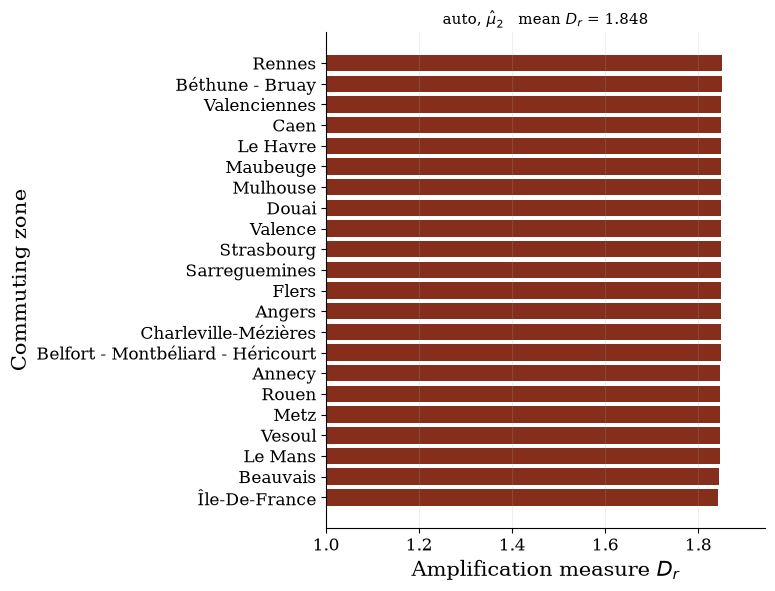

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[aero, mu = 2]  variety count in suppliers.parquet:
        N_hat  varieties_in_parquet  ratio  n_replications
sector                                                    
C22B     10.0                  10.0    1.0              50
C25D     14.0                  14.0    1.0              50
C26E      9.0                   9.0    1.0              50
C27B     15.0                  15.0    1.0              50
C28A      9.0                   9.0    1.0              50
C30C     16.0                  16.0    1.0              50
C33Z      5.0                   5.0    1.0              50
G46Z      8.0                  

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,region,upstream_sales,amplification,supplier_cells,mean_upstream_distance,share_within_100km,share_within_200km
ze2010_downstream,,,,,,,
156,Brest,0.888,1.888,257,590.146,0.015,0.031
267,Cannes - Antibes,0.884,1.884,252,488.485,0.006,0.040
36,Le Havre,0.880,1.880,259,453.792,0.017,0.176
272,Marseille - Aubagne,0.878,1.878,250,395.518,0.040,0.081
193,Bayonne,0.876,1.876,251,381.133,0.057,0.223
273,Istres - Martigues,0.876,1.876,250,366.930,0.046,0.094
137,Cholet,0.874,1.874,254,335.292,0.046,0.157
7,Roissy - Sud Picardie,0.873,1.873,252,375.681,0.167,0.334
220,Valence,0.872,1.872,249,310.968,0.069,0.217


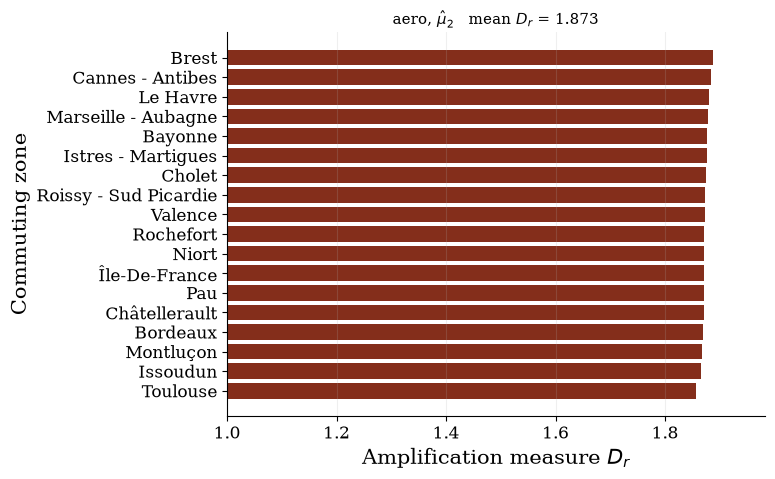

In [23]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    print(f"[{industry}, mu = {MU}]  variety count in suppliers.parquet:")
    supplier_count_check(data)

    diff = build_diffusion_frame(data)
    summ = amplification_summary(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    print(f"\n  mean D_r = {summ['amplification'].mean():.3f} "
          f"(one euro of demand -> {summ['upstream_sales'].mean():.3f} upstream), "
          f"p90 = {summ['amplification'].quantile(0.9):.3f}")
    display(summ.round(3))

    plot_amplification(data, summary=summ,
                       save_to=f"{out_folder}/amplification_{industry}_mu{MU}.pdf")
    plt.show()


## Test 2 — is $D_r$ large? The input-output benchmark

Test 1 returns ~1.85. Whether that is a lot is not answerable from inside the model, so it is
read against the Leontief multipliers of the IO table.

**Two comparisons need no output data and come first**, because they are the ones that can be
made cleanly. The COMPOSITION of the downstream column — the $\pi_s$ object the $\Omega_s$
were calibrated on — against the model's simulated sector split; and the COVERAGE, the
modelled sectors' share of the industry's domestic intermediate purchases. Then
$(D_r - 1)/\text{coverage}$ is what the model implies for the downstream firm's TOTAL
intermediate share: a number that must sit below one and near $1 - \Omega_L$ to be credible.

**What the TES block cannot support, stated rather than papered over.** The technical
coefficients $a_{ij} = X_{ij}/x_j$ need GROSS OUTPUT, and the intermediate-flow block has no
value-added row, so each column must be normalised to an intermediate share supplied from
outside. Under a COMMON $m$ every column of $A$ sums to $m$, hence $\sum_i (A^k)_{ij} = m^k$
and the Leontief total is exactly $1/(1-m)$ for every sector — the cascade then measures the
assumption, not the network. The scalar path runs and says so loudly; pass a per-sector
`intermediate_share` for the informative answer.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[auto]  downstream industry C29A, TES from ../baseline_auto (dom), intermediate share m = 0.8448979386516853
  model  : mean D_r = 1.848  -> the modelled domestic sectors are 0.848 of downstream unit cost
  IO     : those sectors are 63.5% of the industry's DOMESTIC intermediate purchases (67.3% of dom + imp; the column is 59.0% domestic)
           => implied TOTAL intermediate share of unit cost = 1.336
           1 - aggregate labor share (the targeted moment) = 0.845
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.447 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 16% of the aggregate, 100% of round 1)
  IO subset: round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 16% of the aggregate, 100% of rou

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.845,2.559,6.447,1.848,0.156,1.004
subset,10,1.845,2.559,6.447,1.848,0.156,1.004


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C29A,1305.992,3491.482,4797.474,True,0.1602,0.0739,0.2380,0.2475
C29B,1264.404,1907.007,3171.411,True,0.1059,0.0715,0.1573,0.1385
G45Z,2368.608,0.000,2368.608,True,0.0791,0.1340,0.1175,0.1266
C28A,385.795,1799.754,2185.549,True,0.0730,0.0218,0.1084,0.1117
G46Z,1874.860,179.963,2054.823,True,0.0686,0.1060,0.1019,0.1063
C25D,1606.833,0.000,1606.833,True,0.0536,0.0909,0.0797,0.0688
C22B,841.858,514.752,1356.610,True,0.0453,0.0476,0.0673,0.0686
C33Z,1150.074,90.690,1240.764,True,0.0414,0.0650,0.0616,0.0672
M73Z,663.758,218.441,882.199,False,0.0295,0.0375,NaN,NaN


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


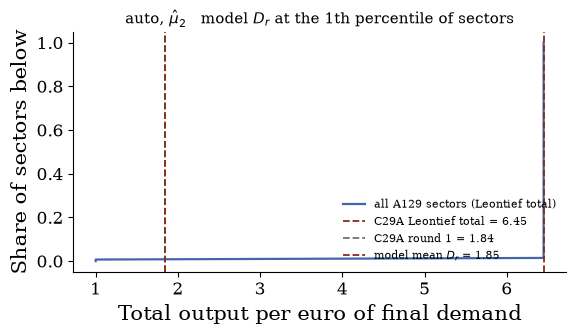

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[aero]  downstream industry C30C, TES from ../baseline_aero (dom), intermediate share m = 0.8510782076751053
  model  : mean D_r = 1.873  -> the modelled domestic sectors are 0.873 of downstream unit cost
  IO     : those sectors are 72.3% of the industry's DOMESTIC intermediate purchases (80.5% of dom + imp; the column is 45.8% domestic)
           => implied TOTAL intermediate share of unit cost = 1.208
           1 - aggregate labor share (the targeted moment) = 0.851
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.715 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 15% of the aggregate, 103% of round 1)
  IO subset: round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 15% of the aggregate, 103% of rou

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.851,2.575,6.715,1.873,0.153,1.026
subset,10,1.851,2.575,6.715,1.873,0.153,1.026


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C30C,6349.585,16899.867,23249.452,True,0.4979,0.2972,0.6184,0.5639
C33Z,4340.815,342.295,4683.110,True,0.1003,0.2032,0.1246,0.1366
C26E,12.912,2563.343,2576.255,True,0.0552,0.0006,0.0685,0.0811
G46Z,2124.009,203.879,2327.888,True,0.0499,0.0994,0.0619,0.0869
C28A,269.091,1255.322,1524.413,True,0.0326,0.0126,0.0405,0.0357
N78Z,977.000,0.000,977.000,False,0.0209,0.0457,NaN,NaN
M70Z,828.542,55.679,884.221,True,0.0189,0.0388,0.0235,0.0230
M71Z,569.876,148.231,718.107,True,0.0154,0.0267,0.0191,0.0247
C27B,110.626,468.915,579.541,True,0.0124,0.0052,0.0154,0.0202


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


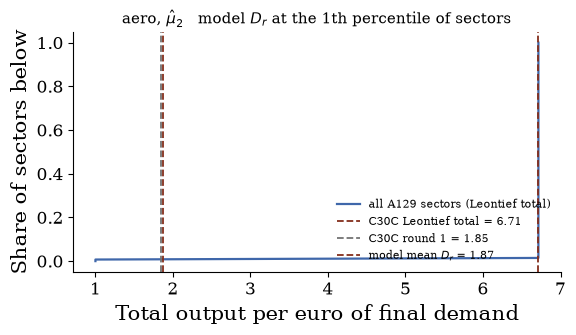

In [24]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    # Guarded: without TES_dom.csv / TES_imp.csv beside the run this prints a note
    # instead of breaking the test.
    try:
        summ = amplification_summary(data, radii=AMPLIFICATION_RADII)
        bench = io_amplification_benchmark(data, summary=summ)
        display(bench.round(3))
        display(io_downstream_column(data).head(15).round(4))
        plot_io_benchmark(data, benchmark=bench,
                          save_to=f"{out_folder}/io_benchmark_{industry}_mu{MU}.pdf")
        plt.show()
    except FileNotFoundError as e:
        print(f"  IO benchmark skipped: {e}")


## Test 3 — how far does the response travel?

Amplification says how large the response is, not where it lands. The first incidence
statistic is the distance the euro covers:

$$d_r = \frac{\sum_{r'} X_{r'r}\, d_{r'r}}{\sum_{r'} X_{r'r}}.$$

One number in kilometres, aggregating the whole geography of the response rather than one
radius, and the object the alignment identity of §4 governs directly.

**Two things this test does NOT settle, and says so.** The LEVEL identifies nothing on its
own: ~350 km in both industries, which is neither which force is holding the euro there nor
whether the two industries hold it there for the same reason. That is test 4. And the
cross-buyer DISPERSION of $d_r$ is partly the shape of the country — a buyer in Brest faces a
larger $d_r$ than one in Bourges under *any* allocation — which is what
`distance_normalisation` removes by dividing through the uniform-allocation distance,
anchoring the statistic at one.

Both the CDF and the histogram are drawn. The CDF is the better object for a SHIFT (the
horizontal gap between two curves is the effect at every quantile, and it uses every point
exactly); the histogram is the better object for a SHAPE. With only ~20 shocked regions the
histogram is sensitive to `bins` in a way the CDF is not — vary `bins` before believing a mode.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[auto, mu = 2]  d_r: mean 347.2 km, median 358.7, min 257.3, max 407.1


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  d_r normalised by the uniform-allocation distance (1 = as far as an unselective allocation would send it):
                             mean    50%    min    max
regime                                                
Realised                    0.798  0.783  0.684  1.079
Both forces                 0.799  0.781  0.689  1.084
Distance only               0.942  0.942  0.925  0.952
Comparative advantage only  0.852  0.836  0.760  1.141


region  \
ze2010_downstream regime                                             
12                Realised                           Île-De-France   
                  Both forces                        Île-De-France   
                  Distance only                      Île-De-France   
                  Comparative advantage only         Île-De-France   
13                Realised                    Charleville-Mézières   
...                                                            ...   
220               Comparative advantage only               Valence   
230               Realised                                  Annecy   
                  Both forces                               Annecy   
                  Distance only                             Annecy   
                  Comparative advantage only                Annecy   

                                              mean_upstream_distance  \
ze2010_downstream regime                                               
12                Realised                                   257.279   
                  Both forces                                258.999   
                  Distance only                              352.579   
                  Comparative advantage only                 285.713   
13                Realised                                   338.231   
...                                                              ...   
220               Comparative advantage only                 380.935   
230               Realised                                   338.291   
                  Both forces                                337.793   
                  Distance only                              328.173   
                  Comparative advantage only                 359.319   

                                              uniform_distance  distance_ratio  
ze2010_downstream regime                                                        
12                Realised                             376.070           0.684  
                  Both forces                          376.070           0.689  
                  Distance only                        376.070           0.938  
                  Comparative advantage only           376.070           0.760  
13                Realised                             462.952           0.731  
...                                                        ...             ...  
220               Comparative advantage only           333.956           1.141  
230               Realised                             352.768           0.959  
                  Both forces                          352.768           0.958  
                  Distance only                        352.768           0.930  
                  Comparative advantage only           352.768           1.019  

[88 rows x 4 columns]

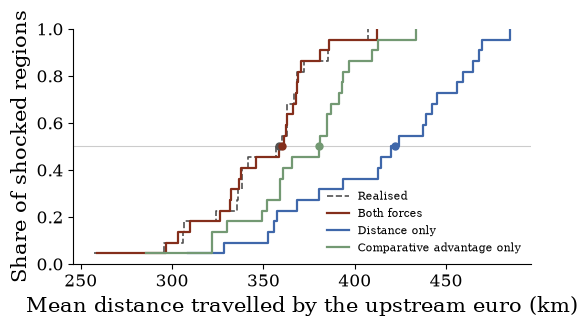

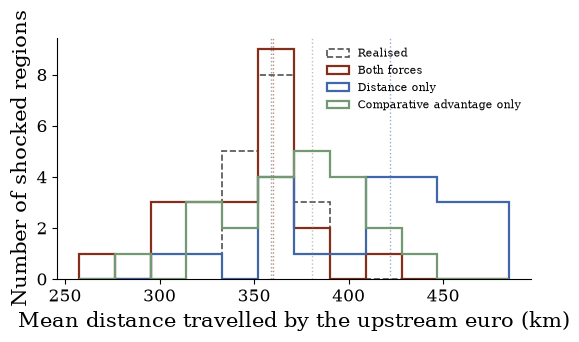

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[aero, mu = 2]  d_r: mean 353.3 km, median 333.3, min 252.9, max 590.1


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  d_r normalised by the uniform-allocation distance (1 = as far as an unselective allocation would send it):
                             mean    50%    min    max
regime                                                
Realised                    0.878  0.908  0.640  0.981
Both forces                 0.881  0.908  0.639  0.981
Distance only               0.882  0.888  0.826  0.944
Comparative advantage only  0.967  0.973  0.797  1.124


region  \
ze2010_downstream regime                                              
7                 Realised                    Roissy - Sud Picardie   
                  Both forces                 Roissy - Sud Picardie   
                  Distance only               Roissy - Sud Picardie   
                  Comparative advantage only  Roissy - Sud Picardie   
11                Realised                                 Toulouse   
...                                                             ...   
272               Comparative advantage only    Marseille - Aubagne   
273               Realised                       Istres - Martigues   
                  Both forces                    Istres - Martigues   
                  Distance only                  Istres - Martigues   
                  Comparative advantage only     Istres - Martigues   

                                              mean_upstream_distance  \
ze2010_downstream regime                                               
7                 Realised                                   375.681   
                  Both forces                                376.802   
                  Distance only                              332.152   
                  Comparative advantage only                 434.096   
11                Realised                                   252.917   
...                                                              ...   
272               Comparative advantage only                 434.234   
273               Realised                                   366.930   
                  Both forces                                368.562   
                  Distance only                              378.553   
                  Comparative advantage only                 405.575   

                                              uniform_distance  distance_ratio  
ze2010_downstream regime                                                        
7                 Realised                             386.066           0.973  
                  Both forces                          386.066           0.976  
                  Distance only                        386.066           0.860  
                  Comparative advantage only           386.066           1.124  
11                Realised                             395.398           0.640  
...                                                        ...             ...  
272               Comparative advantage only           450.783           0.963  
273               Realised                             427.406           0.859  
                  Both forces                          427.406           0.862  
                  Distance only                        427.406           0.886  
                  Comparative advantage only           427.406           0.949  

[72 rows x 4 columns]

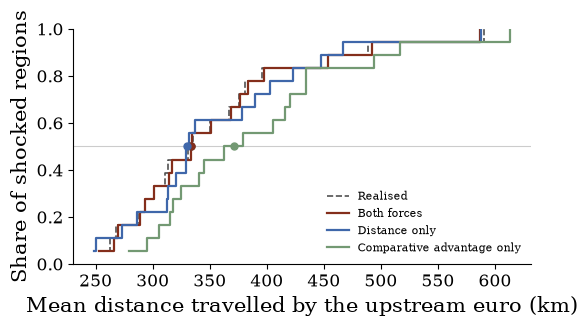

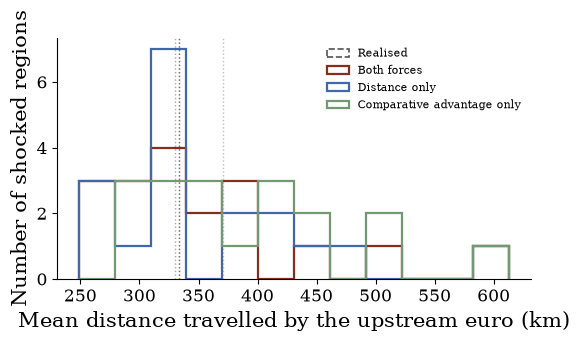

In [25]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    diff = build_diffusion_frame(data)
    summ = amplification_summary(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    print(f"[{industry}, mu = {MU}]  d_r: mean {summ['mean_upstream_distance'].mean():.1f} km, "
          f"median {summ['mean_upstream_distance'].median():.1f}, "
          f"min {summ['mean_upstream_distance'].min():.1f}, "
          f"max {summ['mean_upstream_distance'].max():.1f}")

    # d_r purged of the country's shape: 1 = as far as an unselective allocation sends it
    display(distance_normalisation(data, diffusion=diff).round(3))

    plot_distance_distribution(data, diffusion=diff,
                               save_to=f"{out_folder}/counterfactual_distance_{industry}_mu{MU}.pdf")
    plt.show()
    plot_distance_histogram(data, diffusion=diff,
                            save_to=f"{out_folder}/counterfactual_distance_hist_{industry}_mu{MU}.pdf")
    plt.show()


## Test 3 bis — how uniform is the force that sets that distance?

Test 3 reports where $d_r$ ends up. This one reports the *rate* that puts it there, which is
the object the next test integrates. By the alignment identity, dialling comparative
advantage down moves a buyer's average sourcing distance at

$$\frac{\partial \bar d_{rs}}{\partial t} = \operatorname{Cov}_{\rho_{\cdot rs}}\!\big(\log \hat T_{a(l)s},\, d_{lr}\big),$$

taken across the cells competing for that buyer and weighted by the sourcing probabilities.
It is in KILOMETRES per log point, so unlike the correlation of the section above it can be
read against the counterfactual directly: a buyer's whole displacement under *Distance only*
is the path integral of its own covariance.

**Why this figure and not the correlation, and why both are kept.** The correlation is
scale-free, which is what makes it the right object in §4 — $\hat T$ is identified only up to
a per-sector scale, so a comparison of two industries has to be. But a scale-free statistic
carries no distance, and §5.1 quotes kilometres. Reporting the covariance here is what lets
the counterfactual paragraph and the figure it cites be the same statistic.

**What the figure answers that a median cannot.** A sector median of $-54$ km is consistent
with every buyer facing the same mild alignment *and* with half facing a strong one and half
the opposite — different economies, different counterfactuals. The mass on either side of
zero is the answer: where it is one-sided, equalising $\hat T$ moves every buyer the same way
and the aggregate is the buyer; where it straddles zero, the aggregate is a cancellation and
the buyer-level picture of test 4 is the one to read.

The histogram and a Gaussian kernel density are drawn together. The density is the cleaner
object for a paper, but it is an estimate with a bandwidth: at a couple of hundred pairs it
can put a shoulder where the data have three points, and it leaks a little mass past the
extreme observations. The outline underneath is the raw count to check it against — vary `bw`
as `bins` is varied on the histogram of test 3. `level="buyer"` spend-aggregates across
sectors, which is the level at which "negative for every buyer" is a claim rather than a
statement about (sector, buyer) pairs.


In [26]:
# Test 3 bis — the alignment in KILOMETRES: the rate the counterfactual integrates.
#
# Reads `alignment_frame` from Test 6 of the comparative-advantage section above,
# and `_parquet_sector_index` from the amplification definitions, so run those first
# if this section is run on its own.
from scipy.stats import gaussian_kde


def alignment_covariance(data, weights="rho", frame=None):
    """
    The alignment in KILOMETRES, one row per (sector, buyer) — the object Section 5.1
    reads, as opposed to the dimensionless correlation `alignment_correlation` returns.

    `cov_T_d_km` is `Cov_rho(log T_a(l)s, d_lr)`, the rate at which dialling comparative
    advantage down moves that buyer's average sourcing distance in that sector
    (eq:alignment). `cov_d_d_km` is `Cov_rho(log d_lr, d_lr)`, the rate for trade costs
    (eq:distance_rate); it is a covariance between two increasing functions of the same
    variable, so it is POSITIVE by construction and the column exists to be checked, not
    to be read for its sign.

    Three conventions are inherited rather than chosen, and each of the three is a place
    the figure and the text can silently come apart. The moments are taken under the
    SOURCING probabilities `rho` by default, because that is the measure the identity
    holds under — `weights="cell"` reproduces the variance decomposition's convention
    instead and answers a different question. Distance enters in KILOMETRES on the second
    argument, because the statistic differentiates `d_rs = sum_l rho_lrs d_lr`; the log
    is on `T` alone. And the row is one (sector, buyer) pair, so a buyer-level statement
    needs `by_buyer=True` on the aggregate below, not a read of this frame's median.

    Built off `alignment_frame`, so the figure and the regression cannot drift apart.
    """
    fr = alignment_frame(data, geom=None) if frame is None else frame
    if weights not in ("rho", "cell"):
        raise ValueError(f"weights must be 'rho' or 'cell', not {weights!r}")
    rows = []
    # grouped on `group`, not on (sector, buyer): `group` is built from the downstream
    # INDEX, so two buyers sharing a display name cannot be merged into one row.
    for _, sub in fr.groupby("group", sort=False):
        sec, buyer = sub["sector"].iloc[0], sub["buyer"].iloc[0]
        x = sub["log_T"].to_numpy(float)
        d = sub["distance_km"].to_numpy(float)
        p = (sub["rho"].to_numpy(float) if weights == "rho"
             else np.full(len(sub), 1.0 / len(sub)))
        tot = p.sum()
        if not np.isfinite(tot) or tot <= 0 or len(sub) < 2:
            continue
        p = p / tot
        ld = np.log(np.maximum(d, 1.0))
        mx, md, ml = float(p @ x), float(p @ d), float(p @ ld)
        rows.append({
            "sector": sec,
            "buyer": buyer,
            "cov_T_d_km": float(p @ ((x - mx) * (d - md))),
            "cov_d_d_km": float(p @ ((ld - ml) * (d - md))),
            "d_rs_km": md,
            "buyer_weight": float(sub["weight"].sum()),
            "n_cells": int(len(sub)),
        })
    out = pd.DataFrame(rows)
    out.attrs["weights"] = weights
    out.attrs["industry"] = data["industry"]
    return out


def alignment_covariance_by_buyer(data, cov=None, weights="rho"):
    """
    The same covariance aggregated to the BUYER, which is the level Section 5.1 quotes.

    `d_r = sum_s (X_rs/X_r) d_rs`, so the buyer-level rate is the spend-weighted average
    of its sectors' rates — the same buyer-first aggregation `counterfactual_diffusion_frame`
    performs on the euros, and the reason a sector median and a buyer median need not
    agree (one sector can carry most of a buyer's spending).

    Spending comes from the realised economy (`suppliers.parquet`); absent it, the
    function raises rather than falling back on equal sector weights, which would report
    a different statistic under the same name.
    """
    cov = alignment_covariance(data, weights=weights) if cov is None else cov
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            "— the buyer-level aggregation needs the realised sector-level spending.")
    geom = sourcing_geometry(data)
    # The buyer label is rebuilt with `aa_display_names`, the SAME route `alignment_frame`
    # takes, so the join cannot silently miss: `alignment_correlation` names buyers through
    # `_region_labels` instead, and the two need not agree on every zone. The parquet's
    # `ze2010_downstream` carries the model's own region index, which is what
    # `geom["downstream"]` holds, so the key is exact rather than a name match.
    aa_names = aa_display_names(data)
    ze_of_name = {(aa_names[r] if r < len(aa_names) else str(r)): int(z)
                  for r, z in enumerate(geom["downstream"])}
    spend = (sup.assign(_s=_parquet_sector_index(data, sup))
                .groupby(["ze2010_downstream", "_s"])["share"].sum())
    sec_of = {name: s for s, name in enumerate(data["sector_names"])}
    w = []
    for _, row in cov.iterrows():
        s, z = sec_of.get(row["sector"]), ze_of_name.get(row["buyer"])
        w.append(0.0 if s is None or z is None else float(spend.get((z, s), 0.0)))
    cov = cov.assign(spend=w)
    if float(np.sum(w)) <= 0:
        raise ValueError(
            "every (sector, buyer) matched zero spending — the parquet's sector index or "
            "its `ze2010_downstream` does not line up with `sourcing_geometry`.")
    # `sup` pools `n_rep` realisations, so `spend` is `n_rep` times the per-economy figure;
    # unlike `counterfactual_diffusion_frame`, which allocates those euros and must divide,
    # this uses them only as WEIGHTS, and a common factor cancels out of a weighted mean.
    #
    # Summed rather than run through `groupby.apply`: apply over the grouping column warns
    # on pandas 2.x, and its `np.average` would have propagated a NaN covariance into the
    # numerator while `sum` silently kept that pair's spending in the denominator. Dropping
    # the unusable rows first is what makes the weights and the values the same set.
    ok = cov.dropna(subset=["cov_T_d_km", "cov_d_d_km"])
    acc = (ok.assign(_a=ok["cov_T_d_km"] * ok["spend"], _b=ok["cov_d_d_km"] * ok["spend"])
             .groupby("buyer", sort=False)[["_a", "_b", "spend"]].sum())
    den = acc["spend"].where(acc["spend"] > 0)
    out = pd.DataFrame({"cov_T_d_km": acc["_a"] / den,
                        "cov_d_d_km": acc["_b"] / den,
                        "spend": acc["spend"]})
    out.attrs["industry"] = data["industry"]
    return out



def plot_alignment_covariance(datasets, weights="rho", bins=24, frames=None, colors=None,
                              figsize=None, save_to=None, annotate=True, level="pair",
                              kde=True, bw=None, grid=512):
    """
    The distribution of the alignment in KILOMETRES: one histogram outline and one
    kernel density per industry, on one panel.

    This is `plot_alignment_correlation`'s companion, not its replacement, and the two
    answer different questions. The correlation is scale-free, so it RANKS geometries
    and is the right object for Section 4, where the comparison is between two
    industries whose `log T` is identified only up to a per-sector scale. The covariance
    carries kilometres, so it is the only one of the two a paragraph quoting a distance
    may cite: by the alignment identity it IS the rate at which dialling comparative
    advantage down moves that buyer's average sourcing distance, and its path integral
    is the `Distance only` counterfactual.

    Three conventions, each a place the figure and the text can silently come apart. The
    moments are taken under the SOURCING probabilities, because that is the measure the
    identity holds under; `weights="cell"` reproduces the variance decomposition's
    convention and answers a different question. Distance enters in kilometres on the
    second argument and the log is on `T` alone, because the statistic differentiates
    `d_rs = sum_l rho_lrs d_lr`. And a row is one (sector, buyer) pair unless
    `level="buyer"`, which spend-aggregates across sectors -- the level at which a
    sentence of the form "negative for every buyer" is a claim.

    Both the histogram and the density are drawn, deliberately. A Gaussian kernel is
    smooth and reads well in a paper, but it is an ESTIMATE with a bandwidth, and at a
    couple of hundred pairs it can put a shoulder where the data have three points; the
    outline underneath is the raw count the reader checks it against. `bw` overrides
    Scott's rule -- vary it before believing a mode, exactly as `bins` is varied on
    `plot_distance_histogram`. The kernel is drawn on the pooled support and is NOT
    truncated at the data range, so a little mass leaks past the extreme observations:
    that is the estimator, not a finding.

    Bin edges and the density grid are computed ONCE on the pooled values, so the two
    industries sit on one axis and the comparison is a comparison.
    """
    if level not in ("pair", "buyer"):
        raise ValueError(f"level must be 'pair' or 'buyer', not {level!r}")

    def _build(d):
        cov = alignment_covariance(d, weights=weights)
        return cov if level == "pair" else alignment_covariance_by_buyer(d, cov=cov)

    frs = frames if frames is not None else {n: _build(d) for n, d in datasets}
    vals = {n: f["cov_T_d_km"].dropna().to_numpy(float) for n, f in frs.items()}
    pooled = np.concatenate(list(vals.values()))
    if pooled.size == 0:
        raise ValueError(f"no {level} with a finite Cov(log T, d).")
    edges = np.histogram_bin_edges(pooled, bins=bins)
    pad = 0.15 * (pooled.max() - pooled.min() or 1.0)
    xs = np.linspace(pooled.min() - pad, pooled.max() + pad, int(grid))

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    palette = colors or {}
    default = [sim_color, toulouse_color, reference_color]
    for k, (name, v) in enumerate(vals.items()):
        col = palette.get(name, default[k % len(default)])
        ax.hist(v, bins=edges, density=True, histtype="step", linewidth=1.0,
                color=col, alpha=0.55)
        lab = f"{name} (median {np.median(v):+.0f} km)"
        if kde and v.size > 1 and np.ptp(v) > 0:
            dens = gaussian_kde(v, bw_method=bw)(xs)
            ax.plot(xs, dens, color=col, linewidth=1.8, label=lab)
            ax.fill_between(xs, dens, color=col, alpha=0.10)
        else:
            ax.plot([], [], color=col, linewidth=1.8, label=lab)
        ax.axvline(np.median(v), color=col, linestyle=":", linewidth=1.0)
    ax.axvline(0.0, color="0.35", linewidth=0.9)
    unit = "buyer" if level == "buyer" else "(sector, buyer)"
    ax.set_xlabel(r"$\mathrm{Cov}_{\rho}(\log \hat T_{a(l)s},\ d_{lr})$ "
                  f"(km per log point) at one {unit}")
    ax.set_ylabel("Density")
    ax.set_ylim(bottom=0.0)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    if annotate:
        txt = "\n".join(f"{n}: {float((v > 0).mean()):.0%} positive" for n, v in vals.items())
        ax.text(0.98, 0.97, txt, transform=ax.transAxes, fontsize=8, va="top",
                ha="right", color="0.25")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax, frs


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(
/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


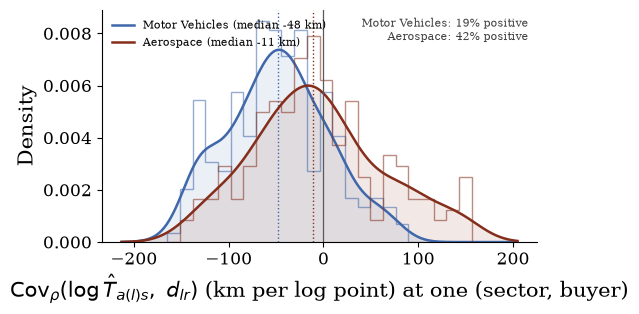

Motor Vehicles: 220 (sector, buyer) pairs, median -48.2 km/log pt, purchase-weighted mean -60.2, 18.6% positive, p10 -125.5, p90 +17.5
    Cov(log d, d) > 0 for 100.0% of pairs (must be 100%), median +101.3 km/log pt
Aerospace: 180 (sector, buyer) pairs, median -11.1 km/log pt, purchase-weighted mean -15.2, 41.7% positive, p10 -91.5, p90 +95.8
    Cov(log d, d) > 0 for 100.0% of pairs (must be 100%), median +86.2 km/log pt


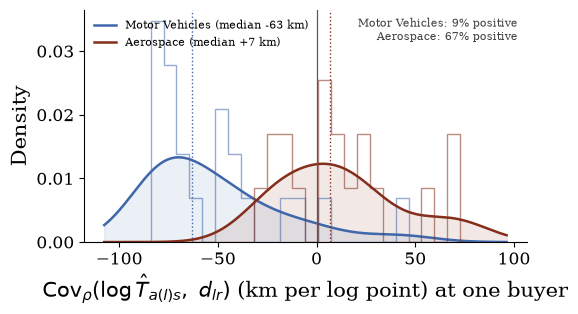

Motor Vehicles: 22 buyers, median -63.1 km/log pt, 9.1% positive, range [-84.1, +41.7]
Aerospace: 18 buyers, median +6.9 km/log pt, 66.7% positive, range [-27.2, +72.7]


In [27]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
cov_data = []
for cfg in INDUSTRIES:
    data = load_granular_data(cfg["industry"], mu=MU, **RUN_KWARGS)
    cov_data.append(data)

_cov_ax, _cov_frames = plot_alignment_covariance(
    [(cfg["display_name"], d) for cfg, d in zip(INDUSTRIES, cov_data)],
    save_to=f"{out_folder}/alignment_covariance_mu{MU}.pdf")
plt.show()

for _name, _fr in _cov_frames.items():
    _w, _c = _fr["buyer_weight"], _fr["cov_T_d_km"]
    print(f"{_name}: {len(_fr)} (sector, buyer) pairs, median {_c.median():+.1f} km/log pt, "
          f"purchase-weighted mean {float((_c * _w).sum() / _w.sum()):+.1f}, "
          f"{float((_c > 0).mean()):.1%} positive, "
          f"p10 {_c.quantile(0.10):+.1f}, p90 {_c.quantile(0.90):+.1f}")
    # the trade-cost rate: Cov(log d, d) is a covariance between two increasing functions
    # of the same variable, so this line gates the arithmetic rather than reporting a result
    print(f"    Cov(log d, d) > 0 for {float((_fr['cov_d_d_km'] > 0).mean()):.1%} of pairs "
          f"(must be 100%), median {_fr['cov_d_d_km'].median():+.1f} km/log pt")

# --- and the same covariance at the BUYER level, which is what 5.1 asserts ----
# One sector can carry most of a buyer's spending, so the pair median and the buyer
# median need not agree; this is the spend-weighted aggregation, the one the euros get.
try:
    plot_alignment_covariance(
        [(cfg["display_name"], d) for cfg, d in zip(INDUSTRIES, cov_data)],
        level="buyer",
        save_to=f"{out_folder}/alignment_covariance_buyer_mu{MU}.pdf")
    plt.show()
    for cfg, d in zip(INDUSTRIES, cov_data):
        v = alignment_covariance_by_buyer(d)["cov_T_d_km"].dropna()
        print(f"{cfg['display_name']}: {len(v)} buyers, median {v.median():+.1f} km/log pt, "
              f"{float((v > 0).mean()):.1%} positive, "
              f"range [{v.min():+.1f}, {v.max():+.1f}]")
except (FileNotFoundError, NameError) as e:
    print(f"  buyer-level aggregation skipped: {e}")


## Test 4 — which force keeps the euro close?

The sourcing probabilities are closed form, so the same shock can be propagated with either
allocative force switched off. What is held FIXED is what the model makes a cost-share object
— how much of the euro leaves for upstream, and how it splits across SECTORS, neither of which
involves $T$ or $\alpha$. What moves is where inside a sector the euro lands.

**Two consequences, both load-bearing.** Since $\sum_l \rho_{lrs} = 1$ for every (sector,
buyer), $D_r$ is IDENTICAL under every regime: cancelling a channel moves a shock in space
without changing its size. That is why every counterfactual figure is about incidence and none
re-draws $D_r$, and it is gated to machine precision. And `Both forces` is the closed-form
EXPECTATION of the allocation while the parquet is one realised finite-variety draw of it, so
the two differ by granularity — the gap is printed, and the closed-form row, not the realised
one, is the baseline the other regimes are read against.

**The two regimes are not symmetric interventions.** Equalising $\hat T$ removes a
*supplier*-specific term; setting $\alpha = 0$ removes the *only buyer-specific* term in
$\rho_{lrs} \propto T_{a(l)s} d_{lr}^{-\theta\alpha}$. Any statistic measuring how much of its
own position a buyer's sourcing inherits must therefore go to zero under $\alpha = 0$ by
construction — that regime is an internal control on such a statistic, not an economic
counterfactual to be compared with the other.

By the alignment identity the movement of $d_r$ IS the co-location covariance evaluated at
that buyer, so the SHAPE of the shift is informative in a way its mean is not: a block shift
means the covariance is common across buyers, crossing curves mean the sign is not.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  [counterfactual] D_r is identical across regimes to 8.88e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.074 vs closed-form both-forces 0.073 — the gap is granularity, not a different economy

[auto, mu = 2]  the shock with one force switched off (D_r is the same in every regime by construction):
                            amplification  mean_upstream_distance  share_within_100km  weighted_share_within_100km  share_within_200km  weighted_share_within_200km
regime                                                                                                                                                             
Realised                            1.848                 347.294               0.074                        0.074               0.238                        0.237
Both forces                         1.848                 347.593               0.073                        0.073               0.2

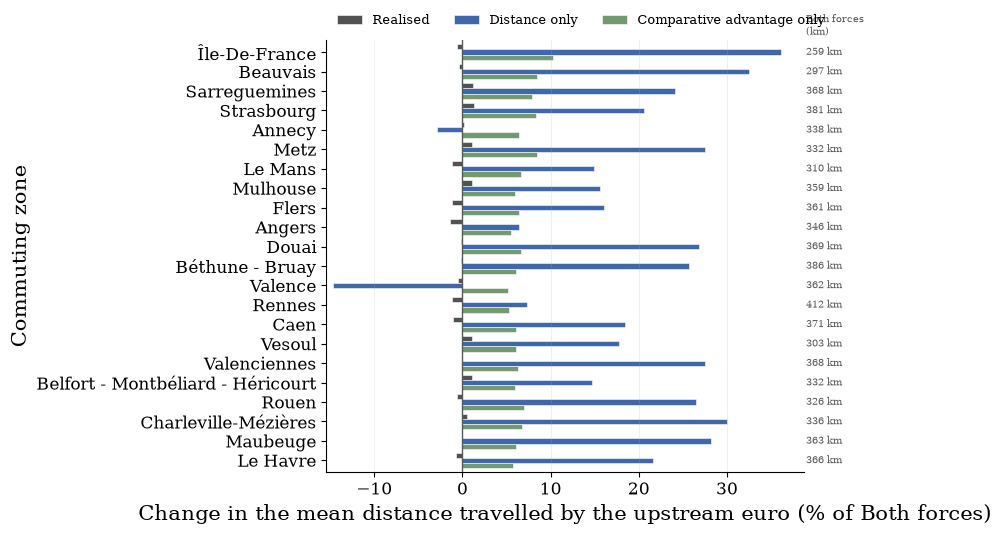

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
  [counterfactual] D_r is identical across regimes to 4.44e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.088 vs closed-form both-forces 0.089 — the gap is granularity, not a different economy

[aero, mu = 2]  the shock with one force switched off (D_r is the same in every regime by construction):
                            amplification  mean_upstream_distance  share_within_100km  weighted_share_within_100km  share_within_200km  weighted_share_within_200km
regime                                                                    

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


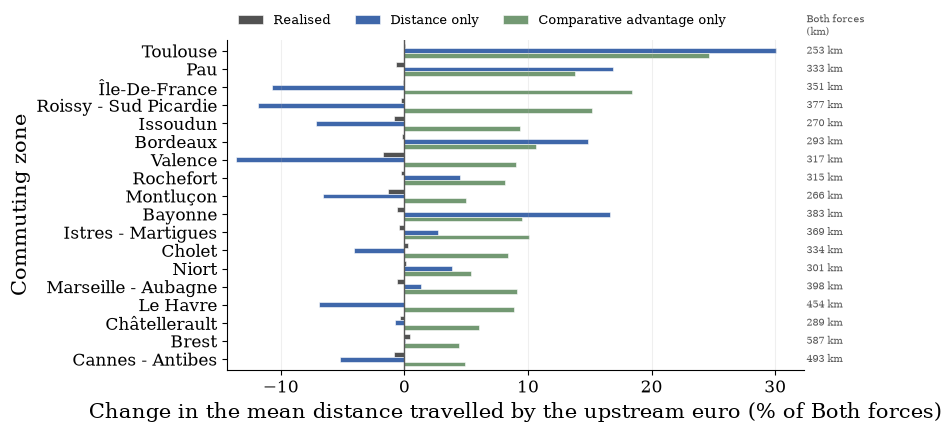

In [28]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    diff   = build_diffusion_frame(data)
    frames = counterfactual_frames(data, diffusion=diff)
    det    = counterfactual_amplification(data, radii=AMPLIFICATION_RADII,
                                          frames=frames, diffusion=diff)

    print(f"\n[{industry}, mu = {MU}]  the shock with one force switched off "
          "(D_r is the same in every regime by construction):")
    print(counterfactual_summary(data, radii=AMPLIFICATION_RADII, detail=det).round(3).to_string())

    # is the shift a block translation or a rotation? the quantile-by-quantile answer
    print("\n  the distribution of d_r behind that mean, and how each force shifts it:")
    print(distance_distribution_report(data, detail=det).to_string())

    # ... and the same thing differenced BUYER BY BUYER rather than quantile by quantile,
    # on the percentage scale `plot_counterfactual_distance` is drawn on. `mean_abs_pct`
    # against `mean_pct` is the size of the reallocation a near-zero average hides.
    print("\n  each buyer's d_r as a % deviation from the estimated allocation:")
    rel = relative_displacement(data, detail=det)
    print(rel.to_string())
    # every buyer, sorted: there are only ~20 of them, and the paper names individual
    # commuting zones, so the full list is what a named claim has to be checked against.
    _p = rel.attrs["per_buyer_pct"]
    for _reg in [c for c in ("Distance only", "Comparative advantage only") if c in _p.columns]:
        print(f"\n  {_reg}: each buyer's % deviation, sorted (negative = sources closer):")
        print(_p[_reg].sort_values(ascending=False).round(1).to_string())

    plot_counterfactual_distance(
        data, detail=det,
        save_to=f"{out_folder}/counterfactual_distance_region_{industry}_mu{MU}.pdf")
    plt.show()


## Test 5 — where does the response land?

Test 4 says capability sits near demand in motor vehicles. It does not say whether that
capability is one broad mass inside the demand distribution, a set of local pockets, or a
small number of hubs — three different economies, and only the third is hub-and-spoke.

**The barycentre cannot make that distinction, and this is a defect rather than a taste.**
It is the FIRST MOMENT of the destination distribution, and a dispersed central pool and a
pair of distant hubs have nearly the same first moment: both sit near the national centre of
mass, since with four fifths of the euros spread nationally the mean is pinned there however
concentrated the remaining fifth is. That is exactly why every aerospace arrow lands in the
Massif Central while the euros are collected by Toulouse and Île-de-France. The shrinkage
coefficient $\lambda$ inherits the degeneracy — below 0.12 in both industries, separating
nothing. `barycentre_shrinkage` is still run below, as a reported robustness exhibit.

The object with the answer is the incidence vector $\omega_r = (X_{lr}/\sum_l X_{lr})_l$,
characterised by two numbers. CONCENTRATION is the effective number of destinations
$1/H_r$, reported RELATIVE to the uniform allocation because its level is mostly the sector's
cell count and the shape of the country. COMMONALITY is the euro share that is buyer-specific,
$\Delta_r = \tfrac12\sum_l|\omega_{lr} - \bar\omega_l|$, read against ZERO rather than against
a benchmark — the allocation is already nearly buyer-independent, so an overlap statistic in
levels sits at its ceiling in both industries.

The prediction is stated before the numbers: aerospace should be concentrated AND common
(bottom-left of the plane), motor vehicles spread and common.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.

[auto, mu = 2]
  the incidence vector: how concentrated, and how much is buyer-specific
  (n_eff_ratio < 1 = the forces concentrate; tv_common is the euro share that is buyer-specific, read against 0)
                              n_eff  n_eff_ratio    hhi   top3  own_share  tv_common  cos_common  pairwise_cos  pairwise_tv
regime                                                                                                                     
Realised                    105.847        0.468  0.009  0.074      0.007      0.048       0.995         0.987        0.067
Both forces                 106.660        0.472  0.009  0.073      0.006      0.044       0.996         

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


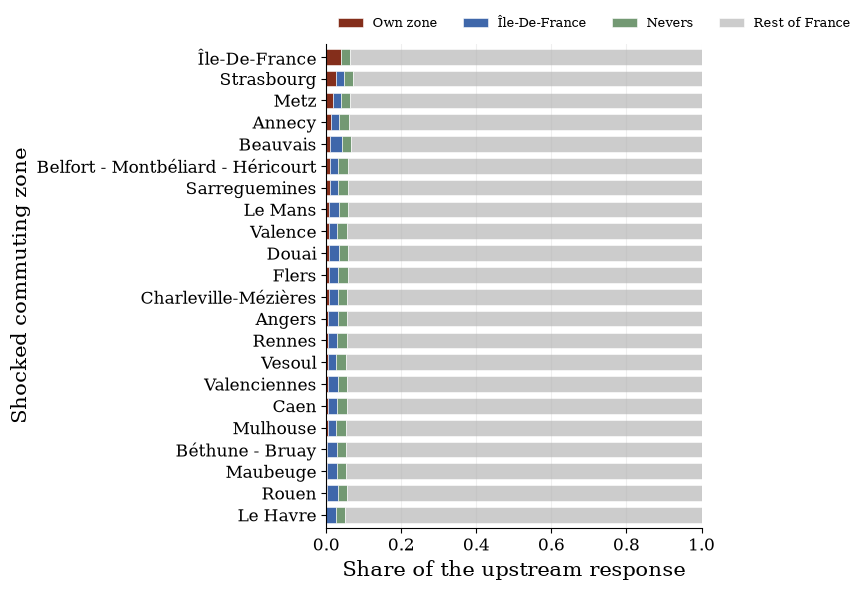

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.

[aero, mu = 2]
  the incidence vector: how concentrated, and how much is buyer-specific
  (n_eff_ratio < 1 = the forces concentrate; tv_common is the euro share that is buyer-specific, read against 0)
                             n_eff  n_eff_ratio    hhi   top3  own_share  tv_common  cos_common  pairwise_cos  pairwise_tv
regime                                                                                                                    
Realised                    28.938        0.302  0.035  0.234      0.012      0.082       0.991         0.975        0.124
Both forces                 31.337        0

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


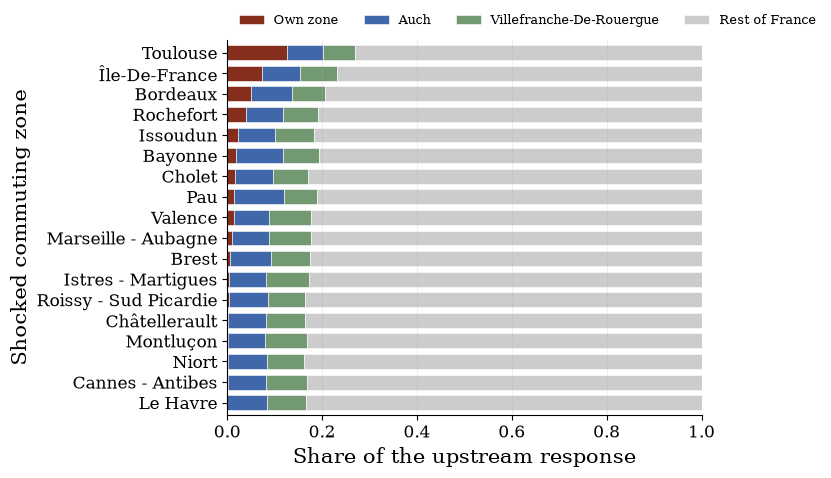

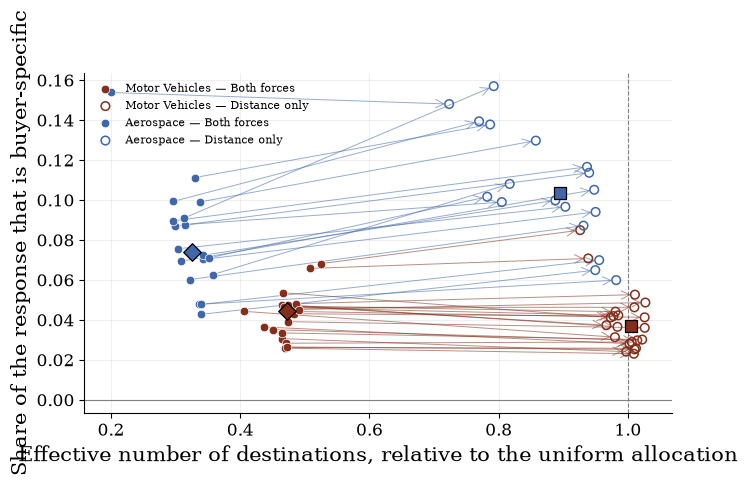

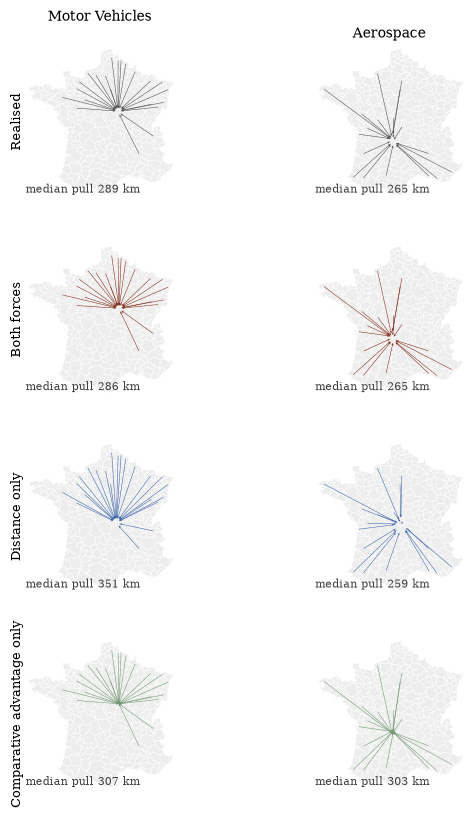

                                           slope     se       t  ci_lo  ci_hi  slope_x  slope_y     r2  dispersion_ratio  median_pull_km  median_distance_km     n
industry       regime                                                                                                                                             
Aerospace      Both forces                 0.080  0.009   8.904  0.062  0.098    0.060    0.097  0.846             0.087         264.600             335.014  18.0
               Comparative advantage only -0.023  0.007  -3.274 -0.036 -0.009   -0.002   -0.040  0.374             0.037         302.729             372.621  18.0
               Distance only               0.121  0.014   8.849  0.094  0.148    0.113    0.128  0.871             0.130         259.301             334.260  18.0
               Realised                    0.082  0.009   8.799  0.064  0.101    0.064    0.097  0.852             0.089         264.645             334.360  18.0
Motor Vehicles Both fo

slope     se       t  ci_lo  ci_hi  \
industry       regime                                                           
Aerospace      Both forces                 0.080  0.009   8.904  0.062  0.098   
               Comparative advantage only -0.023  0.007  -3.274 -0.036 -0.009   
               Distance only               0.121  0.014   8.849  0.094  0.148   
               Realised                    0.082  0.009   8.799  0.064  0.101   
Motor Vehicles Both forces                 0.065  0.002  34.472  0.062  0.069   
               Comparative advantage only -0.003  0.000 -11.668 -0.003 -0.002   
               Distance only               0.069  0.004  19.571  0.062  0.076   
               Realised                    0.068  0.002  33.809  0.064  0.072   

                                           slope_x  slope_y     r2  \
industry       regime                                                
Aerospace      Both forces                   0.060    0.097  0.846   
               Comparative advantage only   -0.002   -0.040  0.374   
               Distance only                 0.113    0.128  0.871   
               Realised                      0.064    0.097  0.852   
Motor Vehicles Both forces                   0.067    0.062  0.961   
               Comparative advantage only   -0.003   -0.002  0.830   
               Distance only                 0.067    0.073  0.955   
               Realised                      0.068    0.068  0.964   

                                           dispersion_ratio  median_pull_km  \
industry       regime                                                         
Aerospace      Both forces                            0.087         264.600   
               Comparative advantage only             0.037         302.729   
               Distance only                          0.130         259.301   
               Realised                               0.089         264.645   
Motor Vehicles Both forces                            0.067         286.461   
               Comparative advantage only             0.003         307.104   
               Distance only                          0.070         351.112   
               Realised                               0.069         288.858   

                                           median_distance_km     n  
industry       regime                                                
Aerospace      Both forces                            335.014  18.0  
               Comparative advantage only             372.621  18.0  
               Distance only                          334.260  18.0  
               Realised                               334.360  18.0  
Motor Vehicles Both forces                            353.820  22.0  
               Comparative advantage only             375.454  22.0  
               Distance only                          419.197  22.0  
               Realised                               355.277  22.0

,a,b,diff,se,t,ci_lo,ci_hi
0,Aerospace / Comparative advantage only,Aerospace / Both forces,-0.103,0.011,-9.053,-0.125,-0.080
1,Aerospace / Distance only,Aerospace / Both forces,0.041,0.016,2.512,0.009,0.073
2,Aerospace / Realised,Aerospace / Both forces,0.002,0.013,0.172,-0.023,0.028
3,Motor Vehicles / Comparative advantage only,Motor Vehicles / Both forces,-0.068,0.002,-35.622,-0.072,-0.064
4,Motor Vehicles / Distance only,Motor Vehicles / Both forces,0.003,0.004,0.796,-0.005,0.011
5,Motor Vehicles / Realised,Motor Vehicles / Both forces,0.002,0.003,0.863,-0.003,0.008
6,Motor Vehicles / Both forces,Aerospace / Both forces,-0.015,0.009,-1.588,-0.033,0.003



Motor Vehicles — where the arrows point (realised economy):


,hub_index,n_regions,sales,share_of_regions
hub,,,,
Cosne - Clamecy,3,19,16.111,0.864



Aerospace — where the arrows point (realised economy):


,hub_index,n_regions,sales,share_of_regions
hub,,,,
Ussel,210,5,4.378,0.278
Tulle,209,3,2.604,0.167
Guéret,211,2,1.744,0.111


In [29]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
incidence_tables, panel_data = [], []
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    panel_data.append(data)
    globals().update(data)

    diff   = build_diffusion_frame(data)
    frames = counterfactual_frames(data, diffusion=diff)

    print(f"\n[{industry}, mu = {MU}]")
    inc = incidence_concentration_overlap(data, frames=frames, diffusion=diff)
    incidence_tables.append((cfg["display_name"], inc))
    incidence_summary(inc)

    # the figure that replaces the barycentre arrows: own zone, the industry's hubs, rest
    plot_destination_composition(
        data, diffusion=diff,
        save_to=f"{out_folder}/destination_composition_{industry}_mu{MU}.pdf")
    plt.show()

# the 2x2 plane, both industries on one window
plot_incidence_plane(incidence_tables, save_to=f"{out_folder}/incidence_plane_mu{MU}.pdf")
plt.show()

# The barycentre, kept as a reported robustness exhibit rather than as the answer.
# Guarded: without france.gpkg (or geopandas) there is no geometry to place one in.
try:
    fig, barys = barycentre_panel(
        [(cfg["display_name"], d) for cfg, d in zip(INDUSTRIES, panel_data)],
        save_to=f"{out_folder}/sourcing_barycentre_panel_mu{MU}.pdf")
    plt.show()
    shrink = barycentre_shrinkage_report(barys)
    display(shrink.round(3))
    display(barycentre_shrinkage_contrast(shrink).round(3))
    for cfg, d in zip(INDUSTRIES, panel_data):
        print(f"\n{cfg['display_name']} — where the arrows point (realised economy):")
        display(barycentre_hubs(d).round(3))
except (FileNotFoundError, KeyError, ValueError) as e:
    print(f"  barycentre panel skipped: {type(e).__name__}: {e}")


## Test 5 bis — how few places, and are they the same places for every buyer?

The sourcing distance says how far a shock travels, not where it lands: a buyer sourcing
at 350 km may be drawing on a ring of neighbours or on a single distant hub, and the two
economies behave differently when the industry is shocked as a whole. Two further
questions settle it. **How many places does one buyer's shock reach?** And **do different
buyers' shocks reach the same places?** A hub serving every buyer aggregates the
industry's shocks; distinct pockets diversify them.

Both are answered by one statistic and one identity, taken **sector by sector** — a
buyer's shock hits every input sector, and each sector has its own supplier geography, so
pooling them lets a nearly common input mix impose a similarity that says nothing about
where inside a sector the euro goes (this is why the pooled cosine of Test 5 sits above
0.97 and separates nothing). With buyer weights $\pi_{rs}$ (the share of sector $s$'s
purchases made by buyer $r$) and $\bar\omega_s = \sum_r \pi_{rs}\,\omega_{rs}$,

$$\bar H_s \;=\; \sum_r \pi_{rs} H_{rs} \;=\; \underbrace{H(\bar\omega_s)}_{\text{common}} \;+\; \underbrace{M_s}_{\text{buyer-specific}},\qquad M_s=\sum_l \mathrm{Var}_\pi(\omega_{lrs})\ \ge 0,\qquad C_s = 1-\frac{M_s}{\bar H_s}.$$

A shock to **one** buyer lands with concentration $H_{rs}$; a shock to the **whole
industry** lands with $H(\bar\omega_s)$. So $C_s$ is the share of a buyer's concentration
that aggregating across buyers cannot diversify away. Unlike the overlap statistics of
Test 5, this decomposes exactly, so the two halves add up and can be counted in euros.

The 2×2 keeps all four cells, and the fourth is not empty — low concentration with low
commonality is **diffuse local sourcing**, every buyer spreading over its own
neighbourhood, which is where the `Distance only` regime sits.

|            | $H$ low        | $H$ high       |
|------------|----------------|----------------|
| $C$ high   | common pool    | hub-and-spoke  |
| $C$ low    | diffuse local  | local pockets  |

Three things this section does that the ones above do not.

**Spending weights, not medians.** The identity holds for a weighted mean over buyers and
for no other aggregator, so every average here is spend-weighted and the cross-buyer
distributions go to the appendix figure. And $H$ is averaged *before* it is inverted into
an effective number, since $1/H$ is convex.

**The forces enter as derivatives of $H$**, the exact analogue of the distance identity:
$\partial H_{rs}/\partial t = 2\,\mathrm{Cov}_\rho(\log T,\rho)$ and
$\partial H_{rs}/\partial(\alpha\theta) = -2\,\mathrm{Cov}_\rho(\log d,\rho)$ — same
weights, same two forces, but now covarying with the **shares** rather than with the
distance. Comparative advantage raises concentration whenever the productive cells
already hold large shares; trade costs raise it only if a buyer's large suppliers are the
nearby ones, and that sign is genuinely ambiguous. Distance is the *only* buyer-specific
term in $\rho$, so $C_s = 1$ **exactly** under $\alpha = 0$ — an internal control that is
an identity here, not the 0.003 the overlap table could offer.

**Granularity enters, and it did not enter the distance paragraph.** That is an argument
about the ORDER of the statistic, not about magnitudes: $d_r$ is linear in $\omega$ and
$E[\omega^{\text{realised}}]=\omega^{\text{expected}}$, so averaging was exact; $H$ is
quadratic, so $E[H] > H(E[\omega])$ strictly. With $N_s$ varieties each won by exactly one
cell,

$$E[H_{rs}] \;\approx\; H^{E}_{rs} + \frac{1-H^{E}_{rs}}{N_s},$$

exact when varieties carry equal expenditure shares. Two predictions follow, and the table
tests both: granularity and comparative advantage are **substitutes** as sources of
concentration (the added term is proportional to $1-H^E$, so it adds most where the
structure is diffuse), while granularity and distance are **complements** as sources of
buyer-specificity (chance winners differ across buyers only in so far as the buyers are
far enough apart to rank cells differently at all). Taking expectations of the identity
splits $E[\bar H_s]$ into four additive cells — structural common, structural
buyer-specific, granular common, granular buyer-specific — which is the figure. The two
granular cells are **untargeted**: bilateral links are not observed, so they are
predictions of the model.

One definitional care. "Structural" here means the **expected network** $E[\omega]$, not
the win probabilities $\tilde\gamma$: $\rho$ is the probability a cell wins a variety,
$\omega$ the share of the euro it collects, and under CES a cheaper winner takes a larger
value share. `expected_network_check` measures the gap rather than assuming it away.

In [30]:
# The BUYER'S OWN PORTFOLIO: how concentrated is one buyer's set of suppliers,
# and what comparative advantage, trade costs and granularity each do to it.
#
# Split out from the commonality exercise below, which is the same object read
# from the other side (do buyers agree on WHICH suppliers). Nothing here compares
# two buyers; every statistic is indexed by (sector, buyer) and aggregated with
# that buyer's own input mix.
#
# The section above reads the incidence vector POOLED across sectors and against the
# common vector `omega_bar`. Two things are wrong with that as the section's backbone,
# and both are structural rather than matters of taste.
#
# (1) A BUYER'S SHOCK HITS EVERY INPUT SECTOR, AND EACH SECTOR HAS ITS OWN SUPPLIER
#     GEOGRAPHY. Pooling them mixes a sector sourced from two hubs with one sourced
#     nationally, and because the input mix `theta_rs` is nearly common across buyers,
#     the pooled vectors are forced to look alike whatever happens inside a sector.
#     That is why the pooled cosine sits above 0.97 and separates nothing. Everything
#     below is therefore computed at the (sector x buyer) level and aggregated with
#     explicit weights.
#
# Granularity enters here and did not enter the sourcing distance, for a reason of
# ORDER: `d_r` is linear in `omega` and `E[omega_realised] = omega_expected`, so
# averaging was exact; `H` is quadratic, so `E[H] > H(E[omega])` strictly.


def _sector_spend(data, value_col="share"):
    """
    (buyer x sector) spending on the modelled upstream sectors, averaged over the
    realisations the parquet pools. Rows are 1-based downstream ZE indices.

    This is the object both weightings are built from: normalised down a COLUMN it is
    `pi_rs` (who buys sector s), normalised across a ROW it is `theta_rs` (what buyer r
    buys). The identity uses the first; the aggregation to a buyer uses the second.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            "— the sector split of a buyer's euro is read off the realised economy.")
    sp = (sup.assign(_s=_parquet_sector_index(data, sup))
             .groupby(["ze2010_downstream", "_s"])[value_col].sum())
    if "replication" in sup.columns:
        sp = sp / float(sup["replication"].nunique())
    out = sp.unstack("_s").reindex(columns=np.arange(data["S"])).fillna(0.0)
    out.columns.name = "sector"
    return out




def _reweight_buyer_spend(spend, w):
    """
    Give each sector's positive-spend buyers weights proportional to `w`, column total kept.

    Two conventions, both deliberate. Only buyers with STRICTLY POSITIVE spending on a
    sector get weight: a buyer that does not buy from `s` has no portfolio there, and
    handing it a share of the average would invent one. And each column KEEPS ITS TOTAL,
    so the `spend` column that weights SECTORS against each other is untouched and only
    the WITHIN-sector weighting moves; without that, two decompositions would differ for
    two reasons at once and neither could be read.
    """
    sp = spend.copy().astype(float)
    ww = (sp > 0).mul(np.asarray(w, dtype=float).ravel(), axis=0)
    tot = ww.sum(axis=0)
    if (tot <= 0).any():
        bad = [str(c) for c in sp.columns[tot <= 0]]
        raise ValueError(f"sectors {bad[:5]} have no buyer carrying positive weight.")
    return ww.div(tot, axis=1).mul(sp.sum(axis=0), axis=1)


def equal_buyer_spend(spend):
    """
    The same (buyer x sector) frame with every buyer of a sector weighted EQUALLY.

    The identity `Hbar_s = H(omega_bar_s) + M_s` holds for a weighted mean under ANY
    weights, so flattening `pi_rs` is legitimate -- it changes the QUESTION, not the
    algebra. `rho_floor` is where the change is signed in advance: it is the
    granular-weighted Herfindahl of the buyer weights, so under equal weights it lands on
    `1/n_buyers` EXACTLY, which is the check that the reweighting reached `pi` at all.
    """
    return _reweight_buyer_spend(spend, np.ones(len(spend.index)))


def size_buyer_spend(spend, data):
    """
    The same frame with every buyer weighted by its SIZE -- the empirical `pi_r` target,
    the buyer region's share of downstream purchases.

    This is the weighting the customer size distribution actually lives in, and
    `_sector_spend` is NOT it. The parquet's `share` is `exp_val`, a share of the
    DOWNSTREAM FIRM'S OWN UNIT COST, so summing it over a buyer's suppliers returns that
    buyer's intermediate cost share -- a number close to the same for every buyer,
    whatever its size. The default weights are therefore already nearly uniform (measured
    `buyer_hhi` barely above `1/n_buyers`), which is why flattening them moves almost
    nothing: the size distribution was never in the decomposition to be taken out. It
    enters here.

    `emp_pi_r` is ordered by `flatnonzero(N_downstream != 0)`, exactly as
    `_downstream_ze_index` builds the 1-based downstream ZE index, so the two align by
    construction; a buyer of `spend` absent from that index is an error rather than a
    silent zero.
    """
    w = pd.Series(np.asarray(data["emp_pi_r"], dtype=float).ravel(),
                  index=_downstream_ze_index(data))
    miss = [int(b) for b in spend.index if int(b) not in w.index]
    if miss:
        raise KeyError(f"buyers {miss[:5]} are not downstream regions of `emp_pi_r`.")
    return _reweight_buyer_spend(spend, w.reindex(spend.index).to_numpy())
def _conc_identity(W, pi):
    """
    The identity on one sector's incidence matrix.

    `W` is (buyer x cell) with rows summing to one, `pi` a buyer weight vector summing
    to one. Returns `(Hbar, H_common, M, per_buyer_H, per_buyer_m)`, with
    `M = Hbar - H(omega_bar) = sum_l Var_pi(omega_lrs)` — an identity, not an
    approximation, which is what makes the two halves additive in euros.
    """
    W = np.asarray(W, dtype=float)
    pi = np.asarray(pi, dtype=float)
    tot = pi.sum()
    pi = pi / tot if tot > 0 else np.full(pi.size, np.nan)
    bar = pi @ W
    h_r = (W ** 2).sum(axis=1)
    m_r = ((W - bar) ** 2).sum(axis=1)
    return float(pi @ h_r), float((bar ** 2).sum()), float(pi @ m_r), h_r, m_r, bar


def structural_networks(data, alpha=None, equalise_T=False, buyers=None):
    """
    The expected incidence `omega^E_{lrs}` of every modelled sector under one regime,
    as a dict `sector -> {"W": (buyer x cell), "cells": ..., "buyers": ...}`.

    `W` is `rho` transposed: `rho` is indexed (cell, buyer) and every column already
    sums to one over the cells of that sector, so the rows of `W` are incidence vectors
    with no renormalisation. `buyers` restricts and orders the columns; it defaults to
    the downstream regions the geometry carries.
    """
    geom = sourcing_geometry(data, alpha=alpha, equalise_T=equalise_T)
    down = np.asarray(geom["downstream"]).astype(int)
    if buyers is None:
        buyers = down
    buyers = np.asarray(buyers).astype(int)
    col = {int(z): j for j, z in enumerate(down)}
    miss = [int(b) for b in buyers if int(b) not in col]
    if miss:
        raise KeyError(f"buyers {miss[:5]} are not downstream regions of the geometry.")
    take = np.array([col[int(b)] for b in buyers])
    out = {}
    for s, blk in geom["by_sector"].items():
        out[s] = {"W": blk["rho"][:, take].T, "cells": blk["cells"], "buyers": buyers,
                  "distance": blk["distance"][:, take], "T_cell": blk["T_cell"]}
    return {"by_sector": out, "buyers": buyers, "alpha": geom["alpha"],
            "theta": geom["theta"]}


def sector_concentration(data, regimes=CF_REGIMES, value_col="share", benchmark=True,
                         spend=None, verbose=True):
    """
    The identity, one row per (regime, sector): concentration, how much of it is common,
    and both in effective numbers.

    Columns
    -------
    h_bar          spend-weighted mean of `H_rs` over buyers — how concentrated a
                   shock to the TYPICAL buyer's euro is in this sector.
    h_common       `H(omega_bar_s)` — how concentrated a shock to the whole industry is.
    m              `h_bar - h_common = sum_l Var_pi(omega_lrs)`, the buyer-specific part.
    C              `1 - m/h_bar`, the share of a buyer's concentration that aggregation
                   cannot diversify away. `C = 1` exactly when nothing is
                   buyer-specific, which under `alpha = 0` is a THEOREM: distance is the
                   only buyer-specific term in `rho`, so equal distances make every
                   buyer's incidence identical. That row is the section's internal
                   control and it should read 1.000, not 0.997.
    n_eff, n_eff_common      the reciprocals — effective numbers of destination zones.
    n_eff_ratio    `n_eff` divided by the same sector's `n_eff` under the uniform
                   allocation (`alpha = 0` AND `T` equalised), which purges the cell
                   count and the shape of the country.
    n_hat_s        the sector's variety count, for the granularity paragraph.

    AVERAGE H, THEN INVERT. Every effective number here is the reciprocal of a
    spend-weighted mean of `H`, never the mean of per-buyer reciprocals: `1/H` is convex,
    so the two differ and only the first respects the identity.
    """
    sp = _sector_spend(data, value_col) if spend is None else spend
    buyers = np.asarray(sp.index).astype(int)
    want = dict(regimes)
    if benchmark and UNIFORM_REGIME not in want:
        want[UNIFORM_REGIME] = dict(alpha=0.0, equalise_T=True)

    n_hat = data.get("post_hoc_N_hat")
    if n_hat is None:
        n_hat = _n_hat_from_diagnostics(data)
    n_hat = None if n_hat is None else np.asarray(n_hat, dtype=float).ravel()

    rows, per_buyer = [], []
    for lab, kw in want.items():
        nets = structural_networks(data, buyers=buyers, **kw)
        for s, blk in nets["by_sector"].items():
            pi = sp.iloc[:, s].to_numpy(dtype=float)
            if pi.sum() <= 0:
                continue
            h_bar, h_com, m, h_r, m_r, bar = _conc_identity(blk["W"], pi)
            rows.append({"regime": lab, "sector": s,
                         "sector_name": str(data["sector_names"][s]),
                         "n_cells": blk["W"].shape[1],
                         "spend": float(pi.sum()),
                         "h_bar": h_bar, "h_common": h_com, "m": m,
                         "C": 1.0 - m / h_bar if h_bar > 0 else np.nan,
                         "n_eff": 1.0 / h_bar if h_bar > 0 else np.nan,
                         "n_eff_common": 1.0 / h_com if h_com > 0 else np.nan,
                         "n_hat_s": np.nan if n_hat is None or s >= n_hat.size
                                    else float(n_hat[s])})
            per_buyer.append(pd.DataFrame({
                "regime": lab, "sector": s, "ze2010_downstream": buyers,
                "h": h_r, "m": m_r, "spend": pi}))
    out = pd.DataFrame(rows).set_index(["regime", "sector"]).sort_index()

    if benchmark and UNIFORM_REGIME in want:
        ref = out.loc[UNIFORM_REGIME, "n_eff"]
        out["n_eff_ratio"] = out["n_eff"] / \
            ref.reindex(out.index.get_level_values("sector")).to_numpy()
    else:
        out["n_eff_ratio"] = np.nan
    out.attrs["per_buyer"] = pd.concat(per_buyer, ignore_index=True)
    out.attrs["spend"] = sp
    if verbose:
        print("  concentration and commonality, sector by sector "
              "(spend-weighted over buyers)")
        print(out.round(3).to_string())
    return out


def buyer_concentration(table, data=None, verbose=False):
    """
    The same identity read buyer by buyer: `H_r = sum_s theta_rs H_rs` and
    `C_r = 1 - sum_s theta_rs m_rs / H_r`, with `theta_rs` the buyer's own input mix.

    `C_r` is NOT bounded below — a buyer whose incidence is far from the common one in
    a sector where the common vector is itself concentrated can carry `m_rs > H_rs` —
    so it is a RANKING, not a share, and the appendix figure presents it as one.
    """
    pb = table.attrs["per_buyer"].copy()
    pb["_h"] = pb["h"] * pb["spend"]
    pb["_m"] = pb["m"] * pb["spend"]
    g = pb.groupby(["regime", "ze2010_downstream"], sort=False)[["_h", "_m", "spend"]].sum()
    out = pd.DataFrame({"h": g["_h"] / g["spend"], "m": g["_m"] / g["spend"],
                        "spend": g["spend"]})
    out["C"] = 1.0 - out["m"] / out["h"]
    out["n_eff"] = 1.0 / out["h"]
    if data is not None:
        names = _region_labels(data).set_index("index")["ze2010_name"]
        out["region"] = names.reindex(
            out.index.get_level_values("ze2010_downstream")).to_numpy()
    if verbose:
        print(out.round(3).to_string())
    return out


def concentration_derivatives(data, value_col="share", spend=None, check=True,
                              verbose=True):
    """
    Which force builds the concentration, as the derivative of `H` along the two dials —
    the exact analogue of the sourcing-distance identity.

    With `rho_l ∝ T_l^t d_l^{-alpha*theta}`,

        dH_rs/dt            =  2 Cov_rho(log T,  rho)
        dH_rs/d(alpha*theta) = -2 Cov_rho(log d,  rho)

    both taken under the sourcing probabilities themselves. Same weights and the same
    two forces as the distance identity; the only change is what `T` and `d` covary with
    — the SHARES rather than the distance.

    The reading is immediate. Comparative advantage raises concentration whenever the
    productive cells are the ones ALREADY holding large shares, which fails only where
    distance reverses the productivity ranking. Trade costs raise it only if a buyer's
    large suppliers are the nearby ones, and that sign is genuinely ambiguous — which is
    why `alpha = 0` can move concentration hardly at all while moving distance a great
    deal.

    The derivative is exact on `rho` and only approximate on `E[omega]`; `check=True`
    verifies it against a central difference of the closed form and prints the residual
    relative to the derivative, so the claim is measured rather than asserted.
    """
    sp = _sector_spend(data, value_col) if spend is None else spend
    buyers = np.asarray(sp.index).astype(int)
    geom = sourcing_geometry(data)
    down = np.asarray(geom["downstream"]).astype(int)
    take = np.array([int(np.flatnonzero(down == b)[0]) for b in buyers])
    theta, a = geom["theta"], geom["alpha"]

    rows = []
    for s, blk in geom["by_sector"].items():
        rho = blk["rho"][:, take]                       # (cell, buyer)
        if rho.size == 0 or rho.sum() == 0:
            continue
        logT = np.log(np.maximum(blk["T_cell"], 1e-300))
        logd = np.log(np.maximum(blk["distance"][:, take], 1.0))
        h = (rho ** 2).sum(axis=0)
        dT = 2.0 * ((rho * logT[:, None] * rho).sum(axis=0)
                    - (rho * logT[:, None]).sum(axis=0) * h)
        dd = -2.0 * ((rho * logd * rho).sum(axis=0)
                     - (rho * logd).sum(axis=0) * h)
        pi = sp.iloc[:, s].to_numpy(dtype=float)
        if pi.sum() <= 0:
            continue
        w = pi / pi.sum()
        rows.append({"sector": s, "sector_name": str(data["sector_names"][s]),
                     "h_bar": float(w @ h),
                     "dH_dlogT": float(w @ dT), "dH_dalphatheta": float(w @ dd),
                     "spend": float(pi.sum())})
    out = pd.DataFrame(rows).set_index("sector").sort_index()

    if check:
        # central difference on alpha alone, the one dial the closed form can be
        # re-evaluated at; the T dial has no free exponent in `sourcing_geometry`.
        eps = 1e-4
        def _h(alpha_val):
            g = sourcing_geometry(data, alpha=alpha_val)
            v = {}
            for s, blk in g["by_sector"].items():
                r = blk["rho"][:, take]
                pi = sp.iloc[:, s].to_numpy(dtype=float)
                if pi.sum() <= 0:
                    continue
                v[s] = float((pi / pi.sum()) @ (r ** 2).sum(axis=0))
            return pd.Series(v)
        num = (_h(a + eps / theta) - _h(a - eps / theta)) / (2 * eps)
        out["fd_dH_dalphatheta"] = num.reindex(out.index)
        rel = np.nanmax(np.abs(out["fd_dH_dalphatheta"] - out["dH_dalphatheta"])
                        / np.maximum(np.abs(out["dH_dalphatheta"]), 1e-12))
        out.attrs["identity_residual"] = float(rel)
        if verbose:
            print(f"    identity check: max relative gap between the closed-form "
                  f"derivative and a central difference = {rel:.2e}")
    if verbose:
        w = out["spend"] / out["spend"].sum()
        print("  which force builds concentration (derivatives of H under rho)")
        print(out.round(4).to_string())
        print(f"    spend-weighted: dH/dlogT = {float(w @ out['dH_dlogT']):+.4f}, "
              f"dH/d(alpha*theta) = {float(w @ out['dH_dalphatheta']):+.4f}")
    return out


# --- P6: the granular decomposition, from varieties rather than from realisations ----
#
# Everything above treats one realisation as a black box and averages. The plan's P6
# opens it: with finite varieties a buyer's incidence is
#
#     omega_lrs = sum_rho v_rho,rs * 1{ winner(rho, r) = l } ,
#
# so `H_rs = sum_{rho,rho'} v_rho v_rho' 1{same winner}` splits into the diagonal
# (same variety, winner trivially shared) and the off-diagonal (different varieties,
# which land together only through the structural geography). Under Eaton-Kortum the
# winner's IDENTITY is independent of its PRICE -- the winning price distribution is
# the same whatever region won -- so the expenditure weights `v` are independent of
# the winner indicators and the expectation factorises EXACTLY:
#
#     E[H_rs] = V_rs + (1 - V_rs) H^gamma_rs,      V_rs = E[ sum_rho v_rho,rs^2 ].
#
# `V` is a Herfindahl over VARIETIES, not over regions, and its inverse is the
# EFFECTIVE NUMBER OF VARIETIES. The familiar multinomial formula is the special case
# `V = 1/N_s`, which holds only when varieties carry equal expenditure; under CES the
# cheaper winners take more, so by Cauchy-Schwarz `V >= 1/N_s` ALWAYS and the naive
# reading of the calibrated `N_s` is optimistic.
#
# **The parametric form, and why it is not used as the estimate here.** With Fréchet
# costs `p^theta` is exponential, so `y = p^(1-nu_s)` is Fréchet with tail index
# `kappa_s = theta/(nu_s - 1)`, and `v = y/sum y` is a normalised sum of i.i.d.
# heavy-tailed weights -- the Gabaix granularity object. For `kappa > 2`,
# `V ~= Xi(kappa)/N_s` with `Xi(kappa) = Gamma(1-2/kappa)/Gamma(1-1/kappa)^2 >= 1`,
# the squared coefficient of variation of the weights. At THIS calibration
# `theta = 1` and `nu_s = 1.5` give `kappa_s = 2` exactly, where `Xi` DIVERGES: the
# variance of the variety weights is not finite and the expansion has nothing to say.
# That is a finding rather than an obstacle -- it is the statement that a single
# variety can carry a non-vanishing share of a buyer's sector spending -- and it is
# why `V` is measured from the draws instead of being read off a formula. The
# closed form is reported beside it as the reference it fails to be.
#
def _xi_of_kappa(kappa):
    """
    `Xi(kappa) = Gamma(1-2/kappa)/Gamma(1-1/kappa)^2`, the squared coefficient of
    variation of Fréchet(kappa) variety weights, and `+inf` at `kappa <= 2` where the
    second moment does not exist. The effective number of varieties is `N_s/Xi`.
    """
    k = float(kappa)
    if not np.isfinite(k) or k <= 2.0:
        return np.inf
    return math.gamma(1 - 2 / k) / math.gamma(1 - 1 / k) ** 2


def variety_tail_index(data, nu_s=None, verbose=True):
    """
    The granularity parameter of the variety weights, sector by sector.

    `kappa_s = theta/(nu_s - 1)` is what governs how unequal the expenditure shares of
    a sector's varieties are — NOT `N_s`, which only counts them. `nu_s` is CALIBRATED
    (`load_parameters.jl` sets 1.5 for every sector) and is not written to any
    artefact, so it is taken from `NU_S_DEFAULT` unless passed.
    """
    theta = model_theta(data)
    S = data["S"]
    nu = np.full(S, NU_S_DEFAULT if nu_s is None else nu_s, dtype=float) \
        if np.isscalar(nu_s) or nu_s is None else np.asarray(nu_s, dtype=float)
    n_hat = data.get("post_hoc_N_hat")
    if n_hat is None:
        n_hat = _n_hat_from_diagnostics(data)
    n_hat = np.full(S, np.nan) if n_hat is None else np.asarray(n_hat, float).ravel()
    kappa = theta / (nu - 1.0)
    xi = np.array([_xi_of_kappa(k) for k in kappa])
    out = pd.DataFrame({"sector_name": [str(c) for c in data["sector_names"]],
                        "theta": theta, "nu_s": nu, "kappa": kappa, "Xi": xi,
                        "n_hat_s": n_hat[:S], "n_eff_varieties_pred": n_hat[:S] / xi},
                       index=pd.RangeIndex(S, name="sector"))
    if verbose:
        print(f"  the variety-weight tail: kappa = theta/(nu_s - 1), theta = {theta:g}")
        print(out.round(3).to_string())
        if (kappa <= 2).any():
            print("    kappa <= 2 in at least one sector: the variance of the variety "
                  "weights is NOT finite, Xi diverges, and the closed form has no "
                  "content. V is measured from the draws instead.")
    return out


def variety_panel(data, value_col="share"):
    """
    The realised economy re-indexed by VARIETY: for each sector, who won each variety
    for each buyer, and what share of that buyer's sector spending it carries.

    Returns `sector -> {"winner": (draw x buyer) 1-based zone, "v": (draw x buyer)
    expenditure shares summing to one down each column-block of a replication,
    "buyers": ..., "replication": ...}`, where a "draw" is one (replication, variety).

    This is the object the naive realisation-by-realisation average cannot see: two
    buyers landing on the same zone through the SAME variety and through DIFFERENT
    varieties are indistinguishable in `omega`, and they are the two halves of the
    decomposition.
    """
    sup = data.get("suppliers")
    if sup is None or "replication" not in sup.columns or "variety" not in sup.columns:
        raise ValueError("suppliers.parquet carries no `replication`/`variety` column "
                         "— the variety decomposition needs the finite-variety economy "
                         "written by `write_post_hoc` (see `supplier_count_check`).")
    sup = sup.assign(_s=_parquet_sector_index(data, sup))
    out = {}
    for s, sub in sup.groupby("_s", sort=True):
        tot = sub.groupby(["replication", "ze2010_downstream"])[value_col].transform("sum")
        sub = sub.assign(_v=sub[value_col] / tot.where(tot > 0))
        w = sub.pivot_table(index=["replication", "variety"],
                            columns="ze2010_downstream", values="ze2010", aggfunc="first")
        v = sub.pivot_table(index=["replication", "variety"],
                            columns="ze2010_downstream", values="_v", aggfunc="sum")
        n = sub.pivot_table(index=["replication", "variety"],
                            columns="ze2010_downstream", values="_v", aggfunc="size")
        if np.nanmax(n.to_numpy(dtype=float)) > 1:
            raise ValueError(f"sector {s}: a (replication, variety, buyer) triple has "
                             "more than one winning zone — one variety is won by exactly "
                             "one cell per buyer, so the parquet is not what it claims.")
        out[int(s)] = {"winner": w.to_numpy(dtype=float), "v": v.to_numpy(dtype=float),
                       "buyers": np.asarray(w.columns).astype(int),
                       "replication": np.asarray([i[0] for i in w.index]).astype(int)}
    return out


def variety_concentration(data, value_col="share", panel=None, spend=None,
                          verbose=True):
    """
    `V_rs = E[sum_rho v_rho,rs^2]`, the Herfindahl over VARIETIES, and its reciprocal,
    the effective number of varieties.

    Reported three ways because each answers a different question. `V` itself enters
    the decomposition. `V * N_s` is the quantity that decides whether the naive
    multinomial reading is safe: it is one under equal expenditure shares and above
    one under CES, and Cauchy-Schwarz makes it at least one always. And the CROSS-BUYER
    dispersion of `V` is a prediction of the model rather than a diagnostic: the
    Fréchet scale `Phi_rs` cancels in the normalisation, so `V` should be
    buyer-INDEPENDENT — one scalar per sector — and a visible dispersion would mean
    the independence argument does not hold in the simulated economy.
    """
    pan = variety_panel(data, value_col) if panel is None else panel
    sp = _sector_spend(data, value_col) if spend is None else spend
    n_hat = data.get("post_hoc_N_hat")
    if n_hat is None:
        n_hat = _n_hat_from_diagnostics(data)
    n_hat = None if n_hat is None else np.asarray(n_hat, float).ravel()

    rows = []
    for s, blk in pan.items():
        v, rep = blk["v"], blk["replication"]
        # sum over the varieties of ONE replication, then average over replications
        per = pd.DataFrame(np.nan_to_num(v) ** 2).groupby(rep).sum().to_numpy()
        v_buyer = per.mean(axis=0)                       # (buyer,)
        pi = sp.iloc[:, s].reindex(blk["buyers"]).fillna(0.0).to_numpy(dtype=float)
        w = pi / pi.sum() if pi.sum() > 0 else np.full(pi.size, np.nan)
        ns = np.nan if n_hat is None or s >= n_hat.size else float(n_hat[s])
        rows.append({"sector": s, "sector_name": str(data["sector_names"][s]),
                     "n_hat_s": ns, "V": float(w @ v_buyer),
                     "V_times_N": float(w @ v_buyer) * ns,
                     "n_eff_varieties": 1.0 / float(w @ v_buyer),
                     "V_buyer_sd": float(np.std(v_buyer)),
                     "V_buyer_range": float(v_buyer.max() - v_buyer.min())})
    out = pd.DataFrame(rows).set_index("sector").sort_index()
    if verbose:
        print("  the effective number of VARIETIES (V = E[sum_rho v_rho^2])")
        print(out.round(4).to_string())
        print(f"    V x N_s: median {out['V_times_N'].median():.2f} — one means equal "
              "expenditure across varieties, above one means CES concentrates it and "
              "the naive 1/N_s understates granular concentration.")
        print(f"    cross-buyer dispersion of V: max range {out['V_buyer_range'].max():.4f} "
              "(the model predicts zero — the Fréchet scale cancels).")
    return out


def simulate_granular_regime(data, alpha=None, equalise_T=False, n_rep=None,
                             seed=20260912, value_col="share", spend=None, n_hat=None):
    """
    The finite-variety economy of a COUNTERFACTUAL regime, drawn from the model's own
    primitives — which is the only way to fill the granular columns for a regime the
    post-hoc block never solved.

    One Fréchet draw per (variety, cell) is SHARED across buyers, because it is the
    same physical variety: `log z = (1/theta) log T_l + log eps`, `eps = (-log u)^(-1/theta)`,
    and buyer `r` buys from `argmin_l d_lr^alpha / z_rho,l`. That shared draw is the
    entire source of `Q > G`: two buyers pick the same winner for the same variety far
    more often than two independent draws would put them in the same zone. Expenditure
    weights follow the CES aggregator, `v_rho ∝ p_rho^(1-nu_s)` with `p` the realised
    winning cost, which is where the cheap-winner-takes-more channel enters.

    Returns the same structure as `variety_panel`, so `variety_concentration`,
    `cosourcing` and `granular_cells` consume it unchanged. Under `alpha = 0` the cost
    ranking is common to every buyer, so the winner is literally the same cell for all
    of them: `Q = 1`, `C = 1` and `rho = 1` hold EXACTLY rather than up to noise, which
    is the section's internal control.
    """
    sp = _sector_spend(data, value_col) if spend is None else spend
    buyers = np.asarray(sp.index).astype(int)
    geom = sourcing_geometry(data, alpha=alpha, equalise_T=equalise_T)
    down = np.asarray(geom["downstream"]).astype(int)
    take = np.array([int(np.flatnonzero(down == b)[0]) for b in buyers])
    theta, a = geom["theta"], geom["alpha"]
    nu = NU_S_DEFAULT

    if n_hat is None:
        n_hat = data.get("post_hoc_N_hat")
        if n_hat is None:
            n_hat = _n_hat_from_diagnostics(data)
    if n_hat is None:
        raise ValueError("no N_hat_s available — the variety count is what sets the "
                         "size of a realised economy.")
    n_hat = np.asarray(n_hat, dtype=float).ravel()
    sup = data.get("suppliers")
    if n_rep is None:
        n_rep = int(sup["replication"].nunique()) if sup is not None and \
            "replication" in sup.columns else 50

    rng = np.random.default_rng(seed)
    out = {}
    for s, blk in geom["by_sector"].items():
        N = int(round(n_hat[s])) if s < n_hat.size else 0
        if N <= 0 or blk["cells"].size == 0:
            continue
        cells = blk["cells"]
        logT = np.log(np.maximum(blk["T_cell"], 1e-300))
        logd = np.log(np.maximum(blk["distance"][:, take], 1.0))     # (cell, buyer)
        W_list, V_list, rep_list = [], [], []
        for b in range(n_rep):
            u = rng.random((N, cells.size))
            logz = logT[None, :] / theta - np.log(-np.log(u)) / theta
            # cost of every (variety, cell) for every buyer, in logs
            lc = a * logd.T[None, :, :] - logz[:, None, :]           # (var, buyer, cell)
            j = lc.argmin(axis=2)                                    # (var, buyer)
            p = np.exp(np.take_along_axis(lc, j[:, :, None], axis=2)[:, :, 0])
            y = p ** (1.0 - nu)
            V_list.append(y / y.sum(axis=0, keepdims=True))
            W_list.append(cells[j] + 1)                              # 1-based zone
            rep_list.append(np.full(N, b))
        out[int(s)] = {"winner": np.vstack(W_list).astype(float),
                       "v": np.vstack(V_list), "buyers": buyers,
                       "replication": np.concatenate(rep_list)}
    return out


# --- P7: the BUYER-level object, and what each force does to it ----------------------
#
# The paragraph now reads H_rs and H_r BEFORE the industry aggregate H_s, so the
# buyer-level expectation needs to be reported on its own, regime by regime, in the
# form Figure `counterfactual_distance_region` uses for the sourcing distance.
#
# The object is the across-VARIETY split of eq. (variety_split) taken at the buyer
# level and aggregated over sectors with the buyer's own input mix:
#
#     E_Omega[ H_r(Omega) ] = sum_s (X_rs/X_r) [ H(gamma_rs) + V_rs (1 - H(gamma_rs)) ] .
#
# Two readings come out of it and neither is available from the industry aggregate.
# The STRUCTURAL term sum_s theta_rs H(gamma_rs) is the N_s -> infinity limit — the
# concentration a regular Ricardian allocation would deliver — so the gap between the
# two curves IS granularity, buyer by buyer, and it is drawn as its own series rather
# than argued. And because the granular addition is proportional to 1 - H(gamma_rs),
# a buyer whose expected network is already concentrated has little left for chance to
# concentrate: the two forces are SUBSTITUTES at the buyer level, which is visible as
# the granular series shrinking exactly where the structural one is small.
#
# `V_rs` is kept disaggregated across buyers here, where `variety_concentration`
# averages it away. The model predicts it to be buyer-independent (the Frechet scale
# cancels in an expenditure share), so its cross-buyer dispersion is a restriction
# being tested rather than a nuisance, and the aggregation must not assume it.

INFINITE_REGIME = "Infinite varieties"


def _V_by_buyer(panel, buyers):
    """
    `V_rs = E[sum_j v_jrs^2]` kept DISAGGREGATED across buyers, as a (sector x buyer)
    frame whose columns are the buyers' zone codes.

    `variety_concentration` collapses this to one number per sector with the spend
    weights; the buyer-level decomposition cannot, since each buyer's `H_rs` carries
    its own `V_rs`. The sum over varieties is taken WITHIN a replication and averaged
    across replications, which is what `E[sum_j v^2]` means — pooling the replications
    first would divide every weight by the number of draws.
    """
    rows = {}
    for s, blk in panel.items():
        v, rep = blk["v"], blk["replication"]
        per = pd.DataFrame(np.nan_to_num(v) ** 2).groupby(rep).sum().to_numpy()
        rows[int(s)] = pd.Series(per.mean(axis=0),
                                 index=np.asarray(blk["buyers"]).astype(int))
    out = pd.DataFrame(rows).T
    out.index.name = "sector"
    return out.reindex(columns=np.asarray(buyers).astype(int))


def buyer_granular_concentration(data, regimes=None, value_col="share", spend=None,
                                 panel=None, include_infinite=True, verbose=True):
    """
    `E_Omega[H_r(Omega)]` buyer by buyer under each regime, with its structural and
    granular halves and both as effective numbers of supplier zones.

    One row per (regime, buyer). `Both forces` is read off `suppliers.parquet` — the
    finite-variety economy `main.jl` actually solved — and every other regime off
    `simulate_granular_regime`, which redraws the same economy from the model's own
    primitives; a regime whose panel cannot be built falls back to the structural
    columns with `h` left missing rather than silently reported as if it were realised.

    Columns
    -------
    h_struct   `sum_s theta_rs H(gamma_rs)`, the N_s -> infinity limit.
    V          the buyer's spend-weighted effective-variety Herfindahl.
    h          `sum_s theta_rs [H + V(1-H)]`, the realised expectation.
    gran       `h - h_struct >= 0`, granularity in the units of `H` itself.
    slack      `1 - h_struct`, the dispersion the expected network leaves for chance
               to concentrate; `gran_VS = V * slack` and `gran_resid` its gap to
               `gran`, which IS the cross-sector covariance `Cov_theta(V_s, slack_rs)`.
               The exact (sector, buyer) form is in `.attrs["by_sector"]`.
    n_eff, n_eff_struct   the reciprocals.

    AVERAGE H, THEN INVERT, as everywhere else in this section: `1/H` is convex, so a
    mean of per-sector effective numbers is not the effective number of the mean.
    """
    sp = _sector_spend(data, value_col) if spend is None else spend
    buyers = np.asarray(sp.index).astype(int)
    want = dict(CF_REGIMES if regimes is None else regimes)
    want.setdefault(UNIFORM_REGIME, dict(alpha=0.0, equalise_T=True))
    names = _region_labels(data).set_index("index")["ze2010_name"]

    blocks = []
    for lab, kw in want.items():
        nets = structural_networks(data, buyers=buyers, **kw)
        try:
            if not kw:                      # the estimated economy: use the real draws
                pan = variety_panel(data, value_col) if panel is None else panel
            else:
                pan = simulate_granular_regime(data, value_col=value_col, spend=sp, **kw)
            V = _V_by_buyer(pan, buyers)
        except (ValueError, KeyError, FileNotFoundError) as e:
            print(f"  [buyer granular] {lab}: no variety panel "
                  f"({type(e).__name__}: {e}) — structural columns only.")
            V = None
        for s, blk in nets["by_sector"].items():
            pi = sp.iloc[:, s].to_numpy(dtype=float)
            if pi.sum() <= 0:
                continue
            hg = (np.asarray(blk["W"], dtype=float) ** 2).sum(axis=1)
            v_rs = (V.loc[s].to_numpy(dtype=float)
                    if V is not None and s in V.index else np.full(hg.size, np.nan))
            blocks.append(pd.DataFrame({
                "regime": lab, "sector": s, "ze2010_downstream": buyers, "spend": pi,
                "h_struct": hg, "V": v_rs, "h": hg + v_rs * (1.0 - hg)}))
    long = pd.concat(blocks, ignore_index=True)

    # a sector whose V is missing must make the whole buyer row missing, not be
    # dropped: pandas sums NaN as zero, which would quietly reweight the input mix.
    long["_bad"] = long["h"].isna().to_numpy() * long["spend"].to_numpy()
    for c in ("h", "h_struct", "V"):
        long["_" + c] = long[c].to_numpy() * long["spend"].to_numpy()
    g = long.groupby(["regime", "ze2010_downstream"], sort=False)[
        ["_h", "_h_struct", "_V", "spend", "_bad"]].sum()
    out = pd.DataFrame({"h": g["_h"] / g["spend"], "h_struct": g["_h_struct"] / g["spend"],
                        "V": g["_V"] / g["spend"], "spend": g["spend"]})
    out.loc[g["_bad"].to_numpy() > 0, ["h", "V"]] = np.nan

    if include_infinite and "Both forces" in want:
        inf = out.loc["Both forces"].copy()
        inf["h"] = inf["h_struct"]
        inf["V"] = 0.0
        inf.index = pd.MultiIndex.from_product([[INFINITE_REGIME], inf.index],
                                               names=out.index.names)
        out = pd.concat([out, inf])

    out["gran"] = out["h"] - out["h_struct"]
    out["gran_share"] = out["gran"] / out["h"]
    # THE TWO FACTORS OF THE GRANULAR TERM, which is what says WHICH force builds it.
    # Sector by sector eq. (granular_buyer) is `gran_rs = V_s (1 - H(gamma_rs))`, so
    # granularity is large either because the buyer buys few effective VARIETIES in
    # that sector (`V_s` high) or because its expected network is dispersed and leaves
    # chance room to work in (`slack_rs = 1 - H(gamma_rs)` near its ceiling of one).
    # That identity is EXACT at the (sector, buyer) level and is where the question
    # should be read; `out.attrs["by_sector"]` carries it.
    #
    # At the BUYER level the two factors are spend-weighted averages, and the product
    # of averages is not the average of products: `gran_resid = gran - V * slack` is
    # exactly the cross-sector covariance `Cov_theta(V_s, slack_rs)` under the buyer's
    # input mix — whether a buyer's many-variety sectors are also its dispersed ones.
    # It is NOT predicted to vanish (`V_s` varies with `N_s`, which ranges 12-24 on the
    # estimates; the buyer-independence the model predicts is across BUYERS at a fixed
    # sector, a different statement), so it is reported rather than assumed away.
    out["slack"] = 1.0 - out["h_struct"]
    out["gran_VS"] = out["V"] * out["slack"]
    out["gran_resid"] = out["gran"] - out["gran_VS"]

    # the (sector, buyer) view, where `gran = V x slack` holds exactly
    long["slack"] = 1.0 - long["h_struct"].to_numpy()
    long["gran"] = long["h"].to_numpy() - long["h_struct"].to_numpy()
    # the (sector, buyer) cells themselves, where `gran = V_s x (1 - H_rs)` is an
    # identity and nothing has been averaged yet — `granular_factor_decomposition`
    # reads WHICH of the two factors carries the product off exactly this frame.
    out.attrs["by_cell"] = long[["regime", "sector", "ze2010_downstream", "spend",
                                 "h_struct", "V", "h", "slack", "gran"]].copy()
    by_sec = long.groupby(["regime", "sector"], sort=False).apply(
        lambda d: pd.Series({
            "V_s": np.average(d["V"], weights=d["spend"]) if d["spend"].sum() > 0
                   else np.nan,
            "slack (median)": d["slack"].median(),
            "gran (median)": d["gran"].median(),
            "H(gamma) (median)": d["h_struct"].median(),
            "spend share": d["spend"].sum()}), include_groups=False)
    by_sec["spend share"] /= by_sec.groupby(level="regime")["spend share"].transform("sum")
    out.attrs["by_sector"] = by_sec
    out["n_eff"] = 1.0 / out["h"]
    out["n_eff_struct"] = 1.0 / out["h_struct"]
    out["region"] = names.reindex(
        out.index.get_level_values("ze2010_downstream")).to_numpy()
    out.index.names = ["regime", "ze2010_downstream"]

    bad = float(np.nanmin(out["gran"].to_numpy())) if out["gran"].notna().any() else 0.0
    if bad < -1e-10:
        raise ValueError(f"granularity came out negative ({bad:.2e}) — E[H] >= H(gamma) "
                         "is Jensen and cannot fail; the panel and the structural "
                         "network are not the same regime.")

    if verbose:
        print("  E_Omega[H_r] buyer by buyer (spend-weighted over the buyer's sectors)")
        summ = out.groupby(level="regime").apply(
            lambda d: pd.Series({
                # H first, because that is what the decomposition and the figure are
                # written in; the effective numbers are its reciprocal and are NOT
                # additive, so the granular term is `h - h_struct` and never a gap
                # between two effective numbers.
                "H (median)": d["h"].median(),
                "H (min)": d["h"].min(), "H (max)": d["h"].max(),
                "structural H (median)": d["h_struct"].median(),
                "granular H (median)": d["gran"].median(),
                "n_eff (median)": d["n_eff"].median(),
                "structural n_eff (median)": d["n_eff_struct"].median(),
                "granular share (median)": d["gran_share"].median(),
                "V (median)": d["V"].median(),
                "slack 1-H(gamma) (median)": d["slack"].median()}))
        print(summ.round(3).to_string())
        print("    the granular addition is proportional to 1 - H(gamma_rs): it "
              "concentrates whatever dispersion the expected network has left, so it "
              "is largest exactly where comparative advantage has done least.")
        print("\n  which of the two factors builds it — gran = V x slack")
        fac = out.groupby(level="regime").apply(
            lambda d: pd.Series({
                "V": d["V"].median(), "slack": d["slack"].median(),
                "V x slack": d["gran_VS"].median(), "gran": d["gran"].median(),
                "cross-sector cov / gran": (d["gran_resid"] / d["gran"]).median(),
                "slack shortfall %": 100.0 * (1.0 - d["slack"].median())}))
        print(fac.round(4).to_string())
        print("    `V x slack` is the product of the two spend-weighted averages and "
              "the covariance column the gap to `gran` — whether a buyer's "
              "many-variety sectors are also its dispersed ones. The identity is EXACT "
              "sector by sector; that table is in `.attrs['by_sector']`.")
        print(out.attrs["by_sector"].loc["Both forces"].round(4).to_string()
              if "Both forces" in out.attrs["by_sector"].index.get_level_values(0)
              else "")
        print("    read the SHORTFALL column: `slack` is bounded above by one, so a "
              "shortfall near zero means the expected network is so dispersed that "
              "granularity has essentially the whole unit interval to work in and "
              "`gran ~= V` — the statistic is then an effective number of VARIETIES "
              "with a region label on it, and no counterfactual on the two forces can "
              "move it. A large shortfall would mean comparative advantage has already "
              "concentrated the network and is crowding chance out.")
    return out


def granular_factor_decomposition(table, regime="Both forces"):
    """
    WHICH of the two factors of `gran_rs = V_s (1 - H_rs)` carries it, taken cell by
    cell and read against `H_rs = ||gamma_rs||^2`, the expected network.

    THE QUESTION IS NOT WELL POSED IN LEVELS, and saying so is half the answer. The
    two factors live on different scales: `V_s` is an inverse effective variety count,
    of order a tenth, while `1 - H_rs` is a dispersion capped at one and here sits at
    `0.98`. Reading "0.98 is big and 0.10 is small" attributes the product to the
    slack; dividing both by `H_rs` instead gives `slack/H = 57` against `V/H = 6` and
    attributes it to the slack even more strongly. Both readings are arithmetic
    accidents of where the yardstick is put, and a third grouping reverses them:

        gran_rs / H_rs  =  (V_s / H_rs) * (1 - H_rs)       [slack can only SHRINK it]
                        =  V_s * ((1 - H_rs) / H_rs)       [V_s can only SHRINK it]

    both exact, and each makes its own factor look like the whole story. A product
    cannot be attributed to its factors without a benchmark for each one.

    THE BENCHMARK WITH CONTENT is the value of each factor that alone would make
    granularity exactly as large as the expected network it sits on, `gran_rs = H_rs`:

        V_s^*  = H_rs / (1 - H_rs)      holding the network fixed
        H_rs^* = V_s / (1 + V_s)        holding the variety count fixed

    and the two ratios `V_s/V_s^*` and `H_rs^*/H_rs` answer the question symmetrically.
    On the estimates they come out nearly EQUAL, which is the finding: the granular
    term is large because the buyer buys few effective varieties AND because its
    expected network is dispersed, in roughly equal multiplicative measure. Neither
    force is the story on its own.

    One asymmetry survives and is worth keeping, because it is what the counterfactuals
    can act on: `1 - H_rs` is BOUNDED ABOVE BY ONE and already at `0.98` of that
    ceiling, so the dispersion channel has no room left to grow and only room to be
    taken away, which is exactly what equalising `T` does; `V_s` has no ceiling and is
    a calibration object (`N_s`), which no counterfactual in this section moves.

    Note that `1 - H_rs` and `H_rs` are ONE object, not two: a high slack and a
    dispersed expected network are the same statement, so the decomposition really has
    two free quantities (`V_s` and `H_rs`), not three.

    Returns the per-sector table; `.attrs["summary"]` carries the spend-weighted
    aggregate over cells and `.attrs["cells"]` the (sector, buyer) frame itself.
    """
    cells = table.attrs.get("by_cell")
    if cells is None:
        raise KeyError("no `by_cell` frame on the table — `buyer_granular_concentration` "
                       "stashes it in `.attrs['by_cell']`; re-run that function.")
    d = cells[cells["regime"] == regime].copy()
    if d.empty:
        raise KeyError(f"regime {regime!r} is not in the table "
                       f"(have {sorted(cells['regime'].unique())})")
    ok = (np.isfinite(d["V"].to_numpy()) & np.isfinite(d["h_struct"].to_numpy())
          & (d["h_struct"].to_numpy() > 0) & (d["h_struct"].to_numpy() < 1)
          & (d["spend"].to_numpy() > 0))
    d = d[ok]
    if d.empty:
        raise ValueError("no (sector, buyer) cell carries a finite V and an interior "
                         "H(gamma) under this regime")

    H = d["h_struct"].to_numpy(dtype=float)
    V = d["V"].to_numpy(dtype=float)
    d["V_over_H"] = V / H
    d["slack_over_H"] = d["slack"].to_numpy() / H
    d["gran_over_H"] = d["gran"].to_numpy() / H
    d["V_star"] = H / (1.0 - H)              # V that would give gran = H
    d["H_star"] = V / (1.0 + V)              # H that would give gran = H
    d["V_over_Vstar"] = V / d["V_star"].to_numpy()
    d["Hstar_over_H"] = d["H_star"].to_numpy() / H

    w = d["spend"].to_numpy(dtype=float)
    avg = lambda c: float(np.average(d[c].to_numpy(dtype=float), weights=w))

    by_sec = d.groupby("sector", sort=True).apply(
        lambda g: pd.Series({
            "V_s": np.average(g["V"], weights=g["spend"]),
            "V_s spread": g["V"].max() - g["V"].min(),
            "H_rs": np.average(g["h_struct"], weights=g["spend"]),
            "slack 1-H_rs": np.average(g["slack"], weights=g["spend"]),
            "gran = V x slack": np.average(g["gran"], weights=g["spend"]),
            "V_s/H_rs": np.average(g["V_over_H"], weights=g["spend"]),
            "gran/H_rs": np.average(g["gran_over_H"], weights=g["spend"]),
            "V_s/V_s*": np.average(g["V_over_Vstar"], weights=g["spend"]),
            "H_rs*/H_rs": np.average(g["Hstar_over_H"], weights=g["spend"]),
            "spend share": g["spend"].sum()}), include_groups=False)
    by_sec["spend share"] /= by_sec["spend share"].sum()

    by_sec.attrs["summary"] = pd.Series({
        "V_s": avg("V"),
        "H_rs = ||gamma_rs||^2": avg("h_struct"),
        "slack = 1 - H_rs": avg("slack"),
        "gran = V_s x slack": avg("gran"),
        # BOTH aggregations of the ratio, because they differ and the gap is
        # informative rather than a rounding: a mean of ratios is dominated by the
        # cells where H_rs is smallest, which are not the cells carrying the euros
        # (C30C alone is 56% of aerospace spending at a ratio of 1.4). The RATIO OF
        # MEANS is the one that reproduces the buyer-level numbers and is the headline.
        "V_s / H_rs (ratio of means)": avg("V") / avg("h_struct"),
        "slack / H_rs (ratio of means)": avg("slack") / avg("h_struct"),
        "gran / H_rs (ratio of means)": avg("gran") / avg("h_struct"),
        "gran / H_rs (mean of ratios)": avg("gran_over_H"),
        "V_s* = H/(1-H)": avg("V_star"),
        "V_s / V_s*": avg("V_over_Vstar"),
        "H_rs* = V/(1+V)": avg("H_star"),
        "H_rs* / H_rs": avg("Hstar_over_H"),
        "cells": float(len(d))})
    by_sec.attrs["cells"] = d
    return by_sec


def report_granular_factors(table, regime="Both forces"):
    """Print `granular_factor_decomposition` with the reading it licenses."""
    by_sec = granular_factor_decomposition(table, regime=regime)
    s = by_sec.attrs["summary"]
    print(f"  gran_rs = V_s x (1 - H_rs) cell by cell, regime {regime!r} "
          f"({int(s['cells'])} (sector, buyer) cells)")
    print(by_sec.round(4).to_string())
    print("\n  spend-weighted over cells")
    print(s.round(4).to_string())
    print(f"\n    In LEVELS the two factors are not comparable — V_s = "
          f"{s['V_s']:.3f} is an inverse variety count, 1 - H_rs = {s['slack']:.3f} a "
          f"dispersion capped at one — and dividing both by H_rs only moves the "
          f"accident around (slack/H = {s['slack / H_rs (ratio of means)']:.0f} "
          f"against V/H = {s['V_s / H_rs (ratio of means)']:.1f}). A product has no "
          f"attribution without a "
          f"benchmark per factor.")
    print(f"    The benchmark with content is the value of each that ALONE would make "
          f"granularity equal the expected network (gran_rs = H_rs): "
          f"V_s* = H/(1-H) = {s['V_s* = H/(1-H)']:.4f}, against a measured "
          f"{s['V_s']:.4f}, i.e. {s['V_s / V_s*']:.1f}x too many euros on too few "
          f"varieties; and H_rs* = V/(1+V) = {s['H_rs* = V/(1+V)']:.4f}, against a "
          f"measured {s['H_rs = ||gamma_rs||^2']:.4f}, i.e. a network "
          f"{s['H_rs* / H_rs']:.1f}x too dispersed. The two are of the SAME order, so "
          f"the granular term is large on both counts at once and neither factor is "
          f"the story alone.")
    print(f"    The one asymmetry that matters for the counterfactuals: 1 - H_rs is "
          f"bounded above by one and already at {s['slack']:.3f} of that ceiling, so "
          f"the dispersion channel can only be taken AWAY (equalising T does exactly "
          f"that), while V_s has no ceiling and is set by the calibrated N_s, which no "
          f"counterfactual here moves.")
    return by_sec

def plot_buyer_granular_concentration(table, baseline="Both forces", units="pct",
                                      order=None, annotate_level=True, figsize=None,
                                      save_to=None, xmin=None, xmax=None,
                                      kind="bar", logx=False, quantity="n_eff",
                                      drop=(INFINITE_REGIME,)):
    """
    The per-buyer figure of `E_Omega[H_r(Omega)]`, in the form
    `plot_counterfactual_distance` uses for the sourcing distance: one row per shocked
    commuting zone, one mark per regime, the estimated economy as the origin.

    `quantity` chooses what is DRAWN. `"h"` is the concentration itself,
    `E_Omega[H_r(Omega)]` — the object the decomposition is written in, so a regime's
    distance from `Infinite varieties` IS the granular term of eq. (granular_buyer) in
    its own units, and the two halves add. `"n_eff"` (the default) draws its reciprocal
    `1/E[H_r]`, an effective number of supplier zones, which is the unit a reader can
    hold but is NOT additive: `1/H` is convex, so a gap in effective numbers is not the
    granular term and cannot be compared across buyers of different size.
    `units="pct"` expresses each regime as a
    percentage deviation from `baseline`, which is what makes the comparison legible —
    the levels differ across buyers by an order of magnitude, so on a level axis the
    cross-buyer spread crowds out the counterfactual, which is the whole content. The
    baseline level is printed at the right margin, so every percentage converts back.

    `drop` removes regimes from the figure, and it defaults to `Infinite varieties`
    for a reason of scale rather than of interest. That series is `H(gamma_r)`, which
    at this calibration is an order of magnitude below the realised `H_r`, so on a
    percentage axis it sits near -90% and compresses the two force counterfactuals —
    which move by single-digit percents — into the zero rule. Granularity is the
    LARGEST of the three effects and drawing it beside them hides the other two; it
    belongs in the text as one number, with the figure left to the comparison it can
    actually resolve. Pass `drop=()` to draw it anyway.
    """
    if units not in ("pct", "level"):
        raise ValueError(f"units must be 'pct' or 'level', got {units!r}.")
    if kind not in ("bar", "point"):
        raise ValueError(f"kind must be 'bar' or 'point', got {kind!r}.")
    if logx and kind == "bar":
        raise ValueError("a log axis has no meaningful origin, so a bar's LENGTH "
                         "would encode the axis limits rather than the number; use "
                         "kind='point' with logx=True.")
    if logx and units != "level":
        raise ValueError("logx applies to levels; a percentage deviation changes sign.")
    if quantity not in ("n_eff", "h"):
        raise ValueError(f"quantity must be 'n_eff' or 'h', got {quantity!r}.")
    wide = table[quantity].unstack("regime")
    missing = [d for d in drop if d not in wide.columns]
    if missing:
        raise KeyError(f"cannot drop {missing}: not among {list(wide.columns)}.")
    wide = wide.drop(columns=list(drop))
    names = table["region"].groupby(level="ze2010_downstream").first().reindex(wide.index)
    if baseline not in wide.columns:
        raise KeyError(f"baseline regime {baseline!r} not among {list(wide.columns)}.")
    idx = wide[baseline].sort_values().index if order is None else pd.Index(order)
    wide = wide.reindex(idx)
    names = names.reindex(idx)
    labels = [c for c in wide.columns if c != baseline]

    base = wide[baseline].astype(float)
    if units == "pct":
        wide = wide[labels].apply(lambda c: 100.0 * (c.astype(float) - base) / base)
    else:
        wide = wide[[baseline] + labels]
        labels = list(wide.columns)

    fig, ax = plt.subplots(
        figsize=figsize or (9, max(3.5, 0.085 * max(len(labels), 1) * len(wide))))
    y = np.arange(len(wide))
    height = 0.8 / max(len(labels), 1)
    palette = dict(CF_COLORS)
    palette.setdefault(INFINITE_REGIME, (0.55, 0.45, 0.65))
    palette.setdefault(UNIFORM_REGIME, (0.72, 0.72, 0.72))
    if kind == "bar":
        for k, lab in enumerate(labels):
            off = ((len(labels) - 1) / 2 - k) * height
            ax.barh(y + off, wide[lab].to_numpy(), height=height, alpha=1.0,
                    color=palette.get(lab, toulouse_color), edgecolor="white",
                    linewidth=0.4, label=lab)
    else:
        for yi, (_, row) in enumerate(wide.iterrows()):
            v = row.to_numpy(dtype=float)
            if np.isfinite(v).any():
                ax.plot([np.nanmin(v), np.nanmax(v)], [yi, yi], color="0.8",
                        linewidth=1.0, zorder=1)
        for lab in labels:
            ax.plot(wide[lab].to_numpy(), y, linestyle="none", marker="o",
                    markersize=5, color=palette.get(lab, toulouse_color), label=lab,
                    zorder=2)
    if logx:
        ax.set_xscale("log")
    vals = wide.to_numpy(dtype=float)
    span = float(np.nanmax(vals) - np.nanmin(vals)) + 1e-9
    if logx:
        lo = float(np.nanmin(vals)) / 1.15 if xmin is None else xmin
        hi = float(np.nanmax(vals)) * 1.15 if xmax is None else xmax
    else:
        lo = (min(0.0, float(np.nanmin(vals))) - 0.03 * span) if xmin is None else xmin
        hi = (float(np.nanmax(vals)) + 0.05 * span) if xmax is None else xmax
    if units == "pct":
        ax.axvline(0.0, color="0.35", linewidth=1.0, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(names.astype(str))
    ax.set_ylim(-0.6, len(wide) - 0.4)
    ax.set_xlim(lo, hi)
    qsym = ("$\\mathbb{E}_\\Omega[H_r]$" if quantity == "h"
            else "$1/\\mathbb{E}_\\Omega[H_r]$")
    qname = ("Concentration of the supplier portfolio" if quantity == "h"
             else "Effective number of supplier commuting zones")
    ax.set_xlabel(f"Change in {qname.lower()} {qsym} (% of {baseline})"
                  if units == "pct" else f"{qname} {qsym}")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    if units == "pct" and annotate_level:
        for yi, i in enumerate(wide.index):
            ax.annotate(f"{base.loc[i]:.3f}" if quantity == "h"
                        else f"{base.loc[i]:.1f}", xy=(1.005, yi),
                        xycoords=("axes fraction", "data"), va="center", ha="left",
                        fontsize=7.5, color="0.35", annotation_clip=False)
        ax.annotate(f"{baseline}\n{qsym}", xy=(1.005, 1.005),
                    xycoords="axes fraction", va="bottom", ha="left", fontsize=7.5,
                    color="0.35", annotation_clip=False)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    fig.tight_layout()
    if save_to:
        fig.savefig(save_to, bbox_inches="tight")
    return ax


# --- P8: the number of upstream REGIONS, which is not what a Herfindahl counts ---------
#
# `1/E[H_r]` is contaminated by the variety count and cannot answer "how many regions
# does this buyer source from". Decomposing eq. (granular_buyer),
#
#     E[H_rs] = V_rs + (1 - V_rs) H(gamma_rs) ,
#
# the FIRST term carries 83-91% of E[H_rs] at the measured V_s N_s = 1.81 and
# N_s = 12-24, so the reciprocal is an effective number of VARIETIES with a region
# label on it. That is also why the two counterfactuals move it by 1% and 11% while
# the infinite-variety limit moves it by 611%: comparative advantage and trade costs
# enter only through gamma, which owns the remaining tenth.
#
# The object with no variety weighting in it at all is the REACH — the number of
# distinct upstream commuting zones that win at least one variety for the buyer.
# Within sector s, region r' loses every one of the N_s varieties with probability
# (1 - gamma_r'rs)^N_s (winners independent across varieties, each won by r' with
# probability gamma), and variety sets are independent across sectors, so
#
#     E_Omega[ #{ r' : r' supplies r } ] = sum_r' [ 1 - prod_s (1 - gamma_r'rs)^{N_s} ] .
#
# Exact under the same independence that gives eq. (granular_binomial), and it needs
# NO expenditure shares: V never enters. Its N_s -> infinity limit is the SUPPORT,
# the number of zones the buyer could reach at all, so the granularity gap is a
# statement about geography rather than about how expenditure piles onto one variety.
#
# The two statistics are complements and neither replaces the other. Reach counts a
# zone winning one variety the same as one winning forty, so it says where the shock
# ARRIVES and not where the euros land; the effective number of the EXPECTED network,
# 1/H(gamma_r), weights by euros and is equally free of V. Read them as a pair.

def buyer_region_reach(data, regimes=None, value_col="share", spend=None, n_hat=None,
                       include_infinite=True, verbose=True):
    """
    `E_Omega[#{r' : r' supplies buyer r}]`, the expected number of distinct upstream
    commuting zones a shock to buyer `r` reaches, per (regime, buyer).

    Columns
    -------
    reach        the expectation above, summed over zones and across the buyer's
                 sectors (a zone supplying in two sectors is counted once).
    support      its `N_s -> infinity` limit: the number of zones with `gamma > 0` in
                 at least one of the buyer's sectors. `Infinite varieties` carries
                 exactly this in `reach`.
    reach_share  `reach / support`, the fraction of the reachable geography one
                 realisation actually touches.
    n_eff_struct `1/H(gamma_r)`, the effective number of zones of the EXPECTED
                 network — the euro-weighted region count, likewise free of `V`,
                 reported beside `reach` because the two answer different questions.

    NO EXPENDITURE WEIGHTS enter `reach`, which is the point: `1/E[H_r]` is 83-91%
    variety count at this calibration, and this statistic is a pure geography count.
    The caveat that follows from the same thing: a sector the buyer barely buys from
    contributes its full reach, so `reach` says how many places are touched and not
    how much lands in them.
    """
    sp = _sector_spend(data, value_col) if spend is None else spend
    buyers = np.asarray(sp.index).astype(int)
    want = dict(CF_REGIMES if regimes is None else regimes)
    want.setdefault(UNIFORM_REGIME, dict(alpha=0.0, equalise_T=True))
    names = _region_labels(data).set_index("index")["ze2010_name"]

    if n_hat is None:
        n_hat = data.get("post_hoc_N_hat")
        if n_hat is None:
            n_hat = _n_hat_from_diagnostics(data)
    if n_hat is None:
        raise ValueError("no N_hat_s available — the variety count is what turns a "
                         "sourcing share into a probability of being reached.")
    n_hat = np.asarray(n_hat, dtype=float).ravel()

    rows, sector_rows = [], []
    for lab, kw in want.items():
        nets = structural_networks(data, buyers=buyers, **kw)
        # log of the probability that a zone wins NOTHING, accumulated over sectors
        logfail = {}            # regime -> (buyer x zone) log prob of no win
        support = {}
        n_zone = int(np.max([blk["cells"].max() for blk in nets["by_sector"].values()])) + 1
        lf = np.zeros((buyers.size, n_zone))
        sup = np.zeros((buyers.size, n_zone), dtype=bool)
        for s, blk in nets["by_sector"].items():
            if s >= n_hat.size or not np.isfinite(n_hat[s]):
                raise KeyError(f"sector {s} has no variety count.")
            N = float(n_hat[s])
            g = np.clip(np.asarray(blk["W"], dtype=float), 0.0, 1.0)   # (buyer x cell)
            cells = np.asarray(blk["cells"]).astype(int)
            # log1p(-g) is -inf at g = 1 (a single-cell sector), which is right:
            # that zone is reached with probability one.
            contrib = N * np.log1p(-g)
            np.add.at(lf.T, cells, contrib.T)
            sup[:, cells] |= g > 0
            reach_s = (1.0 - np.exp(contrib)).sum(axis=1)
            sector_rows.append(pd.DataFrame({
                "regime": lab, "sector": s, "ze2010_downstream": buyers,
                "n_hat_s": N, "n_cells": cells.size, "reach": reach_s,
                "support": int((g > 0).any(axis=0).sum())}))
        reach = (1.0 - np.exp(lf)).sum(axis=1)
        supp = sup.sum(axis=1).astype(float)
        # the euro-weighted region count of the same regime, for the pair reading
        hg = np.zeros(buyers.size); den = np.zeros(buyers.size)
        for s, blk in nets["by_sector"].items():
            pi = sp.iloc[:, s].to_numpy(dtype=float)
            hg += pi * (np.asarray(blk["W"], dtype=float) ** 2).sum(axis=1)
            den += pi
        rows.append(pd.DataFrame({
            "regime": lab, "ze2010_downstream": buyers, "reach": reach,
            "support": supp, "reach_share": reach / np.where(supp > 0, supp, np.nan),
            "n_eff_struct": den / np.where(hg > 0, hg, np.nan)}))

    out = pd.concat(rows, ignore_index=True)
    if include_infinite and "Both forces" in want:
        inf = out[out["regime"] == "Both forces"].copy()
        inf["regime"] = INFINITE_REGIME
        inf["reach"] = inf["support"]
        inf["reach_share"] = 1.0
        out = pd.concat([out, inf], ignore_index=True)
    out = out.set_index(["regime", "ze2010_downstream"])
    out["region"] = names.reindex(
        out.index.get_level_values("ze2010_downstream")).to_numpy()
    out.attrs["by_sector"] = pd.concat(sector_rows, ignore_index=True)

    bad = out["reach"] - out["support"]
    if float(bad.max()) > 1e-9:
        raise ValueError(f"reach exceeded its own support by {float(bad.max()):.2e} — "
                         "a zone cannot be reached more often than it exists.")
    if verbose:
        print("  the number of distinct upstream commuting zones reached")
        summ = out.groupby(level="regime").apply(lambda d: pd.Series({
            "reach (median)": d["reach"].median(), "reach (min)": d["reach"].min(),
            "reach (max)": d["reach"].max(), "support (median)": d["support"].median(),
            "reach/support (median)": d["reach_share"].median(),
            "1/H(gamma_r) (median)": d["n_eff_struct"].median()}))
        print(summ.round(2).to_string())
        print("    no expenditure weights enter `reach`: it is a count of places, not "
              "of euros, and carries none of the variety concentration that makes "
              "1/E[H_r] a variety count.")
    return out


def plot_buyer_region_reach(table, baseline="Both forces", units="level", order=None,
                            annotate_level=True, figsize=None, save_to=None,
                            xmin=None, xmax=None):
    """
    The per-buyer figure of the REACH, in the form `plot_counterfactual_distance` uses.

    `units="level"` is the default here and `units="pct"` the option, the reverse of
    the concentration figure, because the reaches of the different regimes sit within
    a factor of about two of each other rather than an order of magnitude: the level
    is legible directly, and it is the number the question asks for.
    """
    if units not in ("level", "pct"):
        raise ValueError(f"units must be 'level' or 'pct', got {units!r}.")
    wide = table["reach"].unstack("regime")
    names = table["region"].groupby(level="ze2010_downstream").first().reindex(wide.index)
    if baseline not in wide.columns:
        raise KeyError(f"baseline regime {baseline!r} not among {list(wide.columns)}.")
    idx = wide[baseline].sort_values().index if order is None else pd.Index(order)
    wide, names = wide.reindex(idx), names.reindex(idx)
    base = wide[baseline].astype(float)
    labels = [c for c in wide.columns if c != baseline]
    if units == "pct":
        wide = wide[labels].apply(lambda c: 100.0 * (c.astype(float) - base) / base)
    else:
        labels = [baseline] + labels
        wide = wide[labels]

    fig, ax = plt.subplots(
        figsize=figsize or (9, max(3.5, 0.085 * max(len(labels), 1) * len(wide))))
    y = np.arange(len(wide))
    palette = dict(CF_COLORS)
    palette.setdefault(INFINITE_REGIME, (0.55, 0.45, 0.65))
    palette.setdefault(UNIFORM_REGIME, (0.72, 0.72, 0.72))
    height = 0.8 / max(len(labels), 1)
    for k, lab in enumerate(labels):
        off = ((len(labels) - 1) / 2 - k) * height
        ax.barh(y + off, wide[lab].to_numpy(), height=height, alpha=1.0,
                color=palette.get(lab, toulouse_color), edgecolor="white",
                linewidth=0.4, label=lab)
    vals = wide.to_numpy(dtype=float)
    span = float(np.nanmax(vals) - np.nanmin(vals)) + 1e-9
    lo = (0.0 if units == "level" else min(0.0, float(np.nanmin(vals))) - 0.03 * span) \
        if xmin is None else xmin
    hi = (float(np.nanmax(vals)) + 0.05 * span) if xmax is None else xmax
    if units == "pct":
        ax.axvline(0.0, color="0.35", linewidth=1.0, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(names.astype(str))
    ax.set_ylim(-0.6, len(wide) - 0.4)
    ax.set_xlim(lo, hi)
    ax.set_xlabel("Number of upstream commuting zones supplying the buyer"
                  if units == "level" else
                  f"Change in the number of upstream commuting zones (% of {baseline})")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    if annotate_level and "support" in table.columns:
        sup = table["support"].groupby(level="ze2010_downstream").max().reindex(wide.index)
        for yi, i in enumerate(wide.index):
            ax.annotate(f"{sup.loc[i]:.0f}", xy=(1.005, yi),
                        xycoords=("axes fraction", "data"), va="center", ha="left",
                        fontsize=7.5, color="0.35", annotation_clip=False)
        ax.annotate("Reachable\nzones", xy=(1.005, 1.005), xycoords="axes fraction",
                    va="bottom", ha="left", fontsize=7.5, color="0.35",
                    annotation_clip=False)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    fig.tight_layout()
    if save_to:
        fig.savefig(save_to, bbox_inches="tight")
    return ax


In [31]:
# COMMONALITY: do buyers agree on which suppliers, and how much of a buyer's
# exposure survives aggregation across buyers.
#
# Everything above is one buyer at a time. Everything here compares buyers: the
# identity that splits Hbar_s into a common and a buyer-specific half, the
# two-buyer co-sourcing kernel Q against the structural overlap Gamma, the four
# cells, and the exhibits built on them. It RUNS ON the cell above, so run that
# one first.
# (2) THE STATISTIC DECOMPOSES EXACTLY, so there is no need for an overlap measure at
#     all. With buyer weights `pi_rs` (the share of sector s's purchases made by buyer
#     r) write `omega_bar_s = sum_r pi_rs omega_rs`. Then
#
#         Hbar_s  ==  sum_r pi_rs H_rs  =  H(omega_bar_s)  +  M_s ,
#         M_s     =  sum_l Var_pi(omega_lrs)  >= 0,
#         C_s     =  1 - M_s / Hbar_s .
#
#     The reading is economic, not algebraic. A shock to ONE buyer lands with
#     concentration `H_rs`. A shock to the WHOLE industry lands with `H(omega_bar_s)`.
#     So `C_s` is the share of a buyer's concentration that aggregating across buyers
#     CANNOT diversify away — the part that is common — and `1 - C_s` is the part that
#     is buyer-specific. `tv_common` measured the same idea with a statistic that does
#     not decompose; this one does, so the two halves add up and can be counted in
#     euros.
#
# The 2x2 keeps all four cells, and the fourth is not empty: low concentration with low
# commonality is DIFFUSE LOCAL SOURCING — every buyer spreads over its own
# neighbourhood — which is exactly where the `Distance only` regime sits.
#
#        C high  |  common pool          hub-and-spoke
#        C low   |  diffuse local        local pockets
#                +------------------------------------
#                   H low                H high
#
# Two conventions, both deliberate and both departures from the paragraphs above.
#
#   WEIGHTS ARE SPENDING WEIGHTS, NOT MEDIANS. The identity holds for a weighted MEAN
#   over buyers and for no other aggregator, so the means here are spend-weighted and
#   the distributions go in the appendix. Reporting a median of `C_r` would break the
#   adding up.
#
#   "STRUCTURAL" MEANS THE EXPECTED NETWORK, NOT THE EK PROBABILITIES. `rho` is the
#   probability a cell WINS a variety; `omega` is the share of the EURO it collects, and
#   under CES a cheaper winner takes a larger value share, so the two differ by a cross
#   term. They are close in practice and `expected_network_check` measures the gap
#   rather than asserting it — but the object the identity is about is `E[omega]`.
#
def concentration_summary(table, verbose=True):
    """
    The sector table reduced to one row per regime, aggregated to the BUYER with each
    buyer's own input mix `theta_rs` and then across buyers with its spending.

    `H_r = sum_s theta_rs H_rs` is what a shock to buyer `r` delivers once its whole
    input basket is counted, so the industry number is a double spending average of the
    (sector x buyer) cells — never a median, or the identity stops adding up. The
    columns repeat the sector ones and carry the same reading.
    """
    pb = table.attrs["per_buyer"].copy()
    pb["_h"] = pb["h"] * pb["spend"]
    pb["_m"] = pb["m"] * pb["spend"]
    g = pb.groupby("regime", sort=False)[["_h", "_m", "spend"]].sum()
    out = pd.DataFrame({"h_bar": g["_h"] / g["spend"], "m": g["_m"] / g["spend"]})
    out["h_common"] = out["h_bar"] - out["m"]
    out["C"] = 1.0 - out["m"] / out["h_bar"]
    out["n_eff"] = 1.0 / out["h_bar"]
    out["n_eff_common"] = 1.0 / out["h_common"]
    ref = out["n_eff"].get(UNIFORM_REGIME, np.nan)
    out["n_eff_ratio"] = out["n_eff"] / ref
    out = out[["h_bar", "h_common", "m", "C", "n_eff", "n_eff_common", "n_eff_ratio"]]
    if verbose:
        print("  the industry aggregate (spend-weighted over sectors AND buyers)")
        print(out.round(3).to_string())
        print("    C = 1 means nothing is buyer-specific; under alpha = 0 it is exact.")
    return out


def realised_sector_incidence(data, value_col="share"):
    """
    The realised incidence `omega^R_{lrs}` of every (replication, sector, buyer), from
    the parquet, as a dict `sector -> {"W": (rep, buyer, cell)}` over that sector's
    modelled cells.

    Built on the SAME cell support as the structural network, so the two are comparable
    entry by entry and a realisation that reaches only a handful of cells shows up as a
    row of mostly zeros rather than as a shorter vector.
    """
    sup = data.get("suppliers")
    if sup is None or "replication" not in sup.columns:
        raise ValueError("the parquet carries no `replication` column — there is no "
                         "realised finite-variety economy here, only the continuum solve.")
    sup = sup.assign(_s=_parquet_sector_index(data, sup))
    reps = np.sort(sup["replication"].unique())
    rep_pos = {int(b): i for i, b in enumerate(reps)}
    CELL_MASK = data["CELL_MASK"]
    out = {}
    for s, sub in sup.groupby("_s", sort=True):
        cells = np.flatnonzero(CELL_MASK[s])
        if cells.size == 0:
            continue
        cpos = {int(c) + 1: i for i, c in enumerate(cells)}   # 1-based ZE -> column
        buyers = np.sort(sub["ze2010_downstream"].unique())
        bpos = {int(b): i for i, b in enumerate(buyers)}
        A = np.zeros((reps.size, buyers.size, cells.size))
        g = sub.groupby(["replication", "ze2010_downstream", "ze2010"])[value_col].sum()
        for (b, rd, l), v in g.items():
            j = cpos.get(int(l))
            if j is None:                       # a winner outside the modelled cells
                continue
            A[rep_pos[int(b)], bpos[int(rd)], j] += float(v)
        tot = A.sum(axis=2, keepdims=True)
        out[s] = {"W": np.divide(A, tot, out=np.zeros_like(A), where=tot > 0),
                  "cells": cells, "buyers": buyers, "reach": (A > 0).sum(axis=2)}
    return {"by_sector": out, "replications": reps}


def expected_network_check(data, value_col="share", spend=None, verbose=True):
    """
    Is the EXPECTED network the win probability? `rho_lrs` is the probability a cell wins
    a variety; `omega_lrs` is the share of the euro it collects, and under CES a cheaper
    winner takes a larger value share, so `E[omega] = rho` only when varieties carry
    equal expenditure shares. The gap is a cross term between winning and being cheap.

    This measures it rather than assuming it away: the mean realised incidence across
    replications against `rho`, sector by sector, as a total-variation distance (the
    euro share that would have to move) and a correlation. It is the footnote the
    identity below rests on.
    """
    real = realised_sector_incidence(data, value_col)
    nets = structural_networks(data)
    rows = []
    for s, blk in real["by_sector"].items():
        st = nets["by_sector"].get(s)
        if st is None:
            continue
        col = {int(b): i for i, b in enumerate(st["buyers"])}
        take = [col[int(b)] for b in blk["buyers"] if int(b) in col]
        if len(take) != blk["W"].shape[1]:
            continue
        E = blk["W"].mean(axis=0)                        # (buyer, cell)
        P = st["W"][take]
        rows.append({"sector": s, "sector_name": str(data["sector_names"][s]),
                     "tv": float(np.median(0.5 * np.abs(E - P).sum(axis=1))),
                     "corr": float(np.corrcoef(E.ravel(), P.ravel())[0, 1]),
                     "n_rep": int(blk["W"].shape[0])})
    out = pd.DataFrame(rows).set_index("sector").sort_index()
    if verbose:
        print("  E[omega] against rho (the expected network vs the win probability)")
        print(out.round(4).to_string())
        print(f"    median TV distance {out['tv'].median():.4f} — the euro share that "
              "would have to move; with finitely many draws part of it is sampling "
              "noise, so this is an upper bound on the CES cross term.")
    return out


def granularity_concentration(data, value_col="share", spend=None, structural=None,
                              verbose=True):
    """
    What the finite variety count adds to concentration, and to buyer-specificity.

    Because `H` is quadratic, granularity is not noise averaging out: with `N_s`
    varieties per sector each won by exactly one cell,

        E[H_rs]  ~=  H^E_rs  +  (1 - H^E_rs) / N_s ,

    exact when varieties carry equal expenditure shares. Two predictions follow, and the
    table tests both.

      (1) GRANULARITY AND COMPARATIVE ADVANTAGE ARE SUBSTITUTES as sources of
          concentration: the term it adds is proportional to `1 - H^E`, so it adds most
          exactly where the structure is diffuse and almost nothing where a hub already
          holds the mass.

      (2) GRANULARITY AND DISTANCE ARE COMPLEMENTS as sources of buyer-specificity:
          chance winners differ across buyers only in so far as the buyers are far
          enough apart to rank cells differently at all.

    Taking expectations of the identity splits `E[Hbar_s]` into FOUR additive cells,

        E[Hbar_s] = H(omega_bar^E)      structural, common
                  + M^E                 structural, buyer-specific
                  + E[H(omega_bar^R)] - H(omega_bar^E)     granular, common
                  + E[M^R] - M^E                           granular, buyer-specific

    each computed within a realisation and then averaged, so `h_bar_realised` is
    reproduced exactly by the four. The last two are UNTARGETED: bilateral links are not
    observed, so they are predictions of the model, not fitted quantities.
    """
    sp = _sector_spend(data, value_col) if spend is None else spend
    real = realised_sector_incidence(data, value_col)
    nets = structural_networks(data, buyers=np.asarray(sp.index).astype(int))
    n_hat = data.get("post_hoc_N_hat")
    if n_hat is None:
        n_hat = _n_hat_from_diagnostics(data)
    n_hat = None if n_hat is None else np.asarray(n_hat, dtype=float).ravel()

    rows = []
    for s, blk in real["by_sector"].items():
        st = nets["by_sector"].get(s)
        if st is None:
            continue
        pi_all = sp.iloc[:, s]
        pi = pi_all.reindex(blk["buyers"]).fillna(0.0).to_numpy(dtype=float)
        if pi.sum() <= 0:
            continue
        col = {int(b): i for i, b in enumerate(st["buyers"])}
        take = [col[int(b)] for b in blk["buyers"] if int(b) in col]
        if len(take) != blk["W"].shape[1]:
            continue
        hE, hcE, mE, _, _, _ = _conc_identity(st["W"][take], pi)
        hR = hcR = mR = 0.0
        for b in range(blk["W"].shape[0]):
            h_b, hc_b, m_b, _, _, _ = _conc_identity(blk["W"][b], pi)
            hR += h_b; hcR += hc_b; mR += m_b
        n_rep = blk["W"].shape[0]
        hR, hcR, mR = hR / n_rep, hcR / n_rep, mR / n_rep
        ns = np.nan if n_hat is None or s >= n_hat.size else float(n_hat[s])
        rows.append({
            "sector": s, "sector_name": str(data["sector_names"][s]),
            "n_hat_s": ns, "spend": float(pi.sum()), "n_rep": n_rep,
            "reach": float(blk["reach"].mean()),
            "h_structural": hE, "h_realised": hR,
            "h_predicted": hE + (1.0 - hE) / ns if ns and np.isfinite(ns) else np.nan,
            "struct_common": hcE, "struct_specific": mE,
            "gran_common": hcR - hcE, "gran_specific": mR - mE,
            "C_structural": 1.0 - mE / hE if hE > 0 else np.nan,
            "C_realised": 1.0 - mR / hR if hR > 0 else np.nan,
        })
    out = pd.DataFrame(rows).set_index("sector").sort_index()
    tot = out[["struct_common", "struct_specific", "gran_common", "gran_specific"]]
    out["gran_share_conc"] = (out["gran_common"] + out["gran_specific"]) / out["h_realised"]
    out["gran_share_spec"] = out["gran_specific"] / \
        (out["struct_specific"] + out["gran_specific"])
    resid = float(np.nanmax(np.abs(tot.sum(axis=1) - out["h_realised"])))
    out.attrs["identity_residual"] = resid
    if verbose:
        print("  what granularity adds (the four cells of E[Hbar_s])")
        print(out.round(4).to_string())
        print(f"    the four cells reproduce h_realised to {resid:.2e}")
        ok = out[["h_predicted", "h_realised"]].dropna()
        if len(ok):
            err = np.max(np.abs(ok["h_predicted"] - ok["h_realised"])
                         / np.maximum(ok["h_realised"], 1e-12))
            print(f"    H^E + (1-H^E)/N_s against the realised mean: max relative "
                  f"gap {err:.3f} (equal variety shares is the approximation)")
    return out


def concentration_table(data, value_col="share", sector=None, granular=None,
                        verbose=True):
    """
    The section's table: one row per regime, the structural pair, the realised effective
    number, and the two granular shares.

    Columns (1)-(2) belong to the two architectures and to the force decomposition;
    (3)-(5) to the granularity paragraph. Column (5) is blank in the `alpha = 0` row by
    construction — with no distance there is nothing for granularity to be
    buyer-specific about, which is the internal check rather than a missing number.
    """
    sec = sector_concentration(data, value_col=value_col, verbose=False) \
        if sector is None else sector
    summ = concentration_summary(sec, verbose=False)
    out = pd.DataFrame({
        "n_eff_rel_uniform": summ["n_eff_ratio"],
        "C_structural": summ["C"],
    })
    if granular is not None and len(granular):
        w = granular["spend"] / granular["spend"].sum()
        out["n_eff_realised"] = np.nan
        out["gran_share_conc"] = np.nan
        out["gran_share_spec"] = np.nan
        out.loc["Both forces", "n_eff_realised"] = \
            1.0 / float(w @ granular["h_realised"])
        out.loc["Both forces", "gran_share_conc"] = \
            float(w @ (granular["gran_common"] + granular["gran_specific"])) / \
            float(w @ granular["h_realised"])
        out.loc["Both forces", "gran_share_spec"] = \
            float(w @ granular["gran_specific"]) / \
            float(w @ (granular["struct_specific"] + granular["gran_specific"]))
    if verbose:
        print(out.round(3).to_string())
    return out


def incidence_variance_map(data, value_col="share", spend=None, verbose=True):
    """
    Which commuting zones GENERATE the buyer-specific term.

    `M = sum_l sum_s theta_s Var_pi(omega_lrs)` is a sum over upstream zones, so it can
    be attributed: a zone contributes when it serves some buyers heavily and others not
    at all, which is the signature of a local pocket. A zone serving everyone in
    proportion contributes nothing however large it is — which is why this is NOT the
    aggregate incidence of Figure 3 (that is `omega_bar`, the SQUARE of which is the
    common term).
    """
    sp = _sector_spend(data, value_col) if spend is None else spend
    nets = structural_networks(data, buyers=np.asarray(sp.index).astype(int))
    R = data["R"]
    var = np.zeros(R)
    bar = np.zeros(R)
    tot_spend = float(sp.to_numpy().sum())
    for s, blk in nets["by_sector"].items():
        pi = sp.iloc[:, s].to_numpy(dtype=float)
        if pi.sum() <= 0:
            continue
        w = pi / pi.sum()
        W = blk["W"]
        mu = w @ W
        v = w @ ((W - mu) ** 2)
        var[blk["cells"]] += (pi.sum() / tot_spend) * v
        bar[blk["cells"]] += (pi.sum() / tot_spend) * mu
    lab = _region_labels(data)
    out = (pd.DataFrame({"ze2010": np.arange(1, R + 1),
                         "var_across_buyers": var, "common_share": bar})
           .merge(lab.rename(columns={"index": "ze2010", "ze2010": "ze_code",
                                      "ze2010_name": "ze_name"}), on="ze2010"))
    out["share_of_M"] = out["var_across_buyers"] / out["var_across_buyers"].sum()
    out = out.sort_values("var_across_buyers", ascending=False)
    if verbose:
        print("  the zones behind the buyer-specific term (top 8)")
        print(out.head(8)[["ze_name", "var_across_buyers", "share_of_M",
                           "common_share"]].round(5).to_string(index=False))
    return out


# The two-buyer extension needs one more object, and it is the one nothing in the
# estimation pins down: `Q_rr's`, the probability that two buyers source the SAME
# VARIETY from the same commuting zone. Against the structural overlap
# `G_rr's = sum_l gamma_lrs gamma_lr's` (two buyers landing on the same zone through
# DIFFERENT varieties), positive dependence of win events is exactly `Q >= G`, and
#
#     E[omega_rs . omega_r's] = V_rr's Q_rr's + (1 - V_rr's) G_rr's .
#
# `Q` is the pairwise-intersection term that makes the model analytically intractable,
# reported here as an economic quantity: `rho_s`, the share of the granular
# concentration that is COMMON across buyers, is an intraclass correlation of win
# events.
#
# CAVEAT, stated rather than buried: the price-winner independence is exact WITHIN a
# buyer and not across buyers, so the two-buyer formula is an interpretation device.
# Every number below is computed from the draws; the formulas supply the reading and
# the two exact internal checks (`alpha = 0` must give `Q = 1`, `C = 1`, `rho = 1`).


def cosourcing(data, value_col="share", panel=None, spend=None, structural=None,
               verbose=True):
    """
    The two-buyer objects: `Q_rr's` (same VARIETY, same zone), `G_rr's` (same zone
    through different varieties) and `V_rr's` (expenditure alignment across varieties).

    `Q >= G` is positive dependence of win events across buyers, and the gap is what
    makes granularity COMMON rather than idiosyncratic: two buyers close enough to rank
    cells alike draw the same winner for the same variety far more often than the
    structural geography alone would give. `Q = 1` exactly when nothing is
    buyer-specific, which is the `alpha = 0` control.

    Returns one row per sector with the spend-weighted off-diagonal means, and stashes
    the full matrices in `.attrs["matrices"]`.
    """
    pan = variety_panel(data, value_col) if panel is None else panel
    sp = _sector_spend(data, value_col) if spend is None else spend
    nets = structural_networks(data, buyers=np.asarray(sp.index).astype(int)) \
        if structural is None else structural

    rows, mats = [], {}
    for s, blk in pan.items():
        st = nets["by_sector"].get(s)
        if st is None:
            continue
        buyers = blk["buyers"]
        col = {int(b): i for i, b in enumerate(st["buyers"])}
        take = [col[int(b)] for b in buyers if int(b) in col]
        if len(take) != buyers.size:
            continue
        Wq = st["W"][take]                                  # (buyer, cell) structural
        G = Wq @ Wq.T
        w_, rep = blk["winner"], blk["replication"]
        same = np.zeros((buyers.size, buyers.size))
        ok = np.isfinite(w_).all(axis=1)
        A = w_[ok]
        same = (A[:, :, None] == A[:, None, :]).mean(axis=0)
        V2 = np.zeros_like(same)
        vv = np.nan_to_num(blk["v"])
        for b in np.unique(rep):                            # within a replication
            m = rep == b
            V2 += vv[m].T @ vv[m]
        V2 /= np.unique(rep).size
        pi = sp.iloc[:, s].reindex(buyers).fillna(0.0).to_numpy(dtype=float)
        if pi.sum() <= 0:
            continue
        wgt = pi / pi.sum()
        off = ~np.eye(buyers.size, dtype=bool)
        pp = np.outer(wgt, wgt)
        pp_off = pp * off
        rows.append({
            "sector": s, "sector_name": str(data["sector_names"][s]),
            "Q_off": float((pp_off * same).sum() / pp_off.sum()),
            "G_off": float((pp_off * G).sum() / pp_off.sum()),
            "V_off": float((pp_off * V2).sum() / pp_off.sum()),
            "Q_minus_G": float((pp_off * (same - G)).sum() / pp_off.sum()),
            "share_pairs_Q_ge_G": float((same[off] >= G[off] - 1e-12).mean()),
        })
        mats[s] = {"Q": same, "G": G, "V": V2, "buyers": buyers, "pi": wgt}
    out = pd.DataFrame(rows).set_index("sector").sort_index()
    out.attrs["matrices"] = mats
    if verbose:
        print("  two buyers, one variety: Q (same variety, same zone) against G "
              "(same zone, different varieties)")
        print(out.round(4).to_string())
        print(f"    Q >= G in {100*out['share_pairs_Q_ge_G'].min():.0f}-"
              f"{100*out['share_pairs_Q_ge_G'].max():.0f}% of buyer pairs per sector "
              "— positive dependence of win events, which is what makes granularity "
              "common rather than idiosyncratic.")
    return out


def granular_cells(data, value_col="share", spend=None, panel=None, structural=None,
                   empirical="auto", verbose=True):
    """
    The four cells of `E[Hbar_s]` built from `V`, `Q` and `G` — the plan's §3.5 — and
    checked against the same four cells measured realisation by realisation.

        structural common          H(gamma_bar_s)                = pi' G pi
        structural buyer-specific  Hbar^gamma_s - H(gamma_bar_s)
        granular common            sum_rr' pi pi V_rr' (Q_rr' - G_rr')
        granular buyer-specific    sum_r pi_r V_r (1 - H^gamma_rr) - granular common

    and `rho_s`, the COMMON SHARE of the granular term — an intraclass correlation of
    win events across buyers, and the one quantity in this section that no targeted
    moment pins down.

    The two routes are algebraically the same object, so their agreement is a gate on
    both: the realisation route knows nothing about varieties, the variety route knows
    nothing about realised incidence vectors.
    """
    sp = _sector_spend(data, value_col) if spend is None else spend
    pan = variety_panel(data, value_col) if panel is None else panel
    nets = structural_networks(data, buyers=np.asarray(sp.index).astype(int)) \
        if structural is None else structural
    co = cosourcing(data, value_col=value_col, panel=pan, spend=sp,
                    structural=nets, verbose=False)
    vc = variety_concentration(data, value_col=value_col, panel=pan, spend=sp,
                               verbose=False)
    mats = co.attrs["matrices"]

    rows = []
    for s, m in mats.items():
        G, Q, V2, pi = m["G"], m["Q"], m["V"], m["pi"]
        pp = np.outer(pi, pi)
        h_gamma = float(pi @ np.diag(G))                       # Hbar^gamma_s
        sc = float((pp * G).sum())                             # H(gamma_bar_s)
        ss = h_gamma - sc
        gc = float((pp * V2 * (Q - G)).sum())
        Vr = np.diag(V2)                                       # = E[sum_rho v_r^2]
        gt = float(pi @ (Vr * (1.0 - np.diag(G))))
        # the FLOOR of rho: with win events independent across buyers the off-diagonal
        # terms vanish (Q = G) and only the r = r' terms survive, so rho would still be
        # positive — a buyer always co-sources with itself, and that own term is part
        # of the industry's concentration. The floor is therefore the Herfindahl of the
        # BUYER spending distribution, reweighted by each buyer's granular term, and it
        # is what rho must be read against; rho - rho_floor is the part of common
        # granularity that comes from buyers agreeing rather than from one buyer being
        # large.
        floor = float((pi ** 2) @ (Vr * (1.0 - np.diag(G))))
        rows.append({"sector": s, "sector_name": str(data["sector_names"][s]),
                     "n_hat_s": vc["n_hat_s"].get(s, np.nan),
                     "V": vc["V"].get(s, np.nan),
                     "spend": float(sp.iloc[:, s].sum()),
                     "struct_common": sc, "struct_specific": ss,
                     "gran_common": gc, "gran_specific": gt - gc,
                     "gran_total": gt, "E_H_bar": h_gamma + gt,
                     "rho_s": gc / gt if gt > 0 else np.nan,
                     "rho_floor": floor / gt if gt > 0 else np.nan,
                     "buyer_hhi": float((pi ** 2).sum()),
                     "C_structural": sc / h_gamma if h_gamma > 0 else np.nan,
                     "C_realised": (sc + gc) / (h_gamma + gt) if h_gamma + gt > 0
                                   else np.nan})
    out = pd.DataFrame(rows).set_index("sector").sort_index()
    out["gran_share"] = out["gran_total"] / out["E_H_bar"]

    # the realisation-by-realisation split, which shares no code path with the above
    if isinstance(empirical, str) and empirical == "auto":
        try:
            empirical = granularity_concentration(data, value_col=value_col,
                                                  spend=sp, verbose=False)
        except (ValueError, KeyError, FileNotFoundError):
            empirical = None
    if isinstance(empirical, pd.DataFrame):
        j = empirical.reindex(out.index)
        gap = np.nanmax(np.abs(out["E_H_bar"] - j["h_realised"])
                        / np.maximum(j["h_realised"], 1e-12))
        gap_rho = np.nanmax(np.abs(out["gran_common"] - j["gran_common"])
                            / np.maximum(np.abs(j["gran_common"]), 1e-12))
        out.attrs["check_E_H"] = float(gap)
        out.attrs["check_gran_common"] = float(gap_rho)

    if verbose:
        print("  the four cells of E[Hbar_s], from varieties")
        cols = ["sector_name", "n_hat_s", "V", "struct_common", "struct_specific",
                "gran_common", "gran_specific", "rho_s", "rho_floor", "C_structural",
                "C_realised"]
        print(out[cols].round(4).to_string())
        w = out["spend"] / out["spend"].sum()
        print(f"    spend-weighted: granular share of E[Hbar] "
              f"{float(w @ out['gran_share']):.3f}, rho (common share of the granular "
              f"term) {float((w @ out['gran_common']) / (w @ out['gran_total'])):.3f} "
              f"against a floor of "
              f"{float((w @ (out['rho_floor']*out['gran_total'])) / (w @ out['gran_total'])):.3f} "
              "(what buyer size alone would give with independent win events)")
        if "check_E_H" in out.attrs:
            print(f"    against the realisation-by-realisation split: E[Hbar] agrees to "
                  f"{out.attrs['check_E_H']:.2e}, the granular common cell to "
                  f"{out.attrs['check_gran_common']:.2e} (two independent routes)")
    return out


def granular_table(data, regimes=None, value_col="share", spend=None, verbose=True):
    """
    The section's Table 3: the structural pair for every regime, and the granular
    triple beside it.

    `Both forces` is computed TWICE — once off `suppliers.parquet` (the economy
    `main.jl` actually solved) and once off `simulate_granular_regime` — because the
    counterfactual rows can only come from the re-simulation, and a table mixing two
    routes has to show that they agree on the row where both exist.
    """
    sp = _sector_spend(data, value_col) if spend is None else spend
    want = dict(CF_REGIMES if regimes is None else regimes)
    want.setdefault(UNIFORM_REGIME, dict(alpha=0.0, equalise_T=True))
    sec = sector_concentration(data, regimes=want, value_col=value_col, spend=sp,
                               benchmark=True, verbose=False)
    summ = concentration_summary(sec, verbose=False)

    rows = {}
    for lab, kw in want.items():
        try:
            # the structural network MUST be the one of the same regime: G_rr' is the
            # benchmark the realised co-sourcing Q is read against, and comparing a
            # re-simulated alpha = 0 economy with the estimate's gamma would put rho
            # above one (measured, not hypothetical).
            pan = simulate_granular_regime(data, value_col=value_col, spend=sp, **kw)
            nets = structural_networks(data, buyers=np.asarray(sp.index).astype(int),
                                       **kw)
            cells = granular_cells(data, value_col=value_col, spend=sp, panel=pan,
                                   structural=nets,
                                   empirical="auto" if lab == "Both forces" else None,
                                   verbose=False)
        except (ValueError, KeyError, FileNotFoundError) as e:
            print(f"  [granular] {lab} skipped: {type(e).__name__}: {e}")
            continue
        w = cells["spend"] / cells["spend"].sum()
        rows[lab] = {"n_eff_realised": 1.0 / float(w @ cells["E_H_bar"]),
                     "gran_share": float(w @ cells["gran_total"]) /
                                   float(w @ cells["E_H_bar"]),
                     "rho_s": float(w @ cells["gran_common"]) /
                              float(w @ cells["gran_total"]),
                     "rho_floor": float(w @ (cells["rho_floor"] * cells["gran_total"])) /
                                  float(w @ cells["gran_total"])}
    gran = pd.DataFrame(rows).T
    out = pd.DataFrame({
        "n_eff_rel_uniform": summ["n_eff_ratio"],
        "C_structural": summ["C"],
    }).join(gran)
    if verbose:
        print("  Table 3: structural pair, then the granular triple")
        print(out.round(3).to_string())
        print("    the `Comparative advantage only` row must carry C = 1 and rho = 1 "
              "exactly: with equal distances every buyer draws the same winner.")
    return out


def plot_concentration_decomposition(tables, variety=None, figsize=None,
                                     save_to=None, order_by=None):
    """
    The four cells as 100% stacked bars, one bar per upstream sector, in the table
    ORDER as given, industries in separate panels. `order_by` (a column name) sorts
    instead; it is off by default -- ordering the rows by `N_s` makes the y axis read
    as a ranking of variety counts, which is not what the bars measure.

    The bars are shares of `E[Hbar_s]`, so each has length one and there is no scale to
    exaggerate; what the figure carries is WHERE the granular block sits — in the
    common row or the buyer-specific row — and whether that tracks `N_s` or the
    industry's geography. `variety` (a dict of `variety_concentration` frames) adds the
    measured EFFECTIVE NUMBER OF VARIETIES `1/V_s` beside `N_s` on a twin axis: the
    closed form would put it at `N_s/Xi(kappa_s)`, but `kappa_s = theta/(nu_s-1) = 2`
    at this calibration, where `Xi` diverges and the approximation has no content, so
    the measured value is the only one drawn.
    """
    items = list(tables.items()) if isinstance(tables, dict) else list(tables)
    seg = ["struct_common", "struct_specific", "gran_common", "gran_specific"]
    names = ["Structural, common", "Structural, buyer-specific",
             "Granular, common", "Granular, buyer-specific"]
    colours = [sim_color, (0.62, 0.72, 0.86), toulouse_color, (0.88, 0.70, 0.62)]

    n = len(items)
    rows = max(len(t) for _, t in items)
    mark_h, mark_l = [], []
    fig, axes = plt.subplots(1, n, figsize=figsize or (6.4 * n, max(3.0, 0.34 * rows)),
                             squeeze=False)
    for ax, (label, tab) in zip(axes[0], items):
        t = tab.copy()
        if order_by is not None and order_by in t.columns and t[order_by].notna().any():
            t = t.sort_values(order_by, ascending=True)
        frac = t[seg].div(t[seg].sum(axis=1), axis=0)
        y = np.arange(len(t))
        left = np.zeros(len(t))
        for c, nm, col in zip(seg, names, colours):
            v = frac[c].to_numpy(dtype=float)
            ax.barh(y, v, left=left, height=0.72, label=nm, color=col,
                    edgecolor="white", linewidth=0.4)
            left = left + v
        ax.set_yticks(y)
        ax.set_yticklabels([str(r.sector_name) for r in t.itertuples()], fontsize=8)
        ax.set_ylim(-0.6, len(t) - 0.4)
        ax.set_xlim(0, 1)
        ax.set_xlabel(r"Share of $E[\bar H_s]$")
        ax.grid(alpha=0.2, axis="x")
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)

        vt = None if variety is None else (variety.get(label)
                                           if isinstance(variety, dict) else None)
        tw = ax.twiny()
        tw.plot(t["n_hat_s"].to_numpy(dtype=float), y, "o", ms=4, color="0.35",
                label=r"$N_s$")
        if vt is not None:
            inv = (1.0 / vt["V"]).reindex(t.index).to_numpy(dtype=float)
            tw.plot(inv, y, "D", ms=4, mfc="white", color="0.35",
                    label=r"$1/\mathcal{V}^v_s$")
        tw.set_xlim(0, max(2.0, np.nanmax(t["n_hat_s"].to_numpy(dtype=float)) * 1.15))
        # The top band stacks, from the bars upward: twin ticks, the twin's own label,
        # then the panel title -- which is therefore set on the TWIN with an explicit
        # pad. Setting it on the primary axis puts it at the primary's own top, where
        # matplotlib does not see the twin's ticks or label, and the three collide.
        tw.set_xlabel("Varieties per sector", fontsize=8, color="0.35", labelpad=2)
        tw.set_title(label, fontsize=10, pad=26)
        tw.tick_params(axis="x", colors="0.35", labelsize=8, pad=1)
        for side in ("left", "right"):
            tw.spines[side].set_visible(False)
        if ax is axes[0][0]:
            mark_h, mark_l = tw.get_legend_handles_labels()
    fig.tight_layout()
    # ONE legend for the four segments, at FIGURE level above the titles. Per-axes it
    # has to sit inside or just above the panel, where it lands on the title and on
    # the twin label; and a legend describing bars common to every panel does not
    # belong to the first one. `bbox_inches="tight"` on the save keeps it in frame.
    # The marker series join it rather than keeping their own: the bars fill [0, 1] by
    # construction, so a legend inside the panel has no empty corner to sit in and
    # lands on the bottom rows' data whatever the `loc`.
    h, l = axes[0][0].get_legend_handles_labels()
    h, l = h + mark_h, l + mark_l
    fig.legend(h, l, frameon=False, fontsize=8, ncol=min(len(h), 3 * n),
               loc="lower center", bbox_to_anchor=(0.5, 1.0), borderaxespad=0.0,
               columnspacing=1.6, handlelength=1.4)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


def plot_buyer_concentration(tables, regime="Both forces", sort_by="n_eff",
                             figsize=None, save_to=None):
    """
    The appendix figure: every buyer's effective number of destinations and its `C_r`,
    as two panels sharing one row order.

    `C_r` is drawn as a RANKING and not as a share — it is not bounded below, since a
    buyer can be further from the common incidence than its own concentration, and a
    bar from a true zero would invite it to be read as a percentage.
    """
    items = list(tables.items()) if isinstance(tables, dict) else list(tables)
    n = len(items)
    rows = max(len(t.xs(regime, level="regime")) for _, t in items)
    fig, axes = plt.subplots(1, 2 * n, figsize=figsize or (5.0 * n, max(3.0, 0.26 * rows)),
                             squeeze=False)
    for k, (label, tab) in enumerate(items):
        t = tab.xs(regime, level="regime").sort_values(sort_by)
        y = np.arange(len(t))
        for j, (col, xlab) in enumerate((("n_eff", "Effective destinations"),
                                         ("C", r"$C_r$ (common share, ranking)"))):
            ax = axes[0][2 * k + j]
            ax.plot(t[col].to_numpy(dtype=float), y, "o", ms=4,
                    color=sim_color if j == 0 else toulouse_color)
            ax.set_yticks(y)
            ax.set_yticklabels(t["region"].astype(str) if "region" in t else t.index,
                               fontsize=7)
            if j:
                ax.set_yticklabels([])
                ax.axvline(1.0, color="0.4", lw=0.8, ls="--")
            ax.set_xlabel(xlab)
            ax.set_ylim(-0.6, len(t) - 0.4)
            ax.grid(alpha=0.2, axis="x")
            for side in ("top", "right"):
                ax.spines[side].set_visible(False)
        axes[0][2 * k].set_title(label, fontsize=10, loc="left")
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes




In [32]:
# The two halves joined: one call per industry, in the order the paragraphs read.
def concentration_report(data, value_col="share", industry="", out_folder=None,
                         verbose=True):
    """
    Everything above for one industry, in the order the paragraphs read: the identity
    sector by sector (P3), the industry aggregate (P4), the force decomposition (P5),
    then granularity (P6) — the variety tail index, the effective number of varieties,
    the two-buyer co-sourcing objects, the four cells, and the section's table.

    Returns a dict, so the run cell can collect the pieces across industries for the
    joint figures without recomputing anything.
    """
    spend = _sector_spend(data, value_col)
    sec = sector_concentration(data, value_col=value_col, spend=spend, verbose=verbose)
    summ = concentration_summary(sec, verbose=verbose)
    der = concentration_derivatives(data, value_col=value_col, spend=spend,
                                    verbose=verbose)
    buyers = buyer_concentration(sec, data=data)
    tail = variety_tail_index(data, verbose=verbose)
    vc = co = cells = cells_eq = cells_sz = tab = None
    try:
        pan = variety_panel(data, value_col)
        vc = variety_concentration(data, value_col=value_col, panel=pan, spend=spend,
                                   verbose=verbose)
        co = cosourcing(data, value_col=value_col, panel=pan, spend=spend,
                        verbose=verbose)
        cells = granular_cells(data, value_col=value_col, spend=spend, panel=pan,
                               verbose=verbose)
        tab = granular_table(data, value_col=value_col, spend=spend, verbose=verbose)
        # the same four cells with every buyer of a sector weighted equally. The
        # pipeline is untouched -- only `spend` changes -- so the two tables differ
        # for exactly one reason, the customer size distribution.
        cells_eq = granular_cells(data, value_col=value_col, panel=pan,
                                  spend=equal_buyer_spend(spend), verbose=False)
        # and weighted by buyer SIZE, which `spend` does NOT carry: `share` is a share
        # of the buyer's own unit cost, so its column sums are near-uniform whatever
        # the buyer's size. `emp_pi_r` is where the size distribution lives.
        cells_sz = granular_cells(data, value_col=value_col, panel=pan,
                                  spend=size_buyer_spend(spend, data), verbose=False)
    except (ValueError, KeyError, FileNotFoundError) as e:
        print(f"  granularity block skipped: {type(e).__name__}: {e}")
    bgran = None
    try:
        bgran = buyer_granular_concentration(data, value_col=value_col, spend=spend,
                                             verbose=verbose)
    except (ValueError, KeyError, FileNotFoundError) as e:
        print(f"  buyer-level granular block skipped: {type(e).__name__}: {e}")
    if bgran is not None and verbose:
        try:
            report_granular_factors(bgran)
        except (ValueError, KeyError) as e:
            print(f"  granular factor split skipped: {type(e).__name__}: {e}")
    reach = None
    try:
        reach = buyer_region_reach(data, value_col=value_col, spend=spend,
                                   verbose=verbose)
    except (ValueError, KeyError, FileNotFoundError) as e:
        print(f"  region-reach block skipped: {type(e).__name__}: {e}")
    zones = incidence_variance_map(data, value_col=value_col, spend=spend,
                                   verbose=verbose)
    return {"sector": sec, "summary": summ, "derivatives": der, "buyers": buyers,
            "buyer_granular": bgran, "reach": reach, "tail": tail, "variety": vc,
            "cosourcing": co, "granular": cells, "granular_equal": cells_eq,
            "granular_size": cells_sz, "table": tab, "zones": zones}




[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.

[auto, mu = 2] — where the response lands
  concentration and commonality, sector by sector (spend-weighted over buyers)
                                  sector_name  n_cells  spend  h_bar  h_common    m      C    n_eff  n_eff_common  n_hat_s  n_eff_ratio
regime                     sector                                                                                                      
Both forces                0             C22A      113  0.650  0.017     0.016  0.0  0.971   59.094        60.878     24.0        0.523
                           1             C22B      200  1.279  0.008     0.008  0.0  0.978  120.315       123.006     21.0        0.602
             

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  the effective number of VARIETIES (V = E[sum_rho v_rho^2])
       sector_name  n_hat_s       V  V_times_N  n_eff_varieties  V_buyer_sd  V_buyer_range
sector                                                                                    
0             C22A     24.0  0.0883     2.1188          11.3272      0.0008         0.0033
1             C22B     21.0  0.0848     1.7801          11.7973      0.0007         0.0024
2             C24A     15.0  0.1387     2.0803           7.2105      0.0009         0.0041
3             C25D     23.0  0.0765     1.7593          13.0735      0.0005         0.0020
4             C28A     17.0  0.1068     1.8160           9.3611      0.0007         0.0026
5             C29A     19.0  0.0984     1.8705          10.1576      0.0009         0.0044
6             C29B     23.0  0.0951     2.1864          10.5195      0.0013         0.0052
7             C33Z     15.0  0.1204     1.8064           8.3039      0.0004         0.0019
8             G45Z     12.0  

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


  E_Omega[H_r] buyer by buyer (spend-weighted over the buyer's sectors)
                            H (median)  H (min)  H (max)  structural H (median)  granular H (median)  n_eff (median)  structural n_eff (median)  granular share (median)  V (median)  slack 1-H(gamma) (median)
regime                                                                                                                                                                                                         
Both forces                      0.118    0.117    0.119                  0.017                0.101           8.451                     58.263                    0.855       0.103                      0.983
Comparative advantage only       0.121    0.120    0.121                  0.016                0.104           8.297                     61.931                    0.866       0.106                      0.984
Distance only                    0.109    0.109    0.110                  0.007                0

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


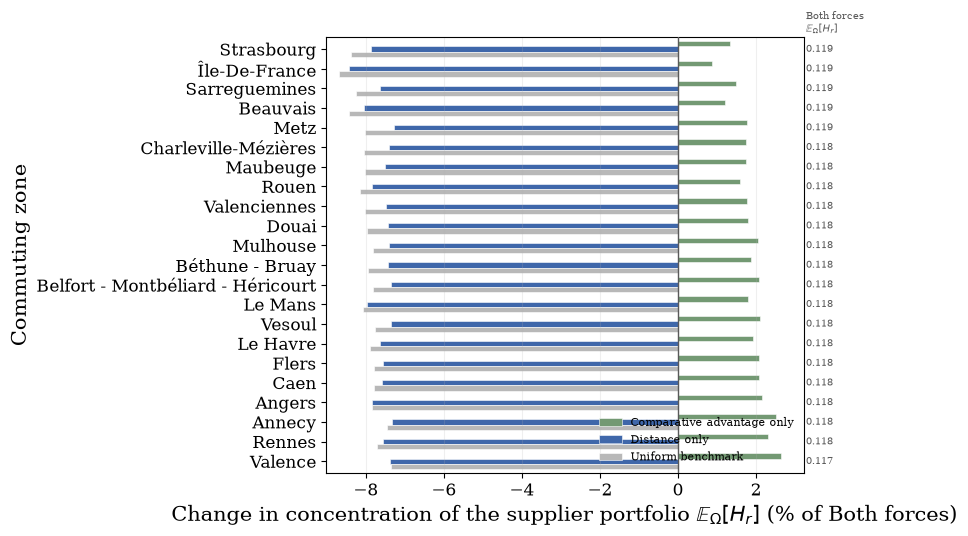

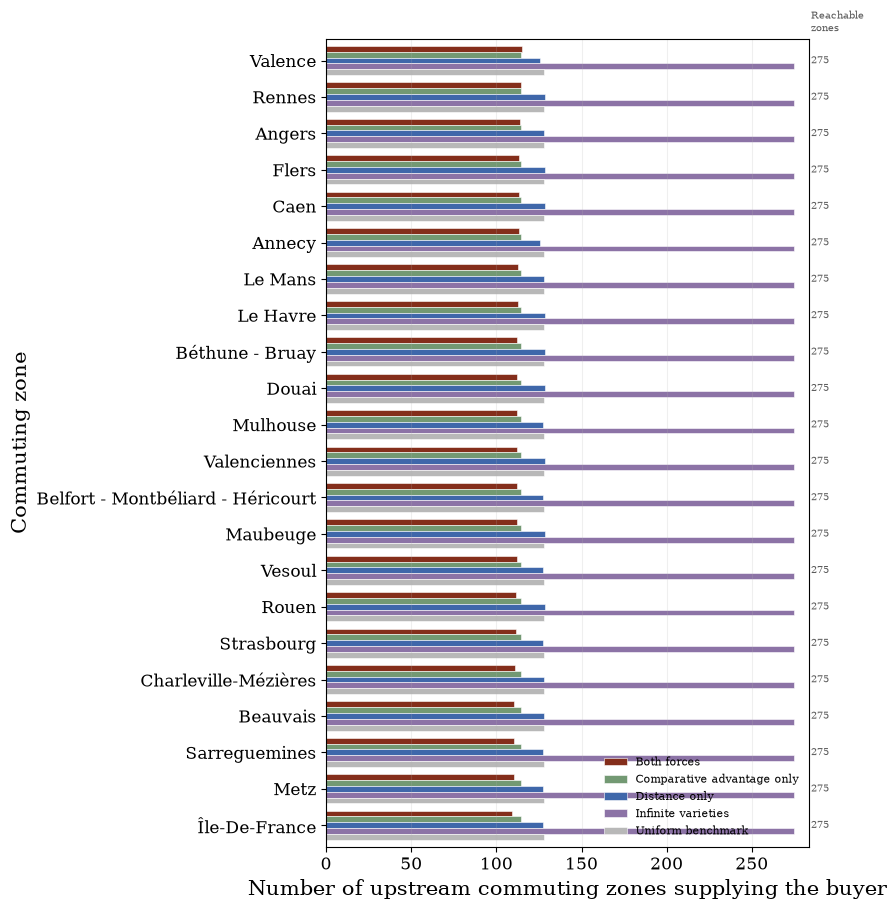


  Table 3 [auto]


,n_eff_rel_uniform,C_structural,n_eff_realised,gran_share,rho_s,rho_floor
regime,,,,,,
Both forces,0.380,0.985,8.226,0.859,0.915,0.045
Distance only,0.976,0.983,9.146,0.939,0.923,0.045
Comparative advantage only,0.404,1.000,8.296,0.866,1.000,0.045
Uniform benchmark,1.000,1.000,9.182,0.940,1.000,0.045


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.

[aero, mu = 2] — where the response lands
  concentration and commonality, sector by sector (spend-weighted over buyers)
                                  sector_name  n_cells  spend  h_bar  h_common      m      C    n_eff  n_eff_common  n_hat_s  n_eff_ratio
regime                     sector                                                                                                        
Both forces                0             C22B      177  0.204  0.013     0.012  0.002  0.865   75.088        86.843     10.0        0.424
                           1             C25D      216  0.235  0.010     0.010

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  the effective number of VARIETIES (V = E[sum_rho v_rho^2])
       sector_name  n_hat_s       V  V_times_N  n_eff_varieties  V_buyer_sd  V_buyer_range
sector                                                                                    
0             C22B     10.0  0.1476     1.4762           6.7741      0.0023         0.0091
1             C25D     14.0  0.1222     1.7109           8.1828      0.0010         0.0037
2             C26E      9.0  0.1728     1.5555           5.7860      0.0016         0.0071
3             C27B     15.0  0.1205     1.8070           8.3012      0.0018         0.0068
4             C28A      9.0  0.1819     1.6367           5.4987      0.0010         0.0034
5             C30C     16.0  0.1151     1.8418           8.6869      0.0023         0.0102
6             C33Z      5.0  0.2670     1.3351           3.7450      0.0028         0.0106
7             G46Z      8.0  0.2055     1.6439           4.8664      0.0024         0.0084
8             M70Z      7.0  

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


  E_Omega[H_r] buyer by buyer (spend-weighted over the buyer's sectors)
                            H (median)  H (min)  H (max)  structural H (median)  granular H (median)  n_eff (median)  structural n_eff (median)  granular share (median)  V (median)  slack 1-H(gamma) (median)
regime                                                                                                                                                                                                         
Both forces                      0.207    0.199    0.229                  0.055                0.150           4.827                     18.029                    0.730       0.157                      0.945
Comparative advantage only       0.203    0.201    0.206                  0.056                0.147           4.916                     17.854                    0.723       0.154                      0.944
Distance only                    0.171    0.166    0.180                  0.018                0

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


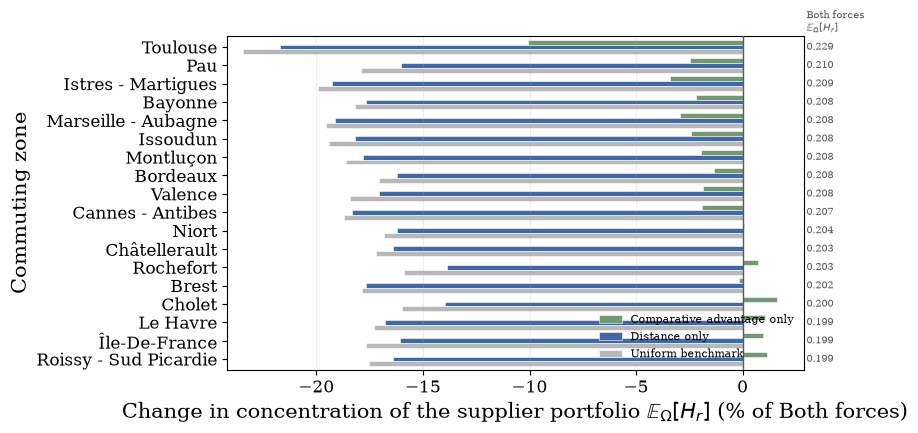

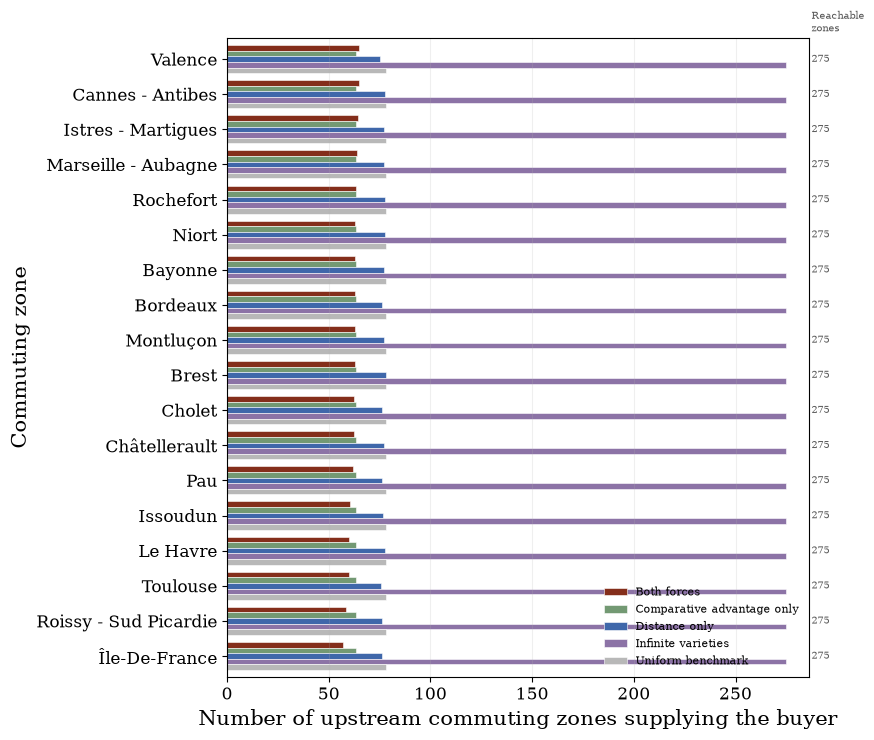


  Table 3 [aero]


,n_eff_rel_uniform,C_structural,n_eff_realised,gran_share,rho_s,rho_floor
regime,,,,,,
Both forces,0.284,0.954,4.908,0.723,0.824,0.056
Distance only,0.876,0.884,5.855,0.893,0.811,0.056
Comparative advantage only,0.287,1.000,4.920,0.726,1.000,0.056
Uniform benchmark,1.000,1.000,5.929,0.905,1.000,0.056


INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode


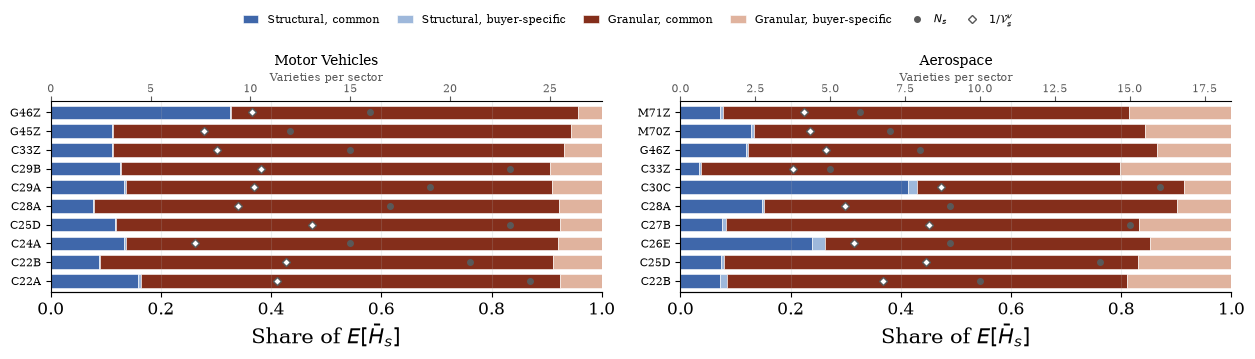

INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode


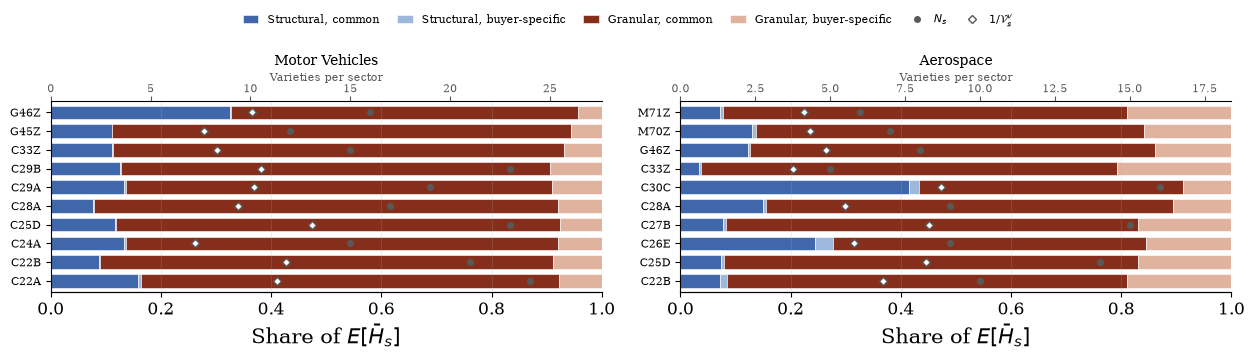


  [Motor Vehicles] spend-weighted buyers against equal buyers (sector weights identical in both)
       struct_common: +0.0169 -> +0.0169
     struct_specific: +0.0003 -> +0.0003
         gran_common: +0.0924 -> +0.0923
       gran_specific: +0.0088 -> +0.0089
               rho_s: +0.9114 -> +0.9110
           rho_floor: +0.0455 -> +0.0455
          C_realised: +0.9212 -> +0.9208

  [Aerospace] spend-weighted buyers against equal buyers (sector weights identical in both)
       struct_common: +0.0539 -> +0.0545
     struct_specific: +0.0026 -> +0.0029
         gran_common: +0.1238 -> +0.1229
       gran_specific: +0.0260 -> +0.0267
               rho_s: +0.8339 -> +0.8289
           rho_floor: +0.0562 -> +0.0556
          C_realised: +0.8667 -> +0.8620


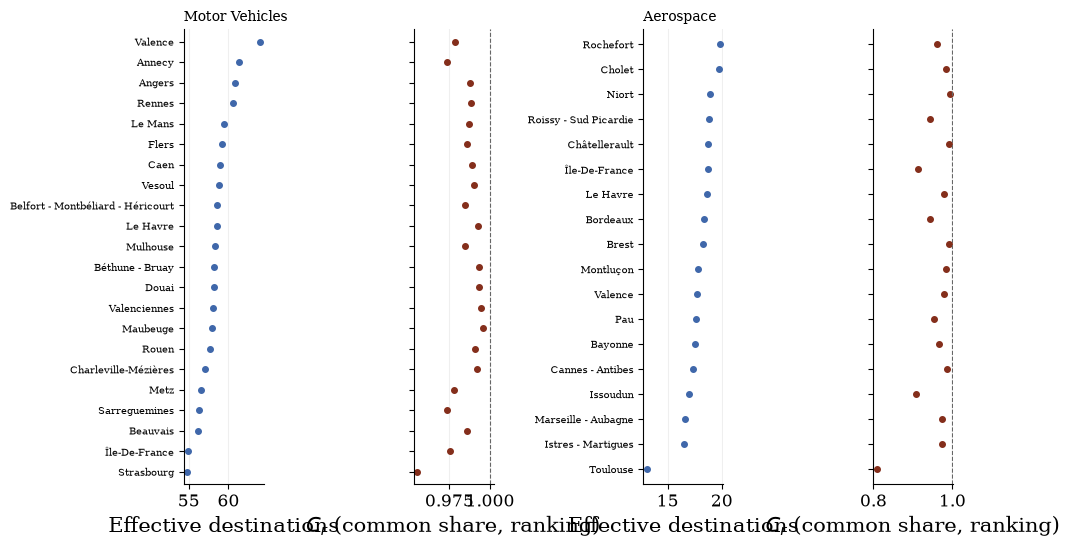

In [33]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
conc_sector, conc_gran, conc_buyers, conc_var, conc_bgran, conc_reach = {}, {}, {}, {}, {}, {}
conc_gran_eq = {}          # the same four cells with every buyer weighted equally
conc_gran_sz = {}          # and weighted by buyer SIZE (the empirical pi_r)
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    print(f"\n[{industry}, mu = {MU}] — where the response lands")
    rep = concentration_report(data, industry=industry)
    conc_sector[cfg["display_name"]] = rep["sector"]
    conc_buyers[cfg["display_name"]] = rep["buyers"]
    if rep["buyer_granular"] is not None:
        conc_bgran[cfg["display_name"]] = rep["buyer_granular"]
        # the per-buyer counterfactual figure, one file per industry, in
        # `plot_counterfactual_distance`'s form: PERCENTAGE deviations from the
        # estimated economy, so the origin is the baseline and a bar's length IS the
        # effect; the level of H is printed at the right margin, so every percentage
        # converts back. H itself and not its reciprocal, because the decomposition is
        # written in H. `Infinite varieties` is DROPPED (the function's default): it
        # sits an order of magnitude below the rest and would crush the two force
        # counterfactuals into the zero rule — granularity is the largest of the three
        # effects and belongs in the text as one number, not on this axis.
        plot_buyer_granular_concentration(
            rep["buyer_granular"], quantity="h", units="pct", kind="bar",
            save_to=f"{out_folder}/buyer_concentration_region_{industry}_mu{MU}.pdf")
        plt.show()
    if rep["reach"] is not None:
        conc_reach[cfg["display_name"]] = rep["reach"]
        # the region count, which carries no variety weighting at all
        plot_buyer_region_reach(
            rep["reach"],
            save_to=f"{out_folder}/buyer_reach_region_{industry}_mu{MU}.pdf")
        plt.show()
    if rep["granular"] is not None:
        conc_gran[cfg["display_name"]] = rep["granular"]
        if rep.get("granular_equal") is not None:
            conc_gran_eq[cfg["display_name"]] = rep["granular_equal"]
        if rep.get("granular_size") is not None:
            conc_gran_sz[cfg["display_name"]] = rep["granular_size"]
        conc_var[cfg["display_name"]] = rep["variety"]
    if rep["table"] is not None:
        print(f"\n  Table 3 [{industry}]")
        display(rep["table"].round(3))

# the granularity figure: the four cells per sector, N_s and 1/V on a twin axis
if conc_gran:
    plot_concentration_decomposition(
        conc_gran, variety=conc_var,
        save_to=f"{out_folder}/concentration_decomposition_mu{MU}.pdf")
    plt.show()

# The same figure under two other buyer weightings. Read the three cell by cell, not
# one at a time. `buyer_hhi` below is what says whether a reweighting reached `pi` at
# all: under EQUAL weights it must be 1/n_buyers exactly.
for _lbl, _tabs, _suffix in (("equal buyers", conc_gran_eq, "equal"),
                             ("size-weighted buyers", conc_gran_sz, "size")):
    if not _tabs:
        continue
    plot_concentration_decomposition(
        _tabs, variety=conc_var,
        save_to=f"{out_folder}/concentration_decomposition_{_suffix}_mu{MU}.pdf")
    plt.show()
    for _k, _t in _tabs.items():
        _b = conc_gran.get(_k)
        if _b is None:
            continue
        _w = _b["spend"] / _b["spend"].sum()      # the SECTOR weights, unchanged
        _n = float(_w @ (1.0 / _b["buyer_hhi"]))
        print(f"\n  [{_k}] model buyer weights against {_lbl} "
              "(sector weights identical in both)")
        print(f"    effective n_buyers 1/buyer_hhi: {_n:.2f} -> "
              f"{float(_w @ (1.0 / _t['buyer_hhi'])):.2f}")
        for _c in ("struct_common", "struct_specific", "gran_common",
                   "gran_specific", "rho_s", "rho_floor", "C_realised"):
            print(f"    {_c:>16}: {float(_w @ _b[_c]):+.4f} -> "
                  f"{float(_w @ _t[_c]):+.4f}")

# the appendix figure: every buyer's effective number and its C_r, one row order
plot_buyer_concentration(
    conc_buyers, save_to=f"{out_folder}/buyer_concentration_mu{MU}.pdf")
plt.show()


## Test 6 — how much of the shock does the region keep?

How far the euro travels is not the same question as how much of it the shocked region
retains, and it is the second that the reduced-form part of the paper measures:

$$L_r(d) = \frac{\sum_{r' : d_{r'r} \le d} X_{r'r}}{\sum_{r'} X_{r'r}}.$$

The denominator is UPSTREAM SALES ONLY — the euro of downstream demand is not in it — so it is
a share of what propagates. The radius is a free parameter throughout; the headline is 200 km,
the radius of the reduced-form evidence, and `local_share_profile` sweeps it so that number is
visibly one point on a CDF rather than assumed robust.

**This is where the sign reversal lives, and it is the section's sharpest result.** In motor
vehicles the two forces reinforce: removing either lowers the local share. In aerospace they
work against each other — equalising $\hat T$ *raises* it. Comparative advantage there is not a
localising force at all: it takes the response off the region where the shock starts and sends
it to the hubs. That is precisely the reallocation the average distance of test 4 nearly
cancels, which is why $d_r$ and $L_r$ are both needed rather than one being a check on the
other.

The map is drawn because $L_r(d)$ is a number attached to a PLACE, and a bar chart sorted by
value destroys exactly the geography the result claims. Its colour scale is PINNED and shared
across the pair: the content is that aerospace reaches 0.56 where motor vehicles never passes
0.44, and a per-panel scale would rescale that away and paint the two maps alike.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[auto]  within 100 km: mean 0.074, median 0.059, min 0.024, max 0.180
[auto]  within 200 km: mean 0.238, median 0.213, min 0.155, max 0.437


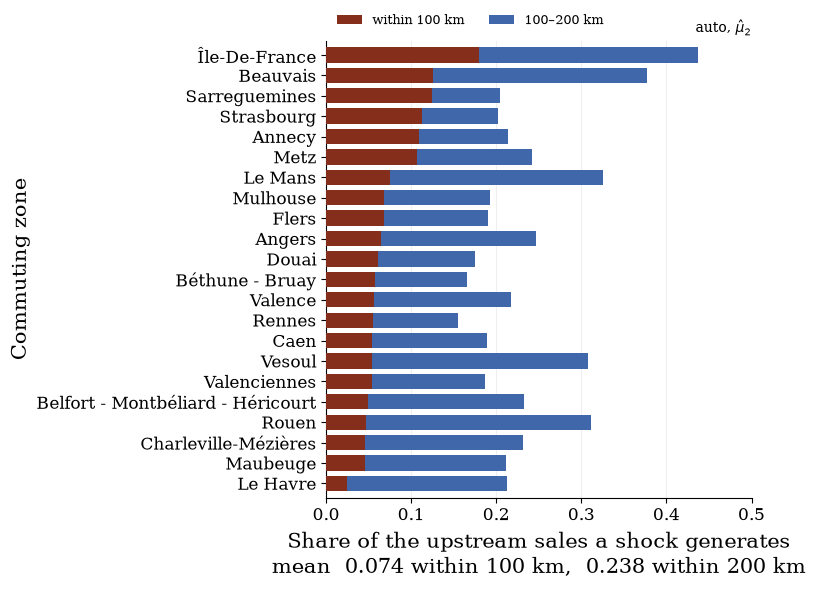

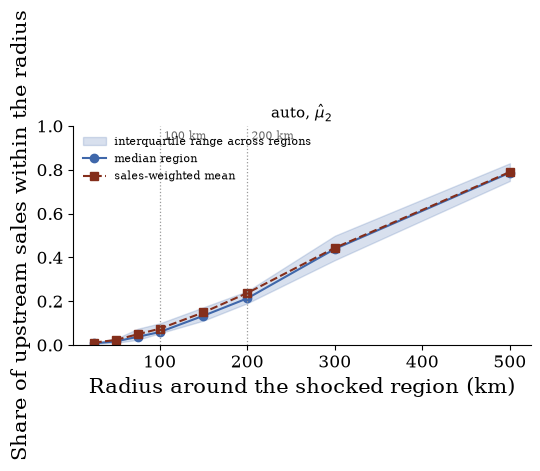

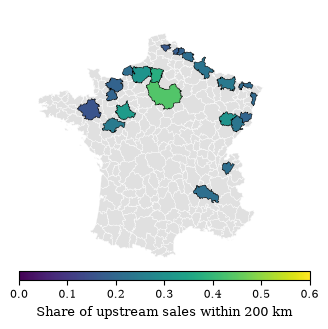

  [counterfactual] D_r is identical across regimes to 8.88e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.074 vs closed-form both-forces 0.073 — the gap is granularity, not a different economy


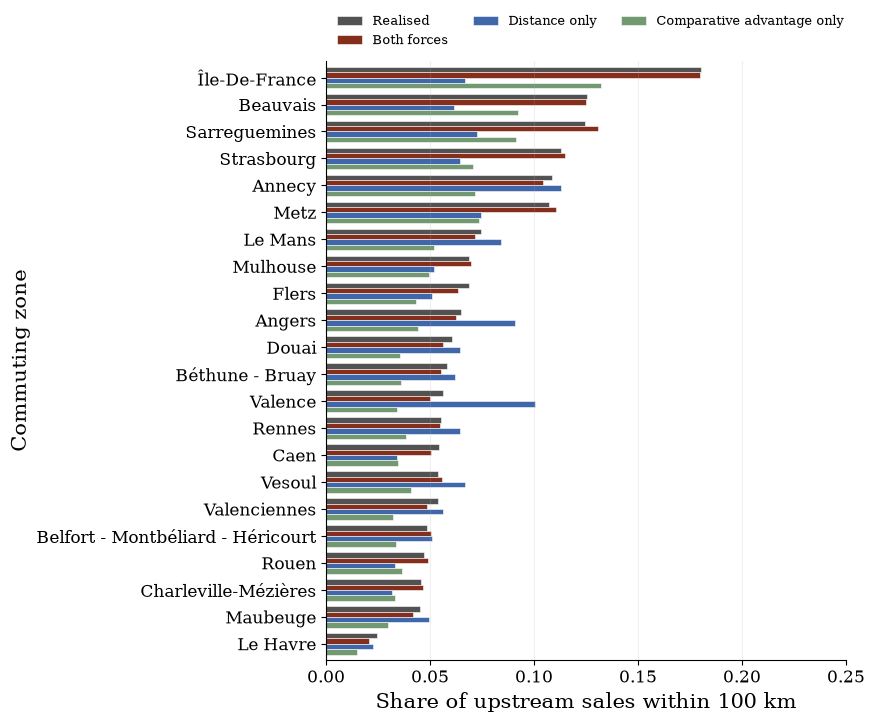

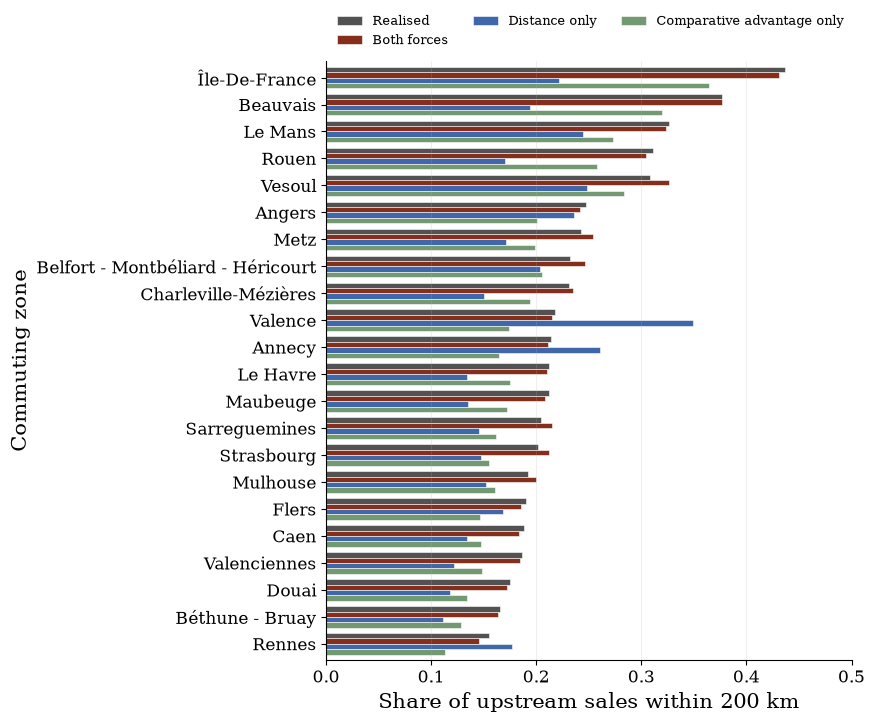

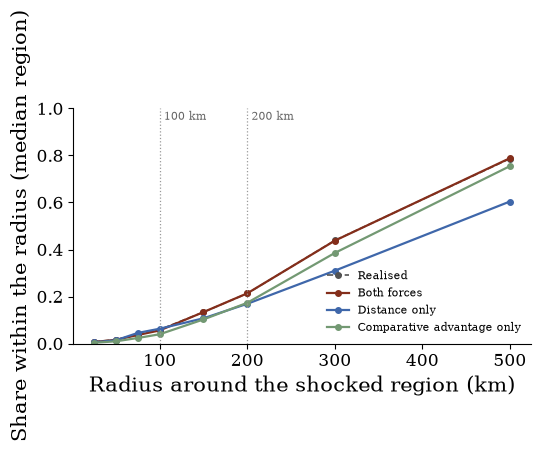

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[aero]  within 100 km: mean 0.088, median 0.058, min 0.006, max 0.392
[aero]  within 200 km: mean 0.213, median 0.197, min 0.031, max 0.563


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


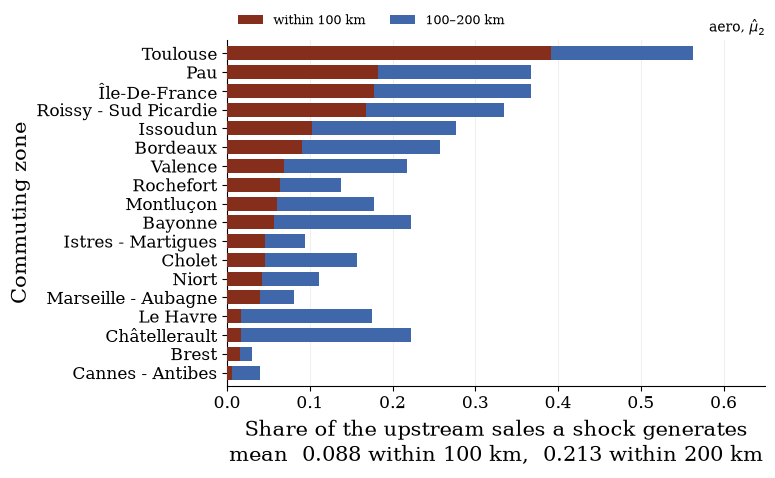

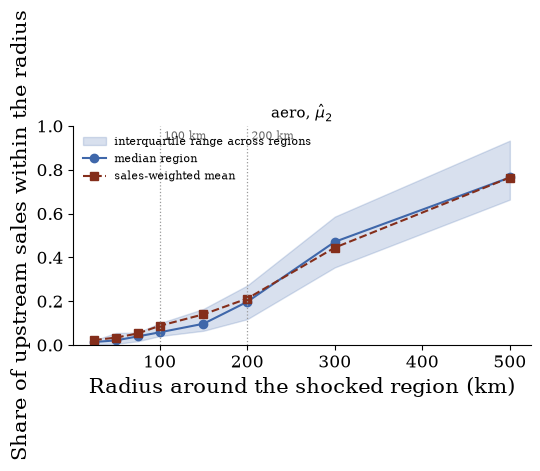

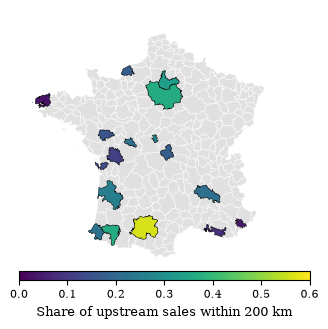

  [counterfactual] D_r is identical across regimes to 4.44e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.088 vs closed-form both-forces 0.089 — the gap is granularity, not a different economy


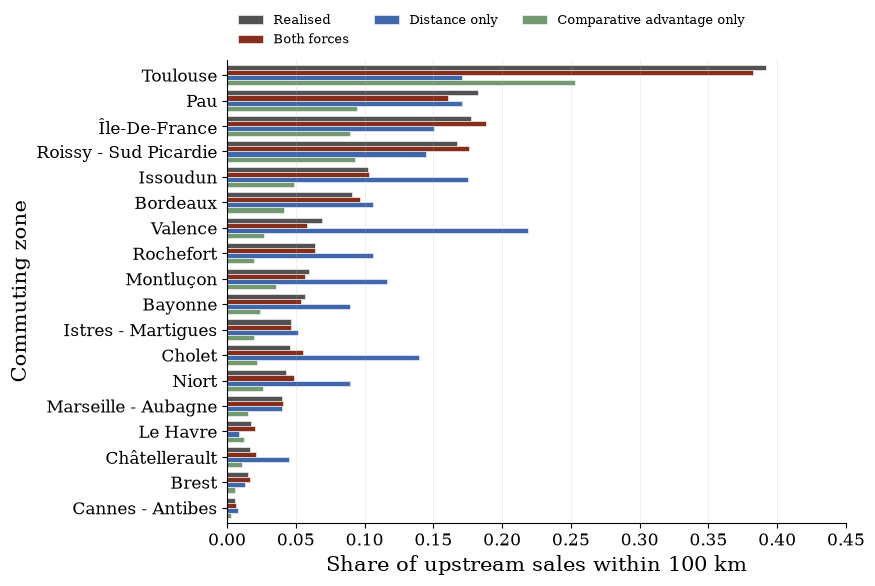

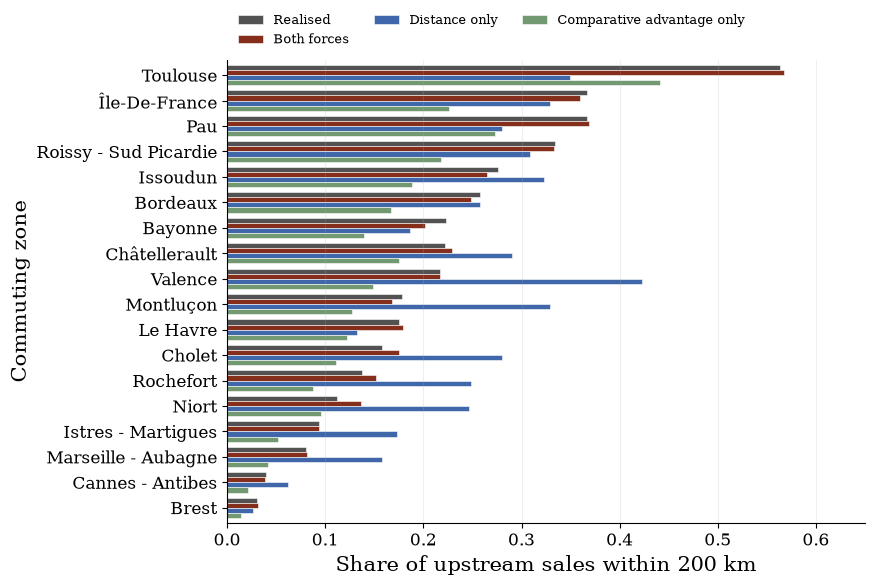

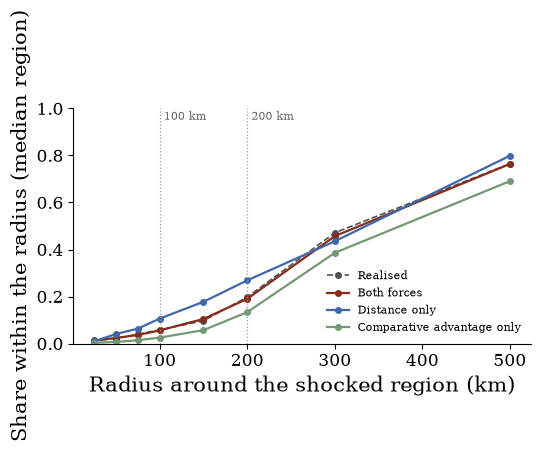

In [34]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    diff = build_diffusion_frame(data)
    summ = amplification_summary(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    prof = local_share_profile(data, diffusion=diff)

    for d in AMPLIFICATION_RADII:
        c = f"share_within_{int(d)}km"
        print(f"[{industry}]  within {d:g} km: mean {summ[c].mean():.3f}, "
              f"median {summ[c].median():.3f}, min {summ[c].min():.3f}, max {summ[c].max():.3f}")

    plot_local_share(data, radii=AMPLIFICATION_RADII, summary=summ,
                     save_to=f"{out_folder}/local_share_{industry}_mu{MU}.pdf")
    plt.show()
    plot_local_share_profile(data, profile=prof, mark=AMPLIFICATION_RADII,
                             save_to=f"{out_folder}/local_share_profile_{industry}_mu{MU}.pdf")
    plt.show()

    # the map: L_r(d) is a number attached to a place. Guarded on the geometry.
    try:
        plot_local_share_map(data, radius_km=AMPLIFICATION_RADII[-1], summary=summ,
                             vlim=LOCAL_SHARE_MAP_VLIM_WIDE,
                             save_to=f"{out_folder}/local_share_map{int(AMPLIFICATION_RADII[-1])}km_{industry}_mu{MU}.pdf")
        plt.show()
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  local-share map skipped: {type(e).__name__}: {e}")

    # the sign reversal, region by region and as the whole profile
    det = counterfactual_amplification(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    for d in AMPLIFICATION_RADII:
        plot_counterfactual_local_share(
            data, radius_km=d, detail=det,
            save_to=f"{out_folder}/counterfactual_local_share{int(d)}km_{industry}_mu{MU}.pdf")
        plt.show()
    plot_counterfactual_profile(data, mark=AMPLIFICATION_RADII, diffusion=diff,
                                save_to=f"{out_folder}/counterfactual_profile_{industry}_mu{MU}.pdf")
    plt.show()


## Test 7 — what does the finite variety count cost?

With $N_s$ finite the network is a RANDOM object, so no single realisation is a result. This
test is not a caveat on tests 1–6; it measures something they cannot see.

**What is invariant, and why.** Under Fréchet the identity of a variety's winner is
independent of its realised price, so conditionally on prices the location indicators are
i.i.d. and independent of them: $\mathbb{E}[L_r(d)]$ is EXACTLY invariant to $N_s$ — the same
argument that gives $\hat q \perp N_s$. The point estimates of tests 1, 3 and 6 were therefore
right whatever the variety count.

**What is not.** The SUPPORT: a buyer sources $\sum_s \hat N_s$ varieties, so a shock reaches a
few dozen origins rather than every commuting zone, and the loss is larger in the industry
where comparative advantage concentrates sourcing. The DISPERSION: the spread of $L_r(100)$
across realisations is of the same order as its mean, so the cross-region contrast the map
reports (a contrast of expectations) stands while a statement about one region in one year does
not. And $D_r$ rises: the within-sector index is convex in the draws, so a finite basket is on
average dearer, and with $\lambda < 1$ that raises the intermediate share — the price-index
channel, which is why the gap from the continuum is not sampling noise.


In [35]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    print(f"[{industry}, mu = {MU}]")
    try:
        granularity_report(data, radii=AMPLIFICATION_RADII)
        # the spread one draw carries, region by region
        display(granular_band(data, radii=AMPLIFICATION_RADII).round(3))
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  granularity report skipped: {type(e).__name__}: {e}")


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[auto, mu = 2]


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  granularity = the finite-variety economy minus its N_s -> infinity limit (50 realisations):
                        granular_mean  sd_across_draws  continuum  granularity  granularity_rel
quantity                                                                                       
amplification                  1.8480           0.0115     1.8378       0.0102           0.0055
mean_upstream_distance       347.2472          23.6606   345.7733       1.4739           0.0043
supplier_cells               112.9336           5.5331   273.2273    -160.2936          -0.5867
share_within_100km             0.0745           0.0301     0.0749      -0.0004          -0.0050
share_within_200km             0.2376           0.0510     0.2389      -0.0013          -0.0055
  a shock reaches 113 origins with N_hat_s varieties against 273 in the continuum — the extensive margin is the whole of what granularity is for.


,region,amplification,amplification_sd,mean_upstream_distance,mean_upstream_distance_sd,supplier_cells,supplier_cells_sd,share_within_100km,share_within_100km_sd,share_within_200km,share_within_200km_sd,n_replications
ze2010_downstream,,,,,,,,,,,,
12,Île-De-France,1.842,0.012,257.290,21.134,109.74,5.678,0.180,0.046,0.437,0.058,50
13,Charleville-Mézières,1.848,0.011,338.270,24.214,111.52,5.339,0.046,0.020,0.231,0.048,50
26,Beauvais,1.845,0.012,295.575,22.965,110.90,5.614,0.126,0.041,0.377,0.062,50
36,Le Havre,1.849,0.011,363.149,24.844,113.72,5.789,0.024,0.021,0.212,0.051,50
37,Rouen,1.847,0.012,324.287,24.289,112.52,6.018,0.047,0.024,0.311,0.064,50
58,Caen,1.849,0.011,366.721,26.145,114.68,5.593,0.054,0.036,0.189,0.053,50
68,Flers,1.849,0.011,357.089,25.632,114.92,5.428,0.069,0.039,0.190,0.051,50
88,Douai,1.849,0.011,368.355,23.505,113.00,5.406,0.061,0.026,0.175,0.040,50
89,Valenciennes,1.849,0.011,368.352,23.353,112.78,5.327,0.054,0.024,0.186,0.041,50


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[aero, mu = 2]


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  granularity = the finite-variety economy minus its N_s -> infinity limit (50 realisations):
                        granular_mean  sd_across_draws  continuum  granularity  granularity_rel
quantity                                                                                       
amplification                  1.8733           0.0171     1.8608       0.0124           0.0067
mean_upstream_distance       353.2472          30.5876   352.8476       0.3996           0.0011
supplier_cells                61.6422           3.3333   261.5000    -199.8578          -0.7643
share_within_100km             0.0883           0.0467     0.0924      -0.0041          -0.0441
share_within_200km             0.2129           0.0736     0.2122       0.0007           0.0035
  a shock reaches 62 origins with N_hat_s varieties against 262 in the continuum — the extensive margin is the whole of what granularity is for.


,region,amplification,amplification_sd,mean_upstream_distance,mean_upstream_distance_sd,supplier_cells,supplier_cells_sd,share_within_100km,share_within_100km_sd,share_within_200km,share_within_200km_sd,n_replications
ze2010_downstream,,,,,,,,,,,,
7,Roissy - Sud Picardie,1.873,0.019,375.326,44.264,57.92,3.680,0.168,0.062,0.334,0.087,50
11,Toulouse,1.857,0.015,253.227,38.852,59.06,3.053,0.391,0.111,0.562,0.095,50
12,Île-De-France,1.871,0.019,350.262,45.077,56.54,3.512,0.178,0.067,0.367,0.092,50
36,Le Havre,1.880,0.017,453.455,39.915,59.82,3.607,0.017,0.016,0.176,0.060,50
45,Issoudun,1.866,0.020,267.270,25.550,60.46,3.610,0.102,0.061,0.277,0.102,50
137,Cholet,1.874,0.017,335.252,23.200,61.94,3.216,0.046,0.034,0.157,0.065,50
156,Brest,1.888,0.016,590.059,28.932,62.14,3.314,0.015,0.017,0.031,0.029,50
170,Châtellerault,1.871,0.018,287.374,20.220,61.54,3.327,0.016,0.020,0.222,0.088,50
176,Rochefort,1.872,0.016,313.911,25.298,62.34,3.185,0.063,0.055,0.137,0.070,50


## Test 8 — do suppliers share a clientele, or are they segmented?

Every test above reads a BUYER's portfolio of suppliers. This one turns the same matrix on
its side and reads a SUPPLIER's portfolio of customers — the object a supplier-side shock
acts on, and the one that says whether two upstream cells are exposed to the same demand.

**Similarity.** Supplier cell $j$ of sector $s$ sells $x_{jr} = \pi_r\,\gamma_{jrs}$ to each
downstream buyer $r$. Two suppliers are compared by the angle between their portfolios,

$$C_{jk} \;=\; \frac{\langle x_j, x_k\rangle}{\lVert x_j\rVert\,\lVert x_k\rVert},$$

collected into the sector matrix $C_s$. The cosine is **scale-invariant**, so sales shares
and raw sales give the same $C_{jk}$: normalising portfolios is not a modelling choice and
the per-sector spending level cancels. What does not cancel is the weighting of the BUYER
axis — $\pi_r$ rescales the coordinates and therefore the angle — so the buyer weights are
a decision and are reported as one.

**Groups.** The decomposition below needs a partition, and $C_s$ is what there is to build
one from: a link between $j$ and $k$ when $C_{jk} > \tau$, then the connected components of
that graph. Two weaknesses are worth stating rather than defending. The threshold is
arbitrary, so it is swept over $\tau \in \{0.6, 0.7, 0.8\}$ rather than fixed. And connected
components **chain** — $A\!\sim\!B$ and $B\!\sim\!C$ merge $A$ with $C$ however small
$C_{AC}$ is — which a modularity algorithm (Louvain/Leiden on the weighted graph) would
avoid; here the chaining is visible as a single giant component at low $\tau$, which the
reported group count and largest-group share expose.

**Decomposition.** With groups $g$ of size $N_g$, and all sums over ORDERED pairs $j \neq k$,

$$C^{within}_s=\frac{\sum_g \sum_{j\neq k \in g} C_{jk}}{\sum_g N_g(N_g-1)},
\qquad
C^{between}_s=\frac{\sum_{g\neq h}\sum_{j\in g,\,k\in h} C_{jk}}{\sum_{g\neq h} N_g N_h},
\qquad
\Delta C_s = C^{within}_s - C^{between}_s .$$

A singleton contributes nothing to the within sum — its own ordered-pair count is zero —
and its whole row to the between one. **$\Delta C_s > 0$ is mechanically true**: the groups
are cut out of $C$ itself, so this is a statistic of separation and not a test. It acquires
content only against a null, and two are computed. The first is the one the objection
suggests: hold each cell's NUMBER of links fixed, rearrange WHICH links it has
(degree-preserving double-edge swaps), and score the resulting partition on the SAME $C$.
**That null turns out to be mostly uninformative, and the code reports it rather than
hiding it**: a rewired graph of any density is almost always connected, which leaves one
group, no between pairs and no gap to score — `null_degenerate` is the share of draws it
collapses on, and near one it says nothing. The second never degenerates: keep the
observed group SIZES and reassign which cells fill them at random. It asks whether THIS
partition of $C$ separates more than an arbitrary partition of the same shape, which a
sector with one common clientele — every $C_{jk}$ alike, so every partition equivalent —
fails and a segmented one passes. `delta_excess` is the gap against that second null, and
it is the column to read.

**Reading.** $\Delta C_s \simeq 0$ in excess of the null means one common clientele: the
suppliers of a sector face the same buyers in the same proportions, so a demand shock
anywhere upstream is a shock to all of them together. A large excess means segmentation —
blocks of suppliers with their own customers, insulated from each other's demand. The two
are not distinguished by the AVERAGE similarity: a high $\bar C_s$ is compatible with
$C^{within} \gg C^{between}$, which is exactly why the decomposition is needed and the mean
is not reported on its own.


In [ ]:
# Test 8 — do suppliers share a clientele, or are they segmented into groups?
#
# The mirror of every test above. Tests 1-7 read a BUYER's portfolio of suppliers; this one
# reads a SUPPLIER's portfolio of customers, which is the column of the same matrix and the
# object a supplier-side shock acts on. Everything is closed form in `rho`, so nothing is
# simulated. `PORTFOLIO_TAUS` lives in the Constants cell.

# Three helpers carried across from the deleted comparative-advantage section:
# they were defined there and are used only here now.
def _sectors_in_code_order(data):
    """
    Sector display names in A129-CODE order.

    Every sector-indexed table and figure in this section is presented in this order, so
    the reader compares the same row across figures instead of re-reading a legend that
    has been resorted by whatever the figure happens to rank on.
    """
    return [n for _, n in sorted(zip(data["sector_names"], data["sector_names"]))]


def _by_sector_code(df, data, level=None):
    """Reindex a sector-indexed frame into A129-code order, dropping absent sectors."""
    order = [s for s in _sectors_in_code_order(data)
             if s in (df.index if level is None else df.index.get_level_values(level))]
    return df.reindex(order) if level is None else df.reindex(order, level=level)


def _buyer_weights(data):
    """Downstream buyers weighted by their purchases (the empirical pi_r target)."""
    w = np.asarray(data["emp_pi_r"], dtype=float).ravel()
    return w / w.sum()


def portfolio_matrix(data, sector, weights="pi_r", alpha=None, equalise_T=False,
                     geom=None):
    """
    Sector `sector`'s (cell x buyer) SALES matrix: row `j` is supplier cell `j`'s portfolio
    of customers, `x_{jr} = pi_r * gamma_{jrs}`.

    `weights` sets the buyer sizes: `"pi_r"` is the empirical `pi_r` target (the block-3
    moment, the only object carrying buyer size), `None` counts every buyer alike. The
    choice MATTERS here and the level of `pi_r` does not: the cosine below is invariant to
    scaling a whole portfolio, so the per-sector spending level cancels, but rescaling the
    BUYER axis reweights the coordinates and changes the angle between two portfolios.
    """
    g = sourcing_geometry(data, alpha=alpha, equalise_T=equalise_T) if geom is None else geom
    blk = g["by_sector"][sector]
    X = np.asarray(blk["rho"], dtype=float)                 # (cell, buyer), columns sum to 1
    if weights is None:
        w = np.ones(X.shape[1])
    elif isinstance(weights, str) and weights == "pi_r":
        w = np.asarray(_buyer_weights(data), dtype=float).ravel()
    else:
        w = np.asarray(weights, dtype=float).ravel()
    if w.size != X.shape[1]:
        raise ValueError(f"buyer weights have {w.size} entries against {X.shape[1]} buyers.")
    return X * w[None, :], np.asarray(blk["cells"]).astype(int)


def portfolio_similarity(X):
    """
    The cosine similarity `C_jk = <x_j, x_k> / (|x_j| |x_k|)` between every pair of supplier
    portfolios, and the rows that carry one.

    The cosine is SCALE-INVARIANT, so sales shares and raw sales give the same `C_jk` and the
    normalisation is not a modelling choice. A cell with no sales has no portfolio and no
    angle; it is dropped rather than counted as similar to everything.
    """
    X = np.asarray(X, dtype=float)
    nrm = np.linalg.norm(X, axis=1)
    ok = np.isfinite(nrm) & (nrm > 0)
    Z = X[ok] / nrm[ok][:, None]
    return np.clip(Z @ Z.T, -1.0, 1.0), ok


def portfolio_groups(C, tau):
    """
    Group labels from the similarity graph: a LINK when `C_jk > tau`, then the connected
    components of that graph.

    Two limitations, both real and neither hidden. `tau` is arbitrary -- the report below
    sweeps it rather than defending one value. And connected components CHAIN: `A ~ B` and
    `B ~ C` merge A with C even when `C_AC` is far below the threshold, so a long thin path
    is read as one clientele. A modularity algorithm (Louvain/Leiden on the weighted graph)
    does not chain and would be the fix if the groups themselves became the object; here
    they are scaffolding for the decomposition, and the chaining shows up as a single giant
    component at a low `tau`, which the reported group count makes visible.
    """
    C = np.asarray(C, dtype=float)
    n = C.shape[0]
    A = (C > float(tau)) & ~np.eye(n, dtype=bool)
    parent = np.arange(n)

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    for i, j in zip(*np.nonzero(np.triu(A, 1))):
        ri, rj = find(int(i)), find(int(j))
        if ri != rj:
            parent[ri] = rj
    lab = np.array([find(i) for i in range(n)])
    return np.unique(lab, return_inverse=True)[1], A


def portfolio_decomposition(C, labels):
    """
    `C_within`, `C_between` and their gap, over ORDERED pairs `j != k`.

    Pooled over groups, so the denominators are `sum_g N_g(N_g-1)` and `sum_{g!=h} N_g N_h`
    -- the ordered-pair counts, which is what makes the two averages comparable. A SINGLETON
    contributes nothing to the within sum (its own count is zero) and its whole row to the
    between one; with every cell a singleton the within average is undefined and returns
    NaN rather than zero.
    """
    C = np.asarray(C, dtype=float)
    lab = np.asarray(labels).ravel()
    same = lab[:, None] == lab[None, :]
    off = ~np.eye(lab.size, dtype=bool)
    w, b = same & off, (~same) & off
    cw = float(C[w].mean()) if w.any() else np.nan
    cb = float(C[b].mean()) if b.any() else np.nan
    return cw, cb, cw - cb


def _rewire(A, rng, passes=10):
    """
    A degree-preserving rewiring of the similarity graph by double-edge swaps.

    This is the null the gap needs. The groups are built FROM `C`, so `C_within > C_between`
    is true by construction and the raw gap is a separation statistic, not a test. Holding
    each cell's NUMBER of links fixed and rearranging WHICH links it has gives a graph with
    the same degrees and no clientele structure; running the same partition on it and
    scoring it on the SAME `C` says how much of the observed gap the procedure would have
    produced anyway.
    """
    B = np.array(A, dtype=bool, copy=True)
    e = np.array(np.nonzero(np.triu(B, 1))).T
    if e.shape[0] < 2:
        return B
    for _ in range(int(passes) * e.shape[0]):
        i, j = int(rng.integers(e.shape[0])), int(rng.integers(e.shape[0]))
        if i == j:
            continue
        a, b = e[i]
        c, d = e[j]
        if rng.random() < 0.5:
            c, d = d, c
        if len({int(a), int(b), int(c), int(d)}) < 4 or B[a, d] or B[c, b]:
            continue
        B[a, b] = B[b, a] = B[c, d] = B[d, c] = False
        B[a, d] = B[d, a] = B[c, b] = B[b, c] = True
        e[i], e[j] = (a, d), (c, b)
    return B


def portfolio_null(C, A, labels, n_draws=200, seed=0):
    """
    Two null distributions for `Delta C`, because the gap needs one and neither null
    alone is adequate.

    `rewire` is the null the question suggests: hold each cell's NUMBER of links fixed and
    rearrange WHICH links it has, then partition the result and score it on the SAME `C`.
    It has a defect worth reporting rather than hiding -- a rewired graph of any density is
    almost always CONNECTED, which leaves one group, no between pairs and no gap to score.
    Those draws return NaN and `null_degenerate` counts them; a rate near one means the
    rewiring null says nothing here, NOT that the observed gap is real.

    `permute` is the null that never degenerates: keep the observed group SIZES and
    reassign which cells fill them at random. It asks whether THIS partition of `C`
    separates more than an arbitrary partition of the same shape -- which is the question
    the endogeneity objection poses, and which a sector with one common clientele (every
    `C_jk` alike, so every partition equivalent) fails while a segmented one passes.
    """
    rng = np.random.default_rng(seed)
    lab = np.asarray(labels).ravel()
    rew, per = [], []
    for _ in range(int(n_draws)):
        B = _rewire(A, rng)
        # B is 0/1, so any threshold strictly inside (0,1) means `linked`
        rew.append(portfolio_decomposition(C, portfolio_groups(B.astype(float), .5)[0])[2])
        per.append(portfolio_decomposition(C, rng.permutation(lab))[2])
    return np.asarray(rew, dtype=float), np.asarray(per, dtype=float)


def customer_portfolio_report(data, taus=None, weights="pi_r", n_draws=200, seed=0,
                              verbose=True):
    """
    One row per (sector, tau): the similarity level, the groups it produces, the
    within/between split and the rewiring null.

    Read `delta` against `delta_null_mean`, never against zero.
    """
    taus = PORTFOLIO_TAUS if taus is None else taus
    geom = sourcing_geometry(data)
    rows = []
    for s, blk in geom["by_sector"].items():
        if np.asarray(blk["cells"]).size < 3:
            continue
        X, cells = portfolio_matrix(data, s, weights=weights, geom=geom)
        C, ok = portfolio_similarity(X)
        if C.shape[0] < 3:
            continue
        off = ~np.eye(C.shape[0], dtype=bool)
        for tau in taus:
            lab, A = portfolio_groups(C, tau)
            cw, cb, dl = portfolio_decomposition(C, lab)
            rew, per = portfolio_null(C, A, lab, n_draws=n_draws, seed=seed)
            sizes = np.bincount(lab)
            rows.append({
                "sector": s, "sector_name": str(data["sector_names"][s]), "tau": float(tau),
                "n_cells": int(C.shape[0]), "n_dropped": int((~ok).sum()),
                "C_bar": float(C[off].mean()),
                "n_groups": int(sizes.size), "n_singletons": int((sizes == 1).sum()),
                "largest_share": float(sizes.max() / sizes.sum()),
                "C_within": cw, "C_between": cb, "delta": dl,
                "delta_null_mean": float(np.nanmean(per)),
                "delta_null_sd": float(np.nanstd(per)),
                "delta_rewire_mean": float(np.nanmean(rew))
                                     if np.isfinite(rew).any() else np.nan,
                "null_degenerate": float(np.mean(~np.isfinite(rew))),
                "delta_excess": dl - float(np.nanmean(per)),
            })
    # One row per (sector, tau), so the index REPEATS each sector: `_by_sector_code`
    # reindexes and would raise on the duplicates. Order the blocks instead.
    if rows:
        out = pd.DataFrame(rows).set_index(["sector", "tau"]).reset_index("tau")
        order = [s for s in _sectors_in_code_order(data) if s in set(out.index)]
        out = pd.concat([out.loc[[s]] for s in order]) if order else out
    else:
        out = pd.DataFrame()
    if verbose and len(out):
        cols = ["sector_name", "tau", "n_cells", "C_bar", "n_groups", "n_singletons",
                "largest_share", "C_within", "C_between", "delta", "delta_null_mean",
                "null_degenerate", "delta_excess"]
        print("  supplier customer-portfolio similarity, by sector and threshold")
        print(out[cols].round(3).to_string())
        print("    `delta` is mechanically positive -- the groups are cut out of `C` "
              "itself. What carries content is `delta_excess`, the gap against a "
              "size-preserving permutation of the group labels. `null_degenerate` is "
              "the share of degree-preserving rewirings that collapsed to one "
              "component -- near one, that second null says nothing here.")
    return out


def plot_portfolio_decomposition(tables, tau=None, figsize=None, save_to=None):
    """
    Per sector: `C_between` and `C_within` as the ends of a segment, with the rewiring
    null's `Delta C` drawn from `C_between` as a hollow mark.

    The segment IS the decomposition and the hollow mark is what the same procedure would
    have produced on a structureless graph of identical degrees, so the distance between
    the hollow and the filled mark is the whole of the finding.
    """
    items = list(tables.items()) if isinstance(tables, dict) else list(tables)
    n = len(items)
    rows = max(len(t[t["tau"] == (tau if tau is not None else t["tau"].max())])
               for _, t in items)
    fig, axes = plt.subplots(1, n, figsize=figsize or (5.6 * n, max(3.0, 0.34 * rows)),
                             squeeze=False)
    for ax, (label, tab) in zip(axes[0], items):
        t = tab[tab["tau"] == (tau if tau is not None else tab["tau"].max())]
        y = np.arange(len(t))
        cb = t["C_between"].to_numpy(dtype=float)
        ax.hlines(y, cb, t["C_within"].to_numpy(dtype=float), color="0.7", lw=2, zorder=1)
        ax.plot(cb, y, "o", ms=5, color=sim_color, label=r"$C^{between}$", zorder=2)
        ax.plot(t["C_within"].to_numpy(dtype=float), y, "o", ms=5, color=toulouse_color,
                label=r"$C^{within}$", zorder=2)
        ax.plot(cb + t["delta_null_mean"].to_numpy(dtype=float), y, "D", ms=5, mfc="white",
                color="0.35", label="rewiring null", zorder=3)
        ax.set_yticks(y)
        ax.set_yticklabels([str(r.sector_name) for r in t.itertuples()], fontsize=8)
        ax.set_ylim(-0.6, len(t) - 0.4)
        ax.set_xlabel("cosine similarity of customer portfolios")
        ax.set_title(label, fontsize=10)
        ax.grid(alpha=0.2, axis="x")
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    fig.tight_layout()
    h, l = axes[0][0].get_legend_handles_labels()
    fig.legend(h, l, frameon=False, fontsize=8, ncol=3, loc="lower center",
               bbox_to_anchor=(0.5, 1.0), borderaxespad=0.0)
    if save_to:
        fig.savefig(save_to, bbox_inches="tight")
    return axes


In [ ]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
cp = {}
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)
    name = cfg.get("display_name", industry)

    print(f"\n=== [{industry}, mu = {MU}] " + "=" * 46)
    try:
        cp[name] = customer_portfolio_report(data)
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  customer-portfolio similarity skipped: {type(e).__name__}: {e}")

_of = globals().get("out_folder")
if cp:
    plot_portfolio_decomposition(
        cp, save_to=f"{_of}/customer_portfolio_mu{MU}.pdf" if _of else None)
    plt.show()
